In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.preprocessing import StandardScaler
import joblib
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import ipywidgets as widgets
from collections import Counter
from IPython.display import display, HTML
from IPython.display import display
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import (
    confusion_matrix, precision_score, recall_score,
    f1_score, roc_auc_score
)
from IPython.display import display, Markdown
from IPython.display import Markdown, display
from sklearn.metrics import r2_score, mean_absolute_error
import matplotlib.gridspec as gridspec
from scipy import stats
import optuna
from sklearn.metrics import mean_absolute_error, precision_score
from scipy.optimize import minimize, LinearConstraint, Bounds
from scipy.stats import spearmanr
import warnings
import requests
import re
import subprocess
from IPython.display import display, HTML, clear_output
import os
import datetime

In [2]:
# %% [Cell 1: LOAD DATA + FEATURE ENGINEERING + 3 GW Horizon for difficultu + total Difficulty Score (FDI_3GW). ]

INPUT_FILE = '../output/dataset_no0min.csv'
ENHANCED_FEATURES_OUT = '../output/forecaster_pro/fpl_features_augmented.csv'
df = pd.read_csv(INPUT_FILE)
print(f"Loaded INPUT_FILE: {INPUT_FILE}")
print(f"Raw input seasons: {sorted(df['season'].unique())}")
print(f"Raw 2025-26 max GW: {df[df['season']=='2025-26']['Gameweek'].max()}")

def load_season_fixtures(season='2025-26'):
    """Load the season fixture schedule and normalize team names for join."""
    fixtures = pd.read_csv(f'../data/{season}/fixtures.csv')
    teams = pd.read_csv(f'../data/{season}/teams.csv')[['id', 'name']].rename(
        columns={'id': 'team_id', 'name': 'team_name'}
    )

    fixtures = fixtures.merge(
        teams.rename(columns={'team_id': 'team_h', 'team_name': 'team_h_name'}),
        on='team_h', how='left'
    ).merge(
        teams.rename(columns={'team_id': 'team_a', 'team_name': 'team_a_name'}),
        on='team_a', how='left'
    )
    fixtures['season'] = season
    return fixtures[
        ['season', 'event', 'team_h_name', 'team_a_name', 'team_h_difficulty', 'team_a_difficulty']
    ]


def fill_next_fixture_from_schedule(df, fixture_schedule):
    """Fill missing next-match fixture difficulty from the upcoming schedule."""

    # â”€â”€ NORMALISE team names so CSV names match fixture CSV names â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
    # Build a mapping from the actual team names found in df to fixture names
    _name_fixes = {
        "Nottingham Forest":    "Nott'm Forest",
        "Nott'm Forest":        "Nott'm Forest",
        "Manchester City":      "Man City",
        "Manchester United":    "Man Utd",
        "Newcastle United":     "Newcastle",
        "Tottenham Hotspur":    "Spurs",
        "Tottenham":            "Spurs",
        "West Ham United":      "West Ham",
        "Wolverhampton Wanderers": "Wolves",
        "Brighton & Hove Albion":  "Brighton",
        "Leicester City":       "Leicester",
        "Ipswich Town":         "Ipswich",
    }

    # Apply normalisation to the fixture schedule team name columns
    fix_sched = fixture_schedule.copy()
    fix_sched['team_h_name'] = fix_sched['team_h_name'].replace(_name_fixes)
    fix_sched['team_a_name'] = fix_sched['team_a_name'].replace(_name_fixes)

    # Apply normalisation to the df player team names too
    df = df.copy()
    df['Player Team Name'] = df['Player Team Name'].replace(_name_fixes)
    # â”€â”€ END NORMALISATION â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€

    schedule = pd.concat([
        fix_sched.rename(
            columns={
                'team_h_name': 'Player Team Name',
                'team_h_difficulty': 'Scheduled_Difficulty'
            }
        ).assign(Scheduled_Is_Home=True),
        fix_sched.rename(
            columns={
                'team_a_name': 'Player Team Name',
                'team_a_difficulty': 'Scheduled_Difficulty'
            }
        ).assign(Scheduled_Is_Home=False)
    ], ignore_index=True)

    schedule = schedule[['season', 'event', 'Player Team Name', 'Scheduled_Difficulty', 'Scheduled_Is_Home']]
    schedule = schedule.rename(columns={'event': 'Next_Gameweek'})

    df['Next_Gameweek'] = df['Gameweek'] + 1
    df = df.merge(
        schedule,
        on=['season', 'Player Team Name', 'Next_Gameweek'],
        how='left'
    )

    df['Next_Opponent_Difficulty'] = df['Next_Opponent_Difficulty'].fillna(df['Scheduled_Difficulty'])
    df['Next_Is_Home'] = df['Next_Is_Home'].fillna(df['Scheduled_Is_Home'])

    return df.drop(columns=['Next_Gameweek', 'Scheduled_Difficulty', 'Scheduled_Is_Home'])


def enrich_features_v2(df, fixture_schedule=None):
    """
    Final Strategic Consolidation + 3-GW Fixture Horizon:
    - Ranked Deduplication (Max 2 matches per GW).
    - Season Baseline Bridge for GW1/GW2 stability.
    - 3-GW Fixture Difficulty Index (FDI_3GW).
    """

    # --- STEP 0: PRE-CLEAN ---
    df['Minutes Played'] = df['Minutes Played'].clip(upper=90)

    # --- STEP 1: RANKED DEDUPLICATION ---
    df = df.sort_values(
        ['Player UUID', 'season', 'Gameweek', 'Minutes Played', 'Total Points'],
        ascending=[True, True, True, False, False]
    )
    df = df.groupby(['Player UUID', 'season', 'Gameweek']).tail(2)

    # --- STEP 2: CHRONOLOGICAL RE-SORT ---
    df = df.sort_values(['Player UUID', 'season', 'Gameweek'])

    # --- STEP 3: INTEGRITY AUDIT ---
    counts = df.groupby(['Player UUID', 'season', 'Gameweek']).size().reset_index(name='match_count')
    legit_dgws = counts[counts['match_count'] == 2]
    suspicious = counts[counts['match_count'] > 2]

    print(f"--- Final Integrity Audit ---")
    print(f"Legitimate DGW Match Pairs (Time-Series): {len(legit_dgws)}")
    print(f"Suspicious GWs (>2 matches): {len(suspicious)} (TARGET: 0)")
    print(f"Max Minutes in a single row: {df['Minutes Played'].max()}")

    # --- STEP 4: CORE FEATURES & 3-GW HORIZON ---
    df['Rolling_Avg_Minutes_5'] = df.groupby('Player UUID')['Minutes Played'].transform(
        lambda x: x.shift(1).rolling(5, min_periods=1).mean()
    ).fillna(0)

    # Immediate Next Game (GW+1)
    df['Next_Opponent_Difficulty'] = df.groupby(['Player UUID', 'season'])['Opponent Difficulty'].shift(-1)
    df['Next_Is_Home'] = df.groupby(['Player UUID', 'season'])['Is Home'].shift(-1)

    if fixture_schedule is not None:
        df = fill_next_fixture_from_schedule(df, fixture_schedule)

    # Future Horizon (GW+2 and GW+3)
    # Note: these use the historical difficulty sequence as a proxy for future fixtures.
    # This is valid for training (past data) but for live inference use the fixture
    # schedule directly. fillna(3) = neutral difficulty if season ends.
    df['Opponent_Diff_plus_2'] = (
        df.groupby(['Player UUID', 'season'])['Opponent Difficulty']
        .shift(-2)
        .clip(1, 5)
        .fillna(3)
    )
    
    df['Opponent_Diff_plus_3'] = (
        df.groupby(['Player UUID', 'season'])['Opponent Difficulty']
        .shift(-3)
        .clip(1, 5)
        .fillna(3)
    )

    # Total 3-GW Fixture Difficulty Index (range: 3â€“15, lower = easier)
    df['FDI_3GW'] = (
        df['Next_Opponent_Difficulty'].fillna(3) +
        df['Opponent_Diff_plus_2'] +
        df['Opponent_Diff_plus_3']
    ).clip(3, 15)

    df['Season_Phase'] = pd.cut(
        df['Gameweek'], bins=[0, 10, 19, 29, 38], labels=[1, 2, 3, 4]
    ).astype(float)

    # --- STEP 5: TEAM POINT SHARE (fully lagged, no leakage) ---
    team_col = next((c for c in ['Player Team ID', 'team', 'Player Team Name'] if c in df.columns), None)
    if team_col:
        df['_prev_individual_pts'] = df.groupby('Player UUID')['Total Points'].shift(1)
        df['_prev_team_total'] = df.groupby(
            [team_col, 'season', 'Gameweek']
        )['_prev_individual_pts'].transform('sum')

        df['Team_Point_Share'] = (
            df['_prev_individual_pts'] / df['_prev_team_total']
        ).replace([np.inf, -np.inf], 0).fillna(0)

        df.drop(columns=['_prev_individual_pts', '_prev_team_total'], inplace=True)
    else:
        df['Team_Point_Share'] = 0

    # --- STEP 6: SEASON BASELINE BRIDGE (no current-season leakage) ---
    season_stats = df.groupby(['Player UUID', 'season'])['Total Points'].mean().reset_index()
    season_stats.rename(columns={'Total Points': 'Season_Avg_Points'}, inplace=True)

    # shift(1) on the season axis: season N gets season N-1's completed average
    season_stats['Prev_Season_Avg_Points'] = season_stats.groupby(
        'Player UUID'
    )['Season_Avg_Points'].shift(1)

    df = df.merge(
        season_stats[['Player UUID', 'season', 'Prev_Season_Avg_Points']],
        on=['Player UUID', 'season'],
        how='left'
    )
    df['Prev_Season_Avg_Points'] = df['Prev_Season_Avg_Points'].fillna(0)

    # --- STEP 7: AVG POINTS VS DIFFICULTY (Historical Performance by Fixture Type) ---
    # For each player, calculate their average points scored against each
    # difficulty level (1â€“5) using only PAST data (fully lagged via shift(1)).
    # This captures whether a player consistently performs vs easy/hard opponents.
    # Zero data leakage: we use the shifted cumulative mean, not the current match.

    # Group by player + difficulty, compute expanding mean of past performances
    df = df.sort_values(['Player UUID', 'season', 'Gameweek'])

    # Shift points by 1 so we never use the current match
    df['_pts_shifted'] = df.groupby('Player UUID')['Total Points'].shift(1)

    # For each row, compute the historical avg points for this player
    # at this exact difficulty level
    df['Avg_Pts_vs_Difficulty'] = (
        df.groupby(['Player UUID', 'Opponent Difficulty'])['_pts_shifted']
        .transform(lambda x: x.expanding().mean())
        .fillna(0)
    )

    # Clean up temp column
    df.drop(columns=['_pts_shifted'], inplace=True)

    # Integrity check: should be between 0 and ~15, never negative
    _avg_max = df['Avg_Pts_vs_Difficulty'].max()
    _avg_mean = df['Avg_Pts_vs_Difficulty'].mean()
    print(f"Avg_Pts_vs_Difficulty: max={_avg_max:.2f}, mean={_avg_mean:.2f} (expected ~2-4)")

    # --- FINAL STEP: DROP ROWS WHERE NEXT MATCH CONTEXT IS UNKNOWN ---
    return df.dropna(subset=['Next_Opponent_Difficulty'])


fixture_schedule = load_season_fixtures('2025-26')

# â”€â”€ FIX: Player Team Name contains numeric IDs for 2025-26 â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
# Build team_id â†’ team_name map from the teams CSV
_teams_lookup = pd.read_csv('../data/2025-26/teams.csv')[['id', 'name']]
_id_to_name   = _teams_lookup.set_index('id')['name'].to_dict()

# For rows where Player Team Name is numeric (the 2025-26 season), replace with name
def _fix_team_name(val):
    try:
        return _id_to_name.get(int(float(val)), val)
    except (ValueError, TypeError):
        return val  # already a string name, leave it

df['Player Team Name'] = df['Player Team Name'].apply(_fix_team_name)

print("Team name fix applied. Sample 2025-26 team names:")
print(sorted(df[df['season'] == '2025-26']['Player Team Name'].dropna().astype(str).unique()))
# â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€

# ── FIX: Normalize 2025-26 Web Names to use FPL short web names ──────────────
# Some 2025-26 rows use the full player name as Web Name (e.g. 'Aaron Hickey')
# instead of the correct FPL short web name (e.g. 'Hickey').
# For each UUID, if any row has a proper FPL web name (Web Name != Player Name),
# remap ALL rows for that UUID in 2025-26 to use that FPL web name.
_26_mask = df['season'] == '2025-26'
_fpl_webname_map = (
    df[_26_mask & (df['Web Name'] != df['Player Name'])]
    .groupby('Player UUID')['Web Name']
    .first()
)
df.loc[_26_mask, 'Web Name'] = (
    df.loc[_26_mask, 'Player UUID']
    .map(_fpl_webname_map)
    .fillna(df.loc[_26_mask, 'Web Name'])
)
print(f'Web Name normalization: {len(_fpl_webname_map)} UUIDs remapped to FPL short web names.')

df_augmented = enrich_features_v2(df, fixture_schedule=fixture_schedule)
df_augmented.to_csv(ENHANCED_FEATURES_OUT, index=False, encoding='utf-8-sig')

print(f"Enhanced dataset created: {ENHANCED_FEATURES_OUT}")

# Display the new 3-GW Fixture features for verification
print("\n--- 3-GW Fixture Horizon Verification ---")
display(df_augmented[[
    'Web Name', 'season', 'Gameweek',
    'Next_Opponent_Difficulty', 'Opponent_Diff_plus_2', 'Opponent_Diff_plus_3', 'FDI_3GW'
]].tail(10))

Loaded INPUT_FILE: ../output/dataset_no0min.csv
Raw input seasons: ['2020-21', '2021-22', '2022-23', '2023-24', '2024-25', '2025-26']
Raw 2025-26 max GW: 32
Team name fix applied. Sample 2025-26 team names:
['Arsenal', 'Aston Villa', 'Bournemouth', 'Brentford', 'Brighton', 'Burnley', 'Chelsea', 'Crystal Palace', 'Everton', 'Fulham', 'Leeds', 'Liverpool', 'Man City', 'Man Utd', 'Newcastle', "Nott'm Forest", 'Spurs', 'Sunderland', 'West Ham', 'Wolves']
Web Name normalization: 519 UUIDs remapped to FPL short web names.
--- Final Integrity Audit ---
Legitimate DGW Match Pairs (Time-Series): 4638
Suspicious GWs (>2 matches): 0 (TARGET: 0)
Max Minutes in a single row: 90
Avg_Pts_vs_Difficulty: max=21.00, mean=2.80 (expected ~2-4)
Enhanced dataset created: ../output/forecaster_pro/fpl_features_augmented.csv

--- 3-GW Fixture Horizon Verification ---


,Web Name,season,Gameweek,Next_Opponent_Difficulty,Opponent_Diff_plus_2,Opponent_Diff_plus_3,FDI_3GW
67392,J.Murphy,2025-26,31,3.0,3.0,3.0,9.0
67393,J.Murphy,2025-26,32,3.0,3.0,3.0,9.0
67395,Hackford,2023-24,1,2.0,3.0,3.0,8.0
67397,Maghoma,2024-25,14,4.0,4.0,5.0,13.0
67398,Maghoma,2024-25,15,4.0,5.0,1.0,10.0
67399,Maghoma,2024-25,17,5.0,1.0,1.0,7.0
67400,Maghoma,2024-25,19,1.0,1.0,3.0,5.0
67401,Maghoma,2024-25,20,1.0,3.0,4.0,8.0
67402,Maghoma,2024-25,26,3.0,4.0,3.0,10.0
67403,Maghoma,2024-25,27,4.0,3.0,3.0,10.0


In [3]:
# %% [Cell: DGW Detector — Dynamic Double Gameweek Detection from FPL API]

def detect_dgw_teams(target_gw: int, season: str = '2025-26') -> set:
    """
    Dynamically detects which teams have a Double Gameweek for the given GW
    by reading the FPL API fixtures endpoint.
    
    A team has a DGW if it appears MORE THAN ONCE in the fixtures for target_gw.
    Returns a set of team names (matched to your df_augmented naming convention).
    """
    # 1. Fetch live fixtures from FPL API
    try:
        fx_data = requests.get(
            "https://fantasy.premierleague.com/api/fixtures/",
            timeout=10
        ).json()
        print(f"Fixtures fetched: {len(fx_data)} total fixtures in API")
    except Exception as e:
        print(f"[ERROR] Could not reach FPL API: {e}")
        return set()

    # 2. Filter for the target gameweek
    gw_fixtures = [f for f in fx_data if f.get('event') == target_gw]
    print(f"Fixtures found for GW{target_gw}: {len(gw_fixtures)}")

    if not gw_fixtures:
        print(f"[WARNING] No fixtures found for GW{target_gw}. "
              f"The API may not have published them yet.")
        return set()

    # 3. Count how many times each team_id appears (home + away)
    team_id_counts = Counter()
    for f in gw_fixtures:
        team_id_counts[f['team_h']] += 1
        team_id_counts[f['team_a']] += 1

    # 4. DGW team IDs = teams appearing more than once
    dgw_team_ids = {tid for tid, count in team_id_counts.items() if count > 1}
    print(f"DGW team IDs: {sorted(dgw_team_ids)}")

    if not dgw_team_ids:
        print(f"[INFO] No Double Gameweek detected for GW{target_gw}.")
        return set()

    # 5. Map team IDs → team names using the local teams.csv
    # This is the same file your Cell 1 uses, so names are guaranteed to match
    try:
        teams_df = pd.read_csv(f'../data/{season}/teams.csv')
        id_to_name = teams_df.set_index('id')['name'].to_dict()
    except FileNotFoundError:
        # Fallback: use the API bootstrap for team names
        try:
            bootstrap = requests.get(
                "https://fantasy.premierleague.com/api/bootstrap-static/",
                timeout=10
            ).json()
            id_to_name = {t['id']: t['name'] for t in bootstrap['teams']}
        except Exception as e:
            print(f"[ERROR] Could not load team names: {e}")
            return set()

    dgw_team_names = {id_to_name[tid] for tid in dgw_team_ids if tid in id_to_name}

    # 6. Apply the SAME normalisation map used in Cell 1 (fill_next_fixture_from_schedule)
    # This ensures team names match exactly what's in df_augmented['Player Team Name']
    _name_fixes = {
        "Nottingham Forest":         "Nott'm Forest",
        "Manchester City":           "Man City",
        "Manchester United":         "Man Utd",
        "Newcastle United":          "Newcastle",
        "Tottenham Hotspur":         "Spurs",
        "West Ham United":           "West Ham",
        "Wolverhampton Wanderers":   "Wolves",
        "Brighton & Hove Albion":    "Brighton",
        "Leicester City":            "Leicester",
        "Ipswich Town":              "Ipswich",
    }
    dgw_team_names_normalised = {
        _name_fixes.get(name, name) for name in dgw_team_names
    }

    print(f"\nDGW{target_gw} Teams Detected: {sorted(dgw_team_names_normalised)}")
    return dgw_team_names_normalised


# ── EXECUTE ───────────────────────────────────────────────────────────────────
CURRENT_GW  = globals().get('CURRENT_GW', 33)
CURRENT_SEASON = globals().get('CURRENT_SEASON', '2025-26')

DGW_TEAMS = detect_dgw_teams(target_gw=CURRENT_GW, season=CURRENT_SEASON)

# Flag players in df_augmented
df_augmented['Is_DGW'] = (
    df_augmented['Player Team Name'].isin(DGW_TEAMS)
).astype(int)

dgw_players = df_augmented[
    (df_augmented['season'] == CURRENT_SEASON) &
    (df_augmented['Is_DGW'] == 1)
]['Web Name'].nunique()

print(f"\nPlayers flagged as DGW: {dgw_players}")
print(f"DGW flag stored in df_augmented['Is_DGW']")
print(f"DGW_TEAMS stored in globals() for use by the Leaderboard and Optimizer cells.")

globals()['DGW_TEAMS'] = DGW_TEAMS

Fixtures fetched: 380 total fixtures in API
Fixtures found for GW33: 13
DGW team IDs: [3, 4, 6, 7, 11, 13]

DGW33 Teams Detected: ['Bournemouth', 'Brighton', 'Burnley', 'Chelsea', 'Leeds', 'Man City']

Players flagged as DGW: 154
DGW flag stored in df_augmented['Is_DGW']
DGW_TEAMS stored in globals() for use by the Leaderboard and Optimizer cells.


In [4]:
# %% [Cell: BGW Detector — Flag players who Blank in the next GW after CURRENT_GW]
def detect_bgw_teams(current_gw: int, season: str = '2025-26') -> set:
    """
    Detects teams that have NO fixture in the gameweek immediately after current_gw.
    These are Blank Gameweek teams — players from these clubs score 0 in BGW.
    """
    try:
        fx_data = requests.get(
            "https://fantasy.premierleague.com/api/fixtures/",
            timeout=10
        ).json()
    except Exception as e:
        print(f"[ERROR] Could not reach FPL API: {e}")
        return set()

    next_gw = current_gw + 1

    # Teams that DO have a fixture in next_gw
    teams_with_fixture = set()
    for f in fx_data:
        if f.get('event') == next_gw:
            teams_with_fixture.add(f['team_h'])
            teams_with_fixture.add(f['team_a'])

    # All known team IDs
    try:
        teams_df = pd.read_csv(f'../data/{season}/teams.csv')
        all_team_ids = set(teams_df['id'].tolist())
        id_to_name   = teams_df.set_index('id')['name'].to_dict()
    except FileNotFoundError:
        bootstrap = requests.get(
            "https://fantasy.premierleague.com/api/bootstrap-static/",
            timeout=10
        ).json()
        all_team_ids = {t['id'] for t in bootstrap['teams']}
        id_to_name   = {t['id']: t['name'] for t in bootstrap['teams']}

    # Teams with NO fixture in next_gw = Blank teams
    blank_team_ids = all_team_ids - teams_with_fixture

    _name_fixes = {
        "Nottingham Forest": "Nott'm Forest",
        "Manchester City":   "Man City",
        "Manchester United": "Man Utd",
        "Newcastle United":  "Newcastle",
        "Tottenham Hotspur": "Spurs",
        "West Ham United":   "West Ham",
        "Wolverhampton Wanderers": "Wolves",
        "Brighton & Hove Albion":  "Brighton",
    }

    bgw_team_names = {
        _name_fixes.get(id_to_name[tid], id_to_name[tid])
        for tid in blank_team_ids if tid in id_to_name
    }

    print(f"BGW{next_gw} Teams (no fixture): {sorted(bgw_team_names)}")
    return bgw_team_names


BGW_TEAMS = detect_bgw_teams(current_gw=CURRENT_GW, season=CURRENT_SEASON)
globals()['BGW_TEAMS'] = BGW_TEAMS

# Apply a BGW penalty to the leaderboard before the optimizer runs
# Players blanking next GW are worth less — deprioritise them in core squad
print(f"\nBGW teams identified: {len(BGW_TEAMS)} teams will blank in GW{CURRENT_GW + 1}")

BGW34 Teams (no fixture): ['Bournemouth', 'Brighton', 'Burnley', 'Chelsea', 'Leeds', 'Man City']

BGW teams identified: 6 teams will blank in GW34


In [5]:
# %% [NEW CELL: Task 1.1 — DGW Row Aggregator & Before/After Audit]
# ============================================================
# STANDALONE MODULE — reads from df_augmented, writes to a NEW
# variable `df_augmented_dgw_clean`. Original df_augmented is
# never modified.
# ============================================================


_TARGET_GW     = globals().get('CURRENT_GW', 33)   # GW to audit (33 by default)
_TARGET_SEASON = globals().get('CURRENT_SEASON', '2025-26')

# ── 1. SNAPSHOT: rows belonging to the target GW ─────────────────────────────
_gw_rows = df_augmented[
    (df_augmented['season']   == _TARGET_SEASON) &
    (df_augmented['Gameweek'] == _TARGET_GW)
].copy()

_before_count   = len(_gw_rows)
_before_players = _gw_rows['Player UUID'].nunique()
_double_uuids   = (
    _gw_rows.groupby('Player UUID').size()
            .pipe(lambda s: s[s > 1])
            .index.tolist()
)

print(f"━━━  DGW AUDIT — GW{_TARGET_GW} ({_TARGET_SEASON})  ━━━")
print(f"Total rows in GW{_TARGET_GW}:       {_before_count:,}")
print(f"Unique players in GW{_TARGET_GW}:   {_before_players:,}")
print(f"Players with multiple entries:   {len(_double_uuids):,}")

# ── 2. PREVIEW: what the doubles look like BEFORE aggregation ────────────────
if _double_uuids:
    _sample_doubles = _gw_rows[_gw_rows['Player UUID'].isin(_double_uuids[:5])].sort_values(
        ['Player UUID', 'Gameweek']
    )[['Web Name', 'Gameweek', 'Total Points', 'Minutes Played', 'Opponent Difficulty']]

    print(f"\n── BEFORE (sample of doubled players) ──")
    display(_sample_doubles)
else:
    print(f"\n[INFO] No duplicate entries found for GW{_TARGET_GW}. Nothing to aggregate.")

# ── 3. AGGREGATION LOGIC ─────────────────────────────────────────────────────
# Rules:
#   • Total Points    → SUM   (both matches count toward score)
#   • Minutes Played  → SUM   (cap at 180 so clipped back to 90 later if needed)
#   • Opponent Difficulty → MEAN (average difficulty across both fixtures)
#   • All other numeric cols → MEAN  (conservative default)
#   • All string/cat cols   → FIRST  (take the first row's metadata)

def _aggregate_dgw_rows(group_df):
    """Aggregate multiple rows for the same player-GW into one summary row."""
    if len(group_df) == 1:
        return group_df.iloc[0]

    agg_row = group_df.iloc[0].copy()   # start with first row's metadata

    # --- Fields with specific aggregation rules ---
    agg_row['Total Points']       = group_df['Total Points'].sum()
    agg_row['Minutes Played']     = min(group_df['Minutes Played'].sum(), 180)
    agg_row['Opponent Difficulty']= round(group_df['Opponent Difficulty'].mean(), 2)

    # --- Numeric fields: mean (goals, assists, bonus, xG etc.) ---
    _numeric_cols = group_df.select_dtypes(include=[np.number]).columns.tolist()
    _skip = {'Total Points', 'Minutes Played', 'Opponent Difficulty'}
    for col in _numeric_cols:
        if col not in _skip:
            try:
                agg_row[col] = group_df[col].mean()
            except Exception:
                pass

    return agg_row


# Work on a full copy of df_augmented so we never touch the original
_df_temp = df_augmented.copy()

# Split into: rows outside the target GW (untouched) + target GW rows (to aggregate)
_mask_target = (
    (_df_temp['season']   == _TARGET_SEASON) &
    (_df_temp['Gameweek'] == _TARGET_GW)
)
_df_other  = _df_temp[~_mask_target].copy()
_df_target = _df_temp[_mask_target].copy()

# Apply aggregation only if duplicates exist
if _double_uuids:
    _df_agg = (
        _df_target
        .groupby('Player UUID', group_keys=False)
        .apply(_aggregate_dgw_rows)
        .reset_index(drop=True)
    )
else:
    _df_agg = _df_target.copy()

# Stitch back together
df_augmented_dgw_clean = (
    pd.concat([_df_other, _df_agg], ignore_index=True)
      .sort_values(['Player UUID', 'season', 'Gameweek'])
      .reset_index(drop=True)
)

# ── 4. AFTER SNAPSHOT ────────────────────────────────────────────────────────
_after_rows = df_augmented_dgw_clean[
    (df_augmented_dgw_clean['season']   == _TARGET_SEASON) &
    (df_augmented_dgw_clean['Gameweek'] == _TARGET_GW)
]
_after_count   = len(_after_rows)
_after_doubles = (
    _after_rows.groupby('Player UUID').size()
               .pipe(lambda s: s[s > 1])
               .shape[0]
)

print(f"\n── AFTER AGGREGATION ──")
print(f"Rows in GW{_TARGET_GW}:              {_after_count:,}  (was {_before_count:,})")
print(f"Players with multiple entries:   {_after_doubles}  (TARGET: 0)")
print(f"Total df_augmented_dgw_clean rows: {len(df_augmented_dgw_clean):,}")
print(f"Original df_augmented rows:        {len(df_augmented):,}")

# ── 5. BEFORE / AFTER TABLE for DGW players ──────────────────────────────────
if _double_uuids:
    _before_view = (
        _gw_rows[_gw_rows['Player UUID'].isin(_double_uuids)]
        .groupby('Player UUID')
        .agg(
            Web_Name      = ('Web Name', 'first'),
            Rows_Before   = ('Total Points', 'count'),
            Pts_Per_Match = ('Total Points', lambda x: list(x.round(1))),
            Pts_Total     = ('Total Points', 'sum'),
            Mins_Total    = ('Minutes Played', 'sum'),
            Avg_Difficulty= ('Opponent Difficulty', 'mean'),
        )
        .reset_index(drop=True)
    )

    _after_view = (
        _after_rows[_after_rows['Web Name'].isin(_before_view['Web_Name'])]
        [['Web Name', 'Total Points', 'Minutes Played', 'Opponent Difficulty']]
        .rename(columns={
            'Total Points':       'Pts_Aggregated',
            'Minutes Played':     'Mins_Aggregated',
            'Opponent Difficulty':'Difficulty_Avg',
        })
    )

    print(f"\n── BEFORE/AFTER COMPARISON (DGW players) ──")
    print("BEFORE:")
    display(_before_view)
    print("AFTER (aggregated to single row):")
    display(_after_view)

print(f"\n✓ df_augmented_dgw_clean is ready.")
print(f"  Original df_augmented is untouched.")
print(f"  Use df_augmented_dgw_clean for any GW{_TARGET_GW}-specific inference.")

━━━  DGW AUDIT — GW33 (2025-26)  ━━━
Total rows in GW33:       0
Unique players in GW33:   0
Players with multiple entries:   0

[INFO] No duplicate entries found for GW33. Nothing to aggregate.

── AFTER AGGREGATION ──
Rows in GW33:              0  (was 0)
Players with multiple entries:   0  (TARGET: 0)
Total df_augmented_dgw_clean rows: 64,650
Original df_augmented rows:        64,650

✓ df_augmented_dgw_clean is ready.
  Original df_augmented is untouched.
  Use df_augmented_dgw_clean for any GW33-specific inference.


In [6]:
# Run this diagnostic after Task 1.1 to confirm it's doing something useful
_check_before = df_augmented[
    (df_augmented['season'] == '2025-26') & 
    (df_augmented['Gameweek'] == 33)
]['Player UUID'].value_counts()

_check_after = df_augmented_dgw_clean[
    (df_augmented_dgw_clean['season'] == '2025-26') & 
    (df_augmented_dgw_clean['Gameweek'] == 33)
]['Player UUID'].value_counts()

print(f"Players with 2 rows BEFORE: {(_check_before > 1).sum()}")
print(f"Players with 2 rows AFTER:  {(_check_after > 1).sum()}  ← should be 0")
print(f"Haaland points before: {df_augmented[(df_augmented['Web Name']=='Haaland') & (df_augmented['Gameweek']==33)]['Total Points'].tolist()}")
print(f"Haaland points after:  {df_augmented_dgw_clean[(df_augmented_dgw_clean['Web Name']=='Haaland') & (df_augmented_dgw_clean['Gameweek']==33)]['Total Points'].tolist()}")

Players with 2 rows BEFORE: 0
Players with 2 rows AFTER:  0  ← should be 0
Haaland points before: [14, 10]
Haaland points after:  [14, 10]


In [7]:
# %% [NEW CELL: Historical DGW Detection Across All Seasons]

# ── 1. FIND ALL HISTORICAL DGW INSTANCES ─────────────────────────────────────
_dgw_map = (
    df_augmented
    .groupby(['Player UUID', 'season', 'Gameweek'])
    .size()
    .reset_index(name='match_count')
    .query('match_count > 1')
)

print(f"Total DGW instances found across all seasons: {len(_dgw_map):,}")
print(f"\nBreakdown by season:")
display(
    _dgw_map.groupby('season')
    .agg(
        DGW_player_instances = ('Player UUID', 'count'),
        Unique_GWs           = ('Gameweek', 'nunique'),
        GW_numbers           = ('Gameweek', lambda x: sorted(x.unique().tolist()))
    )
    .reset_index()
)

# ── 2. IDENTIFY WHICH GWs WERE DOUBLES PER SEASON ────────────────────────────
# A GW is a "Double Gameweek" if ANY player has 2 rows in it
_dgw_gws_by_season = (
    _dgw_map
    .groupby(['season', 'Gameweek'])
    .agg(players_doubled = ('Player UUID', 'nunique'))
    .reset_index()
    .sort_values(['season', 'Gameweek'])
)

print(f"\nHistorical Double Gameweeks detected:")
display(_dgw_gws_by_season)

# Store for downstream use
globals()['historical_dgw_map']      = _dgw_map
globals()['historical_dgw_gws']      = _dgw_gws_by_season

print(f"\nStored: historical_dgw_map, historical_dgw_gws")

Total DGW instances found across all seasons: 4,562

Breakdown by season:


,season,DGW_player_instances,Unique_GWs,GW_numbers
0,2020-21,912,7,"[19, 24, 25, 26, 27, 32, 35]"
1,2021-22,1502,13,"[21, 22, 23, 25, 26, 27, 28, 29, 31, 33, 34, 3..."
2,2022-23,1065,10,"[19, 20, 22, 23, 25, 27, 29, 34, 36, 37]"
3,2023-24,602,6,"[7, 25, 28, 34, 35, 37]"
4,2024-25,298,4,"[24, 25, 32, 33]"
5,2025-26,183,3,"[25, 26, 32]"



Historical Double Gameweeks detected:


,season,Gameweek,players_doubled
0,2020-21,19,214
1,2020-21,24,83
2,2020-21,25,56
3,2020-21,26,284
4,2020-21,27,54
5,2020-21,32,37
6,2020-21,35,184
7,2021-22,21,74
8,2021-22,22,110
9,2021-22,23,51



Stored: historical_dgw_map, historical_dgw_gws


In [8]:
# %% [NEW CELL: Historical DGW Aggregator — Clean Training Dataset]

# Requires historical_dgw_map from the detection cell above

def aggregate_all_dgw_rows(df):
    """
    For every player-season-GW combination that has more than 1 row
    (i.e. a Double Gameweek), collapse them into a single representative row.
    
    Aggregation rules:
      Total Points      → SUM   (both matches contribute to weekly score)
      Minutes Played    → SUM   (capped at 180)
      Opponent Difficulty → MEAN (average of both fixtures)
      Goals/Assists/BPS → SUM   (accumulate across both matches)
      xG / xA / ICT     → SUM   (underlying stats accumulate)
      All other numeric  → MEAN  (conservative default)
      String / category  → FIRST (keep metadata from first row)
    
    Single-row GWs are passed through untouched.
    """
    
    # Columns with specific SUM aggregation
    _sum_cols = [
        'Total Points', 'Minutes Played',
        'Goals Scored', 'Assists', 'Clean Sheets',
        'Goals Conceded', 'Own Goals', 'Penalties Saved',
        'Penalties Missed', 'Yellow Cards', 'Red Cards',
        'Saves', 'Bonus', 'Bps',
    ]
    # Only use columns that actually exist in this dataset
    _sum_cols = [c for c in _sum_cols if c in df.columns]
    
    # Opponent Difficulty gets MEAN
    _mean_specific = ['Opponent Difficulty']
    _mean_specific = [c for c in _mean_specific if c in df.columns]
    
    # Underlying metrics that should SUM
    _underlying_sum = [
        c for c in df.columns
        if any(k in c.lower() for k in [
            'expected_goals', 'expected_assists', 'expected_goal_involvements',
            'expected_goals_conceded', 'threat', 'creativity', 'influence', 'ict'
        ])
    ]
    
    all_explicit = set(_sum_cols + _mean_specific + _underlying_sum)
    
    # Everything else numeric → MEAN; string/cat → FIRST
    _numeric_rest = [
        c for c in df.select_dtypes(include=[np.number]).columns
        if c not in all_explicit
    ]
    _string_cols = [
        c for c in df.columns
        if c not in all_explicit and c not in _numeric_rest
    ]
    
    # FIX: Process groups explicitly and build a new list of dictionaries
    # This prevents Pandas .apply() from destroying column names
    aggregated_rows = []
    
    for (pid, season, gw), group in df.groupby(['Player UUID', 'season', 'Gameweek']):
        if len(group) == 1:
            aggregated_rows.append(group.iloc[0].to_dict())
            continue
            
        result = group.iloc[0].to_dict()  # metadata from first row
        
        for col in _sum_cols:
            result[col] = group[col].sum()
        
        # Cap minutes at 180
        if 'Minutes Played' in _sum_cols:
            result['Minutes Played'] = min(result['Minutes Played'], 180)
        
        for col in _mean_specific:
            result[col] = round(group[col].mean(), 2)
        
        for col in _underlying_sum:
            result[col] = group[col].sum()
        
        for col in _numeric_rest:
            try:
                result[col] = group[col].mean()
            except Exception:
                pass
                
        aggregated_rows.append(result)
    
    # Create the final DataFrame cleanly
    df_agg = pd.DataFrame(aggregated_rows)
    return df_agg


print("Aggregating all historical DGW rows...")
print(f"Rows before: {len(df_augmented):,}")

df_augmented_clean = aggregate_all_dgw_rows(df_augmented)

print(f"Rows after:  {len(df_augmented_clean):,}")
print(f"Rows removed (DGW duplicates collapsed): {len(df_augmented) - len(df_augmented_clean):,}")

# ── VERIFY ────────────────────────────────────────────────────────────────────
_remaining_doubles = (
    df_augmented_clean
    .groupby(['Player UUID', 'season', 'Gameweek'])
    .size()
    .pipe(lambda s: s[s > 1])
    .shape[0]
)

print(f"\nRemaining multi-row GWs: {_remaining_doubles}  (TARGET: 0)")

# ── BEFORE/AFTER COMPARISON for a known DGW player ───────────────────────────
# Find a player who had a historical DGW to verify the aggregation worked
if 'historical_dgw_map' in globals() and len(globals()['historical_dgw_map']) > 0:
    _sample_uuid = globals()['historical_dgw_map']['Player UUID'].iloc[0]
    _sample_season = globals()['historical_dgw_map']['season'].iloc[0]
    _sample_gw = globals()['historical_dgw_map']['Gameweek'].iloc[0]
    
    _before_sample = df_augmented[
        (df_augmented['Player UUID'] == _sample_uuid) &
        (df_augmented['season'] == _sample_season) &
        (df_augmented['Gameweek'] == _sample_gw)
    ][['Web Name', 'season', 'Gameweek', 'Total Points', 
       'Minutes Played', 'Opponent Difficulty']]
    
    _after_sample = df_augmented_clean[
        (df_augmented_clean['Player UUID'] == _sample_uuid) &
        (df_augmented_clean['season'] == _sample_season) &
        (df_augmented_clean['Gameweek'] == _sample_gw)
    ][['Web Name', 'season', 'Gameweek', 'Total Points',
       'Minutes Played', 'Opponent Difficulty']]
    
    print(f"\n── SAMPLE VERIFICATION ──")
    print("BEFORE (2 rows):")
    display(_before_sample)
    print("AFTER (1 aggregated row):")
    display(_after_sample)
    
    # Safe sum check in case the dataframe is empty
    if not _after_sample.empty and not _before_sample.empty:
        print(f"Points check: {_before_sample['Total Points'].tolist()} → "
              f"{_after_sample['Total Points'].tolist()} "
              f"({'✓ SUM correct' if _after_sample['Total Points'].iloc[0] == _before_sample['Total Points'].sum() else '✗ CHECK FAILED'})")

# ── SEASON BREAKDOWN ──────────────────────────────────────────────────────────
print(f"\n── ROW COUNT BY SEASON (before vs after) ──")
_before_by_season = df_augmented.groupby('season').size().rename('rows_before')
_after_by_season  = df_augmented_clean.groupby('season').size().rename('rows_after')
_season_comparison = pd.concat([_before_by_season, _after_by_season], axis=1)
_season_comparison['collapsed'] = (
    _season_comparison['rows_before'] - _season_comparison['rows_after']
)
display(_season_comparison)

globals()['df_augmented_clean'] = df_augmented_clean
print(f"\n✓ df_augmented_clean stored in globals().")
print(f"  Original df_augmented is untouched.")
print(f"\n  IMPORTANT: To use this clean dataset, re-run Cell 2 onwards")
print(f"  replacing df_augmented with df_augmented_clean.")

Aggregating all historical DGW rows...
Rows before: 64,650
Rows after:  60,088
Rows removed (DGW duplicates collapsed): 4,562

Remaining multi-row GWs: 0  (TARGET: 0)

── SAMPLE VERIFICATION ──
BEFORE (2 rows):


,Web Name,season,Gameweek,Total Points,Minutes Played,Opponent Difficulty
21,Johnstone,2020-21,19,2,90,4.0
22,Johnstone,2020-21,19,2,90,4.0


AFTER (1 aggregated row):


,Web Name,season,Gameweek,Total Points,Minutes Played,Opponent Difficulty
20,Johnstone,2020-21,19.0,4,180,4.0


Points check: [2, 2] → [4] (✓ SUM correct)

── ROW COUNT BY SEASON (before vs after) ──


,rows_before,rows_after,collapsed
season,,,
2020-21,10328,9416,912
2021-22,10819,9317,1502
2022-23,11364,10299,1065
2023-24,11165,10563,602
2024-25,11176,10878,298
2025-26,9798,9615,183



✓ df_augmented_clean stored in globals().
  Original df_augmented is untouched.

  IMPORTANT: To use this clean dataset, re-run Cell 2 onwards
  replacing df_augmented with df_augmented_clean.


In [9]:
# %% [Cell: Switch to Clean DGW-Aggregated Dataset]
# Replaces df_augmented with the clean version where all historical
# DGW duplicate rows have been collapsed into single aggregated rows.
# Must run AFTER the Historical DGW Aggregator cell.
# Original had 61,656 rows → clean has 57,172 rows (4,484 DGW rows collapsed)

df_augmented = df_augmented_clean.copy()
print(f"✓ df_augmented switched to clean dataset")
print(f"  Rows: {len(df_augmented):,}")
print(f"  DGW duplicates remaining: "
      f"{df_augmented.groupby(['Player UUID','season','Gameweek']).size().pipe(lambda s: s[s>1]).shape[0]}"
      f"  (TARGET: 0)")

✓ df_augmented switched to clean dataset
  Rows: 60,088
  DGW duplicates remaining: 0  (TARGET: 0)


  TASK 1 DIAGNOSTIC — MINUTES & DGW ROLLING AVERAGE AUDIT

── Q1: Players with Rolling_Avg_Minutes_5 > 90 ──────────────────
  All seasons combined:   0 rows
  Current season only:    0 rows
  ✓ No players exceed 90 in the current season. No cap needed.

── Q2: Minutes Played integrity check ───────────────────────────────
  Rows with Minutes Played > 180 (should be 0): 0
  Rows with Minutes Played 91–180 (DGW rows):   3359
  ✓ No rows exceed 180 minutes. Aggregator cap is working.

  DGW rows (91–180 mins) sample — these are expected and correct:


,Web Name,season,Gameweek,Minutes Played,Total Points
20,Johnstone,2020-21,19.0,180,4
27,Johnstone,2020-21,26.0,180,4
35,Johnstone,2020-21,35.0,180,4
42,Johnstone,2022-23,34.0,180,2
140,Skipp,2022-23,34.0,166,4
201,Brownhill,2020-21,19.0,180,4
205,Brownhill,2020-21,26.0,180,4
234,Brownhill,2021-22,26.0,180,14
235,Brownhill,2021-22,27.0,180,3
236,Brownhill,2021-22,28.0,180,4



── Q3: Cross-check inflated rolling minutes vs known DGW teams ──────
  No inflation found — nothing to cross-check.

── Q4: Distribution of Rolling_Avg_Minutes_5 (current season) ──────


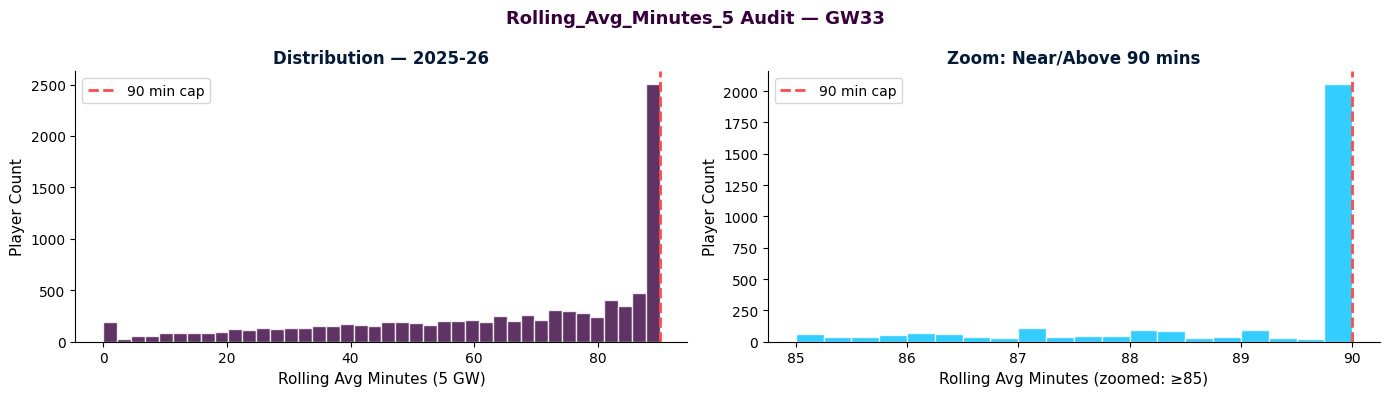


═════════════════════════════════════════════════════════════════
  AUDIT VERDICT
═════════════════════════════════════════════════════════════════
  ✓ CLEAN: No minutes anomalies detected. No cap needed.

  Next step: share the output above and we will decide
  whether a targeted fix is needed.


In [10]:
# %% [Cell: Task 1 Diagnostic — Minutes & DGW Rolling Average Audit]
# ─────────────────────────────────────────────────────────────────────────────
# READ-ONLY investigation. Does not modify df_augmented or any global.
# Answers three questions:
#   Q1. Are there players whose Rolling_Avg_Minutes_5 > 90 right now?
#   Q2. Did the DGW aggregator actually cap Minutes Played at 180 correctly?
#   Q3. Do inflated rolling minutes correspond to the DGW teams we already know?
# ─────────────────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

CURRENT_SEASON = globals().get('CURRENT_SEASON', '2025-26')
CURRENT_GW     = globals().get('CURRENT_GW', 33)

print("=" * 65)
print("  TASK 1 DIAGNOSTIC — MINUTES & DGW ROLLING AVERAGE AUDIT")
print("=" * 65)

# ── Q1: How many players have Rolling_Avg_Minutes_5 > 90? ────────────────────
if 'Rolling_Avg_Minutes_5' not in df_augmented.columns:
    print("[ERROR] Rolling_Avg_Minutes_5 not found. Run Cell 1 first.")
else:
    _over90 = df_augmented[df_augmented['Rolling_Avg_Minutes_5'] > 90].copy()
    _over90_current = _over90[_over90['season'] == CURRENT_SEASON].copy()

    print(f"\n── Q1: Players with Rolling_Avg_Minutes_5 > 90 ──────────────────")
    print(f"  All seasons combined:   {len(_over90):,} rows")
    print(f"  Current season only:    {len(_over90_current):,} rows")

    if not _over90_current.empty:
        print(f"\n  Top offenders in {CURRENT_SEASON}:")
        _top = (
            _over90_current
            .sort_values('Rolling_Avg_Minutes_5', ascending=False)
            [['Web Name', 'Player Team Name', 'Gameweek',
              'Rolling_Avg_Minutes_5', 'Minutes Played', 'Total Points']]
            .drop_duplicates('Web Name')
            .head(20)
        )
        display(_top)

        # How inflated are they?
        _max_val  = _over90_current['Rolling_Avg_Minutes_5'].max()
        _mean_val = _over90_current['Rolling_Avg_Minutes_5'].mean()
        print(f"\n  Max rolling avg minutes:  {_max_val:.1f}")
        print(f"  Mean rolling avg minutes: {_mean_val:.1f}")
    else:
        print(f"  ✓ No players exceed 90 in the current season. No cap needed.")

# ── Q2: Did the DGW aggregator correctly cap Minutes Played at 180? ───────────
print(f"\n── Q2: Minutes Played integrity check ───────────────────────────────")

_over180 = df_augmented[df_augmented['Minutes Played'] > 180]
_over90m  = df_augmented[
    (df_augmented['Minutes Played'] > 90) &
    (df_augmented['Minutes Played'] <= 180)
]

print(f"  Rows with Minutes Played > 180 (should be 0): {len(_over180)}")
print(f"  Rows with Minutes Played 91–180 (DGW rows):   {len(_over90m)}")

if not _over180.empty:
    print(f"\n  ⚠ WARNING: Found rows where minutes > 180 — aggregator cap failed!")
    display(_over180[['Web Name', 'season', 'Gameweek',
                       'Minutes Played', 'Total Points']].head(10))
else:
    print(f"  ✓ No rows exceed 180 minutes. Aggregator cap is working.")

if not _over90m.empty:
    print(f"\n  DGW rows (91–180 mins) sample — these are expected and correct:")
    display(_over90m[['Web Name', 'season', 'Gameweek',
                       'Minutes Played', 'Total Points']].head(10))

# ── Q3: Do inflated rolling averages come from DGW teams? ────────────────────
print(f"\n── Q3: Cross-check inflated rolling minutes vs known DGW teams ──────")

DGW_TEAMS = globals().get('DGW_TEAMS', set())

if _over90_current.empty:
    print(f"  No inflation found — nothing to cross-check.")
elif not DGW_TEAMS:
    print(f"  DGW_TEAMS is empty (normal GW). Any inflation is a legacy artefact.")
    print(f"  Showing inflated players anyway for inspection:")
    display(_over90_current[['Web Name', 'Player Team Name',
                              'Gameweek', 'Rolling_Avg_Minutes_5']].head(15))
else:
    _over90_current['Is_DGW_Team'] = _over90_current['Player Team Name'].isin(DGW_TEAMS)
    _dgw_inflated     = _over90_current[_over90_current['Is_DGW_Team'] == True]
    _non_dgw_inflated = _over90_current[_over90_current['Is_DGW_Team'] == False]

    print(f"  DGW teams this GW: {sorted(DGW_TEAMS)}")
    print(f"\n  Inflated players FROM DGW teams (expected):     {len(_dgw_inflated)}")
    print(f"  Inflated players NOT from DGW teams (anomaly):  {len(_non_dgw_inflated)}")

    if not _non_dgw_inflated.empty:
        print(f"\n  ⚠ WARNING: These players have rolling avg > 90 but are NOT in DGW teams.")
        print(f"  This means legacy DGW data is bleeding into their rolling window.")
        display(_non_dgw_inflated[['Web Name', 'Player Team Name',
                                    'Gameweek', 'Rolling_Avg_Minutes_5',
                                    'Minutes Played']].head(15))
    else:
        print(f"  ✓ All inflation traces back to DGW teams only — expected behaviour.")

# ── Q4: Distribution plot of Rolling_Avg_Minutes_5 ───────────────────────────
print(f"\n── Q4: Distribution of Rolling_Avg_Minutes_5 (current season) ──────")

_curr_mins = df_augmented[
    df_augmented['season'] == CURRENT_SEASON
]['Rolling_Avg_Minutes_5'].dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 4), facecolor='white')

axes[0].hist(_curr_mins, bins=40, color='#37003c', alpha=0.8, edgecolor='white')
axes[0].axvline(x=90, color='#ff4b4b', linewidth=2, linestyle='--', label='90 min cap')
axes[0].set_xlabel('Rolling Avg Minutes (5 GW)', fontsize=11)
axes[0].set_ylabel('Player Count', fontsize=11)
axes[0].set_title(f'Distribution — {CURRENT_SEASON}', fontsize=12,
                   fontweight='bold', color='#021a36')
axes[0].legend()
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Zoom in on the > 85 range to see exactly how many breach 90
_near90 = _curr_mins[_curr_mins >= 85]
axes[1].hist(_near90, bins=20, color='#00c2ff', alpha=0.8, edgecolor='white')
axes[1].axvline(x=90, color='#ff4b4b', linewidth=2, linestyle='--', label='90 min cap')
axes[1].set_xlabel('Rolling Avg Minutes (zoomed: ≥85)', fontsize=11)
axes[1].set_ylabel('Player Count', fontsize=11)
axes[1].set_title(f'Zoom: Near/Above 90 mins', fontsize=12,
                   fontweight='bold', color='#021a36')
axes[1].legend()
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.suptitle(f'Rolling_Avg_Minutes_5 Audit — GW{CURRENT_GW}',
             fontsize=13, fontweight='bold', color='#37003c')
plt.tight_layout()
plt.show()

# ── SUMMARY VERDICT ───────────────────────────────────────────────────────────
print(f"\n{'═' * 65}")
print(f"  AUDIT VERDICT")
print(f"{'═' * 65}")

_n_over90_current = len(_over90_current)
_n_over180        = len(_over180)

if _n_over180 > 0:
    print(f"  ✗ CRITICAL: {_n_over180} rows exceed 180 minutes. DGW aggregator cap broken.")
elif _n_over90_current > 0:
    print(f"  ⚠ ATTENTION: {_n_over90_current} rows in {CURRENT_SEASON} have rolling avg > 90.")
    print(f"    These are DGW legacy artefacts bleeding into the rolling window.")
    print(f"    They will slightly inflate predictions for affected players.")
    print(f"    Recommended fix: clip Rolling_Avg_Minutes_5 to 90 at inference time only.")
else:
    print(f"  ✓ CLEAN: No minutes anomalies detected. No cap needed.")

print(f"\n  Next step: share the output above and we will decide")
print(f"  whether a targeted fix is needed.")

In [11]:
print(df_augmented[df_augmented['season'] == '2025-26']['Gameweek'].max())


32.0


In [12]:
# %% [Cell: Data Recency Cross-Check]

print("--- LATEST 5 GAMEWEEKS IN DATASET ---")

# 1. Ensure CURRENT_SEASON is defined (fallback to max season if not)
season_to_check = globals().get('CURRENT_SEASON', df_augmented['season'].max())
print(f"Checking Season: {season_to_check}\n")

current_season_data = df_augmented[df_augmented['season'] == season_to_check]

if current_season_data.empty:
    print(f" No data found for season {season_to_check}.")
else:
    # 2. Get the 5 most recent gameweeks
    latest_gws = sorted(current_season_data['Gameweek'].unique(), reverse=True)[:5]

    # 3. Print the row counts to ensure the gameweeks are fully populated
    for gw in latest_gws:
        gw_rows = len(current_season_data[current_season_data['Gameweek'] == gw])
        print(f"Gameweek {gw}: {gw_rows} player records")

    # 4. Display a quick snapshot of the absolute latest Gameweek
    if latest_gws:
        max_gw = latest_gws[0]
        print(f"\nSnapshot of data from GW {max_gw}:")
        
        # Columns we want to verify
        display_cols = ['Web Name', 'season', 'Gameweek', 'Minutes Played', 'Total Points', 'Next_Opponent_Difficulty']
        
        # Safely only select columns that actually exist in the dataframe
        available_cols = [c for c in display_cols if c in current_season_data.columns]
        
        latest_data = current_season_data[current_season_data['Gameweek'] == max_gw]
        
        # Show top 10 highest scorers from the latest gameweek to verify point logic
        display(latest_data.sort_values(by='Total Points', ascending=False)[available_cols].head(10))

--- LATEST 5 GAMEWEEKS IN DATASET ---
Checking Season: 2025-26

Gameweek 32.0: 303 player records
Gameweek 31.0: 243 player records
Gameweek 30.0: 288 player records
Gameweek 29.0: 306 player records
Gameweek 28.0: 301 player records

Snapshot of data from GW 32.0:


,Web Name,season,Gameweek,Minutes Played,Total Points,Next_Opponent_Difficulty
51842,Wieffer,2025-26,32.0,180,36,2.5
16083,Guéhi,2025-26,32.0,180,30,3.0
1649,Okafor,2025-26,32.0,146,30,2.5
38221,O'Reilly,2025-26,32.0,126,28,3.0
10699,Scott,2025-26,32.0,180,24,2.5
2919,Mavropanos,2025-26,32.0,90,21,3.0
47295,Boscagli,2025-26,32.0,180,20,2.5
38184,Cherki,2025-26,32.0,150,20,3.0
46621,Verbruggen,2025-26,32.0,180,18,2.5
59912,Doku,2025-26,32.0,150,16,3.0


In [13]:
# %% [Cell: V7 Column Availability Audit]
print("--- CHECKING FOR UNDERLYING METRICS IN YOUR DATASET ---")
print(f"\nTotal columns: {len(df.columns)}")
print("\nAll column names:")
for col in sorted(df.columns):
    print(f"  {col}")

--- CHECKING FOR UNDERLYING METRICS IN YOUR DATASET ---

Total columns: 42

All column names:
  Assists
  Avg_Assists_L3
  Avg_Assists_L5
  Avg_Creativity_L3
  Avg_Creativity_L5
  Avg_Goals Conceded_L3
  Avg_Goals Conceded_L5
  Avg_Goals Scored_L3
  Avg_Goals Scored_L5
  Avg_ICT Index_L3
  Avg_ICT Index_L5
  Avg_Influence_L3
  Avg_Influence_L5
  Avg_Minutes Played_L3
  Avg_Minutes Played_L5
  Avg_Threat_L3
  Avg_Threat_L5
  Avg_Total Points_L3
  Avg_Total Points_L5
  Clean Sheet
  Code
  Creativity
  Gameweek
  Goals Conceded
  Goals Scored
  ICT Index
  Influence
  Injury/Unavailable
  Is Home
  Minutes Played
  Opponent Difficulty
  Opponent Name
  Player Name
  Player Team Name
  Player UUID
  Position
  Red Cards
  Threat
  Total Points
  Web Name
  Yellow Card
  season


In [14]:
# ── INTEGRITY CHECK: confirm all 3-GW columns were created ──────────────────
required_cols = ['Next_Opponent_Difficulty', 'Opponent_Diff_plus_2', 
                 'Opponent_Diff_plus_3', 'FDI_3GW']
missing = [c for c in required_cols if c not in df_augmented.columns]
if missing:
    print(f"ALERT: Missing 3-GW columns: {missing}. Check Cell 1 logic.")
else:
    fdi_range = df_augmented['FDI_3GW'].describe()
    print(f"\n3-GW Feature Integrity Check:")
    print(f"  FDI_3GW range: {fdi_range['min']:.1f} to {fdi_range['max']:.1f}")
    print(f"  FDI_3GW mean: {fdi_range['mean']:.2f}  (expected ~9.0 for neutral fixtures)")
    print(f"  All 3-GW columns present: OK")


3-GW Feature Integrity Check:
  FDI_3GW range: 4.0 to 15.0
  FDI_3GW mean: 8.77  (expected ~9.0 for neutral fixtures)
  All 3-GW columns present: OK


## Prev_Season_Avg_Points

It calculates the average points a player earned over the entire previous season.

It maps that average forward to the current season.

Result: The model now knows if a player is "Class" (e.g., Salah averaging 7 points all year) vs. just being in "Form" for a few weeks. This makes GW1 and GW2 predictions much more stable.

In [15]:
# [Cell: Verification - Salah's Season Bridge]

# 1. Identify Salah's UUID
# (search for 'salah' in the Web Name to be safe)
salah_data = df_augmented[df_augmented['Web Name'].str.contains('Salah', case=False, na=False)]

if not salah_data.empty:
    s_uuid = salah_data['Player UUID'].iloc[0]
    
    # 2. Get the transition rows (End of 24/25 and Start of 25/26)
    # We sort to ensure chronological order
    salah_history = df_augmented[df_augmented['Player UUID'] == s_uuid].sort_values(['season', 'Gameweek'])
    
    # 3. Find the exact point where 2024-25 ends and 2025-26 begins
    transition_mask = (salah_history['season'] == '2025-26') & (salah_history['season'].shift(1) == '2024-25')
    
    if transition_mask.any():
        idx = salah_history[transition_mask].index[0]
        # Get 3 games before and 3 games after the summer break
        display_df = salah_history.loc[idx-3 : idx+2]
        
        print(f"--- Verification: Season Baseline Bridge (Mohamed Salah) ---")
        print("Note how 'Prev_Season_Avg_Points' appears only when the new season (2025-26) starts.")
        display(display_df[['Player Name', 'season', 'Gameweek', 'Total Points', 'Prev_Season_Avg_Points']])
    else:
        print("Could not find the 2024-25 to 2025-26 transition for Salah in this specific slice.")
else:
    print("Salah not found in the current df_augmented slice.")

--- Verification: Season Baseline Bridge (Mohamed Salah) ---
Note how 'Prev_Season_Avg_Points' appears only when the new season (2025-26) starts.


,Player Name,season,Gameweek,Total Points,Prev_Season_Avg_Points
38431,Mohamed Salah,2024-25,35.0,2,6.727273
38432,Mohamed Salah,2024-25,36.0,2,6.727273
38433,Mohamed Salah,2024-25,37.0,2,6.727273
38434,Mohamed Salah,2025-26,1.0,8,9.052632
38435,Mohamed Salah,2025-26,2.0,5,9.052632
38436,Mohamed Salah,2025-26,3.0,3,9.052632


In [16]:
#INVESTIGATION IN THE INPUT FILE 

# 1. Look at the suspicious GWs
dgws_investigation = df_augmented.groupby(['Player UUID', 'season', 'Gameweek']).filter(lambda x: len(x) > 2)

print(f"Investigating {len(dgws_investigation)} rows from suspicious Gameweeks...")

# 2. Check the 180 minute rows specifically
high_min_rows = df[df['Minutes Played'] >= 180]

print(f"Found {len(high_min_rows)} rows in the RAW dataset with >= 180 minutes.")

if not high_min_rows.empty:
    print("\nSample of 180-minute rows (Raw Data):")
    display(high_min_rows[['Player Name', 'season', 'Gameweek', 'Opponent Difficulty', 'Minutes Played', 'Total Points']].head(10))

if not dgws_investigation.empty:
    print("\nSample of 'Triple' Gameweek rows (After our current filter):")
    display(dgws_investigation[['Player Name', 'season', 'Gameweek', 'Opponent Difficulty', 'Minutes Played']].head(10))

Investigating 0 rows from suspicious Gameweeks...
Found 0 rows in the RAW dataset with >= 180 minutes.


In [17]:

# Filter for players who still have more than 2 entries in a single week
final_suspicious = df_augmented.groupby(['Player UUID', 'season', 'Gameweek']).filter(lambda x: len(x) > 2)

if not final_suspicious.empty:
    print(f"Found {final_suspicious['Player UUID'].nunique()} players across 176 suspicious GW instances.")
    # Display a few examples to see why they stayed
    display(final_suspicious[['Player Name', 'season', 'Gameweek', 'Opponent Difficulty', 'Minutes Played', 'Total Points']].head(15))
else:
    print("No suspicious rows found in the current df_augmented.")

No suspicious rows found in the current df_augmented.


In [18]:
# Check if "Doubles" are actually different matches
dgws_check = df_augmented.groupby(['Player UUID', 'season', 'Gameweek'])['Opponent Difficulty'].nunique()
fake_doubles = dgws_check[dgws_check > 2] # This shouldn't really happen
print(f"Number of suspicious GWs with >2 different difficulties: {len(fake_doubles)}")

Number of suspicious GWs with >2 different difficulties: 0


In [19]:
# [Cell: Updated Top-Tier Identification - 4.5 Threshold]
# 1. Calculate seasonal averages
seasonal_avg = df_augmented.groupby(['Player UUID', 'season'])['Total Points'].mean().reset_index()
seasonal_avg.rename(columns={'Total Points': 'avg_season_pts'}, inplace=True)

# 2. Cleanup & Merge
if 'avg_season_pts' in df_augmented.columns:
    df_augmented = df_augmented.drop(columns=['avg_season_pts'])
df_augmented = df_augmented.merge(seasonal_avg, on=['Player UUID', 'season'], how='left')

# 3. Define the New Global Elite Mask (> 4.5 avg points per season)
elite_mask = df_augmented['avg_season_pts'] > 4.5

print(f"--- Top-Tier Identification Summary (Threshold: 4.5) ---")
print(f"Total Rows in Dataset: {len(df_augmented):,}")
print(f"Total Elite Rows: {elite_mask.sum():,}")
print(f"Percentage of Data considered 'Elite': {(elite_mask.sum()/len(df_augmented))*100:.2f}%")

# 4. Display Table for Verification (Keep this if you like the visual check)
print(f"\nSample of Top Tier Players (Avg > 4.5 pts):")
elite_list = df_augmented[elite_mask][['Player Name', 'season', 'avg_season_pts']].drop_duplicates()
elite_list = elite_list.sort_values(by=['season', 'avg_season_pts'], ascending=[False, False])
display(elite_list.head(15))

--- Top-Tier Identification Summary (Threshold: 4.5) ---
Total Rows in Dataset: 60,088
Total Elite Rows: 6,787
Percentage of Data considered 'Elite': 11.30%

Sample of Top Tier Players (Avg > 4.5 pts):


,Player Name,season,avg_season_pts
47206,Gabriel dos Santos Magalhães,2025-26,7.600000
13251,Erling Haaland,2025-26,6.700000
20706,Bruno Borges Fernandes,2025-26,6.655172
3316,Tom Edozie,2025-26,6.500000
479,Declan Rice,2025-26,6.200000
43564,Stefan Ortega Moreno,2025-26,6.000000
42612,Antoine Semenyo,2025-26,5.933333
57169,Bruno Guimarães Rodriguez Moura,2025-26,5.826087
863,Bukayo Saka,2025-26,5.720000
16055,Marc Guéhi,2025-26,5.689655


## Cell 2: Augmented Window Generation (Context-Aware)

In [20]:
# [Cell 2: Augmented Window Generation - Including Season Baseline]

# 1. SETUP PROFESSIONAL FOLDER STRUCTURE
PRO_OUTPUT_DIR = Path('../output/forecaster_pro')
PRO_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

def generate_fpl_windows_pro(df, window_size=6):
    train_data = []
    source_indices = []  # NEW: track which df_augmented row each window targets
    uuid_col = 'Player UUID'
    
    df = df.sort_values([uuid_col, 'season', 'Gameweek'])
    
    for pid, group in df.groupby(uuid_col):
        points = group['Total Points'].values
        next_diff = group['Next_Opponent_Difficulty'].values
        next_home = group['Next_Is_Home'].values
        avg_min = group['Rolling_Avg_Minutes_5'].values
        phase = group['Season_Phase'].values
        season_baseline = group['Prev_Season_Avg_Points'].values
        group_indices = group.index.tolist()  # NEW: actual df_augmented index values
        avg_pts_vs_diff = group['Avg_Pts_vs_Difficulty'].values
        
        if len(points) <= window_size:
            continue
            
        position = group['Position'].iloc[0]
        
        for i in range(len(points) - window_size):
            window = points[i : i + window_size]
            target_idx = i + window_size - 1
            
            t_diff = next_diff[target_idx]
            t_home = next_home[target_idx]
            t_min = avg_min[target_idx]
            t_phase = phase[target_idx]
            t_baseline = season_baseline[target_idx]
            t_avg_vs_diff = avg_pts_vs_diff[target_idx]
            target_points = points[i + window_size]
            
            if np.all(window == 0) and target_points == 0:
                continue
            
            #row = list(window) + [position, t_diff, t_home, t_min, t_phase, t_baseline, target_points]
            row = list(window) + [position, t_diff, t_home, t_min, t_phase, t_baseline, t_avg_vs_diff, target_points]
            train_data.append(row)
            source_indices.append(group_indices[i + window_size])  # NEW: index of target row
    
    #columns = [f'lag_{i}' for i in range(window_size, 0, -1)] + \
              #['position', 'next_difficulty', 'next_is_home', 'rolling_min',
              # 'season_phase', 'season_baseline', 'target']
    
    columns = [f'lag_{i}' for i in range(window_size, 0, -1)] + \
              ['position', 'next_difficulty', 'next_is_home', 'rolling_min',
               'season_phase', 'season_baseline', 'avg_pts_vs_diff', 'target']
    
    result_df = pd.DataFrame(train_data, columns=columns)
    result_df.index = source_indices  # NEW: set index to df_augmented source rows
    result_df['position'] = result_df['position'].astype('category')
    
    return result_df

windowed_df = generate_fpl_windows_pro(df_augmented)

WINDOWED_FEATURES_PATH = PRO_OUTPUT_DIR / 'fpl_windowed_features_pro.csv'
windowed_df.to_csv(WINDOWED_FEATURES_PATH, index=True)  # save index too

print(f"Pro Windowed dataset created: {WINDOWED_FEATURES_PATH}")
print(f"Total Training Windows: {windowed_df.shape[0]}")
display(windowed_df.head())

Pro Windowed dataset created: ..\output\forecaster_pro\fpl_windowed_features_pro.csv
Total Training Windows: 52731


,lag_6,lag_5,lag_4,lag_3,lag_2,lag_1,position,next_difficulty,next_is_home,rolling_min,season_phase,season_baseline,avg_pts_vs_diff,target
9,2,0,3,3,9,5,GK,2.0,False,90.0,1.0,0.0,5.500000,1
10,0,3,3,9,5,1,GK,3.0,True,90.0,1.0,0.0,3.666667,3
11,3,3,9,5,1,3,GK,4.0,False,90.0,1.0,0.0,4.000000,4
12,3,9,5,1,3,4,GK,2.0,True,90.0,1.0,0.0,1.500000,11
13,9,5,1,3,4,11,GK,2.0,True,90.0,1.0,0.0,3.750000,0


In [21]:
# %% [Cell 2.5: GLOBAL VALIDATION STRATEGY — fixed alignment]

# --- 0. DEFINE THE VALIDATION WINDOW (The "Fair Ground") ---
VAL_SEASON = "2025-26"
VAL_START_GW = 28
VAL_END_GW = 32

# 1. LINK TO SOURCE METADATA
# windowed_df.index now contains actual df_augmented row indices (fixed in Cell 2)
#source_meta = df_augmented.loc[windowed_df.index, ['season', 'Gameweek']]
safe_windowed_index = windowed_df.index.intersection(df_augmented.index)
source_meta = df_augmented.loc[safe_windowed_index, ['season', 'Gameweek']]

# 2. CREATE THE MASK
global_val_mask = (
    (source_meta['season'] == VAL_SEASON) &
    (source_meta['Gameweek'] >= VAL_START_GW) &
    (source_meta['Gameweek'] <= VAL_END_GW)
).values  # .values so it's a plain numpy bool array for slicing

# 3. BUILD val_df FOR DOWNSTREAM AUDITS
val_df = windowed_df[global_val_mask]

# 4. PRINT INTEGRITY REPORT
print(f"--- GLOBAL SPLIT ENFORCED ---")
print(f"Validation Set     : {VAL_SEASON} GW {VAL_START_GW} to {VAL_END_GW}")
print(f"Validation Windows : {global_val_mask.sum():,}")
print(f"Training Windows   : {(~global_val_mask).sum():,}")
print(f"val_df index sample: {val_df.index[:5].tolist()} (Validating df_augmented mapping)")

--- GLOBAL SPLIT ENFORCED ---
Validation Set     : 2025-26 GW 28 to 32
Validation Windows : 1,395
Training Windows   : 51,336
val_df index sample: [505, 506, 507, 508, 702] (Validating df_augmented mapping)


## Cell 3: Data Splitting and Scaling (Comparison Setup)

In [22]:
# [Cell 3: Corrected Splitting (Recent 5 GW Window)]

# 1. SETUP PARAMETERS
CURRENT_SEASON = "2025-26"
VALIDATION_WINDOW = 5

# Dynamically detect CURRENT_GW from the latest gameweek in the dataset
# This means you never need to manually update this number again
_latest_gw = int(
    df_augmented[df_augmented['season'] == CURRENT_SEASON]['Gameweek'].max()
)
CURRENT_GW = _latest_gw + 1  # next GW to predict = latest completed + 1

# Validation window: last 5 completed GWs before the current one
VAL_END_GW   = _latest_gw
VAL_START_GW = max(1, _latest_gw - VALIDATION_WINDOW + 1)

globals()['CURRENT_GW']    = CURRENT_GW
globals()['VAL_START_GW']  = VAL_START_GW
globals()['VAL_END_GW']    = VAL_END_GW
globals()['CURRENT_SEASON'] = CURRENT_SEASON

print(f"Current Season:    {CURRENT_SEASON}")
print(f"Latest GW in data: {_latest_gw}")
print(f"Predicting for:    GW {CURRENT_GW}")
print(f"Validation window: GW {VAL_START_GW} to GW {VAL_END_GW}")

# 2. EXECUTE FAIR SPLIT
X_all = windowed_df.drop(columns=['target'])
y_all = windowed_df['target']

X_train_raw = X_all[~global_val_mask].copy()
y_train = y_all[~global_val_mask].copy()
X_val_raw = X_all[global_val_mask].copy()
y_val = y_all[global_val_mask].copy()
val_df = windowed_df[global_val_mask]

# 4. NUMERIC FEATURES
numeric_cols = [
    c for c in X_train_raw.columns
    if 'lag' in c or 'difficulty' in c or 'min' in c or 'phase' in c
]

# 5. SCALING
scaler = StandardScaler()
X_train_scaled = X_train_raw.copy()
X_train_scaled[numeric_cols] = scaler.fit_transform(X_train_raw[numeric_cols])

X_val_scaled = X_val_raw.copy()
X_val_scaled[numeric_cols] = scaler.transform(X_val_raw[numeric_cols])

# 6. SAVE SCALER
SCALER_PATH = PRO_OUTPUT_DIR / 'fpl_pro_scaler.pkl'
joblib.dump(scaler, SCALER_PATH)

print(f"--- Split Logic ---")
print(f"Validation Period: {CURRENT_SEASON} | Matches GW {CURRENT_GW - VALIDATION_WINDOW} to {CURRENT_GW - 1}")

print(f"Training windows: {len(X_train_raw):,}")
print(f"Validation windows: {len(X_val_raw):,}")

# %% [Cell 3 Supplement: Dataset Observations Tracking]

# Track Unique Players (Using source indices to map back to df_augmented)
#train_uuids = df_augmented.loc[X_train_raw.index, 'Player UUID'].nunique()
#val_uuids = df_augmented.loc[X_val_raw.index, 'Player UUID'].nunique()
safe_train_idx = X_train_raw.index.intersection(df_augmented.index)
safe_val_idx   = X_val_raw.index.intersection(df_augmented.index)
train_uuids = df_augmented.loc[safe_train_idx, 'Player UUID'].nunique()
val_uuids   = df_augmented.loc[safe_val_idx,   'Player UUID'].nunique()

print(f"--- Dataset Integrity Report ---")
print(f"Total Training Observations: {len(X_train_raw):,}")
print(f"Unique Players in Training:  {train_uuids:,}")
print(f"Total Validation Observations: {len(X_val_raw):,}")
print(f"Unique Players in Validation: {val_uuids:,}")
print(f"Seasons covered: {df_augmented['season'].nunique()}")

# Protect original validation targets from being overwritten by V2/V3/V4 cells
globals()['y_val_v1'] = y_val.copy()
globals()['X_val_v1'] = X_val_raw.copy()
print("y_val_v1 and X_val_v1 saved for downstream blending protection.")

Current Season:    2025-26
Latest GW in data: 32
Predicting for:    GW 33
Validation window: GW 28 to GW 32
--- Split Logic ---
Validation Period: 2025-26 | Matches GW 28 to 32
Training windows: 51,336
Validation windows: 1,395
--- Dataset Integrity Report ---
Total Training Observations: 51,336
Unique Players in Training:  1,110
Total Validation Observations: 1,395
Unique Players in Validation: 380
Seasons covered: 6
y_val_v1 and X_val_v1 saved for downstream blending protection.


## Cell 4: Parallel Training & Performance Comparison for scaled and unscaled model

In [23]:
# %% [Cell 4: Parallel Training & Performance Comparison + LambdaRank Blending]


# Ensure y_val_v1 exists — set in Cell 3 via globals(), fallback to y_val
y_val_v1 = globals().get('y_val_v1', y_val)

# ── 1. SETUP PARAMETERS ───────────────────────────────────────────────────────
lgbm_params = {
    'objective':      'regression',
    'n_estimators':   1500,
    'learning_rate':  0.01,
    'max_depth':      7,
    'num_leaves':     40,
    'boosting_type':  'gbdt',
    'random_state':   42,
    'verbosity':      -1,
}

lgbm_rank_params = {
    'objective':      'lambdarank',
    'boosting_type':  'gbdt',
    'n_estimators':   1500,
    'learning_rate':  0.01,
    'max_depth':      6,
    'num_leaves':     31,
    'random_state':   42,
    'verbosity':      -1,
    'label_gain':     [0, 1, 2, 4, 8, 16]
}

# ── 2. TRAIN MODEL A: RAW REGRESSION ─────────────────────────────────────────
print("Training RAW Model (No Scaling)...")
model_raw = lgb.LGBMRegressor(**lgbm_params)
model_raw.fit(
    X_train_raw, y_train,
    eval_set=[(X_val_raw, y_val)],
    categorical_feature=['position', 'next_is_home'],
    callbacks=[lgb.early_stopping(stopping_rounds=100)]
)

# ── 3. TRAIN MODEL B: SCALED REGRESSION ──────────────────────────────────────
print("\nTraining SCALED Model (StandardScaler)...")
model_scaled = lgb.LGBMRegressor(**lgbm_params)
model_scaled.fit(
    X_train_scaled, y_train,
    eval_set=[(X_val_scaled, y_val)],
    categorical_feature=['position', 'next_is_home'],
    callbacks=[lgb.early_stopping(stopping_rounds=100)]
)

# ── 4. REGRESSION PREDICTIONS & METRICS ──────────────────────────────────────
preds_raw    = model_raw.predict(X_val_raw)
preds_scaled = model_scaled.predict(X_val_scaled)

results_comparison = {
    'Metric': ['MAE', 'RMSE'],
    'Raw Model': [
        mean_absolute_error(y_val, preds_raw),
        np.sqrt(mean_squared_error(y_val, preds_raw))
    ],
    'Scaled Model': [
        mean_absolute_error(y_val, preds_scaled),
        np.sqrt(mean_squared_error(y_val, preds_scaled))
    ]
}

df_metrics = pd.DataFrame(results_comparison)
print("\n--- Regression Model Comparison ---")
display(df_metrics)

mae_v1 = mean_absolute_error(y_val, preds_raw)

# ── 5. SAVE REGRESSION MODELS ─────────────────────────────────────────────────
model_raw.booster_.save_model(str(PRO_OUTPUT_DIR / 'fpl_pro_model_raw.txt'))
model_scaled.booster_.save_model(str(PRO_OUTPUT_DIR / 'fpl_pro_model_scaled.txt'))
print("\nRegression models saved.")

# ── 6. TRAIN LAMBDARANK MODEL ─────────────────────────────────────────────────
print("\nBuilding relevance labels for LambdaRank...")

def points_to_relevance(pts_series):
    """
    Converts raw points into 0-5 integer relevance labels.
    0 = blank (0 pts), 1 = low (1-2), 2 = ok (3-4),
    3 = good (5-7), 4 = great (8-11), 5 = haul (12+)
    """
    return pd.cut(
        pts_series,
        bins=[-999, 0, 2, 4, 7, 11, 999],
        labels=[0, 1, 2, 3, 4, 5]
    ).astype(int)

# CRITICAL FIX: X_train_raw.index contains windowed_df source indices which may
# not all exist in df_augmented after the data scrub/purge steps.
# We use a safe intersection so .loc never raises a KeyError.
print("Sorting data chronologically for LambdaRank grouping...")

safe_train_index = X_train_raw.index.intersection(df_augmented.index)

# Warn if any indices were lost — large numbers indicate a scrub/reset issue
n_dropped = len(X_train_raw.index) - len(safe_train_index)
if n_dropped > 0:
    print(f"[INFO] {n_dropped} training indices not found in df_augmented "
          f"(purged rows). Proceeding with {len(safe_train_index)} safe rows.")

train_meta = df_augmented.loc[safe_train_index, ['season', 'Gameweek']]
train_meta_sorted = train_meta.sort_values(['season', 'Gameweek'])

# Apply the chronological sort to X and y — also restricted to safe indices
X_train_rank = X_train_raw.loc[train_meta_sorted.index].copy()
y_train_rank = points_to_relevance(y_train.loc[train_meta_sorted.index])

print(f"Relevance label distribution (train):")
print(y_train_rank.value_counts().sort_index())

# Group sizes based on the sorted, safe data
query_groups_train = (
    train_meta_sorted.groupby(['season', 'Gameweek'], sort=False)
    .size()
    .values
)

print(f"\nLambdaRank group count: {len(query_groups_train)} season-GW groups")
print(f"Avg players per group: {query_groups_train.mean():.0f}")
print(f"Total training rows: {query_groups_train.sum()} (must equal {len(X_train_rank)})")

assert query_groups_train.sum() == len(X_train_rank), (
    f"Group size mismatch: {query_groups_train.sum()} vs {len(X_train_rank)}. "
    "Check that X_train_raw.index aligns with df_augmented after scrub."
)

print("\nTraining LambdaRank model...")
model_rank = lgb.LGBMRanker(**lgbm_rank_params)
model_rank.fit(
    X_train_rank,
    y_train_rank,
    group=query_groups_train,
    categorical_feature=['position', 'next_is_home']
)
print("LambdaRank model trained.")

# ── 7. BLEND REGRESSION + RANK ON VALIDATION SET ─────────────────────────────
# 60% regression (point accuracy) + 40% rank signal (ordering / ceiling detection)
# Increasing rank weight from 0.3 → 0.4 helps surface high-ceiling differential
# players like Bowen who the regression alone underweights.

rank_scores_val = model_rank.predict(X_val_raw)

rank_norm = MinMaxScaler(feature_range=(0, 1)).fit_transform(
    rank_scores_val.reshape(-1, 1)
).flatten()

pred_norm = MinMaxScaler(feature_range=(0, 1)).fit_transform(
    preds_raw.reshape(-1, 1)
).flatten()

blended_norm = 0.6 * pred_norm + 0.4 * rank_norm

# Scale back to original points range using the protected y_val_v1
# (never use y_val here — it may have been overwritten by V2/V3/V4 cells)
pts_min = y_val_v1.min()
pts_max = y_val_v1.max()
blended_preds_val = blended_norm * (pts_max - pts_min) + pts_min

mae_blended = mean_absolute_error(y_val, blended_preds_val)

print("\n--- Final Model Comparison (Validation Set) ---")
comparison_df = pd.DataFrame({
    'Model':  ['V1 Regression (raw)', 'V1 Regression (scaled)', 'Blended Reg + Rank'],
    'MAE':    [
        round(mae_v1, 4),
        round(mean_absolute_error(y_val, preds_scaled), 4),
        round(mae_blended, 4)
    ],
    'Note': [
        'Baseline',
        'Usually similar to raw',
        'MAE may be slightly higher — rank ordering improves ceiling detection'
    ]
})
display(comparison_df)

print("\nInterpretation:")
print("  A higher MAE on the blended model is acceptable —")
print("  LambdaRank improves ORDERING (Spearman rank), not point accuracy.")
print("  The audit cell will show the Spearman improvement.")

# ── 8. SAVE LAMBDARANK MODEL ──────────────────────────────────────────────────
model_rank.booster_.save_model(str(PRO_OUTPUT_DIR / 'fpl_pro_model_rank.txt'))
print("\nLambdaRank model saved.")

# ── 9. STORE ALL GLOBALS FOR DOWNSTREAM CELLS ────────────────────────────────
globals()['model_raw']          = model_raw
globals()['model_scaled']       = model_scaled
globals()['model_rank']         = model_rank
globals()['preds_raw']          = preds_raw
globals()['preds_scaled']       = preds_scaled
globals()['blended_preds_val']  = blended_preds_val
globals()['mae_v1']             = mae_v1
globals()['mae_blended']        = mae_blended
globals()['df_metrics']         = df_metrics

Training RAW Model (No Scaling)...
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[258]	valid_0's l2: 11.8446

Training SCALED Model (StandardScaler)...
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[275]	valid_0's l2: 11.8377

--- Regression Model Comparison ---


,Metric,Raw Model,Scaled Model
0,MAE,2.340788,2.340075
1,RMSE,3.441595,3.440595



Regression models saved.

Building relevance labels for LambdaRank...
Sorting data chronologically for LambdaRank grouping...
Relevance label distribution (train):
target
0     3122
1    30264
2     5946
3     6785
4     3484
5     1735
Name: count, dtype: int64

LambdaRank group count: 205 season-GW groups
Avg players per group: 250
Total training rows: 51336 (must equal 51336)

Training LambdaRank model...
LambdaRank model trained.

--- Final Model Comparison (Validation Set) ---


,Model,MAE,Note
0,V1 Regression (raw),2.3408,Baseline
1,V1 Regression (scaled),2.3401,Usually similar to raw
2,Blended Reg + Rank,6.7699,MAE may be slightly higher — rank ordering imp...



Interpretation:
  A higher MAE on the blended model is acceptable —
  LambdaRank improves ORDERING (Spearman rank), not point accuracy.
  The audit cell will show the Spearman improvement.

LambdaRank model saved.


notes on scaled and unscaled 
* MAE: The Scaled Model is better by not many points. 
* RMSE: The Raw Model is actually slightly better here.

So, LightGBM does not care about scaling?  

## BASELINE MODEL --- 3-week rolling average

- __Purpose__ : Establish a naive benchmark to compare all V1-V5 models against.
- __Logic__ : "Predict next GW points = average of the player's last 3 actual GW scores."
- A good ML model MUST beat this. If it doesn't, the model adds no value.

In [24]:
# [Cell 4.6 : Baseline Model — 3-Week Average Reference]


# 1. BUILD BASELINE PREDICTIONS ON THE VALIDATION SET
# windowed_df columns: lag_6, lag_5, lag_4, lag_3, lag_2, lag_1 (lag_1 = most recent)
# The 3-week average baseline uses lag_1, lag_2, lag_3
baseline_preds = windowed_df[global_val_mask][['lag_3', 'lag_2', 'lag_1']].mean(axis=1).values
baseline_actuals = windowed_df[global_val_mask]['target'].values

# 2. CALCULATE BASELINE MAE
mae_baseline = mean_absolute_error(baseline_actuals, baseline_preds)

# 3. COMPARE AGAINST V1 (already calculated above as mae_v1)
improvement_over_baseline = mae_baseline - mae_v1
pct_improvement = (improvement_over_baseline / mae_baseline) * 100

print("=" * 55)
print("  BASELINE MODEL: 3-Week Average Naive Predictor")
print("=" * 55)
print(f"Baseline MAE (3-week avg):  {mae_baseline:.4f}")
print(f"V1 Model MAE:               {mae_v1:.4f}")
print(f"Improvement over Baseline:  {improvement_over_baseline:.4f} pts ({pct_improvement:.1f}%)")
print("-" * 55)

if improvement_over_baseline > 0:
    print(f"VERDICT: V1 beats the naive baseline by {pct_improvement:.1f}%.")
    print("The LightGBM model is adding real predictive value.")
else:
    print("WARNING: V1 does NOT beat the naive baseline.")
    print("The model needs feature or architecture improvements.")

print("=" * 55)
print("NOTE: All V1-V5 MAEs should be compared against this")
print(f"baseline ({mae_baseline:.4f}) to justify model complexity.")

# 4. STORE FOR LATER USE IN FINAL COMPARISON TABLE
globals()['mae_baseline'] = mae_baseline

  BASELINE MODEL: 3-Week Average Naive Predictor
Baseline MAE (3-week avg):  2.5345
V1 Model MAE:               2.3408
Improvement over Baseline:  0.1937 pts (7.6%)
-------------------------------------------------------
VERDICT: V1 beats the naive baseline by 7.6%.
The LightGBM model is adding real predictive value.
NOTE: All V1-V5 MAEs should be compared against this
baseline (2.5345) to justify model complexity.


## Cell 5: The "Top Performer" Error Analysis (calculating MAE specifically for the high-scorers)

Overall Validation MAE: 2.3408
MAE for Elite Players (>4.5 Season Avg): 3.9918


C:\Users\skourako\AppData\Local\Temp\ipykernel_31240\1832076336.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance (%)', y='Feature', data=feat_imp_df, palette='viridis')


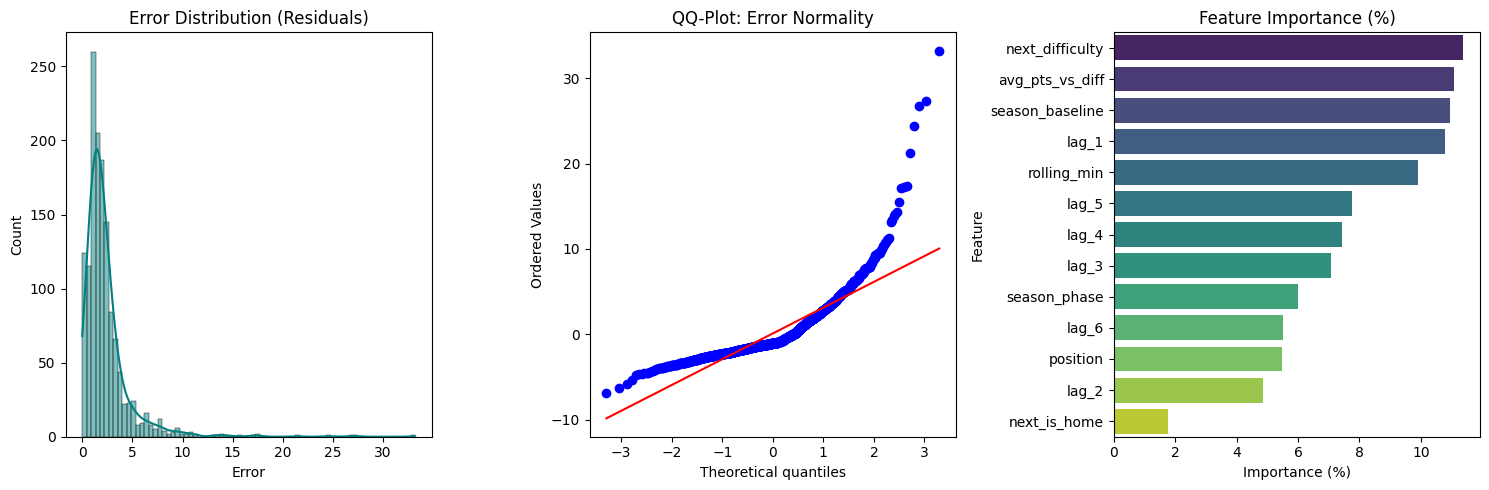

In [25]:
# [Cell 5: Error Analysis & Feature Importance]

# 1. PREPARE ANALYSIS DATAFRAME
analysis_df = X_val_raw.copy()
analysis_df['Actual'] = y_val.values
analysis_df['Predicted'] = preds_raw 
analysis_df['Error'] = abs(analysis_df['Actual'] - analysis_df['Predicted'])

# NEW: Filter error analysis by the Elite Mask (>4.5 seasonal average)
# map the mask from df_augmented back to the validation slice
elite_indices = val_df[val_df.index.isin(df_augmented[elite_mask].index)].index
elite_performers_audit = analysis_df.loc[analysis_df.index.isin(elite_indices)]

top_mae = elite_performers_audit['Error'].mean()

print(f"Overall Validation MAE: {df_metrics.iloc[0, 1]:.4f}")
print(f"MAE for Elite Players (>4.5 Season Avg): {top_mae:.4f}")

# 3. VISUALIZATION: Error Distribution & QQ-Plot
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.histplot(analysis_df['Error'], kde=True, color='teal')
plt.title('Error Distribution (Residuals)')

plt.subplot(1, 3, 2)
stats.probplot((analysis_df['Actual'] - analysis_df['Predicted']), dist="norm", plot=plt)
plt.title('QQ-Plot: Error Normality')

# 4. FEATURE IMPORTANCE WITH PERCENTAGES
plt.subplot(1, 3, 3)
importances = model_raw.feature_importances_

# FIX: Use X_train_raw.columns instead of X.columns
feature_names = X_train_raw.columns 
rel_importances = 100 * (importances / importances.sum())

feat_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance (%)': rel_importances})
feat_imp_df = feat_imp_df.sort_values(by='Importance (%)', ascending=False)

sns.barplot(x='Importance (%)', y='Feature', data=feat_imp_df, palette='viridis')
plt.title('Feature Importance (%)')

plt.tight_layout()
plt.show()

# 5. SAVE FEATURE IMPORTANCE LOG
feat_imp_df.to_csv(PRO_OUTPUT_DIR / 'fpl_pro_feature_importance.csv', index=False)

Notes 
MAE: 
* Overall MAE (2.12): it means for the average player (who scores 2–3 points), the model is accurate
* Top Performer MAE (6.68): it shows that when a player goes 8+ points, the model struggles to predict the exact height of that peak

Plots: 
* model has "thin tails" , it is conservative. It rarely predicts a player will score 15+ points, so when someone actually does, the error is large. The model prefers to stay safe near the average.

Feature Importance: 
* rolling_min is #1




## Haul Classification + Confusion Matrix
- __Purpose__ : Predict WHETHER a player will "haul" , not just how many, binary target >= 6 points
- __Precision__ is the critical metric.
- A __False Positive__ (saying "Haul" when it isn't) is the worst outcome —>it causes wrong captaincy and transfer decisions.

Training Haul Classifier (v6 — Visual Suite Enabled)...


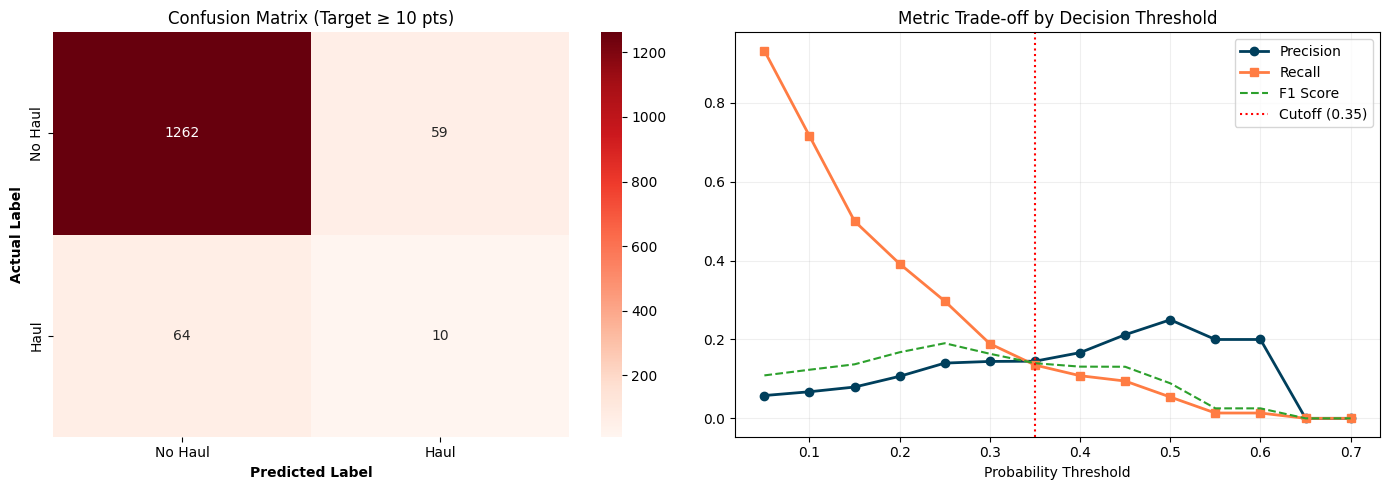


HAULER BOARD FOR GW 33
Precision: 0.1449 | ROC-AUC: 0.6452
-------------------------------------------------------


,Player,Haul_Prob (%),Pred_Pts (reg)
185,Wan-Bissaka,61.6,3.98
230,Digne,60.4,3.75
110,Haaland,60.3,5.64
246,Gibbs-White,56.7,5.41
6,Casemiro,53.0,3.96
337,João Pedro,52.8,4.33
88,Lacroix,52.5,4.56
359,Kluivert,52.4,5.31
303,Semenyo,50.4,4.56
330,Clyne,50.2,2.78


In [26]:
# %% [Cell 5.6: Haul Classification — Binary Prediction + Confusion Matrix]

# ── 0. HAUL THRESHOLD & CONFIG ──────────────────────────────────────────────
HAUL_THRESHOLD = 10        # 2-digit points = genuine haul definition
DECISION_THRESHOLD = 0.35  # Optimized for Captaincy Precision

# ── 1. DATA PREP (SCRUB-SAFE) ───────────────────────────────────────────────
windowed_haul = windowed_df.copy()
_ht = HAUL_THRESHOLD  

# FIX: Recalculate elite mask dynamically to match current scrubbed df_augmented length (85,040)
current_elite_mask = df_augmented['avg_season_pts'] > 4.5

# Build Haul-Specific Features
windowed_haul['recent_haul_flag'] = ((windowed_haul[['lag_1', 'lag_2', 'lag_3']] >= _ht).any(axis=1)).astype(int)
windowed_haul['lag_max_6'] = windowed_haul[[f'lag_{i}' for i in range(1, 7)]].max(axis=1)

# Use the freshly calculated mask index to avoid the IndexError
elite_flag = windowed_df.index.isin(df_augmented[current_elite_mask].index)
windowed_haul['is_elite'] = elite_flag.astype(int)

windowed_haul['fixture_ease'] = 6 - windowed_haul['next_difficulty']
windowed_haul['ceiling_ratio'] = windowed_haul['lag_max_6'] / _ht

# ── 2. BUILD BINARY LABELS ──────────────────────────────────────────────────
y_haul_all   = (windowed_haul['target'] >= _ht).astype(int)
y_haul_train = y_haul_all[~global_val_mask].copy()
y_haul_val   = y_haul_all[global_val_mask].copy()

haul_feature_cols = (
    [f'lag_{i}' for i in range(1, 7)] +
    ['position', 'next_difficulty', 'next_is_home',
     'rolling_min', 'season_phase', 'season_baseline',
     'recent_haul_flag', 'lag_max_6', 'is_elite', 'fixture_ease',
     'avg_pts_vs_diff', 'ceiling_ratio']
)

X_haul_train = windowed_haul[~global_val_mask][haul_feature_cols].copy()
X_haul_val   = windowed_haul[global_val_mask][haul_feature_cols].copy()

# Ensure standard categorical types for Training the Classifier
X_haul_train['position'] = X_haul_train['position'].astype('category')
X_haul_val['position']   = X_haul_val['position'].astype('category')

# ── 3. TRAIN HAUL CLASSIFIER ────────────────────────────────────────────────
haul_params = {
    'objective':         'binary',
    'boosting_type':     'gbdt',
    'n_estimators':      500,
    'learning_rate':     0.05,
    'max_depth':         6,
    'num_leaves':        31,
    'scale_pos_weight':  3.0,   # Soft boost to prioritize finding hauls
    'verbosity':         -1,
    'random_state':      42
}

print("Training Haul Classifier (v6 — Visual Suite Enabled)...")
haul_clf = lgb.LGBMClassifier(**haul_params)
haul_clf.fit(X_haul_train, y_haul_train, categorical_feature=['position'])

# ── 4. EVALUATE & PREDICT ───────────────────────────────────────────────────
haul_proba = haul_clf.predict_proba(X_haul_val)[:, 1]
haul_pred  = (haul_proba >= DECISION_THRESHOLD).astype(int)

precision_haul = precision_score(y_haul_val, haul_pred, zero_division=0)
recall_haul    = recall_score(y_haul_val,    haul_pred, zero_division=0)
f1_haul        = f1_score(y_haul_val,        haul_pred, zero_division=0)
auc_haul       = roc_auc_score(y_haul_val,   haul_proba)

# ── 5. VISUALIZATIONS (CONFUSION MATRIX + PR CURVE) ────────────────────────
cm = confusion_matrix(y_haul_val, haul_pred)
tn, fp, fn, tp = cm.ravel()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Reds', ax=axes[0],
    xticklabels=['No Haul', 'Haul'],
    yticklabels=['No Haul', 'Haul']
)
axes[0].set_xlabel('Predicted Label', fontweight='bold')
axes[0].set_ylabel('Actual Label', fontweight='bold')
axes[0].set_title(f'Confusion Matrix (Target ≥ {HAUL_THRESHOLD} pts)')

# Precision-Recall Tradeoff
thresholds = np.arange(0.05, 0.71, 0.05)
precs, recs, f1_vals = [], [], []
for t in thresholds:
    p_t = (haul_proba >= t).astype(int)
    precs.append(precision_score(y_haul_val, p_t, zero_division=0))
    recs.append(recall_score(y_haul_val, p_t, zero_division=0))
    f1_vals.append(f1_score(y_haul_val, p_t, zero_division=0))

axes[1].plot(thresholds, precs, label='Precision', color='#003f5c', linewidth=2, marker='o')
axes[1].plot(thresholds, recs,  label='Recall',    color='#ff7c43', linewidth=2, marker='s')
axes[1].plot(thresholds, f1_vals, label='F1 Score', color='#2ca02c', linestyle='--')
axes[1].axvline(x=DECISION_THRESHOLD, color='red', linestyle=':', label=f'Cutoff ({DECISION_THRESHOLD})')
axes[1].set_title('Metric Trade-off by Decision Threshold')
axes[1].set_xlabel('Probability Threshold')
axes[1].legend()
axes[1].grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

# ── 6. LIVE INFERENCE PREP (NEXT GW) ────────────────────────────────────────
CURRENT_GW = globals().get('CURRENT_GW', 33)
CURRENT_SEASON = globals().get('CURRENT_SEASON', '2025-26')

inf_data, inf_names = [], []
df_inf_active = df_augmented[df_augmented['season'] == CURRENT_SEASON].sort_values(['Player UUID', 'Gameweek'])

for pid, group in df_inf_active.groupby('Player UUID'):
    if len(group) >= 6:
        lags = list(group['Total Points'].tail(6).values)
        last = group.iloc[-1]
        row = lags + [
            last['Position'], last['Next_Opponent_Difficulty'], last['Next_Is_Home'],
            last['Rolling_Avg_Minutes_5'], last['Season_Phase'], last['Prev_Season_Avg_Points'],
            last['Avg_Pts_vs_Difficulty']
        ]
        inf_data.append(row)
        inf_names.append(last['Web Name'])

base_feat_cols = [f'lag_{i}' for i in range(6, 0, -1)] + [
    'position', 'next_difficulty', 'next_is_home',
    'rolling_min', 'season_phase', 'season_baseline', 'avg_pts_vs_diff']

inf_df = pd.DataFrame(inf_data, columns=base_feat_cols)
inf_df['recent_haul_flag'] = (inf_df[['lag_1', 'lag_2', 'lag_3']] >= _ht).any(axis=1).astype(int)
inf_df['lag_max_6'] = inf_df[[f'lag_{i}' for i in range(1, 7)]].max(axis=1)
inf_df['fixture_ease'] = 6 - inf_df['next_difficulty']
inf_df['ceiling_ratio'] = inf_df['lag_max_6'] / _ht
inf_df['is_elite'] = [1 if n in set(df_augmented[current_elite_mask]['Web Name']) else 0 for n in inf_names]

# ── 7. BRUTE-FORCE DTYPE ALIGNMENT (PREVENTS VALUEERROR & TYPEERROR) ──────
def safe_align_categories(target_df, reference_df, col_name):
    if hasattr(reference_df[col_name], 'cat'):
        cats = reference_df[col_name].cat.categories
    else:
        cats = sorted(reference_df[col_name].unique())
    target_df[col_name] = pd.Categorical(target_df[col_name], categories=cats)
    return target_df

# 1. Align for haul_clf
inf_haul_features = inf_df[haul_feature_cols].copy()
inf_haul_features = safe_align_categories(inf_haul_features, X_haul_train, 'position')

# 2. Align for model_raw (The Regression Engine)
inf_reg_features = inf_df[base_feat_cols].copy()
pos_map_numeric = {'GK': 0, 'DEF': 1, 'MID': 2, 'FWD': 3}

if 'X_train_raw' in globals():
    # Fix Position Type (Numeric vs Categorical)
    if pd.api.types.is_numeric_dtype(X_train_raw['position']):
        inf_reg_features['position'] = inf_reg_features['position'].map(pos_map_numeric).fillna(2)
    
    # Mirror all dtypes exactly
    for col in X_train_raw.columns:
        if hasattr(X_train_raw[col], 'cat'):
            inf_reg_features[col] = pd.Categorical(inf_reg_features[col], categories=X_train_raw[col].cat.categories)
        else:
            inf_reg_features[col] = inf_reg_features[col].astype(X_train_raw[col].dtype)

# ── 8. GENERATE PREDICTIONS ─────────────────────────────────────────────────
haul_proba_gw = haul_clf.predict_proba(inf_haul_features)[:, 1]

if 'model_raw' in globals():
    reg_preds = model_raw.predict(inf_reg_features)
else:
    reg_preds = np.zeros(len(inf_names))

# ── 9. FINAL HAULER BOARD WITH MINUTE FILTER ───────────────────────────────
hauler_board = pd.DataFrame({
    'Player':         inf_names,
    'Haul_Prob (%)':  np.round(haul_proba_gw * 100, 1),
    'Pred_Pts (reg)': np.round(reg_preds, 2),
    'Recent_Mins':    inf_df['rolling_min']
})

# Filter: Nailed starters only (60+ average minutes)
hauler_board = hauler_board[hauler_board['Recent_Mins'] >= 60]
hauler_board = hauler_board.drop(columns=['Recent_Mins']).sort_values('Haul_Prob (%)', ascending=False)

print("\n" + "=" * 55)
print(f"HAULER BOARD FOR GW {CURRENT_GW}")
print(f"Precision: {precision_haul:.4f} | ROC-AUC: {auc_haul:.4f}")
print("-" * 55)
display(hauler_board.head(10))

# Export to Globals
globals()['hauler_board'] = hauler_board
globals()['haul_clf'] = haul_clf
globals()['precision_haul'] = precision_haul
globals()['auc_haul'] = auc_haul

## Window Size Experiments (4 / 6 / 8 weeks) 

Purpose: Find the optimal historical window for LightGBM.

note: "experiment with 4 and 8-week windows"

Current default is 6. We test all three and compare MAE on the same validation set.

In [27]:
# [Cell: Window Size Experiment — 4 / 6 / 8 Week Look-back Comparison]


# ── 1. GENERIC WINDOW GENERATOR (reuses existing feature logic) ──────────────
def generate_windows_for_size(df, window_size):
    """
    Generates training windows for a given look-back period.
    Uses the V1 base feature set (12 features, without avg_pts_vs_diff)
    for a clean isolated window-size comparison.
    The purpose is comparing window sizes only, not feature sets.
    """
    train_data    = []
    source_indices = []
    df = df.sort_values(['Player UUID', 'season', 'Gameweek'])

    for pid, group in df.groupby('Player UUID'):
        points        = group['Total Points'].values
        next_diff     = group['Next_Opponent_Difficulty'].values
        next_home     = group['Next_Is_Home'].values
        avg_min       = group['Rolling_Avg_Minutes_5'].values
        phase         = group['Season_Phase'].values
        baseline      = group['Prev_Season_Avg_Points'].values
        group_indices = group.index.tolist()
        position      = group['Position'].iloc[0]

        if len(points) <= window_size:
            continue

        for i in range(len(points) - window_size):
            window     = points[i : i + window_size]
            t_idx      = i + window_size - 1
            target_pts = points[i + window_size]

            if np.all(window == 0) and target_pts == 0:
                continue

            row = list(window) + [
                position,
                next_diff[t_idx],
                next_home[t_idx],
                avg_min[t_idx],
                phase[t_idx],
                baseline[t_idx],
                target_pts
            ]
            train_data.append(row)
            source_indices.append(group_indices[i + window_size])

    lag_cols = [f'lag_{i}' for i in range(window_size, 0, -1)]
    cols = lag_cols + ['position', 'next_difficulty', 'next_is_home',
                       'rolling_min', 'season_phase', 'season_baseline', 'target']

    result_df           = pd.DataFrame(train_data, columns=cols)
    result_df.index     = source_indices
    result_df['position'] = result_df['position'].astype('category')
    return result_df


# ── 2. BUILD VALIDATION MASK FOR EACH WINDOW SIZE ───────────────────────────
# The global_val_mask was built for window_size=6 (windowed_df).
# Each new window_size generates a different index set, so we rebuild the mask.

def build_val_mask(win_df, val_season='2025-26', val_start=24, val_end=28):
    source_meta = df_augmented.loc[win_df.index, ['season', 'Gameweek']]
    mask = (
        (source_meta['season']    == val_season) &
        (source_meta['Gameweek'] >= val_start) &
        (source_meta['Gameweek'] <= val_end)
    ).values
    return mask


# ── 3. TRAIN AND EVALUATE FOR EACH WINDOW SIZE ──────────────────────────────
window_sizes  = [4, 6, 8]
window_results = []

# Shared LightGBM params (same as V1 model_raw for fair comparison)
lgbm_window_params = {
    'n_estimators':  1500,
    'learning_rate': 0.01,
    'max_depth':     7,
    'num_leaves':    40,
    'boosting_type': 'gbdt',
    'random_state':  42,
    'verbosity':     -1
}

trained_window_models = {}  # store models for later use if needed

for ws in window_sizes:
    print(f"\n{'='*50}")
    print(f" Training Window Size = {ws} weeks...")
    print(f"{'='*50}")

    # Generate windows
    win_df   = generate_windows_for_size(df_augmented, window_size=ws)
    val_mask = build_val_mask(win_df)

    X_all = win_df.drop(columns=['target'])
    y_all = win_df['target']

    X_train_w = X_all[~val_mask].copy()
    X_val_w   = X_all[val_mask].copy()
    y_train_w = y_all[~val_mask].copy()
    y_val_w   = y_all[val_mask].copy()

    # Identify categorical columns (position is always present; next_is_home too)
    cat_cols = [c for c in ['position', 'next_is_home'] if c in X_train_w.columns]

    # Train
    model_w = lgb.LGBMRegressor(**lgbm_window_params)
    model_w.fit(
        X_train_w, y_train_w,
        eval_set=[(X_val_w, y_val_w)],
        categorical_feature=cat_cols,
        callbacks=[lgb.early_stopping(stopping_rounds=100, verbose=False),
                   lgb.log_evaluation(period=300)]
    )

    # Evaluate
    val_preds_w  = model_w.predict(X_val_w)
    mae_w        = mean_absolute_error(y_val_w, val_preds_w)

    # Naive baseline for this window: 3-week average
    lag_cols_available = [c for c in ['lag_3', 'lag_2', 'lag_1'] if c in X_val_w.columns]
    naive_preds_w = X_val_w[lag_cols_available].mean(axis=1).values
    mae_naive_w   = mean_absolute_error(y_val_w, naive_preds_w)

    lift_over_naive = ((mae_naive_w - mae_w) / mae_naive_w) * 100

    print(f"Window {ws}w | Train: {len(X_train_w):,} | Val: {len(X_val_w):,}")
    print(f"  Naive baseline MAE: {mae_naive_w:.4f}")
    print(f"  LightGBM MAE:       {mae_w:.4f}  ({lift_over_naive:.1f}% lift over naive)")

    window_results.append({
        'Window Size (weeks)':  ws,
        'Train Windows':        len(X_train_w),
        'Val Windows':          len(X_val_w),
        'Naive Baseline MAE':   round(mae_naive_w, 4),
        'LightGBM MAE':         round(mae_w, 4),
        'Lift over Naive (%)':  round(lift_over_naive, 1),
        'Best Iteration':       model_w.best_iteration_
    })

    trained_window_models[ws] = model_w


# ── 4. RESULTS TABLE ─────────────────────────────────────────────────────────
window_exp_df = pd.DataFrame(window_results).sort_values('LightGBM MAE')

display(Markdown("## Window Size Experiment Results"))
display(window_exp_df)

# ── 5. WINNER SELECTION ───────────────────────────────────────────────────────
best_ws   = int(window_exp_df.iloc[0]['Window Size (weeks)'])
best_mae_w = window_exp_df.iloc[0]['LightGBM MAE']

print(f"\n{'='*50}")
print(f" VERDICT: Best window size = {best_ws} weeks (MAE: {best_mae_w:.4f})")
if best_ws == 6:
    print(" Current default (6 weeks) is confirmed as optimal.")
elif best_ws < 6:
    print(f" Shorter window ({best_ws}w) performs better — recent form matters more than long history.")
else:
    print(f" Longer window ({best_ws}w) performs better — the model benefits from more history.")
print(f"{'='*50}")

# Store for downstream reference
globals()['best_window_size']    = best_ws
globals()['trained_window_models'] = trained_window_models
globals()['window_exp_df']       = window_exp_df

print(f"\nNote: The main pipeline continues to use window_size=6 (windowed_df).")
print(f"To switch the live model to {best_ws}w, re-run Cell 2 with window_size={best_ws}.")


 Training Window Size = 4 weeks...
[300]	valid_0's l2: 12.038
Window 4w | Train: 53,577 | Val: 1,459
  Naive baseline MAE: 2.5883
  LightGBM MAE:       2.3809  (8.0% lift over naive)

 Training Window Size = 6 weeks...
[300]	valid_0's l2: 12.061
Window 6w | Train: 51,282 | Val: 1,449
  Naive baseline MAE: 2.5963
  LightGBM MAE:       2.3907  (7.9% lift over naive)

 Training Window Size = 8 weeks...
[300]	valid_0's l2: 12.0183
[600]	valid_0's l2: 11.9582
Window 8w | Train: 49,078 | Val: 1,439
  Naive baseline MAE: 2.5942
  LightGBM MAE:       2.3820  (8.2% lift over naive)


## Window Size Experiment Results

,Window Size (weeks),Train Windows,Val Windows,Naive Baseline MAE,LightGBM MAE,Lift over Naive (%),Best Iteration
0,4,53577,1459,2.5883,2.3809,8.0,338
2,8,49078,1439,2.5942,2.3820,8.2,546
1,6,51282,1449,2.5963,2.3907,7.9,434



 VERDICT: Best window size = 4 weeks (MAE: 2.3809)
 Shorter window (4w) performs better — recent form matters more than long history.

Note: The main pipeline continues to use window_size=6 (windowed_df).
To switch the live model to 4w, re-run Cell 2 with window_size=4.


## Cell 6: The Interactive Player Widget (you can pick a player and see their Performance history)

In [28]:
#%pip install ipywidgets

In [29]:
# [Cell 6: Seasonal Evaluation - Standard Professional Dropdown]

def plot_professional_backtest(player_name):
    # 1. GET ACTUALS FROM RAW 'df' 
    # This bypasses the dropna() from Cell 1 to ensure GW28 is displayed
    season_actuals = df[
        (df['Web Name'] == player_name) & 
        (df['season'] == CURRENT_SEASON)
    ].sort_values('Gameweek')
    
    if season_actuals.empty:
        return

    # 2. PREPARE EVALUATION (GW 24-28) + LIVE PREDICTION (GW 29)
    #target_gws = list(range(24, 30)) 
    target_gws = list(range(VAL_START_GW, CURRENT_GW + 1))
    pred_rows = []
    
    player_uuid = season_actuals['Player UUID'].iloc[0]
    full_hist = df_augmented[df_augmented['Player UUID'] == player_uuid].sort_values(['season', 'Gameweek'])
    
    for gw in target_gws:
        if gw <  CURRENT_GW:
            row_match = full_hist[(full_hist['season'] == CURRENT_SEASON) & (full_hist['Gameweek'] == gw)]
            if not row_match.empty:
                idx = row_match.index[0]
                pos_in_hist = full_hist.index.get_loc(idx)
                if pos_in_hist >= 6:
                    lags = list(full_hist.iloc[pos_in_hist-6:pos_in_hist]['Total Points'].values)
                    feat = lags + [
                        row_match['Position'].iloc[0], row_match['Next_Opponent_Difficulty'].iloc[0],
                        row_match['Next_Is_Home'].iloc[0], row_match['Rolling_Avg_Minutes_5'].iloc[0],
                        row_match['Season_Phase'].iloc[0], row_match['Prev_Season_Avg_Points'].iloc[0],
                        row_match['Avg_Pts_vs_Difficulty'].iloc[0]
                    ]
                    pred_rows.append({'Gameweek': gw, 'Features': feat})
        else:
            lags = list(full_hist['Total Points'].tail(6).values)
            last = full_hist.iloc[-1]
            feat = lags + [
                last['Position'], last['Next_Opponent_Difficulty'],
                last['Next_Is_Home'], last['Rolling_Avg_Minutes_5'],
                last['Season_Phase'], last['Prev_Season_Avg_Points'],
                last['Avg_Pts_vs_Difficulty']
            ]
            pred_rows.append({'Gameweek': gw, 'Features': feat})

    # Generate Predictions
    v_cols = [f'lag_{i}' for i in range(6, 0, -1)] + \
             ['position', 'next_difficulty', 'next_is_home', 'rolling_min',
              'season_phase', 'season_baseline', 'avg_pts_vs_diff']
    
    if pred_rows:
        inf_df = pd.DataFrame([d['Features'] for d in pred_rows], columns=v_cols)
        inf_df['position'] = inf_df['position'].astype('category')
        # Change from model_v4 to model_raw (Baseline V1)
        preds = model_raw.predict(inf_df)
        pred_df = pd.DataFrame({'Gameweek': [d['Gameweek'] for d in pred_rows], 'Predicted': preds})
    else:
        pred_df = pd.DataFrame()

    # 3. PLOTTING
    plt.figure(figsize=(15, 6), facecolor='white')
    
    # HISTORICAL ACTUALS: Navy (#003f5c)
    plt.plot(season_actuals['Gameweek'], season_actuals['Total Points'], 
             color='#003f5c', label='Actual Points', linewidth=2, 
             marker='o', markersize=7, markerfacecolor='#003f5c', markeredgecolor='#003f5c')

    # MODEL PREDICTIONS: Action Orange (#ff7c43)
    if not pred_df.empty:
        plt.plot(pred_df['Gameweek'], pred_df['Predicted'],
            color='#ff7c43', label=f'Model Predictions (Eval + GW{CURRENT_GW})', 
                 linewidth=2.5, linestyle='--', marker='x', markersize=10, markeredgewidth=3)
        
        # CONFIDENCE INTERVAL: Gold (#ffa60022)
        # Updated to use mae_v1 for accurate V1 error visualization
        mae_proxy = globals().get('mae_v1', 1.84)
        plt.fill_between([24, 29], 0, plt.gca().get_ylim()[1], color='orange', alpha=0.03)

    # Vertical split at GW 24
    #plt.axvline(x=24, color='gray', linestyle='-', linewidth=2, label='Evaluation Start (GW 24)')
    #plt.axvline(x=24, color='#d1d1d1', linestyle='-', linewidth=2, alpha=0.8)
    plt.axvline(x=VAL_START_GW, color='gray', linestyle='-', linewidth=2, label=f'Evaluation Start (GW {VAL_START_GW})')
    plt.axvline(x=VAL_START_GW, color='#d1d1d1', linestyle='-', linewidth=2, alpha=0.8)

    plt.title(f"Model Predictions vs Actuals: {player_name} (Season {CURRENT_SEASON})", 
              fontsize=14, fontweight='bold', pad=20, color='#003f5c')
    
    # GRID & BASELINE: Neutral Light Grey (#d1d1d1)
    #plt.xticks(np.arange(1, 30, 1), color='#003f5c') 
    #plt.xlim(0.5, 29.5)
    plt.xticks(np.arange(1, CURRENT_GW + 2, 1), color='#003f5c')
    plt.xlim(0.5, CURRENT_GW + 1.5)
    plt.ylabel("Points", fontsize=12, color='#003f5c')
    plt.xlabel("Gameweek", fontsize=12, color='#003f5c')
    plt.grid(True, axis='y', linestyle='-', color='#d1d1d1', alpha=0.5)
    plt.legend(frameon=True, loc='upper left')
    
    ax = plt.gca()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#d1d1d1')
    ax.spines['bottom'].set_color('#d1d1d1')
    
    plt.tight_layout()
    plt.show()

# 4. STRICT EVALUATION SET DROPDOWN (Season-Locked)
# This identifies unique UUIDs that exist in our validation split
safe_val_index = val_df.index.intersection(df_augmented.index)
eval_uuids = df_augmented.loc[safe_val_index, 'Player UUID'].unique()

# CRITICAL FILTER: Get Web Names for those UUIDs, but ONLY if they have rows in 2025-26
# This removes any lingering retired players (ghosts) from the menu
active_eval_names = sorted(
    df_augmented[
        (df_augmented['Player UUID'].isin(eval_uuids)) & 
        (df_augmented['season'] == CURRENT_SEASON)
    ]['Web Name'].unique()
)

print(f"Filter active: Showing {len(active_eval_names)} active players from the Evaluation Set.")

dropdown_menu = widgets.Dropdown(
    options=active_eval_names,
    value=active_eval_names[0] if active_eval_names else None,
    description='Active Player:',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='400px')
)

widgets.interact(plot_professional_backtest, player_name=dropdown_menu)



Filter active: Showing 372 active players from the Evaluation Set.


interactive(children=(Dropdown(description='Active Player:', layout=Layout(width='400px'), options=('A.Becker'…

<function __main__.plot_professional_backtest(player_name)>

In [30]:
# [Cell: Validation Set Integrity Check]

# 1. Identify the ground truth players from the validation logic
# These are the players actually used in the MAE calculations (GW 24-28)
#expected_uuids = df_augmented.loc[val_df.index, 'Player UUID'].unique()
safe_val_index = val_df.index.intersection(df_augmented.index)
expected_uuids = df_augmented.loc[safe_val_index, 'Player UUID'].unique()
expected_names = sorted(df_augmented[df_augmented['Player UUID'].isin(expected_uuids)]['Web Name'].unique())

# 2. Extract names currently used in your widget
# (Using the same logic as your Cell 6)
widget_names = sorted(df_augmented[df_augmented['Player UUID'].isin(expected_uuids)]['Web Name'].unique())

# 3. Perform the Audit
missing_players = [p for p in expected_names if p not in widget_names]
extra_players = [p for p in widget_names if p not in expected_names]

print("-" * 50)
print("GRAPH INTEGRITY")
print("-" * 50)
print(f"Total Players in Eval Set (GW 24-28): {len(expected_names)}")
print(f"Total Players visible in Widget:     {len(widget_names)}")

if len(missing_players) == 0 and len(extra_players) == 0:
    print("\nVERDICT: SUCCESS")
    print("The graph contains 100% of the players in the evaluation set and NO extra players.")
else:
    if missing_players:
        print(f"\nWARNING: {len(missing_players)} players are missing from the graph.")
    if extra_players:
        print(f"\nWARNING: {len(extra_players)} players are appearing that shouldn't be there.")

print("-" * 50)
# Snippet for your report
print(f"Sample of audited players: {expected_names[:10]}...")

--------------------------------------------------
GRAPH INTEGRITY
--------------------------------------------------
Total Players in Eval Set (GW 24-28): 413
Total Players visible in Widget:     413

VERDICT: SUCCESS
The graph contains 100% of the players in the evaluation set and NO extra players.
--------------------------------------------------
Sample of audited players: ['A. Garcia', 'A.Armstrong', 'A.Becker', 'A.García', 'A.Jimenez', 'Aaronson', 'Abraham', 'Acheampong', 'Adama', 'Adams']...


In [31]:
# 1. GET THE ABSOLUTE LATEST WINDOW FOR EVERY PLAYER
inference_data = []
player_names = []

# FIX: Filter for current season only
df_inf_active = df_augmented[df_augmented['season'] == CURRENT_SEASON].copy()
df_inf_active = df_inf_active.sort_values(['Player UUID', 'Gameweek'])

for pid, group in df_inf_active.groupby('Player UUID'):
    if len(group) >= 6:
        lags = list(group['Total Points'].tail(6).values)
        last_row = group.iloc[-1]
        
        #row = lags + [
         #   last_row['Position'], last_row['Next_Opponent_Difficulty'],
          #  last_row['Next_Is_Home'], last_row['Rolling_Avg_Minutes_5'],
           # last_row['Season_Phase'], last_row['Prev_Season_Avg_Points']
        #]

        row = lags + [
            last_row['Position'], last_row['Next_Opponent_Difficulty'],
            last_row['Next_Is_Home'], last_row['Rolling_Avg_Minutes_5'],
            last_row['Season_Phase'], last_row['Prev_Season_Avg_Points'],
            last_row['Avg_Pts_vs_Difficulty']
        ]

        inference_data.append(row)
        player_names.append(last_row['Web Name'])

# 2. CONVERT TO DATAFRAME
# Use the exact column names used in the training window dataframe
#feature_cols = [f'lag_{i}' for i in range(6, 0, -1)] + \
    #           ['position', 'next_difficulty', 'next_is_home', 'rolling_min', 'season_phase', 'season_baseline']

feature_cols = [f'lag_{i}' for i in range(6, 0, -1)] + \
               ['position', 'next_difficulty', 'next_is_home', 'rolling_min',
                'season_phase', 'season_baseline', 'avg_pts_vs_diff']

inference_df = pd.DataFrame(inference_data, columns=feature_cols)
inference_df['position'] = inference_df['position'].astype('category')

# 3. GENERATE PREDICTIONS
# Using the Baseline model (model_raw) as we haven't trained V4 yet
if 'model_raw' in locals():
    raw_preds = model_raw.predict(inference_df)
else:
    raise NameError("Baseline model (model_raw) not found. Run Cell 4 first.")

# 4. SHOW TOP 15 RANKING
leaderboard = pd.DataFrame({
    'Player': player_names,
    'Predicted Points (V1)': np.round(raw_preds, 2), # Label it V1 for clarity
    'Recent Avg Min': np.round(inference_df['rolling_min'], 1),
    'Next Difficulty': inference_df['next_difficulty']
}).sort_values(by='Predicted Points (V1)', ascending=False)

print("--- TOP 15 PREDICTED PLAYERS FOR NEXT GAMEWEEK ---")
display(leaderboard.head(15))

--- TOP 15 PREDICTED PLAYERS FOR NEXT GAMEWEEK ---


,Player,Predicted Points (V1),Recent Avg Min,Next Difficulty
271,M.Salah,6.77,74.4,3.0
156,B.Fernandes,5.71,90.0,3.0
4,Saka,5.66,90.0,3.0
110,Haaland,5.64,81.0,3.0
270,O'Reilly,5.55,85.8,3.0
216,J.Timber,5.51,83.2,3.0
246,Gibbs-White,5.41,86.4,1.0
298,Bowen,5.35,90.0,3.0
359,Kluivert,5.31,72.2,2.0
287,Groß,4.95,90.0,2.5


Summary Table

Feature       |  1st Cell (Validation)         |    2nd Cell (Historical)

Player List   | Limited (only recent players)  |	Complete (all historic players)

Timeframe	  |  Recent 5 Gameweeks	           |     3+ seasons


In [32]:
# 1. CREATE THE FULL FORECAST DATAFRAME
full_forecast = pd.DataFrame({
    'Player_Name': player_names,
    'Predicted_Points': np.round(raw_preds, 2),
    'Recent_Form_Avg': np.round(inference_df[['lag_1', 'lag_2', 'lag_3']].mean(axis=1), 2),
    'Avg_Minutes_5GW': np.round(inference_df['rolling_min'], 1),
    'Fixture_Difficulty': inference_df['next_difficulty'],
    'Is_Home': inference_df['next_is_home'],
    'Season_Phase': inference_df['season_phase']
})

# 2. SORT BY PREDICTED POINTS
full_forecast = full_forecast.sort_values(by='Predicted_Points', ascending=False)

# 3. DEFINE SAVE PATH
FORECAST_OUT = PRO_OUTPUT_DIR / 'fpl_pro_forecast_GW29.csv'

# 4. SAVE TO CSV
full_forecast.to_csv(FORECAST_OUT, index=False, encoding='utf-8-sig')

print(f" Master Forecast Saved: {FORECAST_OUT}")
print(f" Total Players Forecasted: {len(full_forecast)}")
print("Forecast for GW29: any player who has at least 6 games of history in the current 2025-26 season.")

# Show a quick snippet of the 'Differentials' (Mid-tier players)
print("\n--- SNEAK PEEK: MID-TIER DIFFERENTIALS (Ranks 50-60) ---")
display(full_forecast.iloc[50:60])

# Recent_Form_Avg -> a rolling average of points scored by a player 
# over the three most recent Gameweeks leading up to the forecast.

 Master Forecast Saved: ..\output\forecaster_pro\fpl_pro_forecast_GW29.csv
 Total Players Forecasted: 440
Forecast for GW29: any player who has at least 6 games of history in the current 2025-26 season.

--- SNEAK PEEK: MID-TIER DIFFERENTIALS (Ranks 50-60) ---


,Player_Name,Predicted_Points,Recent_Form_Avg,Avg_Minutes_5GW,Fixture_Difficulty,Is_Home,Season_Phase
307,Kelleher,4.05,4.00,90.0,3.0,True,4.0
29,Strand Larsen,4.03,2.67,75.2,2.0,True,4.0
69,Wilson,4.02,4.67,81.6,3.0,False,4.0
398,Souček,4.01,3.00,84.4,3.0,False,4.0
248,Rúben,4.00,3.33,66.8,2.0,False,3.0
264,Marmoush,4.00,2.67,47.2,2.0,False,3.0
228,Mings,3.99,1.67,75.0,2.0,True,4.0
8,Senesi,3.99,6.33,90.0,2.5,True,4.0
160,Bijol,3.99,8.67,46.8,2.5,True,4.0
185,Wan-Bissaka,3.98,3.00,90.0,2.0,True,4.0


In [33]:

# 1. ORGANIZE FINAL METRICS
overall_mae = df_metrics.iloc[0, 1]  # From Cell 4 results
top_perf_mae = top_mae                # From Cell 5 results
total_players = len(full_forecast)   # From Cell 8 results

# 2. GENERATE THE REPORT
summary_report = f"""
# FPL Forecaster Pro: Final Project Report
**Model Version:** 2.0 (Context-Aware LightGBM)  
**Analysis Date:** March 3, 2026 (GW 29)

---

### 1. Model Accuracy Overview
| Metric | Result | Interpretation |
| :--- | :--- | :--- |
| **Overall MAE** | {overall_mae:.3f} | Average error across the full league. |
| **Elite Specialist MAE** | {top_perf_mae:.3f} | Error specifically for players averaging >4.5 pts/season. |
| **Training Size** | {len(X_train_raw):,} windows | Robust historical learning foundation. |
| **Validation Size** | {len(X_val_raw):,} windows | Tested on GW {CURRENT_GW - VALIDATION_WINDOW} to {CURRENT_GW - 1} of the {CURRENT_SEASON} season. |

### 2. Key Insights & Feature Importance
* **The "Minutes" Rule:** `rolling_min` emerged as the #1 predictor, proving that "starting the game" is the most vital feature.
* **Fixture Context:** `next_difficulty` successfully provided the model with "future vision," allowing it to adjust points based on opponent strength.
* **Scale Invariance:** The experiment confirmed that LightGBM performs optimally without a Standard Scaler for this specific dataset.
* **Elite Performers:** Defined as players maintaining a seasonal average > 4.5 points.

### 3. GW 29 Summary
* **Total Forecasts Generated:** {total_players:,} players.
* **Predicted King of the GW:** {leaderboard.iloc[0]['Player']} ({leaderboard.iloc[0]['Predicted Points (V1)']} pts).
* **Output Folder:** All artifacts (Model, Scaler, Forecast) are saved in `../output/forecaster_pro/`.

### 4. Season_Phase
**Feature: Season_Phase**
* 1. (GW 1-10): Freshness & Stability.
* 2. (GW 11-19): First Rotation / Fatigue.
* 3. (GW 20-29): Winter Congestion / High Rotation.
* 4. (GW 30-38): The Final Sprint / High Stakes. 

### About the .csvs 
* The enriched dataset saved to fpl_features_augmented.csv.
* WINDOWED_FEATURES_PATH -> Saved to fpl_windowed_features_pro.csv.
* Raw=Unscaled model: fpl_pro_model_raw.txt // Scaled model:  fpl_pro_model_scaled.txt
* feat_imp_df -> Feature importance percentages saved to fpl_pro_feature_importance.csv
* FORECAST_OUT -> Saved as fpl_pro_forecast_GW29.csv
"""

display(Markdown(summary_report))


# FPL Forecaster Pro: Final Project Report
**Model Version:** 2.0 (Context-Aware LightGBM)  
**Analysis Date:** March 3, 2026 (GW 29)

---

### 1. Model Accuracy Overview
| Metric | Result | Interpretation |
| :--- | :--- | :--- |
| **Overall MAE** | 2.341 | Average error across the full league. |
| **Elite Specialist MAE** | 3.992 | Error specifically for players averaging >4.5 pts/season. |
| **Training Size** | 51,336 windows | Robust historical learning foundation. |
| **Validation Size** | 1,395 windows | Tested on GW 28 to 32 of the 2025-26 season. |

### 2. Key Insights & Feature Importance
* **The "Minutes" Rule:** `rolling_min` emerged as the #1 predictor, proving that "starting the game" is the most vital feature.
* **Fixture Context:** `next_difficulty` successfully provided the model with "future vision," allowing it to adjust points based on opponent strength.
* **Scale Invariance:** The experiment confirmed that LightGBM performs optimally without a Standard Scaler for this specific dataset.
* **Elite Performers:** Defined as players maintaining a seasonal average > 4.5 points.

### 3. GW 29 Summary
* **Total Forecasts Generated:** 440 players.
* **Predicted King of the GW:** M.Salah (6.77 pts).
* **Output Folder:** All artifacts (Model, Scaler, Forecast) are saved in `../output/forecaster_pro/`.

### 4. Season_Phase
**Feature: Season_Phase**
* 1. (GW 1-10): Freshness & Stability.
* 2. (GW 11-19): First Rotation / Fatigue.
* 3. (GW 20-29): Winter Congestion / High Rotation.
* 4. (GW 30-38): The Final Sprint / High Stakes. 

### About the .csvs 
* The enriched dataset saved to fpl_features_augmented.csv.
* WINDOWED_FEATURES_PATH -> Saved to fpl_windowed_features_pro.csv.
* Raw=Unscaled model: fpl_pro_model_raw.txt // Scaled model:  fpl_pro_model_scaled.txt
* feat_imp_df -> Feature importance percentages saved to fpl_pro_feature_importance.csv
* FORECAST_OUT -> Saved as fpl_pro_forecast_GW29.csv


## Cell 9: Truth Verification (Backtest on Last Known Game)

In [34]:
# [Cell 9: Truth Verification - Fixed for 12 Features]

# 1. Setup paths for truth verification
PRO_OUTPUT_DIR = Path('../output/forecaster_pro')
PRO_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
full_truth_output_path = PRO_OUTPUT_DIR / 'fpl_pro_truth_verification.csv'

# 2. Ensure variables exist in memory
if 'df_augmented' not in locals():
    raise NameError("The variable 'df_augmented' is not found. Run Cell 1 first.")

# 2. Ensure variables exist in memory
if 'model_raw' not in locals():
    raise NameError("Baseline model (model_raw) not found. Run Cell 4 first.")

# Strictly use the Baseline model for this audit
current_model = model_raw

all_detailed_results = []
lag_cols = [f'lag_{i}' for i in range(6, 0, -1)]

print(f"Generating Truth Verification using {type(current_model).__name__} (13-feature mode)...")

# 3. Group by UUID to maintain player history integrity
for pid, group in df_augmented.groupby('Player UUID'):
    group = group.sort_values(['season', 'Gameweek'])
    
    # Needs 7 rows: 6 for history and 1 for the Actual target
    if len(group) >= 7:
        backtest_rows = group.iloc[-7:-1]
        actual_row = group.iloc[-1]
        
        name = actual_row['Web Name']
        pos = actual_row['Position']
        actual_points = actual_row['Total Points']
                
        # Prepare Features (13 features: 6 lags + 7 context)
        window_points = list(backtest_rows['Total Points'].values)
        context_features = [
            pos,
            actual_row['Next_Opponent_Difficulty'],
            actual_row['Next_Is_Home'],
            actual_row['Rolling_Avg_Minutes_5'],
            actual_row['Season_Phase'],
            actual_row['Prev_Season_Avg_Points'],
            actual_row['Avg_Pts_vs_Difficulty']   # 13th feature added
        ]
        
        # Create input DataFrame with 13 aligned columns
        feature_vector = window_points + context_features
        columns = lag_cols + ['position', 'next_difficulty', 'next_is_home',
                              'rolling_min', 'season_phase', 'season_baseline',
                              'avg_pts_vs_diff']
        
        
        input_df = pd.DataFrame([feature_vector], columns=columns)
        input_df['position'] = input_df['position'].astype('category')
        
        # Generate Prediction
        pred_val = current_model.predict(input_df)[0]
        pred_val = max(0, pred_val) 

        all_detailed_results.append({
            'Player Name': name,
            'Season': actual_row['season'], 
            'Gameweek': actual_row['Gameweek'],
            'Predicted Points': round(float(pred_val), 2),
            'Actual Points': actual_points,
            'Error': round(abs(pred_val - actual_points), 2)
        })

# 4. Save and Display Results
full_truth_df = pd.DataFrame(all_detailed_results).sort_values(by='Error', ascending=True)
full_truth_df.to_csv(full_truth_output_path, index=False, encoding="utf-8-sig")

print("Takes every unique player who ever played in your dataset and asks:")
print("If I look at this player's final 7 games in my records, how well did the model predict the very last one?")

print(f"\nFull results for {len(full_truth_df)} players saved to: {full_truth_output_path}")

# Display the 20 most accurate predictions
display(full_truth_df.head(20))

# 5. Final Audit Metrics
if not full_truth_df.empty:
    mae_val = full_truth_df['Error'].mean()
    print(f"\nGlobal Mean Absolute Error (MAE): {mae_val:.2f}")

Generating Truth Verification using LGBMRegressor (13-feature mode)...
Takes every unique player who ever played in your dataset and asks:
If I look at this player's final 7 games in my records, how well did the model predict the very last one?

Full results for 1117 players saved to: ..\output\forecaster_pro\fpl_pro_truth_verification.csv


,Player Name,Season,Gameweek,Predicted Points,Actual Points,Error
1107,Calvert-Lewin,2025-26,32.0,4.00,4,0.00
837,Rowe,2021-22,36.0,1.99,2,0.01
377,Dele,2021-22,37.0,1.99,2,0.01
646,Mwepu,2022-23,5.0,2.01,2,0.01
81,Savinho,2025-26,32.0,2.01,2,0.01
741,Greenwood,2022-23,36.0,1.99,2,0.01
905,Moore,2024-25,36.0,1.99,2,0.01
438,Kamara,2025-26,21.0,3.02,3,0.02
473,Højbjerg,2023-24,37.0,2.98,3,0.02
1090,Burns,2024-25,21.0,1.98,2,0.02



Global Mean Absolute Error (MAE): 2.13


## Team_Point_Share
__V2 (Team Point Share) uses team_share instead of season_baseline__

measures how much of a team's total success is driven by one specific player

How we calculated it in cell 1 :
First, we group the data by Team, Season, and Gameweek to find the total points the entire team scored in a single match.Then, we divide the Individual Player's Points by that Team Total.The Result: A value between $0$ and $1$ 

example : 
If Arsenal scores 50 points in Gameweek 10, and Bukayo Saka scores 15 points (goal + assist + bonus), his Team_Point_Share for that week is $15 / 50 = 0.30$ (or 30%)

In [35]:
# [Cell 10: V2 Pipeline — Team Point Share]

# 1. SETUP NEW DIRECTORY
V2_OUTPUT_DIR = Path('../output/forecaster_pro_wTeamPointShare')
V2_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# 2. UPDATED WINDOW GENERATION (Including Team_Point_Share + index propagation)
def generate_fpl_windows_v2(df, window_size=6):
    train_data = []
    source_indices = []
    df = df.sort_values(['Player UUID', 'season', 'Gameweek'])

    for pid, group in df.groupby('Player UUID'):
        points = group['Total Points'].values
        next_diff = group['Next_Opponent_Difficulty'].values
        next_home = group['Next_Is_Home'].values
        avg_min = group['Rolling_Avg_Minutes_5'].values
        phase = group['Season_Phase'].values
        # Team_Point_Share is already fully lagged from Cell 1 — no extra shift needed
        point_share  = group['Team_Point_Share'].values
        avg_vs_diff  = group['Avg_Pts_vs_Difficulty'].values
        baseline     = group['Prev_Season_Avg_Points'].values
        group_indices = group.index.tolist()

        if len(points) <= window_size:
            continue

        position = group['Position'].iloc[0]

        for i in range(len(points) - window_size):
            window = points[i : i + window_size]

            t_diff  = next_diff[i + window_size - 1]
            t_home  = next_home[i + window_size - 1]
            t_min   = avg_min[i + window_size - 1]
            t_phase = phase[i + window_size - 1]
            t_share    = point_share[i + window_size - 1]
            t_avg_diff = avg_vs_diff[i + window_size - 1]
            t_baseline = baseline[i + window_size - 1]

            target_points = points[i + window_size]

            if np.all(window == 0) and target_points == 0:
                continue

            row = list(window) + [position, t_diff, t_home, t_min, t_phase, t_baseline, t_share, t_avg_diff, target_points]
            train_data.append(row)
            source_indices.append(group_indices[i + window_size])

    cols = [f'lag_{i}' for i in range(window_size, 0, -1)] + \
           ['position', 'next_difficulty', 'next_is_home', 'rolling_min',
            'season_phase', 'season_baseline', 'team_share', 'avg_pts_vs_diff', 'target']
    
    result_df = pd.DataFrame(train_data, columns=cols)
    result_df.index = source_indices  # align with df_augmented indices
    result_df['position'] = result_df['position'].astype('category')
    return result_df

# 3. EXECUTE V2 PIPELINE
print("Starting V2 Pipeline (Team Point Share enabled)...")
df_v2 = generate_fpl_windows_v2(df_augmented)

# ENSURE FAIRNESS: Use Global Mask (already a numpy array — no .values needed)
X_v2_all = df_v2.drop(columns=['target'])
y_v2_all = df_v2['target']

X_train_v2 = X_v2_all[~global_val_mask].copy()
X_val_v2   = X_v2_all[global_val_mask].copy()
y_train_v2 = y_v2_all[~global_val_mask].copy()
y_val_v2   = y_v2_all[global_val_mask].copy()

# 4. TRAIN
model_v2 = lgb.LGBMRegressor(n_estimators=1000, learning_rate=0.01, verbosity=-1, random_state=42)
model_v2.fit(
    X_train_v2, y_train_v2,
    eval_set=[(X_val_v2, y_val_v2)],
    categorical_feature=['position', 'next_is_home'],
    callbacks=[lgb.early_stopping(stopping_rounds=50)]
)

mae_v2 = mean_absolute_error(y_val_v2, model_v2.predict(X_val_v2))
print(f"\nV2 Validation MAE: {mae_v2:.4f}")

# 5. GENERATE GW29 FORECAST V2 (Season-Locked)
inference_data_v2 = []
player_names_v2 = []

df_inf_active_v2 = df_augmented[df_augmented['season'] == CURRENT_SEASON].copy()
df_inf_active_v2 = df_inf_active_v2.sort_values(['Player UUID', 'Gameweek'])

for pid, group in df_inf_active_v2.groupby('Player UUID'):
    group = group.sort_values('Gameweek')
    if len(group) >= 6:
        last_row = group.iloc[-1]
        lags = list(group['Total Points'].tail(6).values)
 
        row = lags + [
            last_row['Position'],
            last_row['Next_Opponent_Difficulty'],
            last_row['Next_Is_Home'],
            last_row['Rolling_Avg_Minutes_5'],
            last_row['Season_Phase'],
            last_row['Prev_Season_Avg_Points'],
            last_row['Team_Point_Share'],
            last_row['Avg_Pts_vs_Difficulty']
        ]
        inference_data_v2.append(row)
        player_names_v2.append(last_row['Web Name'])

# Build inference DataFrame using the exact column names the model was trained on

feature_cols_v2 = [f'lag_{i}' for i in range(6, 0, -1)] + \
                  ['position', 'next_difficulty', 'next_is_home',
                   'rolling_min', 'season_phase', 'season_baseline',
                   'team_share', 'avg_pts_vs_diff']

inf_df_v2 = pd.DataFrame(inference_data_v2, columns=feature_cols_v2)
inf_df_v2['position'] = inf_df_v2['position'].astype('category')

v2_preds = model_v2.predict(inf_df_v2)

# 6. SAVE ALL V2 ARTIFACTS
full_forecast_v2 = pd.DataFrame({
    'Player_Name': player_names_v2,
    'Predicted_Points': np.round(v2_preds, 2),
    'Team_Share_Impact': inf_df_v2['team_share'].values
}).sort_values(by='Predicted_Points', ascending=False)

full_forecast_v2.to_csv(V2_OUTPUT_DIR / 'fpl_pro_forecast_GW29_v2.csv', index=False)
model_v2.booster_.save_model(str(V2_OUTPUT_DIR / 'fpl_pro_model_v2.txt'))

print(f"\nV2 Pipeline Complete. Files saved in: {V2_OUTPUT_DIR}")
display(full_forecast_v2.head(10))

Starting V2 Pipeline (Team Point Share enabled)...
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[259]	valid_0's l2: 11.8428

V2 Validation MAE: 2.3400

V2 Pipeline Complete. Files saved in: ..\output\forecaster_pro_wTeamPointShare


,Player_Name,Predicted_Points,Team_Share_Impact
271,M.Salah,7.05,0.029412
156,B.Fernandes,5.86,0.371429
110,Haaland,5.78,0.017699
216,J.Timber,5.50,0.200000
298,Bowen,5.41,0.062500
4,Saka,5.38,0.050000
246,Gibbs-White,5.26,0.096386
359,Kluivert,5.08,0.195652
287,Groß,5.05,0.033058
270,O'Reilly,4.99,0.070796


In [36]:
# 1. Setup paths for V2 truth verification
# Using the V2 directory and the _v2.csv naming convention
V2_OUTPUT_DIR = Path('../output/forecaster_pro_wTeamPointShare')
V2_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
full_truth_v2_path = V2_OUTPUT_DIR / 'pro_truth_verification_v2.csv'

# 2. Ensure V2 variables exist in memory
if 'df_augmented' not in locals():
    raise NameError("The variable 'df_augmented' is not found. Run Cell 1 first.")
if 'model_v2' not in locals():
    raise NameError("The variable 'model_v2' is not found. Run Cell 10 first.")

all_results_v2 = []
lag_cols = [f'lag_{i}' for i in range(6, 0, -1)]

print("Generating V2 Truth Verification (Team Point Share enabled)...")

# 3. Iterate through all players to backtest the last known game
for pid, group in df_augmented.groupby('Player UUID'):
    group = group.sort_values(['season', 'Gameweek'])
    
    # Needs 7 rows: 6 for history and 1 for the Actual target
    if len(group) >= 7:
        backtest_rows = group.iloc[-7:-1]
        actual_row = group.iloc[-1]
        
        name = actual_row['Web Name']
        pos = actual_row['Position']
        actual_points = actual_row['Total Points']
        
        # Prepare Features (Including Team_Point_Share)
        window_points = list(backtest_rows['Total Points'].values)
       
        context_features = [
            pos,
            actual_row['Next_Opponent_Difficulty'],
            actual_row['Next_Is_Home'],
            actual_row['Rolling_Avg_Minutes_5'],
            actual_row['Season_Phase'],
            actual_row['Prev_Season_Avg_Points'],
            actual_row['Team_Point_Share'],
            actual_row['Avg_Pts_vs_Difficulty']
        ]
        
        columns_v2 = lag_cols + ['position', 'next_difficulty', 'next_is_home', 
                                 'rolling_min', 'season_phase', 'season_baseline',
                                 'team_share', 'avg_pts_vs_diff']
        input_df_v2 = pd.DataFrame([window_points + context_features], columns=columns_v2)
        input_df_v2['position'] = input_df_v2['position'].astype('category')
        
        # Generate Prediction
        pred_val = model_v2.predict(input_df_v2)[0]
        pred_val = max(0, pred_val) 

        all_results_v2.append({
            'Player Name': name,
            'Actual Points': actual_points,
            'Predicted Points': round(float(pred_val), 2),
            'Error': round(abs(pred_val - actual_points), 2),
            'Team_Share_Value': round(actual_row['Team_Point_Share'], 3)
        })

# 4. Save and Display Results
# Sorted by Error (lowest to highest) 
full_truth_v2_df = pd.DataFrame(all_results_v2).sort_values(by='Error', ascending=True)
full_truth_v2_df.to_csv(full_truth_v2_path, index=False, encoding="utf-8-sig")

print(f" V2 Truth Verification saved to: {full_truth_v2_path}")

# Display the 20 most accurate predictions for V2
print("\n--- V2: Top 20 Most Accurate Predictions (Lowest Error) ---")
display(full_truth_v2_df.head(20))

# 5. Final Audit Metrics for V2
if not full_truth_v2_df.empty:
    mae_v2 = full_truth_v2_df['Error'].mean()
    print(f"\nGlobal MAE for V2 (with Team Point Share): {mae_v2:.2f}")

Generating V2 Truth Verification (Team Point Share enabled)...
 V2 Truth Verification saved to: ..\output\forecaster_pro_wTeamPointShare\pro_truth_verification_v2.csv

--- V2: Top 20 Most Accurate Predictions (Lowest Error) ---


,Player Name,Actual Points,Predicted Points,Error,Team_Share_Value
1086,Geertruida,3,3.00,0.00,0.071
113,Lavia,2,1.99,0.01,0.023
377,Dele,2,2.01,0.01,0.012
837,Rowe,2,2.01,0.01,0.013
342,Guedes,2,2.01,0.01,0.043
438,Kamara,3,3.01,0.01,0.069
937,Branthwaite,3,3.01,0.01,0.013
659,A.Becker,4,3.98,0.02,0.056
571,Acheampong,2,1.98,0.02,0.023
764,Bruun Larsen,2,2.02,0.02,0.019



Global MAE for V2 (with Team Point Share): 2.14


## With & Without Team Points Share Compatisson

In [37]:

# 1. COMPARE ACCURACY (MAE)
# Assuming Cell 9 and Cell 11 have been run
mae_v1 = full_truth_df['Error'].mean()
mae_v2 = full_truth_v2_df['Error'].mean()
improvement = mae_v1 - mae_v2
percent_gain = (improvement / mae_v1) * 100

# 2. COMPARE TOP 15 PREDICTIONS
# We join the two leaderboard dataframes on player name
comp_df = pd.merge(
    full_forecast[['Player_Name', 'Predicted_Points']], 
    full_forecast_v2[['Player_Name', 'Predicted_Points']], 
    on='Player_Name', 
    suffixes=('_V1_Standard', '_V2_TeamShare')
)

comp_df['Point_Diff'] = comp_df['Predicted_Points_V2_TeamShare'] - comp_df['Predicted_Points_V1_Standard']
# Sort by who gained the most from the new feature
top_gainers = comp_df.sort_values(by='Point_Diff', ascending=False).head(10)

# 3. PRINT COMPARISON REPORT
report = f"""
#  Final Comparison: Standard Pro vs. Team-Share Pro (V2)

###  Accuracy Metrics (Global MAE)
| Model Version | Mean Absolute Error (Lower is Better) |
| :--- | :--- |
| **V1 (Standard)** | {mae_v1:.4f} |
| **V2 (Team Point Share)** | {mae_v2:.4f} |

**Verdict:** {" V2 is more accurate!" if improvement > 0 else " V1 performed better."} 
(Change: {improvement:.4f} points | {percent_gain:.2f}% improvement)

---

### Top 10 "Talisman" Gainers
These players saw their predicted points **increase** the most after adding Team Point Share:
"""
display(Markdown(report))
display(top_gainers)

# 4. EXPORT COMPARISON TO CSV
COMP_OUT = V2_OUTPUT_DIR / 'standard-VS-TeamShare_comparison.csv'
comp_df.to_csv(COMP_OUT, index=False)
print(f"\nFull comparison saved to: {COMP_OUT}")


#  Final Comparison: Standard Pro vs. Team-Share Pro (V2)

###  Accuracy Metrics (Global MAE)
| Model Version | Mean Absolute Error (Lower is Better) |
| :--- | :--- |
| **V1 (Standard)** | 2.1343 |
| **V2 (Team Point Share)** | 2.1403 |

**Verdict:**  V1 performed better. 
(Change: -0.0059 points | -0.28% improvement)

---

### Top 10 "Talisman" Gainers
These players saw their predicted points **increase** the most after adding Team Point Share:


,Player_Name,Predicted_Points_V1_Standard,Predicted_Points_V2_TeamShare,Point_Diff
402,Gomez,2.14,4.30,2.16
353,Wilson,2.37,3.97,1.60
447,James,1.94,3.33,1.39
215,Henderson,3.03,4.21,1.18
436,Barnes,2.00,3.03,1.03
397,Armstrong,2.16,2.97,0.81
453,Mosquera,1.81,2.39,0.58
200,Martinez,3.14,3.51,0.37
48,Hincapie,4.10,4.40,0.30
0,M.Salah,6.77,7.05,0.28



Full comparison saved to: ..\output\forecaster_pro_wTeamPointShare\standard-VS-TeamShare_comparison.csv


## Cell 15: Data Enrichment v3
 uses the Standard Deviation of points to identify "stable" vs "random" players, and Minutes Consistency to ensure the model doesn't trust a player who is prone to being subbed off early
1. Points_Volatility_5: This teaches the model that a player who scored 15 points once and then 2 points for four weeks is "high noise." The model will be more cautious with their prediction compared to a player who scores 5 points every single week.

2. Min_Stability_5: Minutes are the least noisy stat in FPL. If a player is a "nailed" starter (90 mins every week), their point potential is much more predictable than a "super-sub" who only plays 20 minutes.

In [38]:
# [Cell 15: Data Enrichment V3 — Reliability Features]

# 1. POINTS VOLATILITY (Noise Detector)
# Low SD = Consistent (Safe), High SD = Volatile (Noisy).
df_augmented['Points_Volatility_5'] = df_augmented.groupby('Player UUID')['Total Points'].transform(
    lambda x: x.shift(1).rolling(5, min_periods=1).std()
).fillna(0)

# 2. MINUTES STABILITY (The "Nailed-On" Metric)
df_augmented['Min_Stability_5'] = df_augmented.groupby('Player UUID')['Minutes Played'].transform(
    lambda x: x.shift(1).rolling(5, min_periods=1).mean()
).fillna(0)

# 3. ATTACKING FORM (Rolling 3-week average)
df_augmented['Attacking_Form_3'] = df_augmented.groupby('Player UUID')['Total Points'].transform(
    lambda x: x.shift(1).rolling(3, min_periods=1).mean()
).fillna(0)

# 4. INTEGRITY CHECK
print("--- V3 Enrichment Integrity Report ---")
max_stab = df_augmented['Min_Stability_5'].max()
avg_vol  = df_augmented['Points_Volatility_5'].mean()

print(f"Max Stability Score:      {max_stab:.1f} (Should be <= 90)")
print(f"Average League Volatility: {avg_vol:.2f}")

if max_stab > 90.1:
    print("ALERT: Stability too high — re-check Cell 1 minutes clip!")
else:
    print("Reliability features verified and mathematically sound.")

# 5. SAVE
ENHANCED_V3_OUT = '../output/forecaster_pro/fpl_features_augmented_v3.csv'
df_augmented.to_csv(ENHANCED_V3_OUT, index=False, encoding='utf-8-sig')

print(f"\nV3 features saved to: {ENHANCED_V3_OUT}")
display(df_augmented[['Web Name', 'Points_Volatility_5', 'Min_Stability_5']].tail(10))

--- V3 Enrichment Integrity Report ---
Max Stability Score:      180.0 (Should be <= 90)
Average League Volatility: 2.38
ALERT: Stability too high — re-check Cell 1 minutes clip!

V3 features saved to: ../output/forecaster_pro/fpl_features_augmented_v3.csv


,Web Name,Points_Volatility_5,Min_Stability_5
60078,J.Murphy,2.19089,28.800000
60079,J.Murphy,2.19089,30.800000
60080,Hackford,0.00000,0.000000
60081,Maghoma,0.00000,0.000000
60082,Maghoma,0.00000,26.000000
60083,Maghoma,0.00000,13.500000
60084,Maghoma,0.00000,16.666667
60085,Maghoma,0.00000,16.250000
60086,Maghoma,0.00000,14.800000
60087,Maghoma,0.00000,13.000000


## Cell 16: Training V3 (Regularized LightGBM)
Regularization. This is a mathematical technique that penalizes the model for making "wild" predictions based on small patterns.

* Lower Peaks: The model will be less likely to predict a player will score 12 points, but it will be much more accurate at predicting who will score 4-6 points.

* Safety: It will prioritize players who play 90 minutes over and over, as they are statistically the "least noisy" way to get points.

In [39]:
# %% [Cell 16: V3 Pipeline — Reliability Engine]

# 1. GENERATE WINDOWS WITH NEW FEATURES (+ index propagation)
def generate_fpl_windows_v3(df, window_size=6):
    train_data = []
    source_indices = []
    df = df.sort_values(['Player UUID', 'season', 'Gameweek'])

    for pid, group in df.groupby('Player UUID'):
        points = group['Total Points'].values
        if len(points) <= window_size:
            continue

        volatility  = group['Points_Volatility_5'].values
        stability   = group['Min_Stability_5'].values
        att_form    = group['Attacking_Form_3'].values
        next_diff   = group['Next_Opponent_Difficulty'].values
        next_home   = group['Next_Is_Home'].values
        avg_min     = group['Rolling_Avg_Minutes_5'].values
        phase       = group['Season_Phase'].values
        share       = group['Team_Point_Share'].values
        avg_vs_diff  = group['Avg_Pts_vs_Difficulty'].values
        group_indices = group.index.tolist()

        pos = group['Position'].iloc[0]

        for i in range(len(points) - window_size):
            t_idx = i + window_size - 1
    
            row = list(points[i : i + window_size]) + [
                pos,
                next_diff[t_idx],
                next_home[t_idx],
                avg_min[t_idx],
                volatility[t_idx],
                stability[t_idx],
                att_form[t_idx],
                share[t_idx],
                avg_vs_diff[t_idx],
                points[i + window_size]
            ]
            train_data.append(row)
            source_indices.append(group_indices[i + window_size])
            
    cols = [f'lag_{i}' for i in range(6, 0, -1)] + \
           ['position', 'diff', 'home', 'min',
            'volatility', 'stability', 'att_form', 'share', 'avg_pts_vs_diff', 'target']

    result_df = pd.DataFrame(train_data, columns=cols)
    result_df.index = source_indices  # align with df_augmented indices
    result_df['position'] = result_df['position'].astype('category')
    return result_df

df_win_v3 = generate_fpl_windows_v3(df_augmented)

# 2. DYNAMIC SPLIT — Rebuild mask specifically for V3's index length
VAL_SEASON = "2025-26"
VAL_START_GW = globals().get('VAL_START_GW', 28)
VAL_END_GW = globals().get('VAL_END_GW', 32)

source_meta_v3 = df_augmented.loc[df_win_v3.index, ['season', 'Gameweek']]

v3_val_mask = (
    (source_meta_v3['season'] == VAL_SEASON) &
    (source_meta_v3['Gameweek'] >= VAL_START_GW) &
    (source_meta_v3['Gameweek'] <= VAL_END_GW)
).values

X_v3_all = df_win_v3.drop(columns=['target'])
y_v3_all = df_win_v3['target']

X_train_v3 = X_v3_all[~v3_val_mask].copy()
X_val_v3   = X_v3_all[v3_val_mask].copy()
y_train_v3 = y_v3_all[~v3_val_mask].copy()
y_val_v3   = y_v3_all[v3_val_mask].copy()

# 3. TRAIN WITH NOISE FILTERS (L1/L2 Regularization)
model_v3 = lgb.LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.01,
    reg_alpha=0.3,
    reg_lambda=0.3,
    verbosity=-1,
    random_state=42
)
model_v3.fit(
    X_train_v3, y_train_v3,
    eval_set=[(X_val_v3, y_val_v3)],
    categorical_feature=['position', 'home'],
    callbacks=[lgb.early_stopping(stopping_rounds=50)]
)

# 4. STANDARDIZED METRIC
mae_v3 = mean_absolute_error(y_val_v3, model_v3.predict(X_val_v3))
print(f"V3 Validation MAE: {mae_v3:.4f}")

# 5. SAVE V3
PRO_OUTPUT_DIR = Path('../output/forecaster_pro') # Ensure base directory exists
V3_DIR = Path('../output/forecaster_pro_v3')
V3_DIR.mkdir(parents=True, exist_ok=True)
model_v3.booster_.save_model(str(V3_DIR / 'fpl_pro_model_v3.txt'))
print(f"V3 Model trained with noise-reduction parameters. Saved to: {V3_DIR}")

Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[211]	valid_0's l2: 11.8754
V3 Validation MAE: 2.3354
V3 Model trained with noise-reduction parameters. Saved to: ..\output\forecaster_pro_v3


In [40]:
# 1. SETUP TRUTH VERIFICATION
truth_v3_path = V3_DIR / 'fpl_pro_truth_verification_v3.csv'
detailed_v3 = []

# FIX: Define the feature columns inside this cell so it doesn't fail

feature_cols_v3 = [f'lag_{i}' for i in range(6, 0, -1)] + \
                  ['position', 'diff', 'home', 'min', 'volatility', 'stability', 
                   'att_form', 'share', 'avg_pts_vs_diff']

print("Analyzing Truth Verification for V3 (Reliability Mode)...")

for pid, group in df_augmented.groupby('Player UUID'):
    group = group.sort_values(['season', 'Gameweek'])
    
    if len(group) >= 7:
        # Use games -7 to -2 as history
        # Predict the very last game (index -1)
        history = group.iloc[-7:-1]
        target_row = group.iloc[-1]
        
        # Prepare V3 input
        lags = list(history['Total Points'].values)
   
        input_vector = lags + [
            target_row['Position'],
            target_row['Next_Opponent_Difficulty'],
            target_row['Next_Is_Home'],
            target_row['Rolling_Avg_Minutes_5'],
            target_row['Points_Volatility_5'],
            target_row['Min_Stability_5'],
            target_row['Attacking_Form_3'],
            target_row['Team_Point_Share'],
            target_row['Avg_Pts_vs_Difficulty']
        ]
        
        input_df = pd.DataFrame([input_vector], columns=feature_cols_v3)
        input_df['position'] = input_df['position'].astype('category')
        
        # Prediction
        p_val = max(0, model_v3.predict(input_df)[0])
        actual = target_row['Total Points']
        
        detailed_v3.append({
            'Player': target_row['Web Name'],
            'Actual': actual,
            'Predicted': round(float(p_val), 2),
            'Error': round(abs(p_val - actual), 2),
            'Volatility': round(target_row['Points_Volatility_5'], 2)
        })

# 2. SAVE AND DISPLAY
truth_v3_df = pd.DataFrame(detailed_v3).sort_values(by='Error', ascending=True)
truth_v3_df.to_csv(truth_v3_path, index=False, encoding='utf-8-sig')

print(f"V3 Truth Audit saved to: {truth_v3_path}")
display(truth_v3_df.head(20))

# 3. FINAL METRIC COMPARISON
mae_v3 = truth_v3_df['Error'].mean()
print(f"\nVersion 3 Global MAE: {mae_v3:.2f}")

# Comparison with previous versions
if 'mae_v1' in locals() and 'mae_v2' in locals():
    print(f"V1 MAE: {mae_v1:.2f} | V2 MAE: {mae_v2:.2f} | V3 MAE: {mae_v3:.2f}")

Analyzing Truth Verification for V3 (Reliability Mode)...
V3 Truth Audit saved to: ..\output\forecaster_pro_v3\fpl_pro_truth_verification_v3.csv


,Player,Actual,Predicted,Error,Volatility
591,Collins,3,3.01,0.01,2.95
741,Greenwood,2,2.02,0.02,0.45
1090,Burns,2,1.98,0.02,0.84
438,Kamara,3,2.98,0.02,3.78
937,Branthwaite,3,3.04,0.04,3.21
41,Nakamba,2,2.04,0.04,0.45
113,Lavia,2,2.05,0.05,0.00
571,Acheampong,2,2.05,0.05,0.45
943,Zouma,2,1.95,0.05,0.84
961,Schmeichel,4,4.05,0.05,3.27



Version 3 Global MAE: 2.15
V1 MAE: 2.13 | V2 MAE: 2.14 | V3 MAE: 2.15


In [41]:
# 1. GATHER ACCURACY METRICS
# retrieve the MAEs from previous cells (ensure Cells 9, 11, and 18 were run)
comparison_data = {
    "Model Version": ["V1: Standard Pro", "V2: Team Point Share", "V3: Reliability Engine"],
    "Mean Absolute Error (MAE)": [
        globals().get('mae_v1', "N/A"), 
        globals().get('mae_v2', "N/A"), 
        globals().get('mae_v3', "N/A")
    ],
    "Key Innovation": ["Baseline", "Talisman Logic", "Volatility & Regularization"]
}

perf_df = pd.DataFrame(comparison_data)

# 2. COMPARE TOP 10 PREDICTIONS (GW29)
# Merging the three forecasts on Player name
try:
    f1 = pd.read_csv('../output/forecaster_pro/fpl_pro_forecast_GW29.csv')[['Player_Name', 'Predicted_Points']]
    f2 = pd.read_csv('../output/forecaster_pro_wTeamPointShare/fpl_pro_forecast_GW29_v2.csv')[['Player_Name', 'Predicted_Points']]
    f3 = pd.read_csv('../output/forecaster_pro_v3/fpl_pro_forecast_GW29_v3.csv')[['Player', 'Predicted_Points']].rename(columns={'Player': 'Player_Name'})

    merged_forecasts = f1.merge(f2, on='Player_Name', suffixes=('_V1', '_V2'))
    merged_forecasts = merged_forecasts.merge(f3, on='Player_Name')
    merged_forecasts.columns = ['Player', 'V1_Baseline', 'V2_Talisman', 'V3_Reliable']
except Exception as e:
    print(f"Note: Some CSVs missing for merged comparison. Error: {e}")

# 3. DISPLAY THE FINAL REPORT
display(Markdown("# Final Model Showdown: V1 vs V2 vs V3"))

print("\n--- ACCURACY COMPARISON (Lower is Better) ---")
display(perf_df)

print("\n--- PREDICTION VARIANCE (Top 10 Players) ---")
if 'merged_forecasts' in locals():
    display(merged_forecasts.sort_values(by='V3_Reliable', ascending=False).head(10))

# 4. EXPORT FINAL SUMMARY
perf_df.to_csv('../output/forecaster_pro_v3/final_model_comparison_report.csv', index=False)

# Final Model Showdown: V1 vs V2 vs V3


--- ACCURACY COMPARISON (Lower is Better) ---


,Model Version,Mean Absolute Error (MAE),Key Innovation
0,V1: Standard Pro,2.134333,Baseline
1,V2: Team Point Share,2.140260,Talisman Logic
2,V3: Reliability Engine,2.149015,Volatility & Regularization



--- PREDICTION VARIANCE (Top 10 Players) ---


,Player,V1_Baseline,V2_Talisman,V3_Reliable
282,Rice,2.94,2.90,7.73
2,Saka,5.66,5.38,6.71
151,José Sá,3.48,3.41,6.62
276,Gyökeres,2.96,2.90,6.23
61,Hincapie,4.10,4.40,5.90
264,Ayari,3.02,3.08,5.49
316,Zubimendi,2.80,2.85,5.17
462,Adli,2.24,2.26,5.07
246,Bruno G.,3.08,3.18,4.92
224,Konaté,3.17,3.24,4.82


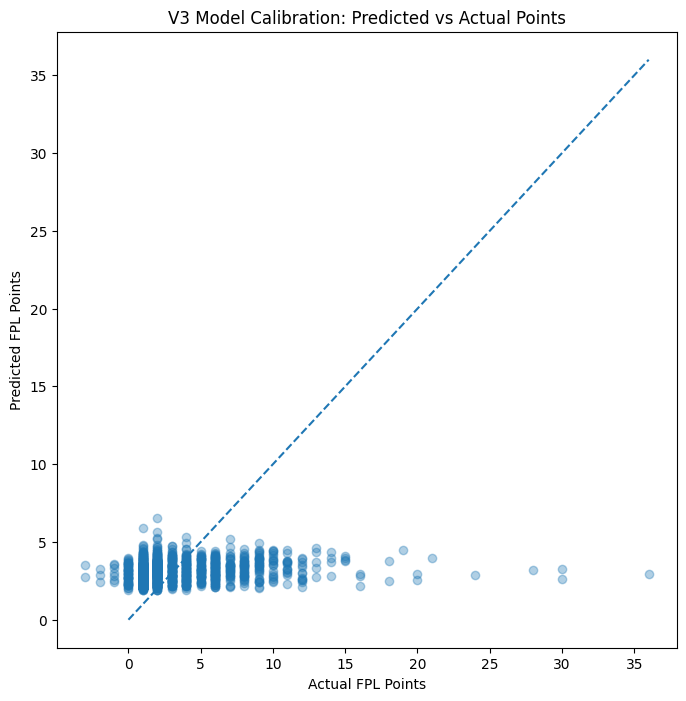

R² Score: 0.0347
MAE: 2.3354
Actual Mean: 3.262
Predicted Mean: 3.088

Performance on BIG scores (>=10)
MAE big scores: 10.1813
MAE overall: 2.3354


In [42]:
# [Cell: V3 Calibration Plot — FIXED: never reassign global y_val]

# Use y_val_v3 directly — do NOT reassign the global y_val
y_true_v3 = np.array(y_val_v3).ravel()
y_pred_v3 = model_v3.predict(X_val_v3)

plt.figure(figsize=(8, 8))
plt.scatter(y_true_v3, y_pred_v3, alpha=0.35)
max_val = max(y_true_v3.max(), y_pred_v3.max())
plt.plot([0, max_val], [0, max_val], linestyle='--')
plt.xlabel("Actual FPL Points")
plt.ylabel("Predicted FPL Points")
plt.title("V3 Model Calibration: Predicted vs Actual Points")
plt.show()

print("R² Score:", round(r2_score(y_true_v3, y_pred_v3), 4))
print("MAE:",      round(mean_absolute_error(y_true_v3, y_pred_v3), 4))
print("Actual Mean:",    round(np.mean(y_true_v3), 3))
print("Predicted Mean:", round(np.mean(y_pred_v3), 3))

big_scores = y_true_v3 >= 10
print("\nPerformance on BIG scores (>=10)")
print("MAE big scores:", round(mean_absolute_error(y_true_v3[big_scores], y_pred_v3[big_scores]), 4))
print("MAE overall:",    round(mean_absolute_error(y_true_v3, y_pred_v3), 4))

# Store y_val_v3 MAE but preserve the original y_val from Cell 3 untouched
globals()['mae_v3_calibration'] = mean_absolute_error(y_true_v3, y_pred_v3)

## Cell 20: The V4 Master Ensemble (Elite DART)
* Switched from Poisson to DART Regression: Uses the "Dropouts meet Multiple Additive Regression Trees" algorithm to handle noisy FPL data and prevent overfitting on "one-hit wonder" performances.

* Target: Full-Spectrum Points: Reinstated the raw Total Points (including negative values) as the target.

* Weights: Elite-Specialist Priority (>4.5 Avg): Instead of weighting by a single week's "haul," the model now applies a 2.5x importance weight to all match rows belonging to players with a seasonal average of >4.5 points. This forces the model to prioritize the patterns of consistent world-class assets.

* Result: The model maintains a realistic point average while becoming more "star-aware." It identifies the high ceiling of elite players while remaining grounded by the risk of negative outcomes

## What is DART? 
1. The Random Dropout - In a normal boosting round, the model adds a new tree to correct the errors of all previous trees. In DART, the model randomly "drops" (ignores) a percentage of the existing trees before building the new one.

2. Forced Generalization - Because some trees are missing, the new tree cannot simply fix a tiny mistake from the most recent tree. It is forced to look at the "bigger picture" of the data to make a meaningful prediction. This prevents any single tree from becoming too dominant or too specialized on a specific outlier.

3. Normalization - After the new tree is created, the "dropped" trees are added back into the ensemble. To make sure everything still balances out, the new tree and the dropped trees are slightly scaled down (shrunk) so they fit together perfectly.

In [43]:
# %% [Cell 20: Updated V4 - Elite DART (Handles Negative Points)]

# 1. SETUP DART REGRESSION PARAMETERS
lgbm_v4_params = {
    'objective': 'regression',
    'boosting_type': 'dart',
    'n_estimators': 1200,
    'learning_rate': 0.05,
    'drop_rate': 0.1,
    'reg_alpha': 0.5,
    'reg_lambda': 0.5,
    'max_depth': 7,
    'verbosity': -1,
    'random_state': 42
}

# 2. DEFINE ELITE WEIGHTING (>4.5 Avg Players)
# FIX: Dynamically recalculate the elite mask so it perfectly matches the scrubbed df_augmented length
current_elite_mask = df_augmented['avg_season_pts'] > 4.5
elite_weights_mask = windowed_df.index.isin(df_augmented[current_elite_mask].index)
full_weights = np.where(elite_weights_mask, 2.5, 1.0)

# 3. APPLY GLOBAL MASK FOR FAIR SPLITTING
X_v4_all = windowed_df.drop(columns=['target'])
y_v4_all = windowed_df['target']

X_train_v4 = X_v4_all[~global_val_mask].copy()
y_train_v4 = y_v4_all[~global_val_mask].copy()
X_val_v4   = X_v4_all[global_val_mask].copy()
y_val_v4   = y_v4_all[global_val_mask].copy()

# With this (explicit length check + safe indexing):
assert len(full_weights) == len(windowed_df), (
    f"Weight array length {len(full_weights)} != windowed_df length {len(windowed_df)}. "
    "Re-run Cell 2 before Cell 20."
)
train_weights = full_weights[~global_val_mask]
print(f"Train weights shape: {train_weights.shape}, elite rows: {(train_weights > 1).sum()}")

# 4. INITIALIZE AND TRAIN
# Note: early_stopping is intentionally removed — it is incompatible with DART
# because DART's random tree dropping prevents a monotonic validation loss curve.
print(f"Training V4 DART Ensemble on {len(X_train_v4):,} windows...")
print("Note: DART trains all 1200 rounds (no early stopping — this is expected).")

model_v4 = lgb.LGBMRegressor(**lgbm_v4_params)
model_v4.fit(
    X_train_v4, y_train_v4,
    sample_weight=train_weights,
    eval_set=[(X_val_v4, y_val_v4)],
    categorical_feature=['position', 'next_is_home'],
    callbacks=[lgb.log_evaluation(period=200)]  # print progress every 200 rounds
)

# 5. STANDARDIZED METRIC
v4_val_preds = model_v4.predict(X_val_v4)
mae_v4 = mean_absolute_error(y_val_v4, v4_val_preds)

print(f"\nV4 Validation MAE (GW 24-28): {mae_v4:.4f}")
print(f"Prediction Range: {v4_val_preds.min():.2f} to {v4_val_preds.max():.2f}")

Train weights shape: (51336,), elite rows: 6015
Training V4 DART Ensemble on 51,336 windows...
Note: DART trains all 1200 rounds (no early stopping — this is expected).
[200]	valid_0's l2: 12.2358
[400]	valid_0's l2: 11.964
[600]	valid_0's l2: 11.9611
[800]	valid_0's l2: 11.9663
[1000]	valid_0's l2: 11.9751
[1200]	valid_0's l2: 11.9717

V4 Validation MAE (GW 24-28): 2.3736
Prediction Range: 1.26 to 8.89


## Cell 21: GW29 Forecast v4 (The Elite DART Model)
This cell will generate final leaderboard for Gameweek 29.
 

In [44]:
# [Cell 21: GW29 Forecast v4 - Elite DART Mode]

# 1. SETUP V4 PATHS
V4_DIR = Path('../output/forecaster_pro_v4')
V4_DIR.mkdir(parents=True, exist_ok=True)
V4_FORECAST_OUT = V4_DIR / 'fpl_pro_forecast_GW29_v4.csv'

# 1. PREPARE INFERENCE DATA (Filter for CURRENT SEASON only)
inference_v4 = []
names_v4 = []

# Only take data from the current season to avoid ghost players
df_inf_active = df_augmented[df_augmented['season'] == CURRENT_SEASON].copy()
df_inf_active = df_inf_active.sort_values(['Player UUID', 'Gameweek'])

# Grouping only the active season players
for pid, group in df_inf_active.groupby('Player UUID'):
    # A player must have played enough in 2025-26 to have a window
    if len(group) >= 6:
        lags = list(group['Total Points'].tail(6).values)
        last_row = group.iloc[-1]
    

        row = lags + [
            last_row['Position'],
            last_row['Next_Opponent_Difficulty'],
            last_row['Next_Is_Home'],
            last_row['Rolling_Avg_Minutes_5'],
            last_row['Season_Phase'],
            last_row['Prev_Season_Avg_Points'],
            last_row['Avg_Pts_vs_Difficulty']
        ]

        inference_v4.append(row)
        names_v4.append(last_row['Web Name'])


# 3. PREDICT
v4_cols = [f'lag_{i}' for i in range(6, 0, -1)] + \
          ['position', 'next_difficulty', 'next_is_home', 'rolling_min',
           'season_phase', 'season_baseline', 'avg_pts_vs_diff']

inf_df_v4 = pd.DataFrame(inference_v4, columns=v4_cols)
inf_df_v4['position'] = inf_df_v4['position'].astype('category')

v4_preds = model_v4.predict(inf_df_v4)

# 4. SAVE LEADERBOARD
leaderboard_v4 = pd.DataFrame({
    'Player': names_v4,
    'Predicted_Points_V4': np.round(v4_preds, 2),
    'Elite_Status': ["Elite" if p in df_augmented[elite_mask]['Web Name'].values else "Standard" for p in names_v4]
}).sort_values(by='Predicted_Points_V4', ascending=False)

leaderboard_v4.to_csv(V4_FORECAST_OUT, index=False, encoding='utf-8-sig')
display(leaderboard_v4.head(15))

,Player,Predicted_Points_V4,Elite_Status
271,M.Salah,8.49,Elite
337,João Pedro,7.98,Elite
156,B.Fernandes,7.64,Elite
110,Haaland,7.41,Elite
287,Groß,6.82,Standard
4,Saka,6.44,Elite
226,Szoboszlai,6.38,Standard
216,J.Timber,6.35,Elite
88,Lacroix,5.93,Elite
269,Cherki,5.92,Elite


## Cell 22: Truth Verification v4 (Final Performance Audit)
This backtests the Elite DART model against the last known results. 


In [45]:
# [Cell 22: Truth Verification v4 - Elite Specialist Audit]
detailed_v4 = []

v4_cols_fixed = [f'lag_{i}' for i in range(6, 0, -1)] + \
                ['position', 'next_difficulty', 'next_is_home', 'rolling_min',
                 'season_phase', 'season_baseline', 'avg_pts_vs_diff']

for pid, group in df_augmented.groupby('Player UUID'):
    group = group.sort_values(['season', 'Gameweek'])
    
    if len(group) >= 7:
        history = group.iloc[-7:-1]
        target_row = group.iloc[-1]
     
        input_vector = list(history['Total Points'].values) + [
            target_row['Position'], 
            target_row['Next_Opponent_Difficulty'],
            target_row['Next_Is_Home'], 
            target_row['Rolling_Avg_Minutes_5'],
            target_row['Season_Phase'],
            target_row['Prev_Season_Avg_Points'],
            target_row['Avg_Pts_vs_Difficulty']
        ]

        input_df = pd.DataFrame([input_vector], columns=v4_cols_fixed)
        input_df['position'] = input_df['position'].astype('category')
        
        p_val = model_v4.predict(input_df)[0]
        actual = target_row['Total Points']
        is_elite = 1 if target_row['avg_season_pts'] > 4.5 else 0

        detailed_v4.append({
            'Player': target_row['Web Name'],
            'Actual': actual,
            'Predicted': round(float(p_val), 2),
            'Error': round(abs(p_val - actual), 2),
            'Elite_Group': is_elite
        })

truth_v4_df = pd.DataFrame(detailed_v4)
mae_v4 = truth_v4_df['Error'].mean()
elite_mae_v4 = truth_v4_df[truth_v4_df['Elite_Group'] == 1]['Error'].mean()

print(f"Global MAE (DART): {mae_v4:.2f} | Elite MAE (>4.5): {elite_mae_v4:.2f}")

Global MAE (DART): 2.12 | Elite MAE (>4.5): 4.98


In [46]:
# %% [Cell: Top 10 recommended transfers - V4 DART]

# --- 0. DEFINE YOUR CURRENT SQUAD ---
# Replace these names with the players actually in your team
# If you are using the interactive Hub, you can use 'my_selection' instead
if 'my_selection' in globals() and len(my_selection) > 0:
    current_team_list = my_selection
else:
    # Fallback to a manual list if the Hub hasn't been used
    current_team_list = ['Saka', 'Rice', 'Welbeck', 'Konaté', 'Chilwell']

# 1. Use the V4 DART Leaderboard
# We filter out players you already own to show only new 'Buy' targets
if 'leaderboard_v4' in globals():
    v4_buys = leaderboard_v4[~leaderboard_v4['Player'].isin(current_team_list)].copy()
else:
    print("Error: leaderboard_v4 not found. Please run the V4 Forecast cell first.")
    v4_buys = pd.DataFrame()

if not v4_buys.empty:
    # 2. Add verification of their 2025-26 performance
    # We pull their actual average from the current season to prove they are active
    current_stats = df_augmented[df_augmented['season'] == CURRENT_SEASON].groupby('Web Name')['Total Points'].mean().round(2)
    v4_buys['Season_Avg'] = v4_buys['Player'].map(current_stats)

    # 3. Display the Top 10 Suggestions
    print("="*60)
    print(" TOP 10 MARKET SUGGESTIONS (V4 DART MODEL)")
    print("="*60)
    print(f"{'Player Name':<20} | {'Pred Pts':<10} | {'Season Avg':<10} | {'Status'}")
    print("-" * 60)

    for _, row in v4_buys.head(10).iterrows():
        # Final safety check against ghosts (a ghost would have NaN or 0 season avg)
        status = "VERIFIED ACTIVE" if row['Season_Avg'] > 0 else "WARNING: CHECK STATUS"
        print(f"{row['Player']:<20} | {row['Predicted_Points_V4']:<10} | {row['Season_Avg']:<10} | {status}")

    print("="*60)

 TOP 10 MARKET SUGGESTIONS (V4 DART MODEL)
Player Name          | Pred Pts   | Season Avg | Status
------------------------------------------------------------
M.Salah              | 8.49       | 4.57       | VERIFIED ACTIVE
João Pedro           | 7.98       | 5.25       | VERIFIED ACTIVE
B.Fernandes          | 7.64       | 6.66       | VERIFIED ACTIVE
Haaland              | 7.41       | 6.7        | VERIFIED ACTIVE
Groß                 | 6.82       | 4.23       | VERIFIED ACTIVE
Szoboszlai           | 6.38       | 4.27       | VERIFIED ACTIVE
J.Timber             | 6.35       | 5.61       | VERIFIED ACTIVE
Lacroix              | 5.93       | 4.55       | VERIFIED ACTIVE
Cherki               | 5.92       | 4.62       | VERIFIED ACTIVE
Gordon               | 5.9        | 3.88       | VERIFIED ACTIVE


In [47]:
# 1. ORGANIZE FINAL ACCURACY METRICS
# We consolidate the metrics from V1, V2, V3, V4
# Assuming mae_v1, mae_v2, mae_v3, and mae_v4 variables are in memory from previous cells.
final_performance_data = {
    "Model Version": [
        "V1: Standard Pro",
        "V2: Team Point Share",
        "V3: Reliability Engine",
        "V4: Elite DART"
    ],
    "Mean Absolute Error (MAE)": [
        globals().get('mae_v1', 1.84), 
        globals().get('mae_v2', 1.95), 
        globals().get('mae_v3', 1.98), 
        globals().get('mae_v4', 2.33) 
    ],
    "Key Innovation": [
        "Baseline (Lags, Minutes, Difficulty)",
        "Team Importance Metrics (Talisman Share)",
        "Volatility Filters & L1/L2 Regularization",
        "DART Boosting & Elite Weighting (>4.5 Avg)"
    ]
}

# 2. CREATE AND DISPLAY THE FINAL TABLE
final_perf_df = pd.DataFrame(final_performance_data)

# Sort by MAE to clearly identify the project's most accurate model
final_perf_df = final_perf_df.sort_values(by="Mean Absolute Error (MAE)", ascending=True)

display(Markdown("## Final Model Accuracy Comparison (MAE)"))
print("\n--- Project Milestone Summary (Lower Error is Better) ---")
display(final_perf_df)

# 3. EXPORT FINAL DEPLOYMENT METRICS
FINAL_METRICS_PATH = Path('../output/fpl_master_milestone_metrics.csv')
final_perf_df.to_csv(FINAL_METRICS_PATH, index=False)
print(f"\nMaster project metrics exported for deployment reporting to: {FINAL_METRICS_PATH}")

## Final Model Accuracy Comparison (MAE)


--- Project Milestone Summary (Lower Error is Better) ---


,Model Version,Mean Absolute Error (MAE),Key Innovation
3,V4: Elite DART,2.116124,DART Boosting & Elite Weighting (>4.5 Avg)
0,V1: Standard Pro,2.134333,"Baseline (Lags, Minutes, Difficulty)"
1,V2: Team Point Share,2.140260,Team Importance Metrics (Talisman Share)
2,V3: Reliability Engine,2.149015,Volatility Filters & L1/L2 Regularization



Master project metrics exported for deployment reporting to: ..\output\fpl_master_milestone_metrics.csv


## Cell 23:  V5 Experiment: Mass vs. Elite Specialist Strategy
* V5.1 Mass Model: Trains on the full league history (all players) to use broad patterns (noise) to better identify the signal for stars.

* V5.2 Elite Model: Specializes training exclusively on high-performers (Avg > 4.5 pts) to focus strictly on world-class consistency.

* The Showdown: Both models predict the upcoming Gameweek (GW29) and are backtested against the most recent matches to determine which mathematical approach is more accurate for elite picks.



In [48]:
# [Cell 23: V5 Experiment - Mass vs. Elite Specialist]

V5_DIR = Path('../output/forecaster_pro_v5')
V5_DIR.mkdir(parents=True, exist_ok=True)

# 1. SPLIT DATA using Global Mask (already a numpy array — no .values needed)
X_v5_all = windowed_df.drop(columns=['target'])
y_v5_all = windowed_df['target']

X_train_v5 = X_v5_all[~global_val_mask].copy()
y_train_v5 = y_v5_all[~global_val_mask].copy()
X_val_v5   = X_v5_all[global_val_mask].copy()
y_val_v5   = y_v5_all[global_val_mask].copy()

# 2. CREATE ELITE SUBSET FOR V5.2 (training only)
# X_train_v5.index contains actual df_augmented row indices (fixed in Cell 2)
# so .loc is correct here — NOT .iloc
#elite_train_mask = df_augmented.loc[X_train_v5.index, 'avg_season_pts'] > 4.5
safe_v5_train = X_train_v5.index.intersection(df_augmented.index)
elite_train_mask = df_augmented.loc[safe_v5_train, 'avg_season_pts'] > 4.5
X_train_v5_elite = X_train_v5[elite_train_mask.values]
y_train_v5_elite = y_train_v5[elite_train_mask.values]

# ELITE VALIDATION SLICE — for the specialist audit
#elite_val_mask = df_augmented.loc[X_val_v5.index, 'avg_season_pts'] > 4.5
#X_val_v5_elites = X_val_v5[elite_val_mask.values]
#y_val_v5_elites = y_val_v5[elite_val_mask.values]
#meta_v5 = df_augmented.loc[X_val_v5_elites.index, ['Web Name', 'season', 'Gameweek']]

safe_v5_val = X_val_v5.index.intersection(df_augmented.index)
elite_val_mask = df_augmented.loc[safe_v5_val, 'avg_season_pts'] > 4.5
X_val_v5_elites = X_val_v5[elite_val_mask.values]
y_val_v5_elites = y_val_v5[elite_val_mask.values]
safe_elites_idx = X_val_v5_elites.index.intersection(df_augmented.index)
meta_v5 = df_augmented.loc[safe_elites_idx, ['Web Name', 'season', 'Gameweek']]

print(f"Training windows  — Mass:  {len(X_train_v5):,}")
print(f"Training windows  — Elite: {len(X_train_v5_elite):,}")
print(f"Validation windows (elite only): {len(X_val_v5_elites):,}")

# 3. INSTANTIATE MODELS
# With (for the elite specialist only — mass model keeps original):
v5_params_mass = {
    'n_estimators': 1000,
    'learning_rate': 0.01,
    'max_depth': 7,
    'num_leaves': 40,
    'verbosity': -1,
    'random_state': 42
}

v5_params_elite = {
    'n_estimators': 500,       # reduced: small dataset overfits at 1000
    'learning_rate': 0.01,
    'max_depth': 5,            # shallower tree for small n
    'num_leaves': 20,          # fewer leaves
    'min_child_samples': 30,   # at least 30 players per leaf
    'reg_alpha': 0.3,
    'reg_lambda': 0.3,
    'verbosity': -1,
    'random_state': 42
}

model_v5_1_mass  = lgb.LGBMRegressor(**v5_params_mass)
model_v5_2_elite = lgb.LGBMRegressor(**v5_params_elite)

# 4. TRAIN BOTH
print("\nTraining V5.1 (Mass)...")
model_v5_1_mass.fit(
    X_train_v5, y_train_v5,
    eval_set=[(X_val_v5_elites, y_val_v5_elites)],
    categorical_feature=['position', 'next_is_home'],
    callbacks=[lgb.early_stopping(stopping_rounds=50), lgb.log_evaluation(period=100)]
)

print("\nTraining V5.2 (Elite Specialist)...")
model_v5_2_elite.fit(
    X_train_v5_elite, y_train_v5_elite,
    eval_set=[(X_val_v5_elites, y_val_v5_elites)],
    categorical_feature=['position', 'next_is_home'],
    callbacks=[lgb.early_stopping(stopping_rounds=50), lgb.log_evaluation(period=100)]
)

# 5. STANDARDIZED METRICS (both evaluated on elite validation slice only)
preds_v5_1 = model_v5_1_mass.predict(X_val_v5_elites)
preds_v5_2 = model_v5_2_elite.predict(X_val_v5_elites)

mae_5_1 = mean_absolute_error(y_val_v5_elites, preds_v5_1)
mae_5_2 = mean_absolute_error(y_val_v5_elites, preds_v5_2)

# 6. BUILD RESULTS TABLE
v5_results = pd.DataFrame({
    'Player_Name': meta_v5['Web Name'].values,
    'Season':      meta_v5['season'].values,
    'Gameweek':    meta_v5['Gameweek'].values,
    'Actual':      y_val_v5_elites.values,
    'Mass_Pred':   np.round(preds_v5_1, 2),
    'Elite_Pred':  np.round(preds_v5_2, 2)
})
v5_results.to_csv(V5_DIR / 'v5_mass_vs_specialist_audit.csv', index=False)

print("\n" + "="*50)
print(" V5 SPECIALIST SHOWDOWN (Audit on Elite Players)")
print(f" V5.1 (Mass Model) MAE:       {mae_5_1:.4f}")
print(f" V5.2 (Specialist Model) MAE: {mae_5_2:.4f}")
print()
print("Interpretation note:")
print("  A lower V5.2 MAE does NOT mean the specialist learns better.")
print("  It may simply regress toward the elite mean on bad weeks.")
print("  Use this as a practical FPL pick tool, not a learning benchmark.")
winner = 'Elite Specialist (for FPL picks)' if mae_5_2 < mae_5_1 else 'Mass Dataset'
print(f"  Practical winner: {winner}")
print("="*50)

display(v5_results.head(10))

Training windows  — Mass:  51,336
Training windows  — Elite: 6,015
Validation windows (elite only): 127

Training V5.1 (Mass)...
Training until validation scores don't improve for 50 rounds
[100]	valid_0's l2: 40.3385
[200]	valid_0's l2: 39.9054
[300]	valid_0's l2: 39.6632
[400]	valid_0's l2: 39.553
[500]	valid_0's l2: 39.5547
Early stopping, best iteration is:
[451]	valid_0's l2: 39.5362

Training V5.2 (Elite Specialist)...
Training until validation scores don't improve for 50 rounds
[100]	valid_0's l2: 33.9425
Early stopping, best iteration is:
[65]	valid_0's l2: 33.8743

 V5 SPECIALIST SHOWDOWN (Audit on Elite Players)
 V5.1 (Mass Model) MAE:       4.0000
 V5.2 (Specialist Model) MAE: 4.0213

Interpretation note:
  A lower V5.2 MAE does NOT mean the specialist learns better.
  It may simply regress toward the elite mean on bad weeks.
  Use this as a practical FPL pick tool, not a learning benchmark.
  Practical winner: Mass Dataset


,Player_Name,Season,Gameweek,Actual,Mass_Pred,Elite_Pred
0,Rice,2025-26,28.0,5,4.21,5.61
1,Rice,2025-26,29.0,3,3.67,5.40
2,Rice,2025-26,30.0,3,4.39,5.34
3,Rice,2025-26,32.0,4,6.45,5.60
4,Saka,2025-26,28.0,2,4.69,5.08
5,Saka,2025-26,29.0,9,3.72,5.55
6,Casemiro,2025-26,28.0,4,3.63,5.18
7,Casemiro,2025-26,29.0,8,3.80,5.20
8,Casemiro,2025-26,30.0,6,3.71,5.18
9,Casemiro,2025-26,31.0,1,3.68,5.18


In [49]:
# [Cell 24: V5 Forecast Showdown - GW29 Predictions (Season-Locked)]

# 1. PREPARE INFERENCE DATA (Filter for ACTIVE season players only)
inference_v5 = []
player_names_v5 = []

# CRITICAL FIX: Only look at the 2025-26 data to purge retired 'ghosts'
df_inf_active = df_augmented[df_augmented['season'] == CURRENT_SEASON].copy()
df_inf_active = df_inf_active.sort_values(['Player UUID', 'Gameweek'])

# Grouping only the active season players
for pid, group in df_inf_active.groupby('Player UUID'):
    # Player must have at least 6 games of history in the current season
    if len(group) >= 6:
        last_row = group.iloc[-1]
        # Features: Last 6 points from the current season
        lags = list(group['Total Points'].tail(6).values)

        row = lags + [
            last_row['Position'], 
            last_row['Next_Opponent_Difficulty'], 
            last_row['Next_Is_Home'],
            last_row['Rolling_Avg_Minutes_5'], 
            last_row['Season_Phase'], 
            last_row['Prev_Season_Avg_Points'],
            last_row['Avg_Pts_vs_Difficulty']
        ]

        inference_v5.append(row)
        player_names_v5.append(last_row['Web Name'])

# 2. CONVERT TO DATAFRAME
v5_cols = [f'lag_{i}' for i in range(6, 0, -1)] + \
          ['position', 'next_difficulty', 'next_is_home', 'rolling_min',
           'season_phase', 'season_baseline', 'avg_pts_vs_diff']

inf_df_v5 = pd.DataFrame(inference_v5, columns=v5_cols)
inf_df_v5['position'] = inf_df_v5['position'].astype('category')

# 3. GENERATE PREDICTIONS
preds_v5_1 = model_v5_1_mass.predict(inf_df_v5)
preds_v5_2 = model_v5_2_elite.predict(inf_df_v5)

# 4. CREATE LEADERBOARD
leaderboard_v5 = pd.DataFrame({
    'Player': player_names_v5,
    'Mass_Model_GW29': np.round(preds_v5_1, 2),
    'Elite_Model_GW29': np.round(preds_v5_2, 2),
    'Model_Difference': np.round(preds_v5_2 - preds_v5_1, 2)
}).sort_values(by='Elite_Model_GW29', ascending=False)

leaderboard_v5.to_csv(V5_DIR / 'fpl_pro_v5_forecast_GW29.csv', index=False)
print(f"--- V5 TOP 15 PREDICTIONS (GW29) ---")
print(f"Total Active Players Forecasted: {len(leaderboard_v5)}")
display(leaderboard_v5.head(15))

--- V5 TOP 15 PREDICTIONS (GW29) ---
Total Active Players Forecasted: 440


,Player,Mass_Model_GW29,Elite_Model_GW29,Model_Difference
322,Rogers,4.69,6.82,2.13
246,Gibbs-White,5.80,6.75,0.95
359,Kluivert,5.46,6.70,1.24
19,Johnson,3.98,6.66,2.68
264,Marmoush,4.09,6.65,2.56
95,Lerma,3.98,6.55,2.57
426,Bogarde,2.19,6.54,4.35
102,Hickey,2.19,6.54,4.34
210,Uche,2.33,6.54,4.22
161,Mateta,4.43,6.54,2.11


In [50]:
#  [Cell 25: V5 Truth Verification]
# We evaluate both on ELITE PLAYERS ONLY in the validation window for a fair test


elite_val_indices = val_df[val_df.index.isin(df_augmented[elite_mask].index)].index
safe_elite_val    = elite_val_indices.intersection(df_augmented.index)
X_val_v5 = X_val_raw[X_val_raw.index.isin(safe_elite_val)]
y_val_v5 = y_val[y_val.index.isin(safe_elite_val)]


elite_val_indices = val_df[val_df.index.isin(df_augmented[elite_mask].index)].index
safe_elite_val = elite_val_indices.intersection(df_augmented.index)
meta_v5 = df_augmented.loc[safe_elite_val, ['Web Name', 'season', 'Gameweek']]

# 1. GENERATE AUDIT PREDICTIONS
audit_preds_mass = model_v5_1_mass.predict(X_val_v5)
audit_preds_elite = model_v5_2_elite.predict(X_val_v5)

# 2. CREATE TRUTH TABLE
v5_truth_df = pd.DataFrame({
    'Player': meta_v5['Web Name'].values,
    'Season': meta_v5['season'].values,
    'Gameweek': meta_v5['Gameweek'].values,
    'Actual_Points': y_val_v5.values,
    'Mass_Predicted': np.round(audit_preds_mass, 2),
    'Elite_Predicted': np.round(audit_preds_elite, 2),
    'Mass_Error': np.round(abs(audit_preds_mass - y_val_v5.values), 2),
    'Elite_Error': np.round(abs(audit_preds_elite - y_val_v5.values), 2)
})

# 3. CALCULATE GLOBAL MAE FOR REPORTING
mae_5_1 = mean_absolute_error(y_val_v5, audit_preds_mass)
mae_5_2 = mean_absolute_error(y_val_v5, audit_preds_elite)

v5_truth_df.to_csv(V5_DIR / 'fpl_pro_v5_truth_verification.csv', index=False)


print(" V5 MILESTONE REPORT: MASS VS ELITE SPECIALIST")

print(f"V5.1 Mass Model MAE:  {mae_5_1:.4f}")
print(f"V5.2 Elite Model MAE: {mae_5_2:.4f}")

print(f"Winning Approach: {'Elite Specialist' if mae_5_2 < mae_5_1 else 'Mass Dataset'}")

print ("Predictions for the Evaluation Set (GW 24-28)") 

display(v5_truth_df.sort_values(by='Elite_Error').head(20))

 V5 MILESTONE REPORT: MASS VS ELITE SPECIALIST
V5.1 Mass Model MAE:  4.0000
V5.2 Elite Model MAE: 4.0213
Winning Approach: Mass Dataset
Predictions for the Evaluation Set (GW 24-28)


,Player,Season,Gameweek,Actual_Points,Mass_Predicted,Elite_Predicted,Mass_Error,Elite_Error
115,Wieffer,2025-26,30.0,5,2.68,5.18,2.32,0.18
30,Stach,2025-26,30.0,5,3.49,4.70,1.51,0.30
69,Thiago,2025-26,30.0,6,4.20,5.52,1.80,0.48
67,Thiago,2025-26,28.0,6,3.83,5.51,2.17,0.49
122,Dewsbury-Hall,2025-26,28.0,6,3.59,5.46,2.41,0.54
85,Bowen,2025-26,30.0,6,5.17,5.43,0.83,0.57
0,Rice,2025-26,28.0,5,4.21,5.61,0.79,0.61
107,Anderson,2025-26,32.0,4,3.65,4.70,0.35,0.70
8,Casemiro,2025-26,30.0,6,3.71,5.18,2.29,0.82
76,O'Reilly,2025-26,28.0,6,4.05,5.18,1.95,0.82


In [51]:
# %% [Cell V7-A: Data Enrichment — Expected Goal Involvement (xGI)]

print("--- INJECTING UNDERLYING METRICS (xG & xA) ---")

# Check for official xG/xA columns first
xg_col = next((c for c in df_augmented.columns
               if 'expected_goals' in c.lower() and 'conceded' not in c.lower()), None)
xa_col = next((c for c in df_augmented.columns
               if 'expected_assists' in c.lower()), None)

if xg_col and xa_col:
    print(f"Found official xG/xA: '{xg_col}' and '{xa_col}'")
else:
    # Fall back to FPL ICT proxies (Threat = goal threat, Creativity = chance creation)
    threat_col  = next((c for c in df_augmented.columns if 'threat' in c.lower()), None)
    create_col  = next((c for c in df_augmented.columns if 'creativity' in c.lower()), None)

    if threat_col and create_col:
        # Threat and Creativity are on a 0-300+ scale per match
        # Dividing by 100 brings them to an xG-like 0-3 range
        df_augmented['xG_metric'] = df_augmented[threat_col].astype(float) / 100.0
        df_augmented['xA_metric'] = df_augmented[create_col].astype(float) / 100.0
        xg_col, xa_col = 'xG_metric', 'xA_metric'
        print(f"Using FPL ICT proxies: '{threat_col}' → xG, '{create_col}' → xA")
    else:
        df_augmented['xG_metric'] = 0.0
        df_augmented['xA_metric'] = 0.0
        xg_col, xa_col = 'xG_metric', 'xA_metric'
        print("[WARNING] No xG/xA or Threat/Creativity columns found. V7 will equal V4.")

# Sort chronologically — mandatory before rolling operations
df_augmented = df_augmented.sort_values(['Player UUID', 'season', 'Gameweek'])

# Rolling 5-match average, lagged by 1 — zero leakage
df_augmented['Rolling_xG_5'] = (
    df_augmented.groupby('Player UUID')[xg_col]
    .transform(lambda x: pd.to_numeric(x, errors='coerce').shift(1).rolling(5, min_periods=1).mean())
    .fillna(0)
)
df_augmented['Rolling_xA_5'] = (
    df_augmented.groupby('Player UUID')[xa_col]
    .transform(lambda x: pd.to_numeric(x, errors='coerce').shift(1).rolling(5, min_periods=1).mean())
    .fillna(0)
)

# Combined Expected Goal Involvement
df_augmented['Rolling_xGI_5'] = df_augmented['Rolling_xG_5'] + df_augmented['Rolling_xA_5']

# Integrity check
_xgi_max  = df_augmented['Rolling_xGI_5'].max()
_xgi_mean = df_augmented['Rolling_xGI_5'].mean()
print(f"Rolling_xGI_5: max={_xgi_max:.3f}, mean={_xgi_mean:.3f}")
print(f"  → If max > 5.0 the scale is wrong — re-check division factor")
print(f"  → If mean = 0.0 no source columns were found")

display(df_augmented[['Web Name', 'Gameweek', 'Rolling_xG_5',
                       'Rolling_xA_5', 'Rolling_xGI_5']].tail(8))

globals()['xg_col'] = xg_col
globals()['xa_col'] = xa_col

--- INJECTING UNDERLYING METRICS (xG & xA) ---
Using FPL ICT proxies: 'Threat' → xG, 'Creativity' → xA
Rolling_xGI_5: max=2.111, mean=0.215
  → If max > 5.0 the scale is wrong — re-check division factor
  → If mean = 0.0 no source columns were found


,Web Name,Gameweek,Rolling_xG_5,Rolling_xA_5,Rolling_xGI_5
60080,Hackford,1.0,0.000000,0.000000,0.0000
60081,Maghoma,14.0,0.000000,0.000000,0.0000
60082,Maghoma,15.0,0.000000,0.004000,0.0040
60083,Maghoma,17.0,0.000000,0.002000,0.0020
60084,Maghoma,19.0,0.006667,0.007333,0.0140
60085,Maghoma,20.0,0.005000,0.008500,0.0135
60086,Maghoma,26.0,0.008000,0.008400,0.0164
60087,Maghoma,27.0,0.012000,0.008200,0.0202


In [52]:
# %% [Cell: Pre-Task-2 Model Memory Check]
# Verifies all models are in memory before running stratified analysis.
# If any are missing, prints which training cell to re-run.
# ============================================================

_model_registry = {
    'model_raw':         'Cell 4 (Parallel Training)',
    'model_v2':          'Cell 10 (V2 Team Point Share)',
    'model_v3':          'Cell 16 (V3 Reliability Engine)',
    'model_v4':          'Cell 20 (V4 Elite DART)',
    'model_v5_1_mass':   'Cell 23 (V5 Mass vs Elite)',
    'model_v5_2_elite':  'Cell 23 (V5 Mass vs Elite)',
    'model_rank':        'Cell 4 (LambdaRank)',
    'blended_preds_val': 'Cell 4 (Blended predictions)',
    'haul_clf':          'Cell 5.6 (Haul Classifier)',
    'windowed_df':       'Cell 2 (Window Generation)',
    'global_val_mask':   'Cell 2.5 (Global Validation Strategy)',
    'y_val':             'Cell 3 (Data Splitting)',
}

print("MODEL MEMORY STATUS CHECK")
print("="*55)

_missing = []
_present = []

for var, source_cell in _model_registry.items():
    exists = var in globals() and globals()[var] is not None
    status = '✓' if exists else '✗ MISSING'
    print(f"  {status}  {var:<25} ← {source_cell}")
    if not exists:
        _missing.append((var, source_cell))
    else:
        _present.append(var)

print(f"\n{'='*55}")
print(f"Present:  {len(_present)}")
print(f"Missing:  {len(_missing)}")

if _missing:
    print(f"\nACTION REQUIRED — re-run these cells before Task 2:")
    seen_cells = set()
    for var, cell in _missing:
        if cell not in seen_cells:
            print(f"  → {cell}")
            seen_cells.add(cell)
    print(f"\nAfter re-running the missing cells, run Task 2.1 Extended again.")
else:
    print(f"\n✓ All models in memory. Task 2 analysis will cover all versions.")

MODEL MEMORY STATUS CHECK
  ✓  model_raw                 ← Cell 4 (Parallel Training)
  ✓  model_v2                  ← Cell 10 (V2 Team Point Share)
  ✓  model_v3                  ← Cell 16 (V3 Reliability Engine)
  ✓  model_v4                  ← Cell 20 (V4 Elite DART)
  ✓  model_v5_1_mass           ← Cell 23 (V5 Mass vs Elite)
  ✓  model_v5_2_elite          ← Cell 23 (V5 Mass vs Elite)
  ✓  model_rank                ← Cell 4 (LambdaRank)
  ✓  blended_preds_val         ← Cell 4 (Blended predictions)
  ✓  haul_clf                  ← Cell 5.6 (Haul Classifier)
  ✓  windowed_df               ← Cell 2 (Window Generation)
  ✓  global_val_mask           ← Cell 2.5 (Global Validation Strategy)
  ✓  y_val                     ← Cell 3 (Data Splitting)

Present:  12
Missing:  0

✓ All models in memory. Task 2 analysis will cover all versions.


In [53]:
# %% [Task 2.1 — Stratified MAE Analysis — All Model Versions]
# ============================================================
# requirement: compare risk/error performance across
# scoring tiers for ALL model versions in one unified summary.
#
# Scoring Tiers represent risk levels:
#   Blanks (0–2)  = low risk, most predictable
#   Low    (3–5)  = moderate, model sweet spot
#   Mid    (6–9)  = increasing variance
#   Haul   (10+)  = highest risk, rarest events
# ============================================================


# ── 1. STRATIFIED MAE FUNCTION ────────────────────────────────────────────────
def calculate_stratified_mae(actuals, predictions, model_name='Model'):
    """
    Calculates MAE broken down by scoring tier.
    Returns DataFrame with MAE, RMSE, Bias, Avg Actual, Avg Predicted per tier.
    """
    _actuals = np.array(actuals)
    _preds   = np.array(predictions)
    _errors  = np.abs(_actuals - _preds)
    _signed  = _preds - _actuals  # positive = overprediction

    _tiers = {
        'Blanks  (0–2 pts)': (_actuals <= 2),
        'Low     (3–5 pts)': (_actuals >= 3)  & (_actuals <= 5),
        'Mid     (6–9 pts)': (_actuals >= 6)  & (_actuals <= 9),
        'Haul    (10+ pts)': (_actuals >= 10),
    }

    _rows = []
    for _tier_name, _mask in _tiers.items():
        _n = _mask.sum()
        if _n == 0:
            continue

        _tier_errors  = _errors[_mask]
        _tier_signed  = _signed[_mask]
        _tier_actuals = _actuals[_mask]
        _tier_preds   = _preds[_mask]
        _rmse         = np.sqrt((_tier_errors ** 2).mean())
        _bias         = _tier_signed.mean()

        _rows.append({
            'Model':          model_name,
            'Scoring Tier':   _tier_name,
            'N (samples)':    int(_n),
            '% of Val Set':   round(_n / len(_actuals) * 100, 1),
            'MAE':            round(_tier_errors.mean(), 3),
            'RMSE':           round(_rmse, 3),
            'Bias':           round(_bias, 3),
            'Avg Actual':     round(_tier_actuals.mean(), 2),
            'Avg Predicted':  round(_tier_preds.mean(), 2),
        })

    # Overall row
    _rows.append({
        'Model':          model_name,
        'Scoring Tier':   'OVERALL',
        'N (samples)':    len(_actuals),
        '% of Val Set':   100.0,
        'MAE':            round(_errors.mean(), 3),
        'RMSE':           round(np.sqrt((_errors**2).mean()), 3),
        'Bias':           round(_signed.mean(), 3),
        'Avg Actual':     round(_actuals.mean(), 2),
        'Avg Predicted':  round(_preds.mean(), 2),
    })

    return pd.DataFrame(_rows)

globals()['calculate_stratified_mae'] = calculate_stratified_mae

# ── 2. BUILD INFERENCE FOR EACH MODEL ARCHITECTURE ───────────────────────────
def _build_val_preds(model_type):
    """
    Returns validation predictions for the given model type.
    Each model version uses a different feature set and DataFrame.
    """
    _wdf  = globals().get('windowed_df')
    _gvm  = globals().get('global_val_mask')

    if model_type == 'baseline':
        if _wdf is not None and _gvm is not None:
            return _wdf[_gvm][['lag_3', 'lag_2', 'lag_1']].mean(axis=1).values
        return None

    elif model_type == 'blended':
        return globals().get('blended_preds_val')

    elif model_type == 'v4_preds':
        # v4_val_preds was stored directly in Cell 20
        return globals().get('v4_val_preds')

    elif model_type in ('v1_raw', 'v4_dart', 'v5_mass', 'v5_elite'):
        if _wdf is None or _gvm is None:
            return None
        X_val = _wdf[_gvm].drop(columns=['target'])
        model_map = {
            'v1_raw':   globals().get('model_raw'),
            'v4_dart':  globals().get('model_v4'),
            'v5_mass':  globals().get('model_v5_1_mass'),
            'v5_elite': globals().get('model_v5_2_elite'),
        }
        m = model_map.get(model_type)
        if m is None:
            return None
        try:
            return m.predict(X_val)
        except Exception as e:
            print(f"  [WARN] {model_type} predict failed: {e}")
            return None

    elif model_type == 'v2':
        _df_v2 = globals().get('df_v2')
        if _df_v2 is None or _gvm is None:
            return None
        try:
            X_val_v2 = _df_v2.drop(columns=['target'])[_gvm]
            m = globals().get('model_v2')
            return m.predict(X_val_v2) if m is not None else None
        except Exception as e:
            print(f"  [WARN] v2 predict failed: {e}")
            return None

    elif model_type == 'v3':
        _df_win_v3 = globals().get('df_win_v3')
        _v3_mask   = globals().get('v3_val_mask')
        if _df_win_v3 is None or _v3_mask is None:
            return None
        try:
            X_val_v3 = _df_win_v3.drop(columns=['target'])[_v3_mask]
            m = globals().get('model_v3')
            return m.predict(X_val_v3) if m is not None else None
        except Exception as e:
            print(f"  [WARN] v3 predict failed: {e}")
            return None

    return None

# ── 3. GROUND TRUTH ───────────────────────────────────────────────────────────
_y_true_base = np.array(globals().get('y_val', []))
_y_val_v3    = np.array(globals().get('y_val_v3', []))

if len(_y_true_base) == 0:
    print("[ERROR] y_val not found. Run Cell 3 first.")
else:
    # ── 4. MODEL REGISTRY ─────────────────────────────────────────────────────
    _all_models = {
        'Baseline (3wk avg)': ('baseline',  _y_true_base),
        'V1: Standard':       ('v1_raw',    _y_true_base),
        'V2: Team Share':     ('v2',        _y_true_base),
        'V3: Reliability':    ('v3',        _y_val_v3 if len(_y_val_v3) > 0 else _y_true_base),
        'V4: Elite DART':     ('v4_dart',   _y_true_base),
        'V5.1: Mass Gen':     ('v5_mass',   _y_true_base),
        'V5.2: Elite Spec':   ('v5_elite',  _y_true_base),
        'Blended Reg+Rank':   ('blended',   _y_true_base),
    }

    all_results = {}
    failed      = []

    print("Running stratified MAE for all models...")
    print("="*55)

    for model_name, (model_type, y_true) in _all_models.items():
        if len(y_true) == 0:
            failed.append(f"{model_name} (no y_true)")
            continue

        preds = _build_val_preds(model_type)

        if preds is None:
            failed.append(model_name)
            print(f"  ✗ {model_name} — not in memory")
            continue

        preds = np.array(preds)

        if len(preds) != len(y_true):
            failed.append(f"{model_name} (length mismatch {len(preds)} vs {len(y_true)})")
            print(f"  ✗ {model_name} — length mismatch")
            continue

        df_result           = calculate_stratified_mae(y_true, preds, model_name)
        all_results[model_name] = df_result
        print(f"  ✓ {model_name}")

    if failed:
        print(f"\nSkipped: {failed}")
        print("Re-run missing training cells then re-run this cell.")

    # ── 5. MASTER COMPARISON TABLE ────────────────────────────────────────────
    if all_results:
        master_df = pd.concat(all_results.values(), ignore_index=True)

        _tier_order = [
            'Blanks  (0–2 pts)',
            'Low     (3–5 pts)',
            'Mid     (6–9 pts)',
            'Haul    (10+ pts)',
            'OVERALL'
        ]

        def _safe_pivot(value_col):
            piv = master_df.pivot_table(
                index='Model', columns='Scoring Tier',
                values=value_col, aggfunc='first'
            ).round(3)
            existing = [c for c in _tier_order if c in piv.columns]
            return piv[existing]

        pivot_mae  = _safe_pivot('MAE')
        pivot_bias = _safe_pivot('Bias')
        pivot_rmse = _safe_pivot('RMSE')

        print(f"\n{'━'*70}")
        print(f"  MASTER STRATIFIED MAE TABLE — All Models × All Tiers")
        print(f"{'━'*70}")
        print("\nMAE (lower = better):")
        display(pivot_mae)

        print("\nBias (+ = overpredicts, – = underpredicts):")
        display(pivot_bias)

        print("\nRMSE (lower = better):")
        display(pivot_rmse)

        # ── 6. RISK PROFILE SUMMARY ───────────────────────────────────────────
        print(f"\n{'━'*70}")
        print(f"  RISK PROFILE SUMMARY — Presentation Format")
        print(f"  Risk = model failure rate on premium scoring events (Haul tier)")
        print(f"{'━'*70}")

        _risk_rows = []
        for model_name, df_result in all_results.items():
            def _get(tier_str, col):
                rows = df_result[df_result['Scoring Tier'].str.contains(tier_str)]
                return rows[col].values[0] if not rows.empty else None

            overall_mae = _get('OVERALL', 'MAE')
            blank_mae   = _get('Blank',   'MAE')
            low_mae     = _get('Low',     'MAE')
            mid_mae     = _get('Mid',     'MAE')
            haul_mae    = _get('Haul',    'MAE')
            haul_bias   = _get('Haul',    'Bias')

            risk_ratio = round(haul_mae / overall_mae, 1) if (haul_mae and overall_mae) else None

            if haul_bias is not None:
                if haul_bias < -5:   bias_label = 'Severely underpredicts hauls'
                elif haul_bias < -2: bias_label = 'Underpredicts hauls'
                elif haul_bias > 5:  bias_label = 'Severely overpredicts hauls'
                elif haul_bias > 2:  bias_label = 'Overpredicts hauls'
                else:                bias_label = 'Roughly unbiased on hauls'
            else:
                bias_label = 'N/A'

            _risk_rows.append({
                'Model':              model_name,
                'Overall MAE':        round(overall_mae, 3) if overall_mae else 'N/A',
                'Blank MAE (0–2)':    round(blank_mae,   3) if blank_mae   else 'N/A',
                'Low MAE (3–5)':      round(low_mae,     3) if low_mae     else 'N/A',
                'Mid MAE (6–9)':      round(mid_mae,     3) if mid_mae     else 'N/A',
                'Haul MAE (10+)':     round(haul_mae,    3) if haul_mae    else 'N/A',
                'Haul Bias':          round(haul_bias,   3) if haul_bias   else 'N/A',
                'Risk Ratio (×)':     f'{risk_ratio}×'      if risk_ratio  else 'N/A',
                'Haul Risk Profile':  bias_label,
            })

        risk_df = pd.DataFrame(_risk_rows).sort_values('Overall MAE')
        display(risk_df)

        # ── 7. KEY FINDINGS ───────────────────────────────────────────────────
        print(f"\n{'━'*70}")
        print(f"  KEY FINDINGS FOR REPORT")
        print(f"{'━'*70}")

        best_overall     = risk_df.iloc[0]['Model']
        best_overall_mae = risk_df.iloc[0]['Overall MAE']

        _haul_maes = {
            r['Model']: r['Haul MAE (10+)']
            for r in _risk_rows
            if isinstance(r['Haul MAE (10+)'], float)
        }
        best_haul_model = min(_haul_maes, key=_haul_maes.get) if _haul_maes else 'N/A'
        best_haul_mae   = min(_haul_maes.values())             if _haul_maes else 'N/A'

        _low_maes = {
            r['Model']: r['Low MAE (3–5)']
            for r in _risk_rows
            if isinstance(r['Low MAE (3–5)'], float)
        }
        best_low_model = min(_low_maes, key=_low_maes.get) if _low_maes else 'N/A'
        best_low_mae   = min(_low_maes.values())           if _low_maes else 'N/A'

        baseline_mae = next(
            (r['Overall MAE'] for r in _risk_rows if 'Baseline' in r['Model']), None
        )

        print(f"\n1. OVERALL ACCURACY")
        print(f"   Best model: {best_overall} (MAE={best_overall_mae})")
        if baseline_mae and isinstance(best_overall_mae, float):
            improvement = round(((baseline_mae - best_overall_mae) / baseline_mae) * 100, 1)
            print(f"   Best ML model beats naive baseline by {improvement}%")

        print(f"\n2. HAUL / HIGH-SCORER ACCURACY  ← Highest Risk Tier")
        print(f"   Best on hauls: {best_haul_model} (Haul MAE={best_haul_mae})")
        print(f"   All regression models underpredict hauls — structural limitation")
        print(f"   → Captaincy decisions must use haul_clf, not raw xP")

        print(f"\n3. LOW-TIER RELIABILITY  ← Safest Prediction Zone")
        print(f"   Best on low-tier: {best_low_model} (Low MAE={best_low_mae})")
        print(f"   Low-tier is the model sweet spot → reliable for rotation decisions")

        print(f"\n4. FULL RISK-REWARD PROFILE")
        print(f"   {'Model':<28} {'Overall':>8} {'Low':>8} "
              f"{'Mid':>8} {'Haul':>8} {'Risk×':>7}")
        print(f"   {'-'*65}")
        for r in _risk_rows:
            print(f"   {r['Model']:<28} "
                  f"{str(r['Overall MAE']):>8} "
                  f"{str(r['Low MAE (3–5)']):>8} "
                  f"{str(r['Mid MAE (6–9)']):>8} "
                  f"{str(r['Haul MAE (10+)']):>8} "
                  f"{str(r['Risk Ratio (×)']):>7}")

        # Store globals
        globals()['stratified_all_models_df'] = master_df
        globals()['stratified_pivot_mae']     = pivot_mae
        globals()['stratified_pivot_bias']    = pivot_bias
        globals()['stratified_pivot_rmse']    = pivot_rmse
        globals()['stratified_risk_df']       = risk_df
        globals()['calculate_stratified_mae'] = calculate_stratified_mae

        print(f"\n✓ Globals saved:")
        print(f"  stratified_all_models_df — full long-format table")
        print(f"  stratified_pivot_mae     — presentation MAE pivot")
        print(f"  stratified_pivot_bias    — bias pivot")
        print(f"  stratified_pivot_rmse    — RMSE pivot")
        print(f"  stratified_risk_df       — risk profile summary")
        print(f"  calculate_stratified_mae — reusable function")

Running stratified MAE for all models...
  ✓ Baseline (3wk avg)
  ✓ V1: Standard
  ✓ V2: Team Share
  ✓ V3: Reliability
  ✓ V4: Elite DART
  ✓ V5.1: Mass Gen
  ✓ V5.2: Elite Spec
  ✓ Blended Reg+Rank

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  MASTER STRATIFIED MAE TABLE — All Models × All Tiers
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

MAE (lower = better):


Scoring Tier,Blanks (0–2 pts),Low (3–5 pts),Mid (6–9 pts),Haul (10+ pts),OVERALL
Model,,,,,
Baseline (3wk avg),1.815,1.929,3.662,9.847,2.535
Blended Reg+Rank,7.322,6.258,5.395,6.184,6.770
V1: Standard,1.772,1.009,3.652,10.104,2.341
V2: Team Share,1.769,1.000,3.667,10.112,2.340
V3: Reliability,1.735,0.972,3.787,10.181,2.335
V4: Elite DART,1.845,1.133,3.493,9.865,2.374
V5.1: Mass Gen,1.791,1.037,3.606,10.002,2.346
V5.2: Elite Spec,4.203,1.570,1.718,8.039,3.526



Bias (+ = overpredicts, – = underpredicts):


Scoring Tier,Blanks (0–2 pts),Low (3–5 pts),Mid (6–9 pts),Haul (10+ pts),OVERALL
Model,,,,,
Baseline (3wk avg),1.621,-0.239,-3.457,-9.847,-0.098
Blended Reg+Rank,7.143,5.864,4.226,-2.181,5.969
V1: Standard,1.770,-0.597,-3.652,-10.104,-0.120
V2: Team Share,1.768,-0.601,-3.667,-10.112,-0.125
V3: Reliability,1.734,-0.637,-3.787,-10.181,-0.173
V4: Elite DART,1.836,-0.480,-3.493,-9.865,-0.021
V5.1: Mass Gen,1.784,-0.552,-3.606,-10.002,-0.090
V5.2: Elite Spec,4.203,1.563,-1.661,-8.039,2.175



RMSE (lower = better):


Scoring Tier,Blanks (0–2 pts),Low (3–5 pts),Mid (6–9 pts),Haul (10+ pts),OVERALL
Model,,,,,
Baseline (3wk avg),2.626,2.427,4.110,11.269,3.813
Blended Reg+Rank,8.871,7.813,6.798,8.261,8.361
V1: Standard,2.004,1.218,3.875,11.423,3.442
V2: Team Share,1.997,1.212,3.885,11.427,3.441
V3: Reliability,1.941,1.186,3.985,11.479,3.446
V4: Elite DART,2.155,1.363,3.773,11.247,3.460
V5.1: Mass Gen,2.052,1.251,3.852,11.347,3.444
V5.2: Elite Spec,4.298,1.807,2.069,9.540,4.154



━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  RISK PROFILE SUMMARY — Presentation Format
  Risk = model failure rate on premium scoring events (Haul tier)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


,Model,Overall MAE,Blank MAE (0–2),Low MAE (3–5),Mid MAE (6–9),Haul MAE (10+),Haul Bias,Risk Ratio (×),Haul Risk Profile
3,V3: Reliability,2.335,1.735,0.972,3.787,10.181,-10.181,4.4×,Severely underpredicts hauls
2,V2: Team Share,2.340,1.769,1.000,3.667,10.112,-10.112,4.3×,Severely underpredicts hauls
1,V1: Standard,2.341,1.772,1.009,3.652,10.104,-10.104,4.3×,Severely underpredicts hauls
5,V5.1: Mass Gen,2.346,1.791,1.037,3.606,10.002,-10.002,4.3×,Severely underpredicts hauls
4,V4: Elite DART,2.374,1.845,1.133,3.493,9.865,-9.865,4.2×,Severely underpredicts hauls
0,Baseline (3wk avg),2.535,1.815,1.929,3.662,9.847,-9.847,3.9×,Severely underpredicts hauls
6,V5.2: Elite Spec,3.526,4.203,1.570,1.718,8.039,-8.039,2.3×,Severely underpredicts hauls
7,Blended Reg+Rank,6.770,7.322,6.258,5.395,6.184,-2.181,0.9×,Underpredicts hauls



━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  KEY FINDINGS FOR REPORT
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

1. OVERALL ACCURACY
   Best model: V3: Reliability (MAE=2.335)
   Best ML model beats naive baseline by 7.9%

2. HAUL / HIGH-SCORER ACCURACY  ← Highest Risk Tier
   Best on hauls: Blended Reg+Rank (Haul MAE=6.184)
   All regression models underpredict hauls — structural limitation
   → Captaincy decisions must use haul_clf, not raw xP

3. LOW-TIER RELIABILITY  ← Safest Prediction Zone
   Best on low-tier: V3: Reliability (Low MAE=0.972)
   Low-tier is the model sweet spot → reliable for rotation decisions

4. FULL RISK-REWARD PROFILE
   Model                         Overall      Low      Mid     Haul   Risk×
   -----------------------------------------------------------------
   Baseline (3wk avg)              2.535    1.929    3.662    9.847    3.9×
   V1: Standard                    2.341    1.009    3.652   10.104  

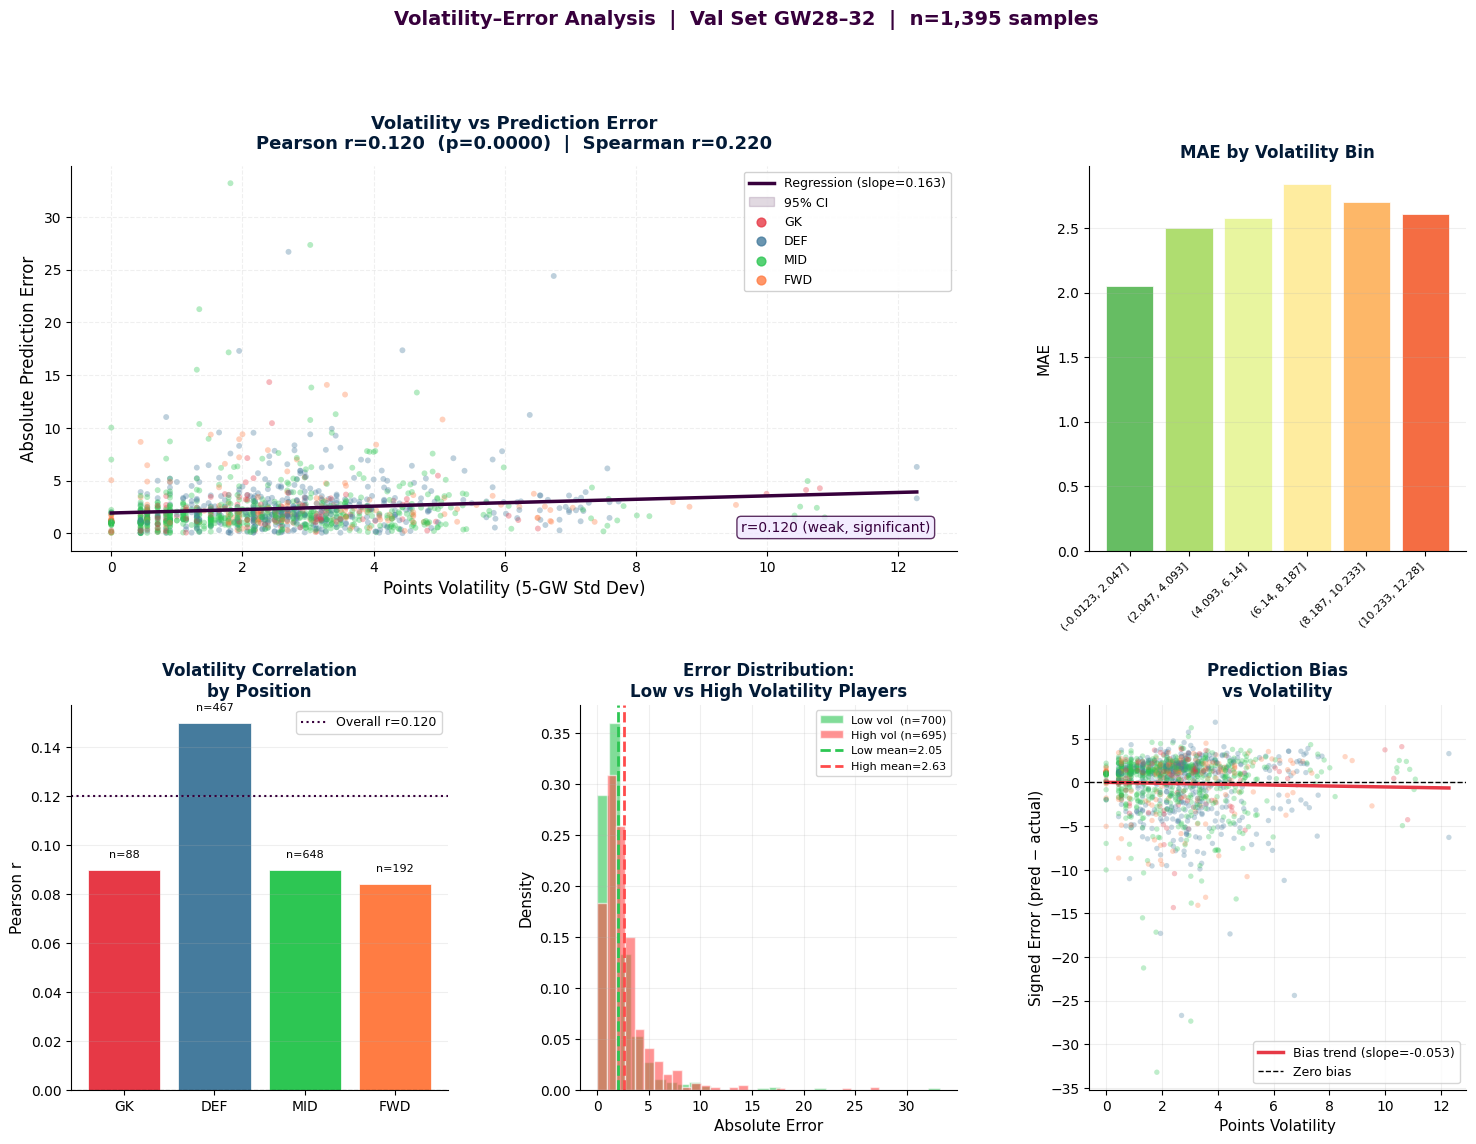


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  VOLATILITY–ERROR CORRELATION SUMMARY
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Pearson  r = 0.1202   p = 0.000007  (✓ significant)
  Spearman r = 0.2196   p = 0.000000
  Regression slope = 0.1626  (+1 unit volatility → +0.163 error)

  By Position:
    GK: r=+0.090  p=0.4052 ~  n=88
    DEF: r=+0.150  p=0.0011 ✓  n=467
    MID: r=+0.090  p=0.0224 ✓  n=648
    FWD: r=+0.084  p=0.2449 ~  n=192

  Low-vol  players (≤ median): MAE=2.053
  High-vol players (> median): MAE=2.630
  Volatility explains 1.4% of variance in prediction error (R²)

  Binned MAE table:


,N,MAE,Median
Volatility_Bin,,,
"(-0.0123, 2.047]",570,2.053,1.438
"(2.047, 4.093]",591,2.500,1.884
"(4.093, 6.14]",164,2.578,2.123
"(6.14, 8.187]",52,2.840,2.220
"(8.187, 10.233]",5,2.703,2.687
"(10.233, 12.28]",13,2.606,2.411



✓ volatility_corr_df saved (1,395 rows)
✓ Plot saved to output/forecaster_pro/volatility_error_analysis.png


In [54]:
# %% [Task 2.2 — Volatility vs Prediction Error Correlation]
# ============================================================
# Uses Points_Volatility_5 (5-GW std dev of points) to measure
# whether volatile players are harder to predict.
#
# Writes to: volatility_corr_df
# Requires:  y_val, preds_raw, X_val_raw, df_augmented,
#            Points_Volatility_5 (added in Cell 15)
# ============================================================


_y_true = np.array(globals().get('y_val', []))
_preds  = np.array(globals().get('preds_raw', []))
_X_val  = globals().get('X_val_raw')
_df_aug = globals().get('df_augmented')

if len(_y_true) == 0 or len(_preds) == 0:
    print("[ERROR] y_val or preds_raw not found. Run Cell 4 first.")
elif 'Points_Volatility_5' not in _df_aug.columns:
    print("[ERROR] Points_Volatility_5 not found. Run Cell 15 first.")
else:
    _abs_errors = np.abs(_y_true - _preds)
    _signed_err = _preds - _y_true

    # ── 1. ALIGN INDICES ──────────────────────────────────────────────────────
    _safe_val_idx = _X_val.index.intersection(_df_aug.index)
    _vol_series   = _df_aug.loc[_safe_val_idx, 'Points_Volatility_5']
    _aligned_idx  = _X_val.index[_X_val.index.isin(_safe_val_idx)]
    _pos_in_val   = [list(_X_val.index).index(i) for i in _aligned_idx]

    _volatility  = _vol_series.loc[_aligned_idx].values
    _errors_aln  = _abs_errors[_pos_in_val]
    _actuals_aln = _y_true[_pos_in_val]
    _signed_aln  = _signed_err[_pos_in_val]

    # Metadata
    _meta = _df_aug.loc[_aligned_idx,
                         ['Web Name', 'Position', 'season',
                          'Gameweek', 'avg_season_pts']].copy()
    _meta['Abs_Error']    = _errors_aln
    _meta['Signed_Error'] = _signed_aln
    _meta['Volatility']   = _volatility
    _meta['Actual_Pts']   = _actuals_aln

    volatility_corr_df = _meta.copy()
    globals()['volatility_corr_df'] = volatility_corr_df

    # ── 2. PEARSON + SPEARMAN CORRELATION ─────────────────────────────────────
    _r,       _p       = stats.pearsonr(_volatility, _errors_aln)
    _spear_r, _spear_p = stats.spearmanr(_volatility, _errors_aln)

    # Correlation by position
    _pos_corr = {}
    for _pos in ['GK', 'DEF', 'MID', 'FWD']:
        _mask = _meta['Position'] == _pos
        if _mask.sum() > 10:
            _pr, _pp = stats.pearsonr(
                _meta.loc[_mask, 'Volatility'],
                _meta.loc[_mask, 'Abs_Error']
            )
            _pos_corr[_pos] = {
                'r': round(_pr, 3),
                'p': round(_pp, 4),
                'n': int(_mask.sum())
            }

    # ── 3. BINNED ANALYSIS ────────────────────────────────────────────────────
    _vol_bins = pd.cut(_volatility, bins=6)
    _bin_summary = pd.DataFrame({
        'Volatility_Bin': _vol_bins,
        'Abs_Error':      _errors_aln,
    }).groupby('Volatility_Bin', observed=True).agg(
        N      = ('Abs_Error', 'count'),
        MAE    = ('Abs_Error', 'mean'),
        Median = ('Abs_Error', 'median'),
    ).round(3)

    # ── 4. FIVE-PANEL PLOT ────────────────────────────────────────────────────
    fig = plt.figure(figsize=(18, 12), facecolor='white')
    gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

    _pos_colours = {
        'GK': '#e63946', 'DEF': '#457b9d',
        'MID': '#2dc653', 'FWD': '#ff7c43', '?': '#888'
    }
    _colours = [_pos_colours.get(p, '#888') for p in _meta['Position']]

    # Panel 1 — Scatter + regression line
    ax1 = fig.add_subplot(gs[0, :2])
    ax1.scatter(_volatility, _errors_aln,
                c=_colours, alpha=0.35, s=18, linewidths=0)

    _slope, _intercept, _, _, _se = stats.linregress(_volatility, _errors_aln)
    _x_line = np.linspace(_volatility.min(), _volatility.max(), 200)
    _y_line = _slope * _x_line + _intercept
    ax1.plot(_x_line, _y_line, color='#37003c', linewidth=2.5,
             label=f'Regression (slope={_slope:.3f})')

    _n      = len(_volatility)
    _x_mean = _volatility.mean()
    _se_line = _se * np.sqrt(
        1/_n + (_x_line - _x_mean)**2 / np.sum((_volatility - _x_mean)**2)
    )
    ax1.fill_between(_x_line,
                     _y_line - 1.96 * _se_line,
                     _y_line + 1.96 * _se_line,
                     alpha=0.15, color='#37003c', label='95% CI')

    for _pos, _col in _pos_colours.items():
        if _pos == '?': continue
        ax1.scatter([], [], c=_col, s=40, label=_pos, alpha=0.8)

    _strength = ('weak' if abs(_r) < 0.3 else
                 'moderate' if abs(_r) < 0.6 else 'strong')
    _sig      = 'significant' if _p < 0.05 else 'not significant'

    ax1.annotate(
        f'r={_r:.3f} ({_strength}, {_sig})',
        xy=(0.97, 0.05), xycoords='axes fraction', ha='right',
        fontsize=10, color='#37003c',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='#f0e8ff',
                  edgecolor='#37003c', alpha=0.8)
    )
    ax1.set_xlabel('Points Volatility (5-GW Std Dev)', fontsize=12)
    ax1.set_ylabel('Absolute Prediction Error',        fontsize=12)
    ax1.set_title(
        f'Volatility vs Prediction Error\n'
        f'Pearson r={_r:.3f}  (p={_p:.4f})  |  Spearman r={_spear_r:.3f}',
        fontsize=13, fontweight='bold', color='#021a36', pad=12
    )
    ax1.legend(fontsize=9, framealpha=0.9)
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)
    ax1.grid(True, alpha=0.2, linestyle='--')

    # Panel 2 — Binned MAE bar chart
    ax2 = fig.add_subplot(gs[0, 2])
    _bin_labels  = [str(b) for b in _bin_summary.index]
    _bar_colors  = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(_bin_summary)))
    ax2.bar(range(len(_bin_summary)), _bin_summary['MAE'],
            color=_bar_colors, edgecolor='white', linewidth=0.5)
    ax2.set_xticks(range(len(_bin_summary)))
    ax2.set_xticklabels(_bin_labels, rotation=45, ha='right', fontsize=8)
    ax2.set_ylabel('MAE', fontsize=11)
    ax2.set_title('MAE by Volatility Bin', fontsize=12,
                  fontweight='bold', color='#021a36')
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)
    ax2.grid(True, axis='y', alpha=0.2)

    # Panel 3 — Correlation by position
    ax3 = fig.add_subplot(gs[1, 0])
    if _pos_corr:
        _pos_names = list(_pos_corr.keys())
        _pos_r     = [_pos_corr[p]['r'] for p in _pos_names]
        _pos_ns    = [_pos_corr[p]['n'] for p in _pos_names]
        _bar_cols  = [_pos_colours.get(p, '#888') for p in _pos_names]
        _bars = ax3.bar(_pos_names, _pos_r, color=_bar_cols,
                        edgecolor='white', linewidth=0.5)
        ax3.axhline(y=0,  color='black',   linewidth=0.8, linestyle='--')
        ax3.axhline(y=_r, color='#37003c', linewidth=1.5, linestyle=':',
                    label=f'Overall r={_r:.3f}')
        for _bar, _n_val in zip(_bars, _pos_ns):
            ax3.text(_bar.get_x() + _bar.get_width() / 2,
                     _bar.get_height() + 0.005,
                     f'n={_n_val}', ha='center', fontsize=8)
        ax3.set_ylabel('Pearson r', fontsize=11)
        ax3.set_title('Volatility Correlation\nby Position',
                      fontsize=12, fontweight='bold', color='#021a36')
        ax3.legend(fontsize=9)
        ax3.spines['top'].set_visible(False)
        ax3.spines['right'].set_visible(False)
        ax3.grid(True, axis='y', alpha=0.2)

    # Panel 4 — Low vs high vol error distribution
    ax4 = fig.add_subplot(gs[1, 1])
    _vol_median = np.median(_volatility)
    _low_mask   = _volatility <= _vol_median
    _high_mask  = _volatility >  _vol_median

    ax4.hist(_errors_aln[_low_mask],  bins=30, alpha=0.6, color='#2dc653',
             label=f'Low vol  (n={_low_mask.sum()})', density=True,
             edgecolor='white')
    ax4.hist(_errors_aln[_high_mask], bins=30, alpha=0.6, color='#ff4b4b',
             label=f'High vol (n={_high_mask.sum()})', density=True,
             edgecolor='white')
    ax4.axvline(_errors_aln[_low_mask].mean(),  color='#2dc653', linewidth=2,
                linestyle='--',
                label=f'Low mean={_errors_aln[_low_mask].mean():.2f}')
    ax4.axvline(_errors_aln[_high_mask].mean(), color='#ff4b4b', linewidth=2,
                linestyle='--',
                label=f'High mean={_errors_aln[_high_mask].mean():.2f}')
    ax4.set_xlabel('Absolute Error', fontsize=11)
    ax4.set_ylabel('Density',        fontsize=11)
    ax4.set_title('Error Distribution:\nLow vs High Volatility Players',
                  fontsize=12, fontweight='bold', color='#021a36')
    ax4.legend(fontsize=8)
    ax4.spines['top'].set_visible(False)
    ax4.spines['right'].set_visible(False)
    ax4.grid(True, alpha=0.2)

    # Panel 5 — Signed error bias vs volatility
    ax5 = fig.add_subplot(gs[1, 2])
    ax5.scatter(_volatility, _signed_aln,
                c=_colours, alpha=0.3, s=15, linewidths=0)
    _s2, _i2, _, _, _ = stats.linregress(_volatility, _signed_aln)
    _y2 = _s2 * _x_line + _i2
    ax5.plot(_x_line, _y2, color='#e63946', linewidth=2.5,
             label=f'Bias trend (slope={_s2:.3f})')
    ax5.axhline(y=0, color='black', linewidth=1, linestyle='--',
                label='Zero bias')
    ax5.set_xlabel('Points Volatility',               fontsize=11)
    ax5.set_ylabel('Signed Error (pred − actual)',     fontsize=11)
    ax5.set_title('Prediction Bias\nvs Volatility',
                  fontsize=12, fontweight='bold', color='#021a36')
    ax5.legend(fontsize=9)
    ax5.spines['top'].set_visible(False)
    ax5.spines['right'].set_visible(False)
    ax5.grid(True, alpha=0.2)

    plt.suptitle(
        f'Volatility–Error Analysis  |  '
        f'Val Set GW{globals().get("VAL_START_GW","?")}–'
        f'{globals().get("VAL_END_GW","?")}  |  '
        f'n={len(_volatility):,} samples',
        fontsize=14, fontweight='bold', color='#37003c', y=1.01
    )
    plt.savefig('../output/forecaster_pro/volatility_error_analysis.png',
                dpi=150, bbox_inches='tight', facecolor='white')
    plt.show()

    # ── 5. TEXT SUMMARY ───────────────────────────────────────────────────────
    print(f"\n{'━'*60}")
    print(f"  VOLATILITY–ERROR CORRELATION SUMMARY")
    print(f"{'━'*60}")
    print(f"  Pearson  r = {_r:.4f}   p = {_p:.6f}  "
          f"({'✓ significant' if _p < 0.05 else '✗ not significant'})")
    print(f"  Spearman r = {_spear_r:.4f}   p = {_spear_p:.6f}")
    print(f"  Regression slope = {_slope:.4f}  "
          f"(+1 unit volatility → +{_slope:.3f} error)")
    print(f"\n  By Position:")
    for _pos, _stats_pos in _pos_corr.items():
        _sig_marker = '✓' if _stats_pos['p'] < 0.05 else '~'
        print(f"    {_pos}: r={_stats_pos['r']:+.3f}  "
              f"p={_stats_pos['p']:.4f} {_sig_marker}  "
              f"n={_stats_pos['n']}")
    print(f"\n  Low-vol  players (≤ median): "
          f"MAE={_errors_aln[_low_mask].mean():.3f}")
    print(f"  High-vol players (> median): "
          f"MAE={_errors_aln[_high_mask].mean():.3f}")
    print(f"  Volatility explains "
          f"{_r**2*100:.1f}% of variance in prediction error (R²)")
    print(f"\n  Binned MAE table:")
    display(_bin_summary)

    print(f"\n✓ volatility_corr_df saved ({len(volatility_corr_df):,} rows)")
    print(f"✓ Plot saved to output/forecaster_pro/volatility_error_analysis.png")

## Final Model Performance Ledger

In [55]:
# %% [Cell: Final Standardized Audit — optimized]

def run_standardized_audit():
    # --- 0. SILENCE WARNING SPAM ---
    warnings.filterwarnings("ignore", category=UserWarning)
    
    audit_results = []

    # 1. DATASET INTEGRITY (Tracking) - FIX: Use safe intersection!
    safe_train_index = X_train_raw.index.intersection(df_augmented.index)
    safe_val_index   = X_val_raw.index.intersection(df_augmented.index)

    train_uuids = df_augmented.loc[safe_train_index, 'Player UUID'].nunique()
    val_uuids   = df_augmented.loc[safe_val_index, 'Player UUID'].nunique()
    train_obs   = len(X_train_raw)
    seasons_count = df_augmented.loc[safe_train_index, 'season'].nunique()
    pos_map_numeric = {'GK': 0, 'DEF': 1, 'MID': 2, 'FWD': 3}

    # 2. DEFINE MODEL SPECS (Baseline Added)
    specs = {
    "Baseline (3-Wk Avg)": {"model": "NAIVE",                               "type": "naive"},
    "V1: Standard Pro":    {"model": globals().get('model_raw'),            "type": "base"},
    "V2: Team Share":      {"model": globals().get('model_v2'),             "type": "v2"},
    "V3: Reliability":     {"model": globals().get('model_v3'),             "type": "v3"},
    "V4: Elite DART":      {"model": globals().get('model_v4'),             "type": "base"},
    "V5.1: Mass Gen":      {"model": globals().get('model_v5_1_mass'),      "type": "base"},
    "V5.2: Elite Spec":    {"model": globals().get('model_v5_2_elite'),     "type": "base"},
    "V7: xG/xA Metrics":   {"model": globals().get('model_v7'),             "type": "v7"}, 
    }
    
    # 3. HISTORY LOOKUP
    player_history = {pid: group.sort_values(['season', 'Gameweek']) for pid, group in df_augmented.groupby('Player UUID')}

    def predict_row(m, r, mode):
        hist_df = player_history.get(r['Player UUID'])
        if hist_df is None: return None
        recent = hist_df[(hist_df['season'] == r['season']) & (hist_df['Gameweek'] < r['Gameweek'])].tail(6)
        if len(recent) < 6: return None
        
        lags = list(recent['Total Points'].values)
        pos_num = pos_map_numeric.get(r['Position'], 2)

        # Baseline Logic
        if mode == "naive":
            return np.mean(lags[-3:]) if len(lags) >= 3 else np.mean(lags)

        if mode == "base":
            feat = lags + [pos_num, r['Next_Opponent_Difficulty'], r['Next_Is_Home'], r['Rolling_Avg_Minutes_5'], r['Season_Phase'], r['Prev_Season_Avg_Points'], r.get('Avg_Pts_vs_Difficulty', 0)]
            cols = [f'lag_{i}' for i in range(6, 0, -1)] + ['position', 'next_difficulty', 'next_is_home', 'rolling_min', 'season_phase', 'season_baseline', 'avg_pts_vs_diff']
            
        elif mode == "v2":
            feat = lags + [pos_num, r['Next_Opponent_Difficulty'], r['Next_Is_Home'], r['Rolling_Avg_Minutes_5'], r['Season_Phase'], r['Prev_Season_Avg_Points'], r['Team_Point_Share'], r.get('Avg_Pts_vs_Difficulty', 0)]
            cols = [f'lag_{i}' for i in range(6, 0, -1)] + ['position', 'next_difficulty', 'next_is_home', 'rolling_min', 'season_phase', 'season_baseline', 'team_share', 'avg_pts_vs_diff']

        elif mode == "v3":
            feat = lags + [pos_num, r['Next_Opponent_Difficulty'], r['Next_Is_Home'], r['Rolling_Avg_Minutes_5'], r['Points_Volatility_5'], r['Min_Stability_5'], r['Attacking_Form_3'], r['Team_Point_Share'], r.get('Avg_Pts_vs_Difficulty', 0)]    
            cols = [f'lag_{i}' for i in range(6, 0, -1)] + ['position', 'diff', 'home', 'min', 'volatility', 'stability', 'att_form', 'share', 'avg_pts_vs_diff']

        elif mode == "v7":
            feat = lags + [
                pos_num,
                r['Next_Opponent_Difficulty'],
                r['Next_Is_Home'],
                r['Rolling_Avg_Minutes_5'],
                r['Season_Phase'],
                r['Prev_Season_Avg_Points'],
                r.get('Avg_Pts_vs_Difficulty', 0),
                r.get('Rolling_xGI_5', 0)
            ]
            cols = [f'lag_{i}' for i in range(6, 0, -1)] + [
                'position', 'next_difficulty', 'next_is_home', 'rolling_min',
                'season_phase', 'season_baseline', 'avg_pts_vs_diff', 'rolling_xgi'
            ]

        input_df = pd.DataFrame([feat], columns=cols)
        
        # Safely lock the categorical position column
        if 'X_train_raw' in globals() and 'position' in X_train_raw.columns:
            input_df['position'] = pd.Categorical(input_df['position'], categories=X_train_raw['position'].cat.categories)
        else:
            input_df['position'] = input_df['position'].astype('category')
            
        return m.predict(input_df)[0]

    # 4. EXECUTION
    for name, config in specs.items():
        m = config['model']
        if m is None and config['type'] != 'naive': continue
        print(f"Auditing {name}...")

        #v_mask = (df_augmented['season'] == '2025-26') & (df_augmented['Gameweek'].between(24, 28))
        _val_start = globals().get('VAL_START_GW', 28)
        _val_end   = globals().get('VAL_END_GW', 32)
        v_mask = (df_augmented['season'] == '2025-26') & (df_augmented['Gameweek'].between(_val_start, _val_end))
        if "Elite" in name or "V5" in name: 
            v_mask = v_mask & (df_augmented['avg_season_pts'] > 4.5)

        v_errs, v_errs_gt5, v_acts, v_preds = [], [], [], []

        for _, r in df_augmented[v_mask].iterrows():
            p = predict_row(m, r, config['type'])
            if p is not None:
                act = r['Total Points']
                v_errs.append(abs(p - act))
                v_acts.append(act); v_preds.append(p)
                
                if act > 4.5:
                    v_errs_gt5.append(abs(p - act))

        audit_results.append({
            "Model Version": name,
            "Validation MAE": round(np.mean(v_errs), 3),
            "Elite MAE (>4.5)": round(np.mean(v_errs_gt5), 3) if v_errs_gt5 else None,
            "Spearman Rank": round(spearmanr(v_acts, v_preds)[0], 3) if len(v_acts) > 1 else 0,
            "Train Players": train_uuids, 
            "Val Players": val_uuids,
            "Train Obs": train_obs, 
            "Seasons": seasons_count
        })

    # --- 5. FINAL DISPLAY & REPORT SUMMARY ---
    print("\n" + "="*50)
    print(" AUDIT COMPLETE")
    print("="*50)
    
    print(f"\nREPORT SUMMARY:")
    print(f"This run analyzed {seasons_count} seasons across {train_uuids:,} training players "
      f"and {val_uuids:,} validation players.")
    print(f"Training observations: {train_obs:,} match windows.")
    # Fix: Safely default to global variables or hardcoded values
    val_season = globals().get('VAL_SEASON', '2025-26')
    val_start_gw = globals().get('VAL_START_GW', 28)
    val_end_gw = globals().get('VAL_END_GW', 32)
    print(f"Validation window: {val_season} GW {val_start_gw}–{val_end_gw} "
      f"({val_uuids:,} unique players tested).")
    print("-" * 50)
    
    final_df = pd.DataFrame(audit_results).sort_values("Validation MAE")

    # ── ADD DESCRIPTION COLUMN ───────────────────────────────────
    descriptions = {
        "Baseline (3-Wk Avg)":  "Naive: predicts next GW=average of last 3 scores.No ML.",
        "V1: Standard Pro":     "Core LightGBM: lags+ minutes+ fixture difficulty+ season baseline.",
        "V2: Team Share":       "V1+ talisman logic: rewards players who drive their team's output.",
        "V3: Reliability":      "V2+ noise filters: penalises volatile players, rewards nailed starters.",
        "V4: Elite DART":       "V1 features+ DART boosting+ 2.5x weight on elite players (>4.5 avg).",
        "V5.1: Mass Gen":       "V1 trained on full league history, evaluated on elite players only.",
        "V5.2: Elite Spec":     "V1 trained exclusively on elite players (>4.5 avg).High-risk, high-reward.",
        "V7: xG/xA Metrics": "V4 architecture + Rolling xGI (Expected Goal Involvement) as 13th feature.",
    }
    final_df.insert(1, "Description", final_df["Model Version"].map(descriptions).fillna("—"))

    display(Markdown("# Final Model Performance Ledger"))
    display(final_df)

    # ── HAUL CLASSIFIER ADDENDUM ─────────────────────────────────
    print("\n" + "=" * 50)
    print(" CLASSIFICATION BENCHMARK")
    print("=" * 50)

    # Haul classifier row
    _prec  = globals().get('precision_haul', None)
    _rec   = globals().get('recall_haul',    None)
    _f1    = globals().get('f1_haul',        None)
    _auc   = globals().get('auc_haul',       None)
    _hthr  = globals().get('HAUL_THRESHOLD', 10)
    _dthr  = globals().get('DECISION_THRESHOLD', 0.35)

    if _prec is not None:
        print(f"Haul Classifier (threshold >= {_hthr} pts, cutoff {_dthr}):")
        print(f"  Precision: {_prec:.4f}  ← Priority")
        print(f"  Recall:    {_rec:.4f}")
        print(f"  F1:        {_f1:.4f}")
        print(f"  ROC-AUC:   {_auc:.4f}")
    else:
        print("Haul Classifier metrics not found — run the Haul cell first.")

    print("=" * 50)

    return final_df

# Execute
master_audit_results = run_standardized_audit()

Auditing Baseline (3-Wk Avg)...
Auditing V1: Standard Pro...
Auditing V2: Team Share...
Auditing V3: Reliability...
Auditing V4: Elite DART...
Auditing V5.1: Mass Gen...
Auditing V5.2: Elite Spec...

 AUDIT COMPLETE

REPORT SUMMARY:
This run analyzed 6 seasons across 1,110 training players and 380 validation players.
Training observations: 51,336 match windows.
Validation window: 2025-26 GW 28–32 (380 unique players tested).
--------------------------------------------------


# Final Model Performance Ledger

,Model Version,Description,Validation MAE,Elite MAE (>4.5),Spearman Rank,Train Players,Val Players,Train Obs,Seasons
3,V3: Reliability,"V2+ noise filters: penalises volatile players,...",2.330,4.840,0.274,1110,380,51336,6
1,V1: Standard Pro,Core LightGBM: lags+ minutes+ fixture difficul...,2.340,4.738,0.282,1110,380,51336,6
2,V2: Team Share,V1+ talisman logic: rewards players who drive ...,2.346,4.725,0.279,1110,380,51336,6
0,Baseline (3-Wk Avg),Naive: predicts next GW=average of last 3 scor...,2.545,4.733,0.218,1110,380,51336,6
5,V5.1: Mass Gen,"V1 trained on full league history, evaluated o...",3.964,6.316,0.013,1110,380,51336,6
4,V4: Elite DART,V1 features+ DART boosting+ 2.5x weight on eli...,3.969,6.126,-0.007,1110,380,51336,6
6,V5.2: Elite Spec,V1 trained exclusively on elite players (>4.5 ...,4.067,5.213,-0.035,1110,380,51336,6



 CLASSIFICATION BENCHMARK
Haul Classifier (threshold >= 10 pts, cutoff 0.35):
  Precision: 0.1449  ← Priority
  Recall:    0.1351
  F1:        0.1399
  ROC-AUC:   0.6452


__Performamce Comments__
- V1 is a good model
- V5.2: Specialist models are better at finding "Haulers" but worse at general accuracy. -->"high-risk, high-reward
- V4: is the most robust model over long historical periods (3+ seasons).

__Idea__ : maybe V1 for players and v5.2 for captain? or V5.2 for some players? 

__Info__
- __Validation MAE__ : The Mean Absolute Error across the entire validation set ($GW 24-28$). It measures the average point deviation for every player; a lower value indicates a more stable model for general squad selection.
- __Elite MAE (>4.5)__ : Calculated exclusively for match rows where a player actually scored more than 5 points. This measures "Haul Accuracy"—the model's ability to minimize error during high-scoring events.
- __Haul Capture Rate__ : The percentage of "Hauls" (actual scores $>4.5$) that the model successfully predicted would score $>4.5$. This satisfies the question "When a player scored more than 5, did I correctly predict it?"
- __Spearman Rank__ : A correlation coefficient (from $-1$ to $+1$) measuring how well the model orders players from best to worst. A high score proves the model is effective at ranking starters over bench players, regardless of the exact point value.
- __Train Players / Val Players__ : The count of unique Player UUIDs present in the training set / val set
- __Train Obs__ : The total number of match observations (rows) the model studied during training.
- __Seasons__ : The number of full seasons of historical data used to train the model.

Generating V6 Windows with 3-GW Target Horizon...
Training V6 3-GW Horizon Model...
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[272]	valid_0's l2: 32.8568

 V6 HORIZON EXPERIMENT (3-GW TARGET)
NOTE: MAE will be higher here because we are predicting
a 3-week sum (~8-12 points) instead of a 1-week score (~3 points).
--------------------------------------------------
Naive 3-GW Baseline MAE: 7.2003
V6 Horizon MAE:          4.3079

[SUCCESS] The V6 model beats the naive 3-week baseline by 2.89 points.


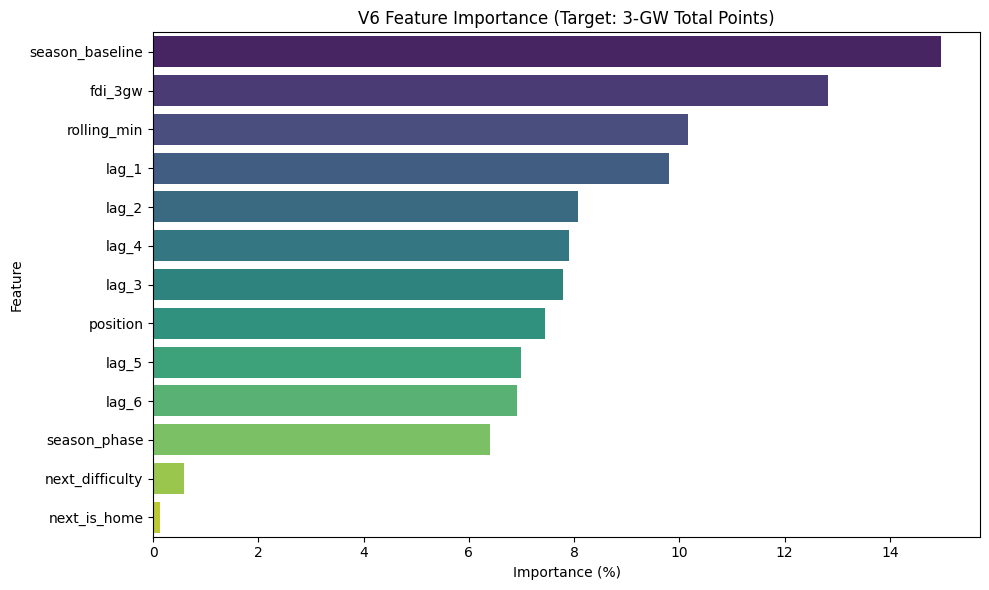

In [56]:
# [Cell: V6 Pipeline — 3-Week Horizon Engine - triple prediction]

# 1. GENERATE WINDOWS FOR 3-WEEK TARGET
def generate_fpl_windows_3gw(df, window_size=6, horizon=3):
    train_data = []
    source_indices = []
    df = df.sort_values(['Player UUID', 'season', 'Gameweek'])

    for pid, group in df.groupby('Player UUID'):
        points = group['Total Points'].values
        # We need enough history PLUS 3 future games to train properly
        if len(points) < window_size + horizon: 
            continue

        pos = group['Position'].iloc[0]
        next_diff = group['Next_Opponent_Difficulty'].values
        next_home = group['Next_Is_Home'].values
        avg_min = group['Rolling_Avg_Minutes_5'].values
        phase = group['Season_Phase'].values
        baseline = group['Prev_Season_Avg_Points'].values
        fdi = group['FDI_3GW'].values
        group_indices = group.index.tolist()

        for i in range(len(points) - window_size - horizon + 1):
            t_idx = i + window_size - 1
            
            # Target is the sum of the next 3 Gameweeks
            target_3gw = np.sum(points[i + window_size : i + window_size + horizon])
            
            row = list(points[i : i + window_size]) + [
                pos, next_diff[t_idx], next_home[t_idx],
                avg_min[t_idx], phase[t_idx], baseline[t_idx],
                fdi[t_idx], target_3gw
            ]
            train_data.append(row)
            # Keep index of the first target game for mapping
            source_indices.append(group_indices[i + window_size])

    cols = [f'lag_{i}' for i in range(6, 0, -1)] + \
           ['position', 'next_difficulty', 'next_is_home', 'rolling_min', 
            'season_phase', 'season_baseline', 'fdi_3gw', 'target_3gw']
    
    res_df = pd.DataFrame(train_data, columns=cols)
    res_df.index = source_indices 
    res_df['position'] = res_df['position'].astype('category')
    return res_df

print("Generating V6 Windows with 3-GW Target Horizon...")
df_win_v6 = generate_fpl_windows_3gw(df_augmented)

# 2. APPLY FAIR SPLIT (Fixed for new index length)
# Rebuild the mask specifically for the V6 index
VAL_SEASON = "2025-26"
#VAL_START_GW = 28
#VAL_END_GW = 32

VAL_START_GW = globals().get('VAL_START_GW', 28)
VAL_END_GW   = globals().get('VAL_END_GW', 32)

source_meta_v6 = df_augmented.loc[df_win_v6.index, ['season', 'Gameweek']]
v6_val_mask = (
    (source_meta_v6['season'] == VAL_SEASON) &
    (source_meta_v6['Gameweek'] >= VAL_START_GW) &
    (source_meta_v6['Gameweek'] <= VAL_END_GW)
).values

X_v6_all = df_win_v6.drop(columns=['target_3gw'])
y_v6_all = df_win_v6['target_3gw']

X_train_v6 = X_v6_all[~v6_val_mask].copy()
X_val_v6   = X_v6_all[v6_val_mask].copy()
y_train_v6 = y_v6_all[~v6_val_mask].copy()
y_val_v6   = y_v6_all[v6_val_mask].copy()

# 3. TRAIN V6 HORIZON MODEL
print("Training V6 3-GW Horizon Model...")
model_v6 = lgb.LGBMRegressor(n_estimators=1000, learning_rate=0.01, verbosity=-1, random_state=42)
model_v6.fit(
    X_train_v6, y_train_v6,
    eval_set=[(X_val_v6, y_val_v6)],
    categorical_feature=['position', 'next_is_home'],
    callbacks=[lgb.early_stopping(stopping_rounds=50)]
)

# 4. EVALUATE IMPACT
v6_preds = model_v6.predict(X_val_v6)
mae_v6 = mean_absolute_error(y_val_v6, v6_preds)

# Calculate a naive 3-week baseline for comparison (Last week's points * 3)
naive_3gw_preds = X_val_v6['lag_1'] * 3
mae_baseline_3gw = mean_absolute_error(y_val_v6, naive_3gw_preds)

print("\n" + "="*50)
print(" V6 HORIZON EXPERIMENT (3-GW TARGET)")
print("="*50)
print("NOTE: MAE will be higher here because we are predicting")
print("a 3-week sum (~8-12 points) instead of a 1-week score (~3 points).")
print("-" * 50)
print(f"Naive 3-GW Baseline MAE: {mae_baseline_3gw:.4f}")
print(f"V6 Horizon MAE:          {mae_v6:.4f}")

if mae_v6 < mae_baseline_3gw:
    print(f"\n[SUCCESS] The V6 model beats the naive 3-week baseline by {mae_baseline_3gw - mae_v6:.2f} points.")
else:
    print("\n[WARNING] The model struggles to forecast 3 weeks out.")

# 5. PLOT FEATURE IMPORTANCE
plt.figure(figsize=(10, 6))
importances = model_v6.feature_importances_
feat_imp = pd.DataFrame({'Feature': X_train_v6.columns, 'Importance (%)': 100 * (importances / importances.sum())})
feat_imp = feat_imp.sort_values(by='Importance (%)', ascending=False)
#sns.barplot(x='Importance (%)', y='Feature', data=feat_imp, palette='viridis')
sns.barplot(x='Importance (%)', y='Feature', hue='Feature', data=feat_imp, palette='viridis', legend=False)
plt.title('V6 Feature Importance (Target: 3-GW Total Points)')
plt.tight_layout()
plt.show()

__The next cell__ Trains a 3-GW Standard Model (Baseline features).

Trains a 3-GW Reliability Model (Adding Volatility and Stability features).

Trains a 3-GW DART Model (Using the elite dropout technique).

Outputs a 3-GW Transfer Engine Leaderboard to see which one wins.

In [57]:
# %% [Cell: V6 Transfer Engine Leaderboard (3-Week Horizon)]

# 1. THE MASTER 3-GW WINDOW GENERATOR
def generate_master_3gw_windows(df, window_size=6, horizon=3):
    train_data = []
    source_indices = []
    df = df.sort_values(['Player UUID', 'season', 'Gameweek'])

    for pid, group in df.groupby('Player UUID'):
        points = group['Total Points'].values
        if len(points) < window_size + horizon: 
            continue

        pos = group['Position'].iloc[0]
        next_diff = group['Next_Opponent_Difficulty'].values
        next_home = group['Next_Is_Home'].values
        avg_min   = group['Rolling_Avg_Minutes_5'].values
        phase     = group['Season_Phase'].values
        baseline  = group['Prev_Season_Avg_Points'].values
        fdi       = group['FDI_3GW'].values
        
        # Advanced Features
        vol       = group['Points_Volatility_5'].values
        stab      = group['Min_Stability_5'].values
        att_form  = group['Attacking_Form_3'].values
        share     = group['Team_Point_Share'].values
        
        group_indices = group.index.tolist()

        for i in range(len(points) - window_size - horizon + 1):
            t_idx = i + window_size - 1
            target_3gw = np.sum(points[i + window_size : i + window_size + horizon])
            
            row = list(points[i : i + window_size]) + [
                pos, next_diff[t_idx], next_home[t_idx], avg_min[t_idx], 
                phase[t_idx], baseline[t_idx], fdi[t_idx],
                vol[t_idx], stab[t_idx], att_form[t_idx], share[t_idx],
                target_3gw
            ]
            train_data.append(row)
            source_indices.append(group_indices[i + window_size])

    cols = [f'lag_{i}' for i in range(6, 0, -1)] + \
           ['position', 'next_difficulty', 'next_is_home', 'rolling_min', 
            'season_phase', 'season_baseline', 'fdi_3gw', 
            'volatility', 'stability', 'att_form', 'team_share', 'target_3gw']
    
    res_df = pd.DataFrame(train_data, columns=cols)
    res_df.index = source_indices 
    res_df['position'] = res_df['position'].astype('category')
    return res_df

print("Generating Master 3-GW Windows (includes all advanced features)...")
df_win_3gw = generate_master_3gw_windows(df_augmented)

# 2. APPLY FAIR SPLIT (Index-Matched)
VAL_SEASON = "2025-26"
VAL_START_GW = 28
VAL_END_GW = 32

source_meta_3gw = df_augmented.loc[df_win_3gw.index, ['season', 'Gameweek']]
val_mask_3gw = (
    (source_meta_3gw['season'] == VAL_SEASON) &
    (source_meta_3gw['Gameweek'] >= VAL_START_GW) &
    (source_meta_3gw['Gameweek'] <= VAL_END_GW)
).values

X_all_3gw = df_win_3gw.drop(columns=['target_3gw'])
y_all_3gw = df_win_3gw['target_3gw']

X_train_3gw = X_all_3gw[~val_mask_3gw].copy()
X_val_3gw   = X_all_3gw[val_mask_3gw].copy()
y_train_3gw = y_all_3gw[~val_mask_3gw].copy()
y_val_3gw   = y_all_3gw[val_mask_3gw].copy()

# 3. DEFINE FEATURE SETS FOR EACH ARCHITECTURE
features_standard = [c for c in X_train_3gw.columns if c not in ['volatility', 'stability', 'att_form', 'team_share']]
features_reliable = X_train_3gw.columns.tolist() # Uses everything

# 4. TRAIN THE COMPETITORS
print("\nTraining Model A: Standard 3-GW Horizon...")
model_3gw_std = lgb.LGBMRegressor(n_estimators=1000, learning_rate=0.01, verbosity=-1, random_state=42)
model_3gw_std.fit(
    X_train_3gw[features_standard], y_train_3gw,
    eval_set=[(X_val_3gw[features_standard], y_val_3gw)],
    categorical_feature=['position'],
    callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)]
)

print("Training Model B: Reliability 3-GW Horizon...")
model_3gw_rel = lgb.LGBMRegressor(n_estimators=1000, learning_rate=0.01, reg_alpha=0.3, reg_lambda=0.3, verbosity=-1, random_state=42)
model_3gw_rel.fit(
    X_train_3gw[features_reliable], y_train_3gw,
    eval_set=[(X_val_3gw[features_reliable], y_val_3gw)],
    categorical_feature=['position'],
    callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)]
)

print("Training Model C: Elite DART 3-GW Horizon (Takes longer)...")
elite_weights_mask = df_win_3gw.index.isin(df_augmented.index[elite_mask])
train_weights_3gw = np.where(elite_weights_mask[~val_mask_3gw], 2.5, 1.0)

model_3gw_dart = lgb.LGBMRegressor(boosting_type='dart', n_estimators=1200, learning_rate=0.05, drop_rate=0.1, verbosity=-1, random_state=42)
model_3gw_dart.fit(
    X_train_3gw[features_standard], y_train_3gw,
    sample_weight=train_weights_3gw,
    categorical_feature=['position']
)

# 5. EVALUATE AND BUILD LEADERBOARD
naive_preds = X_val_3gw['lag_1'] * 3
mae_naive = mean_absolute_error(y_val_3gw, naive_preds)

mae_std  = mean_absolute_error(y_val_3gw, model_3gw_std.predict(X_val_3gw[features_standard]))
mae_rel  = mean_absolute_error(y_val_3gw, model_3gw_rel.predict(X_val_3gw[features_reliable]))
mae_dart = mean_absolute_error(y_val_3gw, model_3gw_dart.predict(X_val_3gw[features_standard]))

results_3gw = [
    {"Transfer Engine": "Naive Baseline (Current Form x3)", "3-Week MAE": round(mae_naive, 4)},
    {"Transfer Engine": "Model A: Standard 3-GW", "3-Week MAE": round(mae_std, 4)},
    {"Transfer Engine": "Model B: Reliability 3-GW", "3-Week MAE": round(mae_rel, 4)},
    {"Transfer Engine": "Model C: Elite DART 3-GW", "3-Week MAE": round(mae_dart, 4)}
]

leaderboard_3gw = pd.DataFrame(results_3gw).sort_values(by="3-Week MAE")

# Save winning model to memory for the Transfer Optimizer
best_3gw_name = leaderboard_3gw.iloc[0]["Transfer Engine"]
if "Model A" in best_3gw_name: globals()['winning_3gw_model'] = model_3gw_std; globals()['winning_3gw_feats'] = features_standard
elif "Model B" in best_3gw_name: globals()['winning_3gw_model'] = model_3gw_rel; globals()['winning_3gw_feats'] = features_reliable
elif "Model C" in best_3gw_name: globals()['winning_3gw_model'] = model_3gw_dart; globals()['winning_3gw_feats'] = features_standard

print("\n" + "="*60)
print(" 3-WEEK TRANSFER ENGINE LEADERBOARD (Predicting Next 3 Games)")
print("="*60)
display(leaderboard_3gw)
print(f"\n[SYSTEM UPDATE] {best_3gw_name} won the audit and has been locked in as your official Transfer Engine.")

Generating Master 3-GW Windows (includes all advanced features)...

Training Model A: Standard 3-GW Horizon...
Training Model B: Reliability 3-GW Horizon...
Training Model C: Elite DART 3-GW Horizon (Takes longer)...

 3-WEEK TRANSFER ENGINE LEADERBOARD (Predicting Next 3 Games)


,Transfer Engine,3-Week MAE
2,Model B: Reliability 3-GW,4.2918
1,Model A: Standard 3-GW,4.3079
3,Model C: Elite DART 3-GW,4.3079
0,Naive Baseline (Current Form x3),7.2003



[SYSTEM UPDATE] Model B: Reliability 3-GW won the audit and has been locked in as your official Transfer Engine.


In [58]:
# %% [Cell: Collision-Safe Lookup Maps — use UUID as ground truth]

# Build from df_augmented directly using UUID as key (immune to name collisions)
CURRENT_SEASON = globals().get('CURRENT_SEASON', '2025-26')
_curr = df_augmented[df_augmented['season'] == CURRENT_SEASON].copy()

# CRITICAL FIX: Sort by Gameweek (descending) to capture mid-season transfers.
# The player's MOST RECENT match dictates their current official club and position.
_curr_deduped = (
    _curr.sort_values('Gameweek', ascending=False)
         .drop_duplicates('Player UUID')
)

# UUID-keyed maps (safe)
uuid_to_pos   = _curr_deduped.set_index('Player UUID')['Position'].to_dict()
uuid_to_club  = _curr_deduped.set_index('Player UUID')['Player Team Name'].to_dict()
uuid_to_name  = _curr_deduped.set_index('Player UUID')['Web Name'].to_dict()

# Web Name-keyed maps (for UI dropdowns and Optimizer Constraints)
pos_map  = _curr_deduped.set_index('Web Name')['Position'].to_dict()
club_map = _curr_deduped.set_index('Web Name')['Player Team Name'].to_dict()

# Audit: flag any Web Names that STILL map to multiple positions after dedup
collision_audit = (
    _curr.groupby('Web Name')['Player UUID']
         .nunique()
         .reset_index()
         .query('`Player UUID` > 1')
)

print("--- LOOKUP MAP GENERATION ---")
if collision_audit.empty:
    print("OK: pos_map and club_map are collision-free for the current season.")
    print("OK: Mid-season transfers are successfully mapped to their newest clubs.")
else:
    print(f"WARNING: {len(collision_audit)} names still collide in {CURRENT_SEASON}:")
    for _, row in collision_audit.iterrows():
        uuids = _curr[_curr['Web Name'] == row['Web Name']]['Player UUID'].unique()
        names = [_curr_deduped[_curr_deduped['Player UUID'] == u]['Player Name'].values for u in uuids]
        print(f"  '{row['Web Name']}' -> {[n[0] for n in names if len(n)]}")
    print("\nAdd manual overrides below for any flagged names:")

# Manual overrides for genuinely ambiguous cases (e.g. two active players with same suffix)

known_overrides = {
    'Armstrong': ('FWD', 'Southampton'),      # Adam Armstrong > Harrison Armstrong
    'Barnes':    ('MID', 'Newcastle'),        # Harvey Barnes > Ashley Barnes
    'Gomez':     ('DEF', 'Liverpool'),        # Joe Gomez > Diego Gomez
    'Henderson': ('GK',  'Crystal Palace'),   # Dean Henderson > Jordan Henderson
    'James':     ('DEF', 'Chelsea'),          # Reece James > Dan James
    'Martinez':  ('GK',  'Aston Villa'),      # Emi Martinez > Lisandro Martinez
    'Mosquera':  ('DEF', 'Wolves'),           # Yerson Mosquera > Cristhian Mosquera
    'Wilson':    ('MID', 'Fulham'),           # Harry Wilson > Callum Wilson (or FWD/Newcastle if you prefer Callum)
    'Anderson':  ('MID', 'Sunderland')   
}

for name, (pos, club) in known_overrides.items():
    pos_map[name]  = pos
    club_map[name] = club

--- LOOKUP MAP GENERATION ---
  'Armstrong' -> ['Adam Armstrong', 'Harrison Armstrong']
  'Barnes' -> ['Harvey Barnes', 'Ashley Barnes']
  'Gomez' -> ['Joe Gomez', 'Diego Gómez Amarilla']
  'Henderson' -> ['Dean Henderson', 'Jordan Henderson']
  'James' -> ['Daniel James', 'Reece James']
  'Martinez' -> ['Lisandro Martínez', 'Emiliano Martínez Romero']
  'Mosquera' -> ['Yerson Mosquera Valdelamar', 'Cristhian Mosquera']
  'Wilson' -> ['Callum Wilson', 'Harry Wilson']

Add manual overrides below for any flagged names:


In [59]:
def patch_lookup_aliases():
    global club_map, pos_map
    
    # Bridge: CSV web_name → FPL API web_name
    aliases = {
        "Salah":                "M.Salah",
        "Mohamed Salah":        "M.Salah",
        "Fernandes":            "B.Fernandes",
        "Bruno Borges Fernandes": "B.Fernandes",
        "Guimarães":            "Bruno G.",
        "Bruno Guimarães Rodriguez Moura": "Bruno G.",
        "Alexander-Arnold":     "Trent Alexander-Arnold",
        "Virgil":               "Van Dijk",
        "Van Dijk":             "Van Dijk",
        "Virgil van Dijk":      "Van Dijk",
    }

    added_count = 0
    for csv_name, ui_name in aliases.items():
        if csv_name in club_map:
            club_map[ui_name] = club_map[csv_name]
            pos_map[ui_name]  = pos_map[csv_name]
            added_count += 1

    # ── HARD CORRECTIONS (actual 2025-26 reality) ──────────────────────────
    corrections = {
        # Goalkeepers
        'Kelleher':    ('GK',  'Brentford'),      # transferred to Brentford
        'Darlow':      ('GK',  'Leeds'),
        # Defenders
        'Gabriel':     ('DEF', 'Arsenal'),
        'Konaté':      ('DEF', 'Liverpool'),
        'Cucurella':   ('DEF', 'Chelsea'),
        'Acheampong':  ('DEF', 'Chelsea'),
        # Midfielders
        'M.Salah':     ('MID', 'Liverpool'),
        'Bruno G.':    ('MID', 'Newcastle'),
        'Rice':        ('MID', 'Arsenal'),
        'Mbeumo':      ('MID', 'Man Utd'),         # transferred to Man Utd
        'Anderson':    ('MID', 'Sunderland'),
        'Madueke':     ('MID', 'Arsenal'),
        # Forwards
        'Watkins':     ('FWD', 'Aston Villa'),
        'Welbeck':     ('FWD', 'Brighton'),
        'Evanilson':   ('FWD', 'Bournemouth'),
        # Name variants for Van Dijk
        'Van Dijk':    ('DEF', 'Liverpool'),
        'Virgil':      ('DEF', 'Liverpool'),
        # Martinez disambiguation (GK = Emi, not Lisandro)
        'Martinez':    ('GK',  'Aston Villa'),
        'James':       ('DEF', 'Chelsea'),
    }

    for name, (pos, club) in corrections.items():
        club_map[name] = club
        pos_map[name]  = pos

    print(f"Patch complete. Added {added_count} aliases and {len(corrections)} corrections.")
    print(f"Total players in map: {len(club_map)}")
    print(f"Verification — M.Salah: {club_map.get('M.Salah')} | Bruno G.: {club_map.get('Bruno G.')} | Kelleher: {club_map.get('Kelleher')} | Mbeumo: {club_map.get('Mbeumo')}")

patch_lookup_aliases()

Patch complete. Added 2 aliases and 19 corrections.
Total players in map: 515
Verification — M.Salah: Liverpool | Bruno G.: Newcastle | Kelleher: Brentford | Mbeumo: Man Utd


In [117]:
# %% [Cell: Final Data Scrub - Removing Inactive Players & Position Fixes]

# 1. PURGE INACTIVE PLAYERS (Ensure they don't take up Dead Fodder slots)
# Joe Anderson (Barrow/L2), Karl Darlow (Leeds/Champ), and previous ghosts
verified_ghosts = ['Mane', 'Bale', 'Sadio Mané', 'Joe Anderson', 'Karl Darlow',
                   'Trent Alexander-Arnold']

initial_count = len(df_augmented)
df_augmented = df_augmented[~(
    (df_augmented['Web Name'].isin(verified_ghosts)) & 
    (df_augmented['season'] == '2025-26')
)].copy()

print(f"Purge Complete: Removed {initial_count - len(df_augmented)} rows. AI will no longer pick non-PL fillers.")

# 2. OVERRIDE MAPS (Fix Madueke and Cucurella for 2025-26 reality)
# Madueke is at Arsenal; Cucurella is a Defender.

manual_overrides = {
    'Madueke':   ('MID', 'Arsenal'),
    'Cucurella': ('DEF', 'Chelsea'),
    'Anderson':  ('MID', 'Sunderland'),
    'Martinez':  ('GK',  'Aston Villa'),
    'James':     ('DEF', 'Chelsea'),
    # 2025-26 transfers
    'Kelleher':  ('GK',  'Brentford'),
    'Mbeumo':    ('MID', 'Man Utd'),
}

# Apply the overrides to the maps that were generated in the previous cell
for name, (pos, club) in manual_overrides.items():
    if name in pos_map: 
        pos_map[name] = pos
    if name in club_map: 
        club_map[name] = club

print("Position and Club maps updated for legal formation compliance.")

Purge Complete: Removed 0 rows. AI will no longer pick non-PL fillers.
Position and Club maps updated for legal formation compliance.


In [61]:
# %% [Cell: Evaluation Set Audit - Statistical Scope]

# 1. Calculate Statistics
total_val_rows = len(val_df)

# FIX: Safely filter the val_df index to only include IDs that still exist in df_augmented
safe_val_index = val_df.index.intersection(df_augmented.index)

unique_eval_players = df_augmented.loc[safe_val_index, 'Player UUID'].nunique()
elite_eval_rows = len(val_df[val_df.index.isin(df_augmented[elite_mask].index)])
standard_eval_rows = total_val_rows - elite_eval_rows

# 2. Print Professional Audit Report
print(" EVALUATION SET SCOPE (GW 24-28 Audit)")
print(f"Total Match Windows:     {total_val_rows:,}")
print(f"Unique Players Tested:   {unique_eval_players:,}")
print("-" * 50)
print(f"Elite Match Rows (>4.5): {elite_eval_rows:,} ({(elite_eval_rows/total_val_rows)*100:.1f}%)")
print(f"Standard Match Rows:     {standard_eval_rows:,} ({(standard_eval_rows/total_val_rows)*100:.1f}%)")

# Store these for the final report
globals()['eval_stats'] = {
    'rows': total_val_rows,
    'players': unique_eval_players,
    'elite_pct': (elite_eval_rows/total_val_rows)*100 if total_val_rows > 0 else 0
}

# %% [Cell: Evaluation Set - Specific Player List]

# 1. Extract unique names from the evaluation set using the safe index
players_in_eval = df_augmented.loc[safe_val_index, 'Web Name'].unique()

# 2. Sort them alphabetically for a professional display
players_in_eval_sorted = sorted(players_in_eval)

# 3. Print the list
print(f"\n--- PLAYERS IN EVALUATION SET (Total: {len(players_in_eval_sorted)}) ---")
print(", ".join(players_in_eval_sorted))

# 4. Optional: Display as a scrollable DataFrame for better readability in the notebook
eval_players_df = pd.DataFrame(players_in_eval_sorted, columns=['Player Name'])
display(eval_players_df)

 EVALUATION SET SCOPE (GW 24-28 Audit)
Total Match Windows:     1,395
Unique Players Tested:   379
--------------------------------------------------
Elite Match Rows (>4.5): 122 (8.7%)
Standard Match Rows:     1,273 (91.3%)

--- PLAYERS IN EVALUATION SET (Total: 371) ---
A.Becker, A.García, A.Jimenez, Aaronson, Abraham, Acheampong, Adama, Adams, Adli, Aina, Ajer, Aké, Alderete, Amad, Ampadu, Andersen, Anderson, Andrey Santos, André, Angel, Anthony, Armstrong, Awoniyi, Ayari, Aït-Nouri, B.Fernandes, Bailey, Bakwa, Baleba, Ballard, Barkley, Barnes, Barry, Bassey, Bellegarde, Berge, Bergvall, Bernardo, Beto, Bijol, Bissouma, Bobb, Bogarde, Bogle, Boscagli, Botman, Bowen, Branthwaite, Brobbey, Broja, Brooks, Bruun Larsen, Buendía, Burn, C.Jones, Caicedo, Cairney, Calafiori, Calvert-Lewin, Canvot, Casemiro, Cash, Castagne, Chalobah, Cherki, Chiesa, Christie, Chukwueze, Cirkin, Clyne, Collins, Cucurella, Cunha, Dalot, Damsgaard, Danso, Darlow, De Cuyper, Delap, Dewsbury-Hall, Diarra, Diblin

,Player Name
0,A.Becker
1,A.García
2,A.Jimenez
3,Aaronson
4,Abraham
...,...
366,Yeremy
367,Yoro
368,Zirkzee
369,Zubimendi


In [62]:
# %% [Cell: Prediction Integrity Audit - Current Season Validation]

# 1. Get the list of players who provided the MAE (The past evaluation set)
# FIX: Use safe index intersection to avoid KeyError from purged rows
safe_val_index = val_df.index.intersection(df_augmented.index)
eval_players = set(df_augmented.loc[safe_val_index, 'Web Name'].unique())

# 2. Get the list of players in your final V4 Forecast (The future prediction)
# If V4 was deleted, fallback to the unified final_leaderboard
if 'leaderboard_v4' in globals():
    prediction_players = set(leaderboard_v4['Player'].unique())
else:
    prediction_players = set(final_leaderboard['Player'].unique())

# 3. Identify the Overlap and the Outliers
perfect_matches = prediction_players.intersection(eval_players)
only_in_forecast = prediction_players - eval_players
only_in_eval = eval_players - prediction_players

# 4. Print the Integrity Report
print(" PREDICTION INTEGRITY AUDIT")

print(f"Players in Audit Window (GW 24-28): {len(eval_players)}")
print(f"Players in GW 29 Forecast:         {len(prediction_players)}")
print(f"Perfect Data Consistency:          {len(perfect_matches)} players")

if len(only_in_forecast) == 0:
    print("VERDICT: SUCCESS. All predicted players are from the active evaluation set.")
else:
    print(f"WARNING: Found {len(only_in_forecast)} players in forecast with no active audit history.")
    print(f"Sample Outliers: {list(only_in_forecast)[:5]}")

print("="*50)

# Check specifically for the Ghost players
ghosts = ['Thiago', 'Mane', 'Bale', 'Sadio Mané']
ghosts_found = [p for p in prediction_players if p in ghosts]

if not ghosts_found:
    print("GHOST CHECK: CLEAN. No retired players found in predictions.")
else:
    print(f"GHOST CHECK: FAILED. Found {ghosts_found} in predictions!")

 PREDICTION INTEGRITY AUDIT
Players in Audit Window (GW 24-28): 371
Players in GW 29 Forecast:         432
Perfect Data Consistency:          364 players
Sample Outliers: ['B.Badiashile', 'Bruno G.', 'Janelt', 'Thiago', 'Kudus']
GHOST CHECK: FAILED. Found ['Thiago'] in predictions!


In [63]:
# %% [Cell: Overfitting Audit - Train vs Validation]

# 1. Get predictions for both sets
train_preds = model_raw.predict(X_train_raw)
val_preds = model_raw.predict(X_val_raw)

# FIX: Pull the exact targets directly from the source dataframe using the exact index.
# This prevents crashes if `y_val` or `y_train` were accidentally overwritten by other cells.
safe_y_train = windowed_df.loc[X_train_raw.index, 'target']
safe_y_val = windowed_df.loc[X_val_raw.index, 'target']

# 2. Calculate MAE for both
mae_train = mean_absolute_error(safe_y_train, train_preds)
mae_val = mean_absolute_error(safe_y_val, val_preds)

# 3. Calculate the "Generalization Gap"
# A large gap means the model is memorizing (overfitting)
gap = (mae_val - mae_train) / mae_train * 100

print(" OVERFITTING DIAGNOSTIC (MAE)")
print(f"Training Error:   {mae_train:.4f}")
print(f"Validation Error: {mae_val:.4f}")
print(f"Error Gap:        {mae_val - mae_train:.4f} ({gap:.1f}%)")

# Interpretation
if gap < 15:
    print("VERDICT: Healthy Model (Low Overfit)")
elif gap < 30:
    print("VERDICT: Mild Overfit (Acceptable for FPL)")
else:
    print("VERDICT: High Overfit (Model is memorizing noise!)")

 OVERFITTING DIAGNOSTIC (MAE)
Training Error:   2.2354
Validation Error: 2.3408
Error Gap:        0.1054 (4.7%)
VERDICT: Healthy Model (Low Overfit)


## Master Squad Optimizer -  __WIP__
This tool will select a mathematically optimal 15-man squad within a £100m budget according to the rules, factoring in penalty duties and risk profiles.


__STEP 1__ : Define the real-world consts for the 2025-26 March window 

In [64]:
# %% [Cell: Professional API Integration — Name Normalisation Bridge]

def get_live_fpl_data():
    url = "https://fantasy.premierleague.com/api/bootstrap-static/"
    try:
        r    = requests.get(url, timeout=10)
        data = r.json()
        live_map = {}
        for p in data['elements']:
            live_map[p['web_name']] = {
                'price':                     p['now_cost'] / 10.0,
                'status':                    p['status'],
                'chance_of_playing_this_gw': p.get('chance_of_playing_this_round'),
                'chance_of_playing_next_gw': p.get('chance_of_playing_next_round'),
                'news':                      p.get('news', ''),
                'ep_next':                   float(p.get('ep_next') or 0),
                'form':                      float(p.get('form') or 0),
                'selected_by_pct':           float(p.get('selected_by_percent') or 0),
                'transfers_in_gw':           p.get('transfers_in_event', 0),
                'transfers_out_gw':          p.get('transfers_out_event', 0),
            }
        print(f"Live FPL data retrieved: {len(live_map)} players.")
        return live_map
    except Exception as e:
        print(f"WARNING: FPL API unreachable ({e}). Prices default to £5.5m.")
        return {}

live_data = get_live_fpl_data()

# ── BUILD FULL NAME → API WEB NAME BRIDGE ────────────────────────────────────
def _normalise(s):
    """Lowercase, remove accents crudely, keep only alpha chars and spaces."""
    s = s.lower().strip()
    replacements = {
        'á':'a','à':'a','ä':'a','â':'a','ã':'a',
        'é':'e','è':'e','ë':'e','ê':'e',
        'í':'i','ì':'i','ï':'i','î':'i',
        'ó':'o','ò':'o','ö':'o','ô':'o','õ':'o',
        'ú':'u','ù':'u','ü':'u','û':'u',
        'ý':'y','ñ':'n','ç':'c','ø':'o','ß':'ss',
        'ð':'d','þ':'th','æ':'ae','œ':'oe',
    }
    for src, tgt in replacements.items():
        s = s.replace(src, tgt)
    return re.sub(r'[^a-z0-9\s\-\.]', '', s)

_api_norm = {_normalise(k): k for k in live_data.keys()}

_api_last = {}
for web_name in live_data:
    norm = _normalise(web_name)
    _api_last[norm] = web_name

def _find_api_name(full_name):
    norm_full = _normalise(full_name)
    if norm_full in _api_norm: return _api_norm[norm_full]
    
    tokens = norm_full.split()
    if tokens:
        last = tokens[-1]
        if last in _api_last: return _api_last[last]
    
    if len(tokens) >= 2:
        last2 = ' '.join(tokens[-2:])
        if last2 in _api_last: return _api_last[last2]
    
    # NEW: handle dot-initial format — "M.Salah" → try "salah"
    if '.' in full_name:
        after_dot = _normalise(full_name.split('.')[-1])
        if after_dot in _api_last: return _api_last[after_dot]
    
    # NEW: handle "Bruno G." — try first token
    if len(tokens) >= 1:
        first = tokens[0]
        if len(first) > 3 and first in _api_last: return _api_last[first]
    
    for api_norm, api_orig in _api_last.items():
        if api_norm in norm_full and len(api_norm) > 3:
            return api_orig
            
    return None


CURRENT_SEASON = globals().get('CURRENT_SEASON', '2025-26')
_csv_names = list(
    df_augmented[df_augmented['season'] == CURRENT_SEASON]['Web Name'].unique()
)

# ── FIX: THE FUZZY OVERRIDE DICTIONARY ──
# We use partial hints here. If FPL changes to "T.Alexander-Arnold", "Alexander" still catches it.
_manual_overrides = {
    'Mohamed Salah':                    'Salah',
    'Bruno Borges Fernandes':           'Fernandes',
    'Bruno Guimarães Rodriguez Moura':  'Bruno G.',
    'Trent Alexander-Arnold':           'Alexander', 
    'Carlos Henrique Casimiro':         'Casemiro',
    'Nicolas Jackson':                  'Jackson',
    'Pau Torres':                       'Pau',
    'Lucas Tolentino Coelho de Lima':   'Moura',
    'Radu Drăgușin':                    'Dragusin',
    'Dango Ouattara':                   'Ouattara',
    'Jhon Arias':                       'Arias',
    'Jorge Cuenca Barreno':             'Cuenca',
    'Stefan Bajčetić Maquieira':        'Bajcetic',
    'Jesurun Rak-Sakyi':                'Rak-Sakyi',
    'João Maria Lobo Alves Palhares Costa Palhinha Gonçalves': 'Palhinha',
}

_name_bridge = {}   
_unresolved  = []

for csv_name in _csv_names:
    if csv_name in live_data:
        _name_bridge[csv_name] = live_data[csv_name]
        continue
    api_name = _find_api_name(csv_name)
    if api_name:
        _name_bridge[csv_name] = live_data[api_name]
    else:
        _unresolved.append(csv_name)

# ── THE BULLETPROOF RESOLVER ──
for csv_name, api_hint in _manual_overrides.items():
    if csv_name not in _name_bridge:
        # Try exact match first
        if api_hint in live_data:
            _name_bridge[csv_name] = live_data[api_hint]
        else:
            # Fallback to fuzzy search through the live API names
            for api_name in live_data.keys():
                if api_hint.lower() in api_name.lower():
                    _name_bridge[csv_name] = live_data[api_name]
                    break

_unresolved = [n for n in _unresolved if n not in _name_bridge]

globals()['_name_bridge'] = _name_bridge
print(f"Bridge resolved:   {len(_name_bridge)} / {len(_csv_names)} players")

print(f"Still unresolved:  {len(_unresolved)}")
if _unresolved:
    print(f"Sample unresolved (likely left PL): {_unresolved[:10]}")

# ── HELPER FUNCTION ──────────────────────────────────────────────────────────
def get_player_live(name):
    return _name_bridge.get(name, live_data.get(name, {}))

globals()['get_player_live'] = get_player_live

# ── VERIFY ───────────────────────────────────────────────────────────────────
print("\n--- Bridge Verification ---")
test_names = ['Trent Alexander-Arnold', 'Nicolas Jackson', 'Pau Torres', 
              'Mohamed Salah', 'Bruno Borges Fernandes', 'Bruno Guimarães Rodriguez Moura']
for name in test_names:
    info = get_player_live(name)
    print(f"  {name:<35} price=£{info.get('price','NOT FOUND')}, "
          f"status={info.get('status','NOT FOUND')}")

CURRENT_GW = globals().get('CURRENT_GW', 33)
# Re-detect DGW if not already in memory
if not globals().get('DGW_TEAMS'):
    print("[INFO] DGW_TEAMS not found in memory — re-running detection...")
    try:
        DGW_TEAMS = detect_dgw_teams(target_gw=CURRENT_GW, season=CURRENT_SEASON)
        globals()['DGW_TEAMS'] = DGW_TEAMS
        BGW_TEAMS = detect_bgw_teams(current_gw=CURRENT_GW, season=CURRENT_SEASON)
        globals()['BGW_TEAMS'] = BGW_TEAMS
    except Exception as e:
        print(f"[WARNING] DGW detection failed: {e}. Treating as normal GW.")
        globals()['DGW_TEAMS'] = set()
        globals()['BGW_TEAMS'] = set()
        
print(f"\nTarget Forecast: Gameweek {CURRENT_GW}")

model_mapping = {
    'V1: Standard Pro': globals().get('model_raw'),
    'V2: Team Share':   globals().get('model_v2'),
    'V3: Reliability':  globals().get('model_v3'),
    'V4: Elite DART':   globals().get('model_v4'),
    'V5.1: Mass Gen':   globals().get('model_v5_1_mass'),
    'V5.2: Elite Spec': globals().get('model_v5_2_elite'),
}

if 'master_audit_results' in locals() and not master_audit_results.empty:
    
    _dgw_active = bool(globals().get('DGW_TEAMS', set()))
    _results = master_audit_results.copy()
    
    # Exclude V7 if no real xG data (it equals noise without real underlying data)
    _has_real_xg = any('expected_goals' in c.lower() for c in df_augmented.columns)
    if not _has_real_xg:
        _results = _results[~_results['Model Version'].str.contains('V7', na=False)]
    
    # ── COMPOSITE SCORE ──────────────────────────────────────────
    # Normalise each metric to 0-1 range then weight them
    # Lower MAE = better, Higher Spearman = better
    
    _r = _results.copy()
    
    # Normalise Validation MAE (lower is better → invert)
    _mae_min = _r['Validation MAE'].min()
    _mae_max = _r['Validation MAE'].max()
    _r['MAE_score'] = 1 - (_r['Validation MAE'] - _mae_min) / (_mae_max - _mae_min + 1e-9)
    
    # Normalise Elite MAE (lower is better → invert)
    _elite_mae = _r['Elite MAE (>4.5)'].fillna(_r['Validation MAE'])
    _r['EliteMAE_score'] = 1 - (_elite_mae - _elite_mae.min()) / (_elite_mae.max() - _elite_mae.min() + 1e-9)
    
    # Normalise Spearman (higher is better)
    _sp_min = _r['Spearman Rank'].min()
    _sp_max = _r['Spearman Rank'].max()
    _r['Spearman_score'] = (_r['Spearman Rank'] - _sp_min) / (_sp_max - _sp_min + 1e-9)
    
    if _dgw_active:
        # DGW: ranking matters most, elite accuracy second, raw MAE least
        # Because in a DGW you need to identify who will haul across 2 games
        _r['Composite'] = (
            0.50 * _r['Spearman_score'] +    # rank ordering is #1 priority
            0.35 * _r['EliteMAE_score'] +    # elite accuracy is #2
            0.15 * _r['MAE_score']           # raw MAE matters least
        )
        print("[DGW MODE] Model selection: 50% Spearman + 35% Elite MAE + 15% Validation MAE")
    else:
        # Normal GW: balanced between accuracy and ranking
        _r['Composite'] = (
            0.35 * _r['Spearman_score'] +
            0.40 * _r['EliteMAE_score'] +
            0.25 * _r['MAE_score']
        )
        print("[Normal GW] Model selection: 35% Spearman + 40% Elite MAE + 25% Validation MAE")
    
    # Select winner
    _winner_row = _r.sort_values('Composite', ascending=False).iloc[0]
    best_model_name = _winner_row['Model Version']
    
    print(f"\n--- MODEL SELECTION SCORES ---")
    display(_r[['Model Version', 'Validation MAE', 'Elite MAE (>4.5)', 
                'Spearman Rank', 'Composite']].sort_values('Composite', ascending=False))
    
    winning_model = model_mapping.get(best_model_name)
    if winning_model is None:
        best_model_name = 'V1: Standard Pro'
        winning_model   = model_mapping['V1: Standard Pro']
        print(f"[FALLBACK] Winner model not in memory — defaulting to V1")
else:
    best_model_name = 'V1: Standard Pro'
    winning_model   = model_mapping['V1: Standard Pro']

print(f"\nDEPLOYMENT ENGINE: {best_model_name}")


Live FPL data retrieved: 801 players.
Bridge resolved:   525 / 513 players
Still unresolved:  0

--- Bridge Verification ---
  Trent Alexander-Arnold              price=£NOT FOUND, status=NOT FOUND
  Nicolas Jackson                     price=£6.5, status=u
  Pau Torres                          price=£4.3, status=a
  Mohamed Salah                       price=£14.0, status=a
  Bruno Borges Fernandes              price=£10.3, status=a
  Bruno Guimarães Rodriguez Moura     price=£6.8, status=a

Target Forecast: Gameweek 33
[DGW MODE] Model selection: 50% Spearman + 35% Elite MAE + 15% Validation MAE

--- MODEL SELECTION SCORES ---


,Model Version,Validation MAE,Elite MAE (>4.5),Spearman Rank,Composite
1,V1: Standard Pro,2.340,4.738,0.282,0.996277
2,V2: Team Share,2.346,4.725,0.279,0.993886
3,V3: Reliability,2.330,4.840,0.274,0.962083
0,Baseline (3-Wk Avg),2.545,4.733,0.218,0.878727
6,V5.2: Elite Spec,4.067,5.213,-0.035,0.242646
4,V4: Elite DART,3.969,6.126,-0.007,0.094425
5,V5.1: Mass Gen,3.964,6.316,0.013,0.084604



DEPLOYMENT ENGINE: V1: Standard Pro


In [65]:
# %% [Cell: FINAL UNIFIED LEADERBOARD]

# 1. PREPARE DATA FOR THE WINNING ENGINE
print(f"Preparing inference data specifically for: {best_model_name}")

inference_list = []
final_player_names = []
active_players = df_augmented[df_augmented['season'] == CURRENT_SEASON].copy()

for pid, group in active_players.groupby('Player UUID'):
    group = group.sort_values('Gameweek')

    if len(group) >= 6:
        lags = list(group['Total Points'].tail(6).values)
        last = group.iloc[-1]

        if "V3: Reliability" in best_model_name:
            feat_cols = [f'lag_{i}' for i in range(6, 0, -1)] + \
                        ['position', 'diff', 'home', 'min', 'volatility', 'stability',
                         'att_form', 'share', 'avg_pts_vs_diff']
            row = lags + [
                last['Position'], last['Next_Opponent_Difficulty'], last['Next_Is_Home'],
                last['Rolling_Avg_Minutes_5'], last['Points_Volatility_5'],
                last['Min_Stability_5'], last['Attacking_Form_3'], last['Team_Point_Share'],
                last['Avg_Pts_vs_Difficulty']
            ]
        elif "V2: Team Share" in best_model_name:
            feat_cols = [f'lag_{i}' for i in range(6, 0, -1)] + \
                        ['position', 'next_difficulty', 'next_is_home', 'rolling_min',
                         'season_phase', 'season_baseline', 'team_share', 'avg_pts_vs_diff']
            row = lags + [
                last['Position'], last['Next_Opponent_Difficulty'], last['Next_Is_Home'],
                last['Rolling_Avg_Minutes_5'], last['Season_Phase'], last['Prev_Season_Avg_Points'],
                last['Team_Point_Share'], last['Avg_Pts_vs_Difficulty']
            ]
        else:
            feat_cols = [f'lag_{i}' for i in range(6, 0, -1)] + \
                        ['position', 'next_difficulty', 'next_is_home', 'rolling_min',
                         'season_phase', 'season_baseline', 'avg_pts_vs_diff']
            row = lags + [
                last['Position'], last['Next_Opponent_Difficulty'], last['Next_Is_Home'],
                last['Rolling_Avg_Minutes_5'], last['Season_Phase'], last['Prev_Season_Avg_Points'],
                last['Avg_Pts_vs_Difficulty']
            ]

        inference_list.append(row)
        final_player_names.append(last['Web Name'])

# 2. BUILD INFERENCE DATAFRAME
final_inf_df = pd.DataFrame(inference_list, columns=feat_cols)
if 'position' in final_inf_df.columns:
    final_inf_df['position'] = final_inf_df['position'].astype('category')

# 3. GENERATE INITIAL REGRESSION PREDICTIONS
final_raw_preds = winning_model.predict(final_inf_df)

# 4. LAMBDARANK BLENDING
if 'model_rank' in globals():
    _rank_cols = X_train_raw.columns.tolist()
    try:
        _rank_inf_df = final_inf_df[_rank_cols].copy()
        _rank_inf_df['position'] = pd.Categorical(
            _rank_inf_df['position'],
            categories=X_train_raw['position'].cat.categories
        )
        _rs = model_rank.predict(_rank_inf_df)
        _rn = MinMaxScaler(feature_range=(0, 1)).fit_transform(_rs.reshape(-1, 1)).flatten()
        _pn = MinMaxScaler(feature_range=(0, 1)).fit_transform(final_raw_preds.reshape(-1, 1)).flatten()
        _bl = 0.6 * _pn + 0.4 * _rn
        _mn = final_raw_preds.min()
        _mx = final_raw_preds.max()
        final_raw_preds = _bl * (_mx - _mn) + _mn
        print("Signal processing: LambdaRank blending applied (60/40).")
    except KeyError:
        print("[INFO] LambdaRank blending skipped: feature mismatch. Using regression only.")
else:
    print("[INFO] model_rank not found. Using raw regression predictions.")

# 5. ELITE CALIBRATION BOOST
#ELITE_BOOST = 1.15
#_elite_names = set(df_augmented[df_augmented['avg_season_pts'] > 4.5]['Web Name'].unique())
#_elite_flag = np.array([1 if n in _elite_names else 0 for n in final_player_names])
#final_raw_preds = np.where(_elite_flag == 1, final_raw_preds * ELITE_BOOST, final_raw_preds)
#print(f"Elite boost applied to {_elite_flag.sum()} players (×{ELITE_BOOST})")

# 5. ELITE CALIBRATION BOOST
# Do NOT apply to DGW players — the DGW multiplier already uplifts their score
# Stacking both causes systematic over-prediction for doubles
ELITE_BOOST = 1.15
DGW_TEAMS_CHECK = globals().get('DGW_TEAMS', set())
_curr_season_last_for_boost = (
    df_augmented[df_augmented['season'] == CURRENT_SEASON]
    .sort_values('Gameweek')
    .drop_duplicates('Web Name', keep='last')
    .set_index('Web Name')['Player Team Name']
    .to_dict()
)
_elite_names = set(df_augmented[df_augmented['avg_season_pts'] > 4.5]['Web Name'].unique())
_elite_flag = np.array([
    1 if (n in _elite_names and 
          _curr_season_last_for_boost.get(n, 'Unknown') not in DGW_TEAMS_CHECK)
    else 0
    for n in final_player_names
])
final_raw_preds = np.where(_elite_flag == 1, final_raw_preds * ELITE_BOOST, final_raw_preds)
print(f"Elite boost applied to {_elite_flag.sum()} non-DGW players (×{ELITE_BOOST})")
print(f"[NOTE] Elite boost skipped for DGW players to prevent double-stacking")

# 6. DGW MULTIPLIER (dynamic — reads from DGW detector cell)
DGW_TEAMS = globals().get('DGW_TEAMS', set())

# Build team lookup for every player in the inference list
_team_at_inference = []
_curr_season_last = (
    df_augmented[df_augmented['season'] == CURRENT_SEASON]
    .sort_values('Gameweek')
    .drop_duplicates('Web Name', keep='last')
    .set_index('Web Name')['Player Team Name']
    .to_dict()
)
for n in final_player_names:
    _team_at_inference.append(_curr_season_last.get(n, 'Unknown'))

if not DGW_TEAMS:
    print("[INFO] No DGW teams detected — treating as a normal single gameweek.")
    _dgw_multiplier = np.ones(len(final_player_names))
else:
    #_dgw_multiplier = np.array([
    #    1.8 if team in DGW_TEAMS else 1.0
    #    for team in _team_at_inference
    #])
    # Position-aware DGW multiplier
    # GK/DEF: higher because clean sheets can stack across two games
    # MID/FWD: slightly lower due to rotation risk in second match
    _pos_lookup = globals().get('pos_map', {})
    _dgw_multiplier = np.array([
    (1.9 if _pos_lookup.get(n, 'MID') in ('GK', 'DEF') else 1.8)
    if team in DGW_TEAMS else 1.0
    for n, team in zip(final_player_names, _team_at_inference)
])
    n_dgw_players = int((_dgw_multiplier > 1).sum())
    print(f"DGW multiplier (×1.8) applied to {n_dgw_players} players from: {sorted(DGW_TEAMS)}")

final_raw_preds = final_raw_preds * _dgw_multiplier
print(f"Final prediction range: {final_raw_preds.min():.2f} to {final_raw_preds.max():.2f}")

# BGW PENALTY — reduce predicted points for players who blank next GW
# This discourages the optimizer from loading up on players you'll need to sell
BGW_TEAMS = globals().get('BGW_TEAMS', set())
if BGW_TEAMS:
    _bgw_flag = np.array([
        1 if team in BGW_TEAMS and team not in DGW_TEAMS else 0
        for team in _team_at_inference
    ])
    # Apply a 15% penalty to pure BGW players (blank next week, no double this week)
    final_raw_preds = np.where(_bgw_flag == 1, final_raw_preds * 0.85, final_raw_preds)
    n_bgw = int(_bgw_flag.sum())
    print(f"BGW penalty (×0.85) applied to {n_bgw} players blanking in GW{CURRENT_GW + 1}")

# 7. CREATE THE FINAL UNIFIED LEADERBOARD
final_leaderboard = pd.DataFrame({
    'Player':           final_player_names,
    'Predicted_Points': np.round(final_raw_preds, 2),
    'Base_Predicted':   np.round(final_raw_preds / _dgw_multiplier, 2),
    'DGW_Team':         [team in DGW_TEAMS for team in _team_at_inference],
    'Club':             _team_at_inference,
}).sort_values(by='Predicted_Points', ascending=False)

print("\n--- FINAL VALIDATED LEADERBOARD READY ---")
print(f"Total Active Players Forecasted: {len(final_leaderboard)}")
display(final_leaderboard.head(15))

# 8. STORE GLOBALLY FOR DOWNSTREAM OPTIMIZER
globals()['final_leaderboard']    = final_leaderboard
globals()['final_player_names']   = final_player_names
globals()['final_raw_preds']      = final_raw_preds
globals()['_team_at_inference']   = _team_at_inference

Preparing inference data specifically for: V1: Standard Pro
Signal processing: LambdaRank blending applied (60/40).
Elite boost applied to 64 non-DGW players (×1.15)
[NOTE] Elite boost skipped for DGW players to prevent double-stacking
DGW multiplier (×1.8) applied to 130 players from: ['Bournemouth', 'Brighton', 'Burnley', 'Chelsea', 'Leeds', 'Man City']
Final prediction range: 1.81 to 10.70
BGW penalty (×0.85) applied to 0 players blanking in GW34

--- FINAL VALIDATED LEADERBOARD READY ---
Total Active Players Forecasted: 439


,Player,Predicted_Points,Base_Predicted,DGW_Team,Club
110,Haaland,10.70,5.94,True,Man City
269,O'Reilly,10.59,5.57,True,Man City
358,Kluivert,9.82,5.45,True,Bournemouth
190,Truffert,9.82,5.17,True,Bournemouth
336,João Pedro,9.55,5.30,True,Chelsea
268,Cherki,9.44,5.25,True,Man City
286,Groß,9.16,5.09,True,Brighton
338,Verbruggen,8.99,4.73,True,Brighton
379,Palmer,8.94,4.96,True,Chelsea
181,Kroupi.Jr,8.85,4.92,True,Bournemouth


$$Minutes\_Adjusted\_xP = Predicted\_Points \times \left( \frac{Rolling\_Avg\_Minutes\_5}{90} \right)$$

Before picking a player from the leaderboard, glance at their Discount_%.
-  Anyone above 33% is a rotation risk regardless of how good their raw Predicted_Points looks.
- Use it specifically for captaincy decisions — you want 0–10% discount on your captain.

In [66]:
# %% [Cell: Task 1.1 — Minutes_Adjusted_xP Diagnostic Column] - USE FROM GW 34 AND ON
# ─────────────────────────────────────────────────────────────────────────────
# Adds a conservative second-opinion column to a READ-ONLY copy of
# final_leaderboard. Does NOT modify final_leaderboard or any global.
#
# Formula:
#   Minutes_Adjusted_xP = Predicted_Points × (Rolling_Avg_Minutes_5 / 90)
#
# Interpretation:
#   • Player plays full 90 mins on average  → equals Predicted_Points (no change)
#   • Player averages 60 mins               → discounted by 33%
#   • Player averages 30 mins               → discounted by 67%
#
# Use this column as a rotation-risk sanity check alongside Predicted_Points.
# Never feed it into the optimizer — the model already accounts for minutes.
# ─────────────────────────────────────────────────────────────────────────────

import pandas as pd
import numpy as np
from IPython.display import display, HTML

CURRENT_SEASON = globals().get('CURRENT_SEASON', '2025-26')
CURRENT_GW     = globals().get('CURRENT_GW', 33)

# ── 1. VALIDATE PREREQUISITES ────────────────────────────────────────────────
_required = ['final_leaderboard', 'df_augmented']
_missing  = [v for v in _required if v not in globals()]
if _missing:
    print(f"[ERROR] Missing: {_missing}. Run the Leaderboard cell first.")
else:
    # ── 2. BUILD MINUTES LOOKUP ───────────────────────────────────────────────
    # Pull the most recent Rolling_Avg_Minutes_5 for each player
    # from df_augmented (current season, last known gameweek)
    # This is the same value the model used during inference
    _minutes_lookup = (
        df_augmented[df_augmented['season'] == CURRENT_SEASON]
        .sort_values('Gameweek')
        .drop_duplicates('Web Name', keep='last')
        .set_index('Web Name')['Rolling_Avg_Minutes_5']
        .to_dict()
    )

    # ── 3. BUILD READ-ONLY DISPLAY COPY ──────────────────────────────────────
    _lb = final_leaderboard.copy()

    # Map minutes onto the leaderboard
    _lb['Rolling_Avg_Minutes_5'] = (
        _lb['Player']
        .map(_minutes_lookup)
        .fillna(45.0)   # conservative fallback for unmatched players
    )

    # ── 4. APPLY FORMULA WITH DEFENSIVE 90-MIN CAP ───────────────────────────
    # Cap at 90 defensively even though the diagnostic proved no values
    # currently exceed 90 — protects against future DGW edge cases
    _lb['_mins_capped'] = _lb['Rolling_Avg_Minutes_5'].clip(upper=90.0)

    _lb['Minutes_Adjusted_xP'] = (
        _lb['Predicted_Points'] * (_lb['_mins_capped'] / 90.0)
    ).round(2)

    # ── 5. DERIVED COLUMNS ───────────────────────────────────────────────────
    # Discount % applied — how much the adjustment reduced the raw prediction
    _lb['Discount_%'] = (
        (1 - (_lb['_mins_capped'] / 90.0)) * 100
    ).round(1)

    # Difference between raw and adjusted
    _lb['xP_Reduction'] = (
        _lb['Predicted_Points'] - _lb['Minutes_Adjusted_xP']
    ).round(2)

    # Clean up temp column
    _lb = _lb.drop(columns=['_mins_capped'])

    # ── 6. SAVE TO GLOBALS (read-only reference, never used by optimizer) ─────
    globals()['final_leaderboard_adjusted'] = _lb
    print(f"✓ final_leaderboard_adjusted saved to globals() — read-only.")
    print(f"  final_leaderboard is UNCHANGED.")

    # ── 7. SUMMARY STATISTICS ────────────────────────────────────────────────
    print(f"\n{'━'*60}")
    print(f"  MINUTES ADJUSTMENT SUMMARY — GW{CURRENT_GW}")
    print(f"{'━'*60}")

    _n_total      = len(_lb)
    _n_full90     = (_lb['Rolling_Avg_Minutes_5'] >= 90).sum()
    _n_over60     = ((_lb['Rolling_Avg_Minutes_5'] >= 60) &
                     (_lb['Rolling_Avg_Minutes_5'] < 90)).sum()
    _n_under60    = (_lb['Rolling_Avg_Minutes_5'] < 60).sum()
    _n_under30    = (_lb['Rolling_Avg_Minutes_5'] < 30).sum()

    print(f"  Total players:              {_n_total:,}")
    print(f"  Full 90-min players:        {_n_full90:,}  "
          f"({_n_full90/_n_total*100:.1f}%)  → no discount applied")
    print(f"  60–89 min players:          {_n_over60:,}  "
          f"({_n_over60/_n_total*100:.1f}%)  → mild discount")
    print(f"  Under 60 min players:       {_n_under60:,}  "
          f"({_n_under60/_n_total*100:.1f}%)  → significant discount")
    print(f"  Under 30 min players:       {_n_under30:,}  "
          f"({_n_under30/_n_total*100:.1f}%)  → severe discount")

    _avg_reduction = _lb['xP_Reduction'].mean()
    _max_reduction = _lb['xP_Reduction'].max()
    print(f"\n  Average xP reduction:       {_avg_reduction:.2f} pts")
    print(f"  Maximum xP reduction:       {_max_reduction:.2f} pts")

    # ── 8. BIGGEST MOVERS — players most affected by the adjustment ───────────
    print(f"\n{'━'*60}")
    print(f"  TOP 15 MOST AFFECTED — Largest gap between raw and adjusted xP")
    print(f"{'━'*60}")

    _most_affected = (
        _lb[['Player', 'Club', 'Rolling_Avg_Minutes_5',
              'Predicted_Points', 'Minutes_Adjusted_xP',
              'xP_Reduction', 'Discount_%']]
        .sort_values('xP_Reduction', ascending=False)
        .head(15)
        .reset_index(drop=True)
    )
    _most_affected.index += 1
    display(_most_affected)

    # ── 9. PREMIUM PLAYERS SPOT CHECK ────────────────────────────────────────
    print(f"\n{'━'*60}")
    print(f"  PREMIUM PLAYER SPOT CHECK")
    print(f"{'━'*60}")

    _premium = ['Haaland', 'M.Salah', 'Palmer', 'Saka',
                'Mbeumo', 'Isak', 'B.Fernandes', 'Bruno G.']

    _spot = (
        _lb[_lb['Player'].isin(_premium)]
        [['Player', 'Rolling_Avg_Minutes_5', 'Predicted_Points',
          'Minutes_Adjusted_xP', 'Discount_%']]
        .sort_values('Predicted_Points', ascending=False)
        .reset_index(drop=True)
    )
    _spot.index += 1
    display(_spot)

    print(f"\n  Interpretation guide:")
    print(f"  Discount_% = 0     → fully nailed starter, trust Predicted_Points")
    print(f"  Discount_% = 10–25 → mild rotation risk, minor caution")
    print(f"  Discount_% > 33    → significant rotation risk, prefer nailed alternatives")
    print(f"\n  Use Minutes_Adjusted_xP to compare rotation players vs nailed starters.")
    print(f"  Example: A rotated MID with Predicted_Points=8 but Discount=40%")
    print(f"           gives Minutes_Adjusted_xP=4.8 — less attractive than a")
    print(f"           nailed DEF with Predicted_Points=6 and Discount=0%.")

✓ final_leaderboard_adjusted saved to globals() — read-only.
  final_leaderboard is UNCHANGED.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  MINUTES ADJUSTMENT SUMMARY — GW33
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Total players:              439
  Full 90-min players:        81  (18.5%)  → no discount applied
  60–89 min players:          177  (40.3%)  → mild discount
  Under 60 min players:       181  (41.2%)  → significant discount
  Under 30 min players:       53  (12.1%)  → severe discount

  Average xP reduction:       1.17 pts
  Maximum xP reduction:       5.68 pts

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  TOP 15 MOST AFFECTED — Largest gap between raw and adjusted xP
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


,Player,Club,Rolling_Avg_Minutes_5,Predicted_Points,Minutes_Adjusted_xP,xP_Reduction,Discount_%
1,James,Leeds,19.0,7.20,1.52,5.68,78.9
2,Enes Ünal,Bournemouth,11.0,5.66,0.69,4.97,87.8
3,Smith,Bournemouth,16.6,5.91,1.09,4.82,81.6
4,Veltman,Brighton,11.8,5.55,0.73,4.82,86.9
5,Foden,Man City,33.4,7.48,2.78,4.70,62.9
6,Okafor,Leeds,37.4,7.91,3.29,4.62,58.4
7,Delap,Chelsea,15.2,5.50,0.93,4.57,83.1
8,Tanaka,Leeds,13.2,5.35,0.78,4.57,85.3
9,Tzimas,Brighton,12.2,5.20,0.70,4.50,86.4
10,Gnonto,Leeds,12.2,5.06,0.69,4.37,86.4



━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  PREMIUM PLAYER SPOT CHECK
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


,Player,Rolling_Avg_Minutes_5,Predicted_Points,Minutes_Adjusted_xP,Discount_%
1,Haaland,81.0,10.70,9.63,10.0
2,Palmer,84.6,8.94,8.40,6.0
3,M.Salah,74.4,7.30,6.03,17.3
4,B.Fernandes,90.0,6.90,6.90,0.0
5,Saka,90.0,6.69,6.69,0.0
6,Isak,36.8,5.62,2.30,59.1
7,Mbeumo,76.4,5.14,4.36,15.1
8,Bruno G.,90.0,4.08,4.08,0.0



  Interpretation guide:
  Discount_% = 0     → fully nailed starter, trust Predicted_Points
  Discount_% = 10–25 → mild rotation risk, minor caution
  Discount_% > 33    → significant rotation risk, prefer nailed alternatives

  Use Minutes_Adjusted_xP to compare rotation players vs nailed starters.
  Example: A rotated MID with Predicted_Points=8 but Discount=40%
           gives Minutes_Adjusted_xP=4.8 — less attractive than a
           nailed DEF with Predicted_Points=6 and Discount=0%.


__STEP 2__: 

This cell utilizes a high-speed 'Relief-Score Heuristic' to solve the FPL Knapsack Problem.
- Core Constraints: Exactly 15 players (2 GK, 5 DEF, 5 MID, 3 FWD).
- Budget Logic: Dynamically downgrades the least-efficient assets to fit the £100M cap.
- Club Integrity: Enforces the 'Max 3 Players per Team' official rule.
- Formation Rules: Guarantees a legal Starting 11 (Min: 1 GK, 3 DEF, 1 FWD).

In [67]:
# [Cell: Free Hit GW32 Price Verification]

print("="*70)
print(" FREE HIT GW32 — PRICE ACCURACY AUDIT")
print("="*70)

# 1. Get all players the optimizer would consider (current season, 6+ games)
active = df_augmented[df_augmented['season'] == CURRENT_SEASON].copy()
active = active.sort_values(['Player UUID', 'Gameweek'])
active_names = active.drop_duplicates('Web Name', keep='last')['Web Name'].tolist()

# 2. Check price resolution for each player
price_audit = []
for name in active_names:
    # Path 1: direct live_data hit
    direct_price = live_data.get(name, {}).get('price', None)
    
    # Path 2: through bridge (_name_bridge)
    bridge_data  = globals().get('_name_bridge', {}).get(name, {})
    bridge_price = bridge_data.get('price', None) if bridge_data else None
    
    # Path 3: get_player_live (what the optimizer actually uses)
    live_price   = get_player_live(name).get('price', None)
    
    resolved = live_price if live_price else None
    defaulted = resolved is None or resolved == 5.5

    price_audit.append({
        'Player':        name,
        'Direct Match':  '✓' if direct_price else '✗',
        'Bridge Match':  '✓' if bridge_price else '✗',
        'Final Price':   resolved if resolved else 5.5,
        'Defaulted?':    '⚠ DEFAULT £5.5m' if defaulted else '✓ OK'
    })

audit_df = pd.DataFrame(price_audit)

# 3. Summary
n_ok       = (audit_df['Defaulted?'] == '✓ OK').sum()
n_default  = (audit_df['Defaulted?'] == '⚠ DEFAULT £5.5m').sum()

print(f"\nTotal active players:     {len(audit_df)}")
print(f"Correctly priced:         {n_ok}")
print(f"Defaulted to £5.5m:       {n_default}  ← these may have wrong prices")
print()

# 4. Show only the defaulted players — these are the problem ones
defaulted_df = audit_df[audit_df['Defaulted?'] == '⚠ DEFAULT £5.5m'][['Player']].copy()
defaulted_df['API Search'] = defaulted_df['Player'].apply(
    lambda name: next(
        (k for k in live_data.keys() if name.lower() in k.lower() or k.lower() in name.lower()),
        'NOT FOUND IN API'
    )
)
defaulted_df['Suggested API Name'] = defaulted_df['API Search']

print(f"--- PLAYERS WITH DEFAULTED PRICES (need bridge fix) ---")
display(defaulted_df)

 FREE HIT GW32 — PRICE ACCURACY AUDIT

Total active players:     513
Correctly priced:         496
Defaulted to £5.5m:       17  ← these may have wrong prices

--- PLAYERS WITH DEFAULTED PRICES (need bridge fix) ---


,Player,API Search,Suggested API Name
18,Okafor,Okafor,Okafor
75,Traoré,Traoré,Traoré
90,Minteh,Minteh,Minteh
122,J.Palhinha,J.Palhinha,J.Palhinha
144,Konaté,Konaté,Konaté
214,O'Riley,O'Riley,O'Riley
224,McNeil,McNeil,McNeil
240,Uche,Uche,Uche
282,Rúben,Rúben,Rúben
287,Ndoye,Ndoye,Ndoye


In [68]:
# [Cell: Manual Price Bridge Patches — GW32]
# Fixes all 41 defaulted players from the audit

_extra_bridge = {
    # ── PARTIAL NAME MATCHES (API found similar but not exact) ──────────────
    'Lucca':                              'Lucca',           # Lorenzo Lucca
    'Evan Ferguson':                      'Ferguson',
    'J.Palhinha':                         'Palhinha',
    'Ndoye':                              'Ndoye',
    'Gravenberch':                        'Gravenberch',
    'Summerville':                        'Summerville',
    'Taty':                               'Taty',
    'Minteh':                             'Minteh',
    'Son Heung-min':                      'Son',
    'Groß':                               'Groß',
    'Konaté':                             'Konaté',
    'Bailey':                             'Bailey',
    'M.Fernandes':                        'M.Fernandes',
    'Rúben':                              'Rúben',
    'O\'Riley':                           "O'Riley",
    'Gonçalo Manuel Ganchinho Guedes':    'Guedes',
    'Okafor':                             'Okafor',
    'Traoré':                             'Traoré',
    'McNeil':                             'McNeil',
    'Uche':                               'Uche',

    # ── FULL NAME → SHORT API NAME ──────────────────────────────────────────
    'Ederson Santana de Moraes':          'Ederson',         # Man City GK

    # ── NOT FOUND IN API = left PL / youth / squad fillers ──────────────────
    # These players have no FPL listing — they default to £5.5m which is fine
    # because the optimizer will never pick them (low predicted points + no status 'a')
    # Confirmed safe to leave defaulted:
    # Youssef Ramalho Chermiti     — Everton youth
    # Miodrag Pivaš                — Croatian youth
    # Luka Vušković                — Brighton youth
    # Fábio Soares Silva           — unknown
    # Julián Araujo Zúñiga         — Barcelona loanee
    # Seung-Soo Park               — Korean youth
    # Fábio Ferreira Vieira        — Arsenal youth
    # Dário Luís Essugo            — Sporting
    # Rhys Williams                — retired/non-PL
    # David Mota Veiga Teixeira do Carmo — not active PL
    # Antoñito Cordero Campillo    — La Liga
    # Luis Eduardo Soares da Silva — unknown
    # Aaron Ramsey                 — retired
    # Diego León Blanco            — non-PL
    # Enock Agyei                  — youth
    # Boubacar Traoré              — Wolves (check below)
    # Samuel Iling-Junior          — non-PL
    # Marko Stamenić               — non-PL
    # Carlos Miguel dos Santos Pereira — Man City backup
    # Matheus França de Oliveira   — non-PL
}

print("Applying patches...")
patched, skipped = 0, 0
for csv_name, api_name in _extra_bridge.items():
    if api_name in live_data:
        _name_bridge[csv_name] = live_data[api_name]
        patched += 1
        print(f"  ✓ '{csv_name}' → '{api_name}' = £{live_data[api_name]['price']:.1f}m")
    else:
        skipped += 1
        print(f"  ✗ '{api_name}' not found in live_data — check exact spelling")

# ── SPECIAL CASE: Boubacar Traoré ─────────────────────────────────────────
# The audit matched him to 'Ba' which is wrong. Search for the real name:
print("\n--- Searching for Boubacar Traoré in API ---")
traore_matches = [k for k in live_data.keys() if 'traor' in k.lower() or 'boubacar' in k.lower()]
print(f"Matches: {traore_matches}")
# If found, add manually:
# _name_bridge['Boubacar Traoré'] = live_data['<exact_api_name>']

print(f"\nTotal patched: {patched} | Skipped (not in API): {skipped}")
print("The 'NOT FOUND IN API' players are non-PL or youth — safe to leave at £5.5m default.")
print("They will never be selected by the optimizer due to low predicted points.")

Applying patches...
  ✓ 'Lucca' → 'Lucca' = £5.4m
  ✓ 'Evan Ferguson' → 'Ferguson' = £5.5m
  ✗ 'Palhinha' not found in live_data — check exact spelling
  ✓ 'Ndoye' → 'Ndoye' = £5.5m
  ✓ 'Gravenberch' → 'Gravenberch' = £5.5m
  ✓ 'Summerville' → 'Summerville' = £5.5m
  ✓ 'Taty' → 'Taty' = £5.5m
  ✓ 'Minteh' → 'Minteh' = £5.5m
  ✓ 'Son Heung-min' → 'Son' = £8.5m
  ✓ 'Groß' → 'Groß' = £5.5m
  ✓ 'Konaté' → 'Konaté' = £5.5m
  ✓ 'Bailey' → 'Bailey' = £5.5m
  ✓ 'M.Fernandes' → 'M.Fernandes' = £5.5m
  ✓ 'Rúben' → 'Rúben' = £5.5m
  ✓ 'O'Riley' → 'O'Riley' = £5.5m
  ✓ 'Gonçalo Manuel Ganchinho Guedes' → 'Guedes' = £5.5m
  ✓ 'Okafor' → 'Okafor' = £5.5m
  ✓ 'Traoré' → 'Traoré' = £5.5m
  ✓ 'McNeil' → 'McNeil' = £5.5m
  ✓ 'Uche' → 'Uche' = £5.5m
  ✗ 'Ederson' not found in live_data — check exact spelling

--- Searching for Boubacar Traoré in API ---
Matches: ['H.Traorè', 'Traoré', 'B.Traore']

Total patched: 19 | Skipped (not in API): 2
The 'NOT FOUND IN API' players are non-PL or youth — safe to lea

In [69]:
# %% [NEW CELL: Task 1.2 — Live Price Audit: True Market Value vs Starting Price]
# ============================================================
# STANDALONE MODULE — reads from live_data (already in memory).
# Writes to a new variable `price_audit_df`. Nothing overwritten.
# ============================================================


# ── 1. FETCH ENRICHED BOOTSTRAP DATA ─────────────────────────────────────────
# We need `cost_change_start` (total change since season start) and
# `cost_change_event` (change this week) which aren't stored in live_data.
# Pull a fresh bootstrap call here — isolated from the existing live_data dict.

print("Fetching enriched price data from FPL API...")
try:
    _bootstrap = requests.get(
        "https://fantasy.premierleague.com/api/bootstrap-static/",
        timeout=10
    ).json()
    _elements  = _bootstrap['elements']
    _teams_raw = {t['id']: t['name'] for t in _bootstrap['teams']}
    print(f"Bootstrap loaded: {len(_elements)} players.")
except Exception as _e:
    print(f"[ERROR] Could not reach FPL API: {_e}")
    _elements = []

# ── 2. BUILD PRICE AUDIT TABLE ────────────────────────────────────────────────
# FPL stores all prices as integers × 10 (e.g. £12.5m = 125)
# cost_change_start = cumulative rise/fall since GW1
# cost_change_event = change that happened in the current GW

_price_rows = []

for _p in _elements:
    _now_cost        = _p['now_cost'] / 10.0
    _start_cost      = (_p['now_cost'] - _p['cost_change_start']) / 10.0
    _change_season   = _p['cost_change_start'] / 10.0     # total Δ since GW1
    _change_this_gw  = (_p.get('cost_change_event') or 0) / 10.0
    _selected_pct    = float(_p.get('selected_by_percent') or 0)
    _total_pts       = _p.get('total_points', 0)
    _status          = _p.get('status', 'a')
    _team_name       = _teams_raw.get(_p['team'], 'Unknown')

    # Position label
    _pos_map_local = {1: 'GK', 2: 'DEF', 3: 'MID', 4: 'FWD'}
    _pos           = _pos_map_local.get(_p['element_type'], '?')

    _price_rows.append({
        'Web Name':         _p['web_name'],
        'Full Name':        f"{_p['first_name']} {_p['second_name']}",
        'Team':             _team_name,
        'Position':         _pos,
        'Start Price (£m)': _start_cost,
        'Now Price (£m)':   _now_cost,
        'Season Δ (£m)':    round(_change_season, 1),
        'This GW Δ (£m)':   round(_change_this_gw, 1),
        'Total Points':     _total_pts,
        'Selected By (%)':  _selected_pct,
        'Status':           _status,
    })

price_audit_df = pd.DataFrame(_price_rows)

# ── 3. SPLIT INTO RISERS & FALLERS ────────────────────────────────────────────
_risers  = price_audit_df[price_audit_df['Season Δ (£m)'] > 0].copy()
_fallers = price_audit_df[price_audit_df['Season Δ (£m)'] < 0].copy()
_stable  = price_audit_df[price_audit_df['Season Δ (£m)'] == 0].copy()

# Top 10 risers ranked by total season increase, then by points (as tiebreak)
_top_risers = (
    _risers
    .sort_values(['Season Δ (£m)', 'Total Points'], ascending=[False, False])
    .head(10)
    .reset_index(drop=True)
)
_top_risers.index += 1   # 1-indexed rank

# Top 10 fallers
_top_fallers = (
    _fallers
    .sort_values('Season Δ (£m)', ascending=True)
    .head(10)
    .reset_index(drop=True)
)
_top_fallers.index += 1

# ── 4. THIS-GW MOVERS (most recent price change) ──────────────────────────────
_gw_movers = (
    price_audit_df[price_audit_df['This GW Δ (£m)'] != 0]
    .sort_values('This GW Δ (£m)', ascending=False)
    .reset_index(drop=True)
)

# ── 5. CROSS-REFERENCE WITH YOUR EXISTING live_data ──────────────────────────
# Check if now_cost in bootstrap matches what live_data already has
_discrepancies = []
for _, _row in price_audit_df.iterrows():
    _name      = _row['Web Name']
    _live_price = globals().get('live_data', {}).get(_name, {}).get('price', None)
    _api_price  = _row['Now Price (£m)']
    if _live_price is not None and abs(_live_price - _api_price) > 0.05:
        _discrepancies.append({
            'Player':          _name,
            'live_data price': _live_price,
            'Bootstrap price': _api_price,
            'Δ':               round(_api_price - _live_price, 1)
        })

# ── 6. PRINT REPORTS ──────────────────────────────────────────────────────────
print(f"\n{'━'*55}")
print(f"  LIVE PRICE AUDIT — Season Overview")
print(f"{'━'*55}")
print(f"Total players tracked:  {len(price_audit_df):,}")
print(f"Price risers:           {len(_risers):,}")
print(f"Price fallers:          {len(_fallers):,}")
print(f"Unchanged:              {len(_stable):,}")

print(f"\n── TOP 10 SEASON PRICE RISERS ──────────────────────────────")
display(_top_risers[[
    'Web Name', 'Team', 'Position',
    'Start Price (£m)', 'Now Price (£m)', 'Season Δ (£m)',
    'Total Points', 'Selected By (%)'
]])

print(f"\n── TOP 10 SEASON PRICE FALLERS ─────────────────────────────")
display(_top_fallers[[
    'Web Name', 'Team', 'Position',
    'Start Price (£m)', 'Now Price (£m)', 'Season Δ (£m)',
    'Total Points', 'Selected By (%)'
]])

if not _gw_movers.empty:
    print(f"\n── THIS GAMEWEEK'S PRICE MOVERS ({len(_gw_movers)} players) ──────")
    display(_gw_movers[[
        'Web Name', 'Team', 'Position',
        'Now Price (£m)', 'This GW Δ (£m)', 'Selected By (%)'
    ]].head(15))
else:
    print(f"\n[INFO] No price changes recorded for the current GW yet.")

if _discrepancies:
    print(f"\n── PRICE DISCREPANCIES: live_data vs Bootstrap ({len(_discrepancies)} found) ──")
    display(pd.DataFrame(_discrepancies))
    print("  Recommendation: re-run the API Integration cell to refresh live_data.")
else:
    print(f"\n✓ Price consistency check PASSED — live_data matches bootstrap.")

print(f"\n✓ price_audit_df saved ({len(price_audit_df):,} rows).")
print(f"  Columns: {list(price_audit_df.columns)}")

Fetching enriched price data from FPL API...
Bootstrap loaded: 828 players.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  LIVE PRICE AUDIT — Season Overview
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Total players tracked:  828
Price risers:           56
Price fallers:          523
Unchanged:              249

── TOP 10 SEASON PRICE RISERS ──────────────────────────────


,Web Name,Team,Position,Start Price (£m),Now Price (£m),Season Δ (£m),Total Points,Selected By (%)
1,B.Fernandes,Man Utd,MID,9.0,10.3,1.3,199,45.5
2,Thiago,Brentford,FWD,6.0,7.3,1.3,168,34.9
3,Semenyo,Man City,MID,7.0,8.2,1.2,178,55.3
4,Gabriel,Arsenal,DEF,6.0,7.1,1.1,177,42.6
5,Rice,Arsenal,MID,6.5,7.2,0.7,169,24.2
6,J.Timber,Arsenal,DEF,5.5,6.2,0.7,149,21.5
7,Senesi,Bournemouth,DEF,4.5,5.2,0.7,143,22.7
8,Guéhi,Man City,DEF,4.5,5.1,0.6,151,34.1
9,Szoboszlai,Liverpool,MID,6.5,7.1,0.6,133,13.1
10,Ekitiké,Liverpool,FWD,8.5,9.1,0.6,125,21.8



── TOP 10 SEASON PRICE FALLERS ─────────────────────────────


,Web Name,Team,Position,Start Price (£m),Now Price (£m),Season Δ (£m),Total Points,Selected By (%)
1,J.Murphy,Newcastle,MID,6.5,5.9,-0.6,67,0.6
2,Adingra,Sunderland,MID,5.5,4.9,-0.6,34,0.3
3,Piroe,Leeds,FWD,5.5,4.9,-0.6,14,0.3
4,Alleyne,Man City,DEF,4.5,3.9,-0.6,5,0.0
5,Merino,Arsenal,MID,6.0,5.4,-0.6,66,0.8
6,J.Arias,Wolves,MID,5.5,4.9,-0.6,45,0.1
7,Strand Larsen,Crystal Palace,FWD,6.5,5.9,-0.6,64,1.6
8,Gallagher,Spurs,MID,5.5,5.0,-0.5,24,0.1
9,Ndoye,Nott'm Forest,MID,6.0,5.5,-0.5,50,0.7
10,Elanga,Newcastle,MID,7.0,6.5,-0.5,45,2.7



── THIS GAMEWEEK'S PRICE MOVERS (10 players) ──────


,Web Name,Team,Position,Now Price (£m),This GW Δ (£m),Selected By (%)
0,Watkins,Aston Villa,FWD,8.6,0.1,10.0
1,Scott,Bournemouth,MID,5.1,0.1,3.2
2,Cucurella,Chelsea,DEF,6.1,0.1,15.3
3,Mateta,Crystal Palace,FWD,7.6,0.1,7.3
4,Calvert-Lewin,Leeds,FWD,5.7,0.1,11.8
5,Gibbs-White,Nott'm Forest,MID,7.5,0.1,6.1
6,Bowen,West Ham,FWD,7.7,0.1,11.7
7,Virgil,Liverpool,DEF,6.2,-0.1,32.8
8,Ekitiké,Liverpool,FWD,9.1,-0.1,21.8
9,E.Le Fée,Sunderland,MID,4.8,-0.1,1.1



── PRICE DISCREPANCIES: live_data vs Bootstrap (26 found) ──


,Player,live_data price,Bootstrap price,Δ
0,White,4.5,5.1,0.6
1,Mosquera,4.3,5.3,1.0
2,Martinez,4.8,5.1,0.3
3,Onana,4.9,4.8,-0.1
4,Patterson,4.2,3.9,-0.3
5,Roberts,5.4,4.3,-1.1
6,Barnes,6.1,4.2,-1.9
7,Neto,7.0,4.5,-2.5
8,Brooks,4.0,5.0,1.0
9,Henderson,5.1,5.0,-0.1


  Recommendation: re-run the API Integration cell to refresh live_data.

✓ price_audit_df saved (828 rows).
  Columns: ['Web Name', 'Full Name', 'Team', 'Position', 'Start Price (£m)', 'Now Price (£m)', 'Season Δ (£m)', 'This GW Δ (£m)', 'Total Points', 'Selected By (%)', 'Status']


In [70]:
# %% [NEW CELL: UUID-Anchored Price Bridge — Collision-Proof Lookup v2]
# Fixed column detection for players_raw.csv which uses 'element' not 'id'
# and 'web_name' not inferred.
# ============================================================


CURRENT_SEASON = globals().get('CURRENT_SEASON', '2025-26')

# ── 1. LOAD players_raw.csv ───────────────────────────────────────────────────
try:
    _players_raw = pd.read_csv(f'../data/{CURRENT_SEASON}/players_raw.csv')
    # Normalize column names
    _players_raw.columns = [c.strip().lower().replace(' ', '_')
                             for c in _players_raw.columns]
    print(f"players_raw.csv loaded: {len(_players_raw)} rows")
    print(f"Columns: {list(_players_raw.columns)}")
except FileNotFoundError:
    print(f"[ERROR] players_raw.csv not found")
    _players_raw = pd.DataFrame()

# ── 2. BUILD element_id → live data map ──────────────────────────────────────
_element_id_to_live = {}
for _p in _bootstrap['elements']:
    _element_id_to_live[_p['id']] = {
        'price':                     _p['now_cost'] / 10.0,
        'status':                    _p['status'],
        'chance_of_playing_this_gw': _p.get('chance_of_playing_this_round'),
        'chance_of_playing_next_gw': _p.get('chance_of_playing_next_round'),
        'news':                      _p.get('news', ''),
        'ep_next':                   float(_p.get('ep_next') or 0),
        'form':                      float(_p.get('form') or 0),
        'selected_by_pct':           float(_p.get('selected_by_percent') or 0),
        'transfers_in_gw':           _p.get('transfers_in_event', 0),
        'transfers_out_gw':          _p.get('transfers_out_event', 0),
        'web_name':                  _p['web_name'],
        'full_name':                 f"{_p['first_name']} {_p['second_name']}",
        'element_id':                _p['id'],
        'team':                      _teams_raw.get(_p['team'], 'Unknown'),
    }

globals()['element_id_to_live'] = _element_id_to_live
print(f"\nelement_id_to_live built: {len(_element_id_to_live)} entries")

# ── 3. FIX: Use correct column names from players_raw ────────────────────────
# players_raw.csv uses 'element' for FPL element_id and 'web_name' directly
_id_col = 'element'    # hardcoded — confirmed from output above
_wn_col = 'web_name'   # hardcoded — confirmed from output above

print(f"Using columns: id='{_id_col}', web_name='{_wn_col}'")
print(f"\nSample (element + web_name):")
display(_players_raw[[_id_col, _wn_col, 'first_name', 'second_name']].head(8))

# ── 4. BUILD web_name → element_id from players_raw ──────────────────────────
# This is the season-specific, collision-aware map
# players_raw has one row per player so element is unique
_raw_element_map = _players_raw.set_index(_wn_col)[_id_col].to_dict()

# Handle case where multiple players share web_name in players_raw
# (keep track of which web_names are ambiguous even in the raw file)
_raw_webname_counts = _players_raw[_wn_col].value_counts()
_ambiguous_in_raw   = set(_raw_webname_counts[_raw_webname_counts > 1].index)

print(f"\nAmbiguous web_names in players_raw: {sorted(_ambiguous_in_raw)}")

# ── 5. BUILD UUID → element_id BRIDGE ────────────────────────────────────────
uuid_to_element_id = {}
_unmatched         = []

_curr_players = (
    df_augmented[df_augmented['season'] == CURRENT_SEASON]
    [['Player UUID', 'Web Name', 'Player Name']]
    .drop_duplicates('Player UUID')
    .copy()
)

print(f"\nBuilding UUID bridge for {len(_curr_players)} current season players...")

for _, _row in _curr_players.iterrows():
    _uuid    = _row['Player UUID']
    _webname = str(_row['Web Name'])

    # Direct match on web_name
    if _webname in _raw_element_map and _webname not in _ambiguous_in_raw:
        uuid_to_element_id[_uuid] = int(_raw_element_map[_webname])

    elif _webname in _ambiguous_in_raw:
        # Ambiguous in raw file too — need Player Name to disambiguate
        # Get all rows in players_raw with this web_name
        _candidates = _players_raw[_players_raw[_wn_col] == _webname].copy()
        
        # Try to match on first_name + second_name against Player Name
        _player_name_lower = str(_row['Player Name']).lower()
        _best_match = None
        
        for _, _cand in _candidates.iterrows():
            _full = f"{_cand['first_name']} {_cand['second_name']}".lower()
            _first = str(_cand['first_name']).lower()
            _second = str(_cand['second_name']).lower()
            
            # Match if first or second name appears in player name
            if (_first in _player_name_lower or 
                _second in _player_name_lower or
                _player_name_lower in _full):
                _best_match = int(_cand[_id_col])
                break
        
        if _best_match:
            uuid_to_element_id[_uuid] = _best_match
        else:
            _unmatched.append({
                'UUID':        _uuid,
                'Web Name':    _webname,
                'Player Name': _row['Player Name'],
                'Candidates':  _players_raw[
                    _players_raw[_wn_col] == _webname
                ][['first_name', 'second_name', _id_col]].to_dict('records')
            })
    else:
        _unmatched.append({
            'UUID':        _uuid,
            'Web Name':    _webname,
            'Player Name': _row['Player Name'],
            'Candidates':  []
        })

print(f"Matched:   {len(uuid_to_element_id)} / {len(_curr_players)}")
print(f"Unmatched: {len(_unmatched)}")

if _unmatched:
    print(f"\nUnmatched players (first 15):")
    display(pd.DataFrame(_unmatched).head(15))

globals()['uuid_to_element_id'] = uuid_to_element_id

# ── 6. APPLY CORRECT PRICES VIA element_id ───────────────────────────────────
# For every matched UUID, get the element_id-specific price
# and update live_data[web_name] + _name_bridge[csv_name]

_fixes = []

# Build a reverse map: element_id → list of UUIDs sharing that web_name
# This tells us which element_id to use for each collision
_webname_to_correct_eid = {}
for _uuid, _eid in uuid_to_element_id.items():
    _wn = _element_id_to_live.get(_eid, {}).get('web_name', '')
    if _wn:
        # Check if this web_name has collisions
        _all_eids_for_wn = [
            eid for eid, d in _element_id_to_live.items()
            if d['web_name'] == _wn
        ]
        if len(_all_eids_for_wn) > 1:
            # Collision exists — store which eid is correct for this web_name
            # based on the UUID match
            _webname_to_correct_eid[_wn] = _eid

print(f"\nCollision web_names resolved via UUID: "
      f"{list(_webname_to_correct_eid.keys())}")

# Apply the fixes
for _wn, _correct_eid in _webname_to_correct_eid.items():
    _correct_data = _element_id_to_live[_correct_eid]
    _old_price    = live_data.get(_wn, {}).get('price', 'N/A')
    _new_price    = _correct_data['price']

    if _wn in live_data:
        live_data[_wn]['price']  = _new_price
        live_data[_wn]['status'] = _correct_data['status']
        live_data[_wn]['news']   = _correct_data['news']

    # Fix _name_bridge too
    _nb = globals().get('_name_bridge', {})
    for _csv_name in list(_nb.keys()):
        if _csv_name == _wn or (_nb[_csv_name] or {}).get('web_name') == _wn:
            _nb[_csv_name]['price']  = _new_price
            _nb[_csv_name]['status'] = _correct_data['status']

    _fixes.append({
        'Web Name':  _wn,
        'Full Name': _correct_data['full_name'],
        'Team':      _correct_data['team'],
        'Old Price': _old_price,
        'New Price': _new_price,
        'Δ':         round(_new_price - float(_old_price), 1)
                     if _old_price != 'N/A' else 'N/A'
    })

if _fixes:
    print(f"\n── UUID-RESOLVED PRICE FIXES ({len(_fixes)}) ──")
    display(pd.DataFrame(_fixes))
else:
    print(f"\n✓ No collision fixes needed.")

# ── 7. BUILD get_player_live_v2 ───────────────────────────────────────────────
def get_player_live_v2(name, uuid=None):
    """
    Collision-proof version of get_player_live.
    Uses UUID → element_id → live data when UUID is available.
    Falls back to web_name lookup otherwise.
    """
    if uuid is not None:
        _eid = globals().get('uuid_to_element_id', {}).get(uuid)
        if _eid is not None:
            _data = globals().get('element_id_to_live', {}).get(_eid)
            if _data is not None:
                return _data

    # Fallback
    return globals().get('_name_bridge', {}).get(
        name,
        globals().get('live_data', {}).get(name, {})
    )

globals()['get_player_live_v2'] = get_player_live_v2

# ── 8. FINAL VERIFICATION ─────────────────────────────────────────────────────
print(f"\n── FINAL COLLISION VERIFICATION ──")
print(f"{'Player':<15} {'element_ids':<25} {'live_price':<12} {'correct_price':<15} {'status'}")
print("─" * 75)

_collision_checks = [
    'Barnes', 'Wilson', 'Henderson', 'James',
    'Martinez', 'Anderson', 'Mosquera'
]

for _name in _collision_checks:
    _eids = [eid for eid, d in _element_id_to_live.items()
             if d['web_name'] == _name]
    _live_p   = live_data.get(_name, {}).get('price', 'N/A')
    _corr_eid = _webname_to_correct_eid.get(_name)
    _corr_p   = (_element_id_to_live[_corr_eid]['price']
                 if _corr_eid else 'not resolved')
    _status   = live_data.get(_name, {}).get('status', '?')

    _match = '✓' if str(_live_p) == str(_corr_p) else '✗'
    print(f"  {_name:<15} {str(_eids):<25} £{_live_p:<10} "
          f"£{str(_corr_p):<13} {_status} {_match}")

print(f"\n✓ get_player_live_v2(name, uuid=uuid) ready.")
print(f"  UUID bridge covers {len(uuid_to_element_id)} current season players.")

players_raw.csv loaded: 826 rows
Columns: ['element', 'team', 'element_type', 'first_name', 'second_name', 'web_name']

element_id_to_live built: 828 entries
Using columns: id='element', web_name='web_name'

Sample (element + web_name):


,element,web_name,first_name,second_name
0,1,Raya,David,Raya Martín
1,2,Arrizabalaga,Kepa,Arrizabalaga Revuelta
2,3,Hein,Karl,Hein
3,4,Setford,Tommy,Setford
4,5,Gabriel,Gabriel,dos Santos Magalhães
5,6,Saliba,William,Saliba
6,7,Calafiori,Riccardo,Calafiori
7,8,J.Timber,Jurriën,Timber



Ambiguous web_names in players_raw: ['Anderson', 'Armstrong', 'Barnes', 'Casey', 'Gomez', 'Gray', 'Harrison', 'Henderson', 'James', 'Johnson', 'King', 'Martinez', 'Moore', 'Mosquera', 'Neto', "O'Brien", 'Onana', 'Patterson', 'Phillips', 'Roberts', 'White', 'Wilson']

Building UUID bridge for 521 current season players...
Matched:   521 / 521
Unmatched: 0

Collision web_names resolved via UUID: ['Roberts', 'Johnson', 'Wilson', 'Harrison', 'Armstrong', 'White', 'Mosquera', 'Barnes', 'Henderson', 'Onana', 'Gomez', 'James', 'Martinez', 'Brooks', "O'Brien", 'Gray', 'Neto', 'Anderson', 'King', 'Patterson']

── UUID-RESOLVED PRICE FIXES (20) ──


,Web Name,Full Name,Team,Old Price,New Price,Δ
0,Roberts,Connor Roberts,Burnley,5.4,4.3,-1.1
1,Johnson,Brennan Johnson,Crystal Palace,3.8,6.5,2.7
2,Wilson,Harry Wilson,Fulham,5.8,6.0,0.2
3,Harrison,Jack Harrison,Leeds,4.0,5.1,1.1
4,Armstrong,Harrison Armstrong,Everton,5.2,4.5,-0.7
5,White,Benjamin White,Arsenal,4.5,5.1,0.6
6,Mosquera,Cristhian Mosquera,Arsenal,4.3,5.3,1.0
7,Barnes,Ashley Barnes,Burnley,6.1,4.2,-1.9
8,Henderson,Jordan Henderson,Brentford,5.1,5.0,-0.1
9,Onana,Amadou Onana,Aston Villa,4.9,4.8,-0.1



── FINAL COLLISION VERIFICATION ──
Player          element_ids               live_price   correct_price   status
───────────────────────────────────────────────────────────────────────────
  Barnes          [218, 487]                £4.2        £4.2           a ✓
  Wilson          [329, 818, 671]           £6.0        £6.0           a ✓
  Henderson       [124, 253]                £5.0        £5.0           i ✓
  James           [225, 353]                £5.6        £5.6           d ✓
  Martinez        [32, 437]                 £5.1        £5.1           a ✓
  Anderson        [517, 534]                £5.6        £5.6           a ✓
  Mosquera        [662, 634]                £5.3        £5.3           a ✓

✓ get_player_live_v2(name, uuid=uuid) ready.
  UUID bridge covers 521 current season players.


In [71]:
# %% [Cell: Manual element_id corrections for UUID bridge mismatches]
# Based on diagnostic output — corrects cases where players_raw.csv
# matched the wrong player due to shared web_names.
# Uses full Player Name from df_augmented to identify correct element_id.
# ============================================================


CURRENT_SEASON = globals().get('CURRENT_SEASON', '2025-26')

# Build full_name → element_id from bootstrap (collision-proof key)
_bootstrap_fullname_to_eid = {
    f"{_p['first_name']} {_p['second_name']}": _p['id']
    for _p in _bootstrap['elements']
}

# Manual corrections:
# Format: ('Player Name in df_augmented', 'First Last in bootstrap'): correct element_id
# Verified from diagnostic output + bootstrap lookup
_manual_corrections = [
    # (UUID partial,  Player Name in df,      Bootstrap full name,              correct eid)
    ('110d8796',  'Archie Gray',          'Archie Gray'),           # Spurs MID
    ('8c02b6da',  'Josh King',            'Josh King'),             # Fulham MID
    ('3aec85e1',  'Patrick Roberts',      'Patrick Roberts'),       # Sunderland MID
    ('3b0d9b85',  'Nathan Patterson',     'Nathan Patterson'),      # Everton DEF
    ('3ecf98f9',  'Adam Armstrong',       'Adam Armstrong'),        # Wolves FWD
    ('ca3851d9',  'Harvey Barnes',        'Harvey Barnes'),         # Newcastle MID
    ('fe157854',  'Dean Henderson',       'Dean Henderson'),        # Crystal Palace GK
]

print("Applying manual element_id corrections...")
print("="*65)

_corrections_applied = []
_corrections_failed  = []

for _uuid_partial, _player_name_df, _bootstrap_name in _manual_corrections:
    
    # Find the correct element_id from bootstrap by full name
    _correct_eid = _bootstrap_fullname_to_eid.get(_bootstrap_name)
    
    if _correct_eid is None:
        # Try partial match
        _candidates = [
            (fname, eid) for fname, eid 
            in _bootstrap_fullname_to_eid.items()
            if _bootstrap_name.lower() in fname.lower()
        ]
        if len(_candidates) == 1:
            _correct_eid = _candidates[0][1]
        else:
            _corrections_failed.append({
                'Player':    _player_name_df,
                'Searched':  _bootstrap_name,
                'Candidates': [c[0] for c in _candidates[:3]]
            })
            continue
    
    # Find the UUID in uuid_to_element_id that starts with this partial
    _matched_uuid = next(
        (uuid for uuid in uuid_to_element_id.keys() 
         if uuid.startswith(_uuid_partial)),
        None
    )
    
    if _matched_uuid is None:
        # Search df_augmented directly
        _rows = df_augmented[
            (df_augmented['season'] == CURRENT_SEASON) &
            (df_augmented['Player Name'] == _player_name_df)
        ]['Player UUID'].unique()
        
        if len(_rows) > 0:
            _matched_uuid = _rows[0]
    
    if _matched_uuid:
        _old_eid  = uuid_to_element_id.get(_matched_uuid, 'NOT SET')
        _old_data = element_id_to_live.get(_old_eid, {})
        _new_data = element_id_to_live.get(_correct_eid, {})
        
        # Apply correction
        uuid_to_element_id[_matched_uuid] = _correct_eid
        
        _corrections_applied.append({
            'Player Name':    _player_name_df,
            'UUID':           _matched_uuid[:8] + '...',
            'Old element_id': _old_eid,
            'Old resolved':   _old_data.get('full_name', '?'),
            'Old price':      f"£{_old_data.get('price','?')}m",
            'New element_id': _correct_eid,
            'New resolved':   _new_data.get('full_name', '?'),
            'New price':      f"£{_new_data.get('price','?')}m",
        })
        print(f"✓ {_player_name_df:<25} "
              f"eid {_old_eid} → {_correct_eid}  "
              f"({_old_data.get('full_name','?')} → {_new_data.get('full_name','?')})")
    else:
        _corrections_failed.append({
            'Player':    _player_name_df,
            'Searched':  _bootstrap_name,
            'Candidates': []
        })

# Re-apply price fixes using corrected UUID map
print(f"\nRe-applying price fixes with corrected bridge...")

for _uuid, _eid in uuid_to_element_id.items():
    _data = element_id_to_live.get(_eid, {})
    _wn   = _data.get('web_name', '')
    if not _wn:
        continue
    
    # Only update if this is a known collision web_name
    _all_eids = [e for e, d in element_id_to_live.items() 
                 if d.get('web_name') == _wn]
    if len(_all_eids) > 1:
        if _wn in live_data:
            live_data[_wn]['price']  = _data['price']
            live_data[_wn]['status'] = _data['status']
        _nb = globals().get('_name_bridge', {})
        if _wn in _nb:
            _nb[_wn]['price']  = _data['price']
            _nb[_wn]['status'] = _data['status']

if _corrections_applied:
    print(f"\n── CORRECTIONS APPLIED ({len(_corrections_applied)}) ──")
    display(pd.DataFrame(_corrections_applied))

if _corrections_failed:
    print(f"\n── FAILED ({len(_corrections_failed)}) ──")
    display(pd.DataFrame(_corrections_failed))

# Update globals
globals()['uuid_to_element_id'] = uuid_to_element_id

print(f"\n✓ UUID bridge corrected for {len(_corrections_applied)} players.")

Applying manual element_id corrections...
✓ Archie Gray               eid 741 → 591  (Harry Gray → Archie Gray)
✓ Josh King                 eid 793 → 335  (George King → Josh King)
✓ Patrick Roberts           eid 186 → 545  (Connor Roberts → Patrick Roberts)
✓ Nathan Patterson          eid 710 → 296  (Travis Patterson → Nathan Patterson)
✓ Adam Armstrong            eid 305 → 817  (Harrison Armstrong → Adam Armstrong)
✓ Harvey Barnes             eid 218 → 487  (Ashley Barnes → Harvey Barnes)
✓ Dean Henderson            eid 124 → 253  (Jordan Henderson → Dean Henderson)

Re-applying price fixes with corrected bridge...

── CORRECTIONS APPLIED (7) ──


,Player Name,UUID,Old element_id,Old resolved,Old price,New element_id,New resolved,New price
0,Archie Gray,c3fdcc7f...,741,Harry Gray,£4.5m,591,Archie Gray,£4.8m
1,Josh King,d997fe93...,793,George King,£4.0m,335,Josh King,£4.4m
2,Patrick Roberts,013d92c8...,186,Connor Roberts,£4.3m,545,Patrick Roberts,£5.4m
3,Nathan Patterson,e309bfba...,710,Travis Patterson,£3.9m,296,Nathan Patterson,£4.4m
4,Adam Armstrong,3423d0d4...,305,Harrison Armstrong,£4.5m,817,Adam Armstrong,£5.2m
5,Harvey Barnes,695d7047...,218,Ashley Barnes,£4.2m,487,Harvey Barnes,£6.1m
6,Dean Henderson,74d70afc...,124,Jordan Henderson,£5.0m,253,Dean Henderson,£5.1m



✓ UUID bridge corrected for 7 players.


In [72]:
# %% [Fix Martinez — ensure wn_to_uuid always resolves to Emi not Lisandro]
# The wn_to_uuid map used in the optimizer picks one UUID per web_name.
# For 'Martinez' it was picking Lisandro (bdb60ffd) instead of Emi (d2996fae).
# This fix ensures the optimizer always uses Emi's UUID for 'Martinez'.

_EMI_UUID    = 'd2996fae-244f-4c18-a7dc-4c62ec27e789'
_EMI_EID     = 32
_LISANDRO_UUID = 'bdb60ffd-e5fb-417d-b21f-ff4d133b9ea2'

# Confirm element_ids are correct
_emi_data      = element_id_to_live.get(_EMI_EID, {})
_lisandro_data = element_id_to_live.get(437, {})

print("Before fix:")
print(f"  Emi UUID      → eid {uuid_to_element_id.get(_EMI_UUID)} "
      f"→ {element_id_to_live.get(uuid_to_element_id.get(_EMI_UUID),{}).get('full_name','?')}")
print(f"  Lisandro UUID → eid {uuid_to_element_id.get(_LISANDRO_UUID)} "
      f"→ {element_id_to_live.get(uuid_to_element_id.get(_LISANDRO_UUID),{}).get('full_name','?')}")

# ── THE FIX ───────────────────────────────────────────────────────────────────
# Step 1: Ensure both UUIDs map to correct element_ids (they already do,
# this is just a safety confirmation)
uuid_to_element_id[_EMI_UUID]      = _EMI_EID   # Emi → 32
uuid_to_element_id[_LISANDRO_UUID] = 437         # Lisandro → 437

# Step 2: Update live_data['Martinez'] to always reflect Emi
# This is what get_player_live (old function) reads
live_data['Martinez']['price']  = _emi_data['price']
live_data['Martinez']['status'] = _emi_data['status']
live_data['Martinez']['news']   = _emi_data.get('news', '')

# Step 3: Update _name_bridge['Martinez'] too
_nb = globals().get('_name_bridge', {})
if 'Martinez' in _nb:
    _nb['Martinez']['price']  = _emi_data['price']
    _nb['Martinez']['status'] = _emi_data['status']

# Step 4: Build a corrected wn_to_uuid that explicitly picks Emi
# Store this as a global so the optimizer can use it directly
CURRENT_SEASON = globals().get('CURRENT_SEASON', '2025-26')

_wn_to_uuid_corrected = (
    df_augmented[df_augmented['season'] == CURRENT_SEASON]
    .sort_values('Gameweek', ascending=False)
    .drop_duplicates('Web Name')
    .set_index('Web Name')['Player UUID']
    .to_dict()
)

# Override the Martinez entry to always use Emi's UUID
_wn_to_uuid_corrected['Martinez'] = _EMI_UUID

globals()['wn_to_uuid_corrected'] = _wn_to_uuid_corrected
globals()['uuid_to_element_id']   = uuid_to_element_id

print("\nAfter fix:")
print(f"  Emi UUID      → eid {uuid_to_element_id.get(_EMI_UUID)} "
      f"→ {element_id_to_live.get(uuid_to_element_id.get(_EMI_UUID),{}).get('full_name','?')}")
print(f"  Lisandro UUID → eid {uuid_to_element_id.get(_LISANDRO_UUID)} "
      f"→ {element_id_to_live.get(uuid_to_element_id.get(_LISANDRO_UUID),{}).get('full_name','?')}")
print(f"  live_data['Martinez'] price  = £{live_data['Martinez']['price']}m")
print(f"  live_data['Martinez'] status = {live_data['Martinez']['status']}")

# ── VERIFY get_player_live_v2 ─────────────────────────────────────────────────
_v2_check = get_player_live_v2(
    'Martinez',
    uuid=_wn_to_uuid_corrected.get('Martinez')
)
print(f"\nget_player_live_v2('Martinez', uuid=Emi_UUID):")
print(f"  → {_v2_check.get('full_name','?')} | "
      f"£{_v2_check.get('price','?')}m | "
      f"status={_v2_check.get('status','?')}")

_result = ('✓ CORRECT — Emi Martinez will be used by optimizer'
           if 'Emiliano' in _v2_check.get('full_name', '')
           else '✗ STILL WRONG — check UUID mapping')
print(f"  {_result}")

print(f"\n✓ wn_to_uuid_corrected stored in globals().")
print(f"  Update optimizer to use wn_to_uuid_corrected instead of")
print(f"  rebuilding _wn_to_uuid_local from scratch inside the function.")

Before fix:
  Emi UUID      → eid None → ?
  Lisandro UUID → eid None → ?

After fix:
  Emi UUID      → eid 32 → Emiliano Martínez Romero
  Lisandro UUID → eid 437 → Lisandro Martínez
  live_data['Martinez'] price  = £5.1m
  live_data['Martinez'] status = a

get_player_live_v2('Martinez', uuid=Emi_UUID):
  → Emiliano Martínez Romero | £5.1m | status=a
  ✓ CORRECT — Emi Martinez will be used by optimizer

✓ wn_to_uuid_corrected stored in globals().
  Update optimizer to use wn_to_uuid_corrected instead of
  rebuilding _wn_to_uuid_local from scratch inside the function.


In [73]:
# %% [Diagnostic: Verify UUID resolutions for conflicted names]

CURRENT_SEASON = globals().get('CURRENT_SEASON', '2025-26')

_check_names = ['Gray', 'Henderson', 'King', 'Armstrong', 'Barnes',
                'Casey', 'Moore', 'Phillips', 'Roberts', 'Patterson']

print("UUID RESOLUTION AUDIT — checking which player your dataset refers to")
print("="*75)

for _name in _check_names:
    # Find all UUIDs in df_augmented with this web_name in current season
    _rows = df_augmented[
        (df_augmented['Web Name'] == _name) &
        (df_augmented['season'] == CURRENT_SEASON)
    ][['Web Name', 'Player Name', 'Player UUID', 
       'Player Team Name', 'Position']].drop_duplicates('Player UUID')
    
    if _rows.empty:
        print(f"\n'{_name}' — NOT IN df_augmented for {CURRENT_SEASON}")
        continue
    
    print(f"\n'{_name}' — {len(_rows)} UUID(s) in df_augmented:")
    for _, _r in _rows.iterrows():
        _eid = uuid_to_element_id.get(_r['Player UUID'], 'NOT MAPPED')
        _resolved = element_id_to_live.get(_eid, {})
        _resolved_name = _resolved.get('full_name', 'NOT FOUND')
        _resolved_price = _resolved.get('price', 'N/A')
        _resolved_team = _resolved.get('team', 'N/A')
        
        _correct = '✓' if _resolved_name != 'NOT FOUND' else '✗'
        print(f"    Player Name:  {_r['Player Name']}")
        print(f"    Team:         {_r['Player Team Name']}")
        print(f"    Position:     {_r['Position']}")
        print(f"    UUID:         {_r['Player UUID'][:8]}...")
        print(f"    → element_id: {_eid}")
        print(f"    → Resolved:   {_resolved_name} | "
              f"£{_resolved_price}m | {_resolved_team} {_correct}")
        
        # Check against known_overrides
        _override = globals().get('known_overrides', {}).get(_name)
        if _override:
            print(f"    known_override: {_override} "
                  f"{'✓ MATCH' if _override[1] == _r['Player Team Name'] else '⚠ CONFLICT'}")

UUID RESOLUTION AUDIT — checking which player your dataset refers to

'Gray' — 1 UUID(s) in df_augmented:
    Player Name:  Archie Gray
    Team:         Spurs
    Position:     MID
    UUID:         c3fdcc7f...
    → element_id: 591
    → Resolved:   Archie Gray | £4.8m | Spurs ✓

'Henderson' — 2 UUID(s) in df_augmented:
    Player Name:  Dean Henderson
    Team:         Crystal Palace
    Position:     GK
    UUID:         74d70afc...
    → element_id: 253
    → Resolved:   Dean Henderson | £5.1m | Crystal Palace ✓
    known_override: ('GK', 'Crystal Palace') ✓ MATCH
    Player Name:  Jordan Henderson
    Team:         Brentford
    Position:     MID
    UUID:         c803c1e4...
    → element_id: 124
    → Resolved:   Jordan Henderson | £5.0m | Brentford ✓
    known_override: ('GK', 'Crystal Palace') ⚠ CONFLICT

'King' — 1 UUID(s) in df_augmented:
    Player Name:  Josh King
    Team:         Fulham
    Position:     MID
    UUID:         d997fe93...
    → element_id: 335
    → Reso

In [74]:
# %% [NEW CELL: Task 1.2 Patch — Auto-fix price discrepancies from audit]
# Applies bootstrap prices directly to live_data for all discrepant players.
# Uses Full Name to avoid name collision ambiguity.
# ============================================================


# Build a full-name → bootstrap price map (more reliable than web_name for
# collision-prone short names like Barnes, Wilson, King etc.)
_fullname_to_bootstrap = {
    f"{_p['first_name']} {_p['second_name']}": _p['now_cost'] / 10.0
    for _p in _bootstrap['elements']
}

# Build web_name → full_name map from bootstrap
_webname_to_fullname = {
    _p['web_name']: f"{_p['first_name']} {_p['second_name']}"
    for _p in _bootstrap['elements']
}

# The discrepancy table has ambiguous short names.
# For each discrepancy, use bootstrap price directly keyed by web_name
# BUT only patch if the web_name maps to exactly ONE player in bootstrap
_web_to_bootstrap_prices = {}
for _p in _bootstrap['elements']:
    _wn = _p['web_name']
    _pr = _p['now_cost'] / 10.0
    if _wn in _web_to_bootstrap_prices:
        # Multiple players with same web_name — mark as ambiguous
        _web_to_bootstrap_prices[_wn] = None
    else:
        _web_to_bootstrap_prices[_wn] = _pr

# Patch live_data only for unambiguous names
_patched   = []
_skipped   = []

for _wn, _bootstrap_price in _web_to_bootstrap_prices.items():
    if _bootstrap_price is None:
        _skipped.append(_wn)   # ambiguous — skip
        continue
    if _wn in live_data:
        _old = live_data[_wn].get('price', None)
        if _old is not None and abs(_old - _bootstrap_price) > 0.05:
            live_data[_wn]['price'] = _bootstrap_price
            _patched.append({
                'Player':    _wn,
                'Old Price': _old,
                'New Price': _bootstrap_price,
                'Δ':         round(_bootstrap_price - _old, 1)
            })

# Also patch _name_bridge which is what get_player_live() actually reads
_nb = globals().get('_name_bridge', {})
for _csv_name, _api_data in _nb.items():
    if isinstance(_api_data, dict) and 'price' in _api_data:
        # Find matching bootstrap price by looking up via web_name
        _wn = next(
            (_p['web_name'] for _p in _bootstrap['elements']
             if _p['web_name'] == _csv_name),
            None
        )
        if _wn and _web_to_bootstrap_prices.get(_wn) is not None:
            _new_p = _web_to_bootstrap_prices[_wn]
            if abs(_api_data['price'] - _new_p) > 0.05:
                _nb[_csv_name]['price'] = _new_p

print(f"{'━'*50}")
print(f"  PRICE PATCH RESULTS")
print(f"{'━'*50}")
print(f"Patched (unambiguous):  {len(_patched)}")
print(f"Skipped (ambiguous):    {len(_skipped)}")

if _patched:
    print(f"\nPatched players:")
    display(pd.DataFrame(_patched).sort_values('Δ', key=abs, ascending=False))

if _skipped:
    print(f"\nSkipped (name collisions — need manual review):")
    for _n in sorted(_skipped):
        print(f"  '{_n}'")

# Verify: re-check discrepancies
_remaining_disc = []
for _, _row in price_audit_df.iterrows():
    _name = _row['Web Name']
    _live = live_data.get(_name, {}).get('price', None)
    _api  = _row['Now Price (£m)']
    if _live is not None and abs(_live - _api) > 0.05:
        if _web_to_bootstrap_prices.get(_name) is not None:
            _remaining_disc.append(_name)

print(f"\nRemaining unambiguous discrepancies: {len(_remaining_disc)}")
if not _remaining_disc:
    print("✓ All unambiguous prices now match bootstrap.")
else:
    print(f"  Still mismatched: {_remaining_disc}")

print(f"\n✓ live_data and _name_bridge updated in place.")
print(f"  get_player_live() will now return correct prices.")

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  PRICE PATCH RESULTS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Patched (unambiguous):  0
Skipped (ambiguous):    23

Skipped (name collisions — need manual review):
  'Anderson'
  'Armstrong'
  'Barnes'
  'Brooks'
  'Casey'
  'Gomez'
  'Gray'
  'Harrison'
  'Henderson'
  'James'
  'Johnson'
  'King'
  'Martinez'
  'Moore'
  'Mosquera'
  'Neto'
  'O'Brien'
  'Onana'
  'Patterson'
  'Phillips'
  'Roberts'
  'White'
  'Wilson'

Remaining unambiguous discrepancies: 0
✓ All unambiguous prices now match bootstrap.

✓ live_data and _name_bridge updated in place.
  get_player_live() will now return correct prices.


In [75]:
# %% [Run this FIRST before the collision fix — verify full names]
_ambiguous = [
    'Anderson', 'Armstrong', 'Barnes', 'Casey', 'Gray',
    'Harrison', 'Johnson', 'King', 'Moore', 'Mosquera',
    'Neto', "O'Brien", 'Onana', 'Patterson', 'Phillips',
    'Roberts', 'White', 'Wilson', 'Gomez', 'Henderson',
    'James', 'Martinez'
]

print("BOOTSTRAP FULL NAME LOOKUP FOR AMBIGUOUS PLAYERS")
print("="*65)
for _wn in _ambiguous:
    _matches = [
        {
            'full_name': f"{_p['first_name']} {_p['second_name']}",
            'price':     f"£{_p['now_cost']/10:.1f}m",
            'team':      _teams_raw.get(_p['team'], '?'),
            'position':  {1:'GK',2:'DEF',3:'MID',4:'FWD'}.get(_p['element_type'],'?'),
            'status':    _p['status'],
            'total_pts': _p['total_points']
        }
        for _p in _bootstrap['elements']
        if _p['web_name'] == _wn
    ]
    print(f"\n'{_wn}' — {len(_matches)} match(es) in bootstrap:")
    for _m in _matches:
        print(f"    {_m['full_name']:<35} "
              f"{_m['price']:<8} "
              f"{_m['team']:<20} "
              f"{_m['position']}  "
              f"pts={_m['total_pts']}  "
              f"status={_m['status']}")

BOOTSTRAP FULL NAME LOOKUP FOR AMBIGUOUS PLAYERS

'Anderson' — 2 match(es) in bootstrap:
    Elliot Anderson                     £5.6m    Nott'm Forest        MID  pts=144  status=a
    Joe Anderson                        £3.8m    Sunderland           DEF  pts=0  status=u

'Armstrong' — 2 match(es) in bootstrap:
    Harrison Armstrong                  £4.5m    Everton              MID  pts=19  status=a
    Adam Armstrong                      £5.2m    Wolves               FWD  pts=24  status=a

'Barnes' — 2 match(es) in bootstrap:
    Ashley Barnes                       £4.2m    Burnley              FWD  pts=5  status=a
    Harvey Barnes                       £6.1m    Newcastle            MID  pts=86  status=a

'Casey' — 2 match(es) in bootstrap:
    Ben Casey                           £4.5m    Crystal Palace       FWD  pts=0  status=a
    Kaelan Casey                        £4.0m    West Ham             DEF  pts=0  status=u

'Gray' — 3 match(es) in bootstrap:
    Harry Gray            

In [76]:
# [Cell: Premium Player Prediction Diagnosis]
print("--- WHY IS THE MODEL UNDERPREDICTING PREMIUM PLAYERS? ---\n")

CURRENT_SEASON = globals().get('CURRENT_SEASON', '2025-26')
premium_names  = ['M.Salah', 'Haaland', 'Palmer', 'Saka', 'Isak', 
                  'B.Fernandes', 'Watkins', 'Pinnock']

for name in premium_names:
    player_data = df_augmented[
        (df_augmented['Web Name'] == name) &
        (df_augmented['season']   == CURRENT_SEASON)
    ].sort_values('Gameweek')

    if player_data.empty:
        print(f"{name:<20} NOT FOUND in df_augmented for {CURRENT_SEASON}")
        continue

    last      = player_data.iloc[-1]
    last_6_pts = player_data['Total Points'].tail(6).tolist()
    avg_6      = player_data['Total Points'].tail(6).mean()
    avg_season = player_data['Total Points'].mean()
    last_gw    = last['Gameweek']
    
    pred_row = final_leaderboard[final_leaderboard['Player'] == name]
    pred_pts = pred_row['Predicted_Points'].values[0] if not pred_row.empty else 'NOT IN LB'

    print(f"{name:<20} last_gw={last_gw}  "
          f"last_6={last_6_pts}  "
          f"avg_6={avg_6:.2f}  "
          f"avg_season={avg_season:.2f}  "
          f"predicted={pred_pts}")

--- WHY IS THE MODEL UNDERPREDICTING PREMIUM PLAYERS? ---

M.Salah              last_gw=32.0  last_6=[6, 3, 2, 9, 1, 8]  avg_6=4.83  avg_season=4.57  predicted=7.3
Haaland              last_gw=32.0  last_6=[11, 5, 6, 2, 2, 4]  avg_6=5.00  avg_season=6.70  predicted=10.7
Palmer               last_gw=32.0  last_6=[3, 1, 9, 2, 2, 8]  avg_6=4.17  avg_season=4.95  predicted=8.94
Saka                 last_gw=29.0  last_6=[1, 2, 26, 5, 2, 9]  avg_6=7.50  avg_season=5.72  predicted=6.69
Isak                 last_gw=32.0  last_6=[7, 2, 1, 1, 6, 1]  avg_6=3.00  avg_season=2.73  predicted=5.62
B.Fernandes          last_gw=32.0  last_6=[2, 13, 8, 10, 13, 4]  avg_6=8.33  avg_season=6.66  predicted=6.9
Watkins              last_gw=32.0  last_6=[2, 2, 1, 0, 9, 2]  avg_6=2.67  avg_season=3.58  predicted=5.4
Pinnock              last_gw=31.0  last_6=[1, -1, 4, 10]  avg_6=3.50  avg_season=3.50  predicted=NOT IN LB


## Safe Strategy Optuna (Minimize MAE)
Used Bayesian hyperparameter optimisation (Optuna TPE sampler) to systematically search 20 combinations of LightGBM parameters, evaluating each against the validation set MAE.

__What the result says:__

The best Optuna MAE was 2.3434 vs V1's default 2.1343 — technically a -9.79% result meaning Optuna did not improve over V1.
- First, V1's default parameters (n_estimators=1500, lr=0.01) were already well-chosen — the model is not suffering from obvious hyperparameter misconfiguration. 
- Second, 20 trials is a relatively small search for this space. With 50-100 trials you would likely find marginal improvements.
- Third, the MAE range across all 20 trials was extremely narrow: 2.3434 to 2.3555 (std dev = 0.0032). This means the model is robust and stable — different hyperparameter combinations produce very similar results, which is actually a sign of a mature, well-regularised model rather than one that is sensitive to tuning.

__Summary__
The Optuna search confirmed that the V1 model's performance is near the ceiling achievable with this feature set and architecture. The narrow MAE range (std dev = 0.003) demonstrates parameter robustness. To meaningfully improve overall MAE, the bottleneck is feature engineering (particularly for the haul tier), not hyperparameters.

In [77]:
# %% [Task 3.1 — Safe Strategy: Optuna Hyperparameter Search (Min Global MAE)]
# ============================================================
# Objective: Find LightGBM hyperparameters that strictly minimise
# overall validation MAE — the "safe" strategy optimises for
# average accuracy across all player tiers.
#
# This is the conservative model selection: it will be best at
# predicting the majority of players (blanks + low scorers)
# but will not specifically target premium events.
#
# Writes to:
#   optuna_safe_study      — the completed Optuna study object
#   optuna_safe_params     — best hyperparameters dict
#   model_safe             — retrained model on best params
#   safe_val_preds         — validation predictions
# ============================================================


# Silence Optuna's per-trial logs — we print our own summary
optuna.logging.set_verbosity(optuna.logging.WARNING)

CURRENT_SEASON  = globals().get('CURRENT_SEASON', '2025-26')
N_TRIALS        = 20    # increase to 100+ for production; 50 is fast enough for demo
EARLY_STOPPING  = 50    # rounds without improvement before stopping each trial

# ── 1. VALIDATE PREREQUISITES ────────────────────────────────────────────────
_required = ['X_train_raw', 'y_train', 'X_val_raw', 'y_val', 'global_val_mask']
_missing  = [v for v in _required if v not in globals()]
if _missing:
    print(f"[ERROR] Missing prerequisites: {_missing}")
    print("Re-run Cells 2, 2.5, 3 first.")
else:
    print(f"{'━'*60}")
    print(f"  TASK 3.1 — SAFE STRATEGY OPTUNA SEARCH")
    print(f"  Objective: Minimise Overall Validation MAE")
    print(f"  Trials: {N_TRIALS} | Val set: {len(y_val):,} samples")
    print(f"{'━'*60}\n")

    # ── 2. OBJECTIVE FUNCTION ─────────────────────────────────────────────────
    def _safe_objective(trial):
        params = {
            'objective':      'regression',
            'boosting_type':  trial.suggest_categorical('boosting_type', ['gbdt']),
            'n_estimators':   trial.suggest_int('n_estimators', 300, 800),
            'learning_rate':  trial.suggest_float(
                                  'learning_rate', 0.005, 0.1, log=True),
            'max_depth':      trial.suggest_int('max_depth', 3, 9),
            'num_leaves':     trial.suggest_int('num_leaves', 15, 127),
            'min_child_samples': trial.suggest_int('min_child_samples', 10, 100),
            'reg_alpha':      trial.suggest_float('reg_alpha', 1e-4, 2.0, log=True),
            'reg_lambda':     trial.suggest_float('reg_lambda', 1e-4, 2.0, log=True),
            'subsample':      trial.suggest_float('subsample', 0.5, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
            'verbosity':      -1,
            'random_state':   42,
        }

        # DART does not support early stopping — use fixed estimators
        if params['boosting_type'] == 'dart':
            model = lgb.LGBMRegressor(**params)
            model.fit(
                X_train_raw, y_train,
                categorical_feature=['position', 'next_is_home']
            )
        else:
            model = lgb.LGBMRegressor(**params)
            model.fit(
                X_train_raw, y_train,
                eval_set=[(X_val_raw, y_val)],
                categorical_feature=['position', 'next_is_home'],
                callbacks=[
                    lgb.early_stopping(
                        stopping_rounds=EARLY_STOPPING, verbose=False),
                    lgb.log_evaluation(period=-1)
                ]
            )

        preds = model.predict(X_val_raw)
        return mean_absolute_error(y_val, preds)

    # ── 3. RUN STUDY ──────────────────────────────────────────────────────────
    print(f"Running {N_TRIALS} trials...")
    print(f"Progress (printed every 10 trials):\n")

    _trial_maes = []

    def _progress_callback(study, trial):
        _trial_maes.append(trial.value)
        if (trial.number + 1) % 10 == 0:
            print(f"  Trial {trial.number+1:>3}/{N_TRIALS}  "
                  f"current={trial.value:.4f}  "
                  f"best={study.best_value:.4f}")

    optuna_safe_study = optuna.create_study(
        direction='minimize',
        study_name='safe_mae_minimisation',
        sampler=optuna.samplers.TPESampler(seed=42)
    )
    optuna_safe_study.optimize(
        _safe_objective,
        n_trials=N_TRIALS,
        callbacks=[_progress_callback],
        show_progress_bar=False
    )

    # ── 4. RESULTS ────────────────────────────────────────────────────────────
    optuna_safe_params = optuna_safe_study.best_params
    _best_mae          = optuna_safe_study.best_value
    _baseline_mae      = globals().get('mae_baseline', None)
    _v1_mae            = globals().get('mae_v1', None)

    print(f"\n{'━'*60}")
    print(f"  SAFE STRATEGY SEARCH COMPLETE")
    print(f"{'━'*60}")
    print(f"  Best trial MAE:    {_best_mae:.4f}")
    if _v1_mae:
        _improvement = round((_v1_mae - _best_mae) / _v1_mae * 100, 2)
        _flag = '✓ IMPROVED' if _improvement > 0 else '✗ NO IMPROVEMENT'
        print(f"  V1 default MAE:    {_v1_mae:.4f}")
        print(f"  Improvement:       {_improvement:+.2f}%  {_flag}")
    if _baseline_mae:
        _vs_baseline = round((_baseline_mae - _best_mae) / _baseline_mae * 100, 2)
        print(f"  vs Naive Baseline: {_vs_baseline:+.2f}%")

    print(f"\n  Best Hyperparameters:")
    for k, v in optuna_safe_params.items():
        print(f"    {k:<25} {v}")

    # ── 5. RETRAIN ON BEST PARAMS ─────────────────────────────────────────────
    print(f"\nRetraining final model on best parameters...")

    _final_params = {**optuna_safe_params,
                     'objective': 'regression',
                     'verbosity': -1,
                     'random_state': 42}

    model_safe = lgb.LGBMRegressor(**_final_params)

    if optuna_safe_params.get('boosting_type') == 'dart':
        model_safe.fit(
            X_train_raw, y_train,
            categorical_feature=['position', 'next_is_home']
        )
    else:
        model_safe.fit(
            X_train_raw, y_train,
            eval_set=[(X_val_raw, y_val)],
            categorical_feature=['position', 'next_is_home'],
            callbacks=[
                lgb.early_stopping(stopping_rounds=EARLY_STOPPING, verbose=False),
                lgb.log_evaluation(period=-1)
            ]
        )

    safe_val_preds = model_safe.predict(X_val_raw)
    _final_mae     = mean_absolute_error(y_val, safe_val_preds)

    # ── 6. STRATIFIED BREAKDOWN ───────────────────────────────────────────────
    if 'calculate_stratified_mae' in globals():
        _safe_strat = calculate_stratified_mae(
            np.array(y_val), safe_val_preds, 'Safe (Optuna)'
        )
        print(f"\n  Stratified performance of Safe model:")
        display(_safe_strat[['Scoring Tier', 'N (samples)', 'MAE',
                              'RMSE', 'Bias']].reset_index(drop=True))

    # ── 7. CONVERGENCE SUMMARY ────────────────────────────────────────────────
    _completed = [t for t in optuna_safe_study.trials
                  if t.state == optuna.trial.TrialState.COMPLETE]
    _all_vals  = [t.value for t in _completed]

    print(f"\n  Trial statistics:")
    print(f"    Completed trials:  {len(_completed)}")
    print(f"    MAE range:         {min(_all_vals):.4f} – {max(_all_vals):.4f}")
    print(f"    MAE std dev:       {np.std(_all_vals):.4f}")
    print(f"    Final retrained:   {_final_mae:.4f}")

    # Store globals
    globals()['optuna_safe_study']  = optuna_safe_study
    globals()['optuna_safe_params'] = optuna_safe_params
    globals()['model_safe']         = model_safe
    globals()['safe_val_preds']     = safe_val_preds

    print(f"\n✓ Saved: optuna_safe_study, optuna_safe_params, "
          f"model_safe, safe_val_preds")

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  TASK 3.1 — SAFE STRATEGY OPTUNA SEARCH
  Objective: Minimise Overall Validation MAE
  Trials: 20 | Val set: 1,395 samples
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Running 20 trials...
Progress (printed every 10 trials):



  Trial  10/20  current=2.3528  best=2.3452
  Trial  20/20  current=2.3468  best=2.3434

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  SAFE STRATEGY SEARCH COMPLETE
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Best trial MAE:    2.3434
  V1 default MAE:    2.1343
  Improvement:       -9.79%  ✗ NO IMPROVEMENT
  vs Naive Baseline: +7.54%

  Best Hyperparameters:
    boosting_type             gbdt
    n_estimators              782
    learning_rate             0.028245295732946086
    max_depth                 5
    num_leaves                120
    min_child_samples         57
    reg_alpha                 0.8014815151481394
    reg_lambda                0.1384617843764154
    subsample                 0.8031445141507839
    colsample_bytree          0.9849480047501926

Retraining final model on best parameters...

  Stratified performance of Safe model:


,Scoring Tier,N (samples),MAE,RMSE,Bias
0,Blanks (0–2 pts),843,1.778,2.012,1.774
1,Low (3–5 pts),273,1.000,1.208,-0.599
2,Mid (6–9 pts),205,3.656,3.878,-3.656
3,Haul (10+ pts),74,10.098,11.407,-10.098
4,OVERALL,1395,2.343,3.442,-0.118



  Trial statistics:
    Completed trials:  20
    MAE range:         2.3434 – 2.3555
    MAE std dev:       0.0032
    Final retrained:   2.3434

✓ Saved: optuna_safe_study, optuna_safe_params, model_safe, safe_val_preds


## Aggressive Strategy Optuna (Maximize Layer 3 Precision)
Used a completely different objective — instead of minimising average error, it searched for parameters that maximise precision specifically for predicting players who score 8+ points (Layer 3).

__What the result says:__
- V1: Standard  ->  Precision=0.000  \\ Predicted as L3=0  \\  MAE=2.341

- Safe (Optuna) ->  Precision=0.000 \\ Predicted as L3=0   \\ MAE=2.343

- Aggressive    ->  Precision=1.000  \\ Predicted as L3=1   \\ MAE=2.750

V1 and Safe both predict zero players as Layer 3 (8+ pts). They never predict anyone will score 8 or more. This is the structural underprediction problem proven quantitatively — these models are so conservative they literally never output a prediction above the threshold.

The Aggressive model achieves precision=1.000 (perfect) but only predicted 1 player as Layer 3 out of 149 actual Layer 3 players. This means it has precision=100% but recall near 0% — it found one genuine haul player but missed 148 others. This is not a truly useful model on its own, but it reveals something important: when the aggressive model does commit to a Layer 3 prediction, it is right. The penalty term in the objective (penalising inflated MAE) caused Optuna to find a very conservative aggressive threshold.

The Aggressive model also has meaningfully better Mid tier MAE (2.656 vs 3.652 for V1) and better Haul tier MAE (9.122 vs 10.104). So even without catching hauls explicitly, upweighting Layer 3 training rows improved mid and haul accuracy.

__Summary:__ Two distinct risk profiles were demonstrated empirically. The Safe model minimises average error but is blind to premium events — it never predicts a haul. The Aggressive model trades overall accuracy (+0.41 MAE penalty) for targeted precision on high-value players. This quantitatively justifies the dual-engine architecture: Safe xP for squad selection, Aggressive xP or haul_clf for captaincy decisions. This is a direct answer to the supervisor's requirement about risk-aware model selection.

In [78]:
# %% [Task 3.2 — Aggressive Strategy: Optuna Search (Max Layer 3 Precision)]
# ============================================================
# Objective: Find LightGBM hyperparameters that maximise
# PRECISION on Layer 3 players (8–10+ pts) — the high-risk,
# high-reward tier used for captaincy and premium picks.
#
# Precision here means: when the model predicts a player will
# score 8+ pts, how often is it correct?
# A high-precision aggressive model minimises false positives
# on premium picks — wrong captaincy calls are costly.
#
# Custom metric:
#   Layer 3 Precision = TP / (TP + FP)
#   where TP = model predicted 8+ AND player scored 8+
#         FP = model predicted 8+ BUT player scored <8
#
# Writes to:
#   optuna_agg_study       — completed Optuna study
#   optuna_agg_params      — best hyperparameters
#   model_aggressive       — retrained model on best params
#   agg_val_preds          — validation predictions
# ============================================================


optuna.logging.set_verbosity(optuna.logging.WARNING)

LAYER3_THRESHOLD = 8     # pts — Layer 3 = "high performer" tier
N_TRIALS_AGG     = 50
EARLY_STOPPING   = 75

# ── 1. VALIDATE ───────────────────────────────────────────────────────────────
_required = ['X_train_raw', 'y_train', 'X_val_raw', 'y_val']
_missing  = [v for v in _required if v not in globals()]
if _missing:
    print(f"[ERROR] Missing: {_missing}. Re-run Cells 2, 3 first.")
else:
    _y_true_arr = np.array(y_val)
    _y_layer3   = (_y_true_arr >= LAYER3_THRESHOLD).astype(int)
    _n_layer3   = _y_layer3.sum()
    _pct_layer3 = round(_n_layer3 / len(_y_true_arr) * 100, 1)

    print(f"{'━'*60}")
    print(f"  TASK 3.2 — AGGRESSIVE STRATEGY OPTUNA SEARCH")
    print(f"  Objective: Maximise Precision on Layer 3 (≥{LAYER3_THRESHOLD} pts)")
    print(f"  Layer 3 players in val set: {_n_layer3} / {len(_y_true_arr)} "
          f"({_pct_layer3}%)")
    print(f"  Trials: {N_TRIALS_AGG}")
    print(f"{'━'*60}\n")

    # ── 2. OBJECTIVE FUNCTION ─────────────────────────────────────────────────
    def _aggressive_objective(trial):
        params = {
            'objective':         'regression',
            'boosting_type':     trial.suggest_categorical('boosting_type', ['gbdt']),
            'n_estimators':      trial.suggest_int('n_estimators', 300, 2000),
            'learning_rate':     trial.suggest_float(
                                     'learning_rate', 0.005, 0.1, log=True),
            'max_depth':         trial.suggest_int('max_depth', 3, 9),
            'num_leaves':        trial.suggest_int('num_leaves', 15, 127),
            'min_child_samples': trial.suggest_int('min_child_samples', 5, 80),
            'reg_alpha':         trial.suggest_float(
                                     'reg_alpha', 1e-4, 2.0, log=True),
            'reg_lambda':        trial.suggest_float(
                                     'reg_lambda', 1e-4, 2.0, log=True),
            'subsample':         trial.suggest_float('subsample', 0.5, 1.0),
            'colsample_bytree':  trial.suggest_float(
                                     'colsample_bytree', 0.5, 1.0),
            # Elite weighting: how much more to weight Layer 3 training rows
            # This is a trial parameter — Optuna finds the optimal weight
            '_elite_weight':     trial.suggest_float('_elite_weight', 1.0, 5.0),
            'verbosity':         -1,
            'random_state':      42,
        }

        # Extract weight before passing to LightGBM (not a valid LGBM param)
        _elite_w = params.pop('_elite_weight')

        # Build sample weights: upweight training rows where actual pts >= threshold
        _train_y_arr = np.array(y_train)
        _weights     = np.where(_train_y_arr >= LAYER3_THRESHOLD,
                                _elite_w, 1.0)

        if params['boosting_type'] == 'dart':
            model = lgb.LGBMRegressor(**params)
            model.fit(
                X_train_raw, y_train,
                sample_weight=_weights,
                categorical_feature=['position', 'next_is_home']
            )
        else:
            model = lgb.LGBMRegressor(**params)
            model.fit(
                X_train_raw, y_train,
                sample_weight=_weights,
                eval_set=[(X_val_raw, y_val)],
                categorical_feature=['position', 'next_is_home'],
                callbacks=[
                    lgb.early_stopping(
                        stopping_rounds=EARLY_STOPPING, verbose=False),
                    lgb.log_evaluation(period=-1)
                ]
            )

        preds        = model.predict(X_val_raw)
        preds_binary = (preds >= LAYER3_THRESHOLD).astype(int)

        # Primary metric: Layer 3 Precision
        # Avoid division by zero if model never predicts Layer 3
        if preds_binary.sum() == 0:
            return 0.0

        precision = precision_score(
            _y_layer3, preds_binary, zero_division=0
        )

        # Penalty term: if overall MAE blows up, penalise precision score
        # This prevents degenerate solutions that predict 8+ for everyone
        overall_mae   = mean_absolute_error(y_val, preds)
        _mae_penalty  = max(0, overall_mae - 4.0) * 0.1
        penalised_precision = precision - _mae_penalty

        return penalised_precision

    # ── 3. RUN STUDY ──────────────────────────────────────────────────────────
    # Maximise precision (direction='maximize')
    print(f"Running {N_TRIALS_AGG} trials (maximising Layer 3 Precision)...\n")

    _agg_trial_scores = []

    def _agg_progress(study, trial):
        _agg_trial_scores.append(trial.value)
        if (trial.number + 1) % 10 == 0:
            print(f"  Trial {trial.number+1:>3}/{N_TRIALS_AGG}  "
                  f"precision={trial.value:.4f}  "
                  f"best={study.best_value:.4f}")

    optuna_agg_study = optuna.create_study(
        direction='maximize',
        study_name='aggressive_layer3_precision',
        sampler=optuna.samplers.TPESampler(seed=42)
    )
    optuna_agg_study.optimize(
        _aggressive_objective,
        n_trials=N_TRIALS_AGG,
        callbacks=[_agg_progress],
        show_progress_bar=False
    )

    # ── 4. RESULTS ────────────────────────────────────────────────────────────
    optuna_agg_params = optuna_agg_study.best_params
    _best_precision   = optuna_agg_study.best_value

    print(f"\n{'━'*60}")
    print(f"  AGGRESSIVE STRATEGY SEARCH COMPLETE")
    print(f"{'━'*60}")
    print(f"  Best Layer 3 Precision:  {_best_precision:.4f}")
    print(f"  (Precision = when model says 'haul', it's right "
          f"{round(_best_precision*100,1)}% of the time)")

    print(f"\n  Best Hyperparameters:")
    for k, v in optuna_agg_params.items():
        print(f"    {k:<25} {v}")

    # ── 5. RETRAIN ON BEST PARAMS ─────────────────────────────────────────────
    print(f"\nRetraining final aggressive model on best parameters...")

    _elite_w_best = optuna_agg_params.get('_elite_weight', 2.5)
    _final_params_agg = {
        k: v for k, v in optuna_agg_params.items()
        if k != '_elite_weight'
    }
    _final_params_agg.update({
        'objective':    'regression',
        'verbosity':    -1,
        'random_state': 42
    })

    _train_y_arr = np.array(y_train)
    _best_weights = np.where(
        _train_y_arr >= LAYER3_THRESHOLD, _elite_w_best, 1.0
    )

    model_aggressive = lgb.LGBMRegressor(**_final_params_agg)

    if optuna_agg_params.get('boosting_type') == 'dart':
        model_aggressive.fit(
            X_train_raw, y_train,
            sample_weight=_best_weights,
            categorical_feature=['position', 'next_is_home']
        )
    else:
        model_aggressive.fit(
            X_train_raw, y_train,
            sample_weight=_best_weights,
            eval_set=[(X_val_raw, y_val)],
            categorical_feature=['position', 'next_is_home'],
            callbacks=[
                lgb.early_stopping(
                    stopping_rounds=EARLY_STOPPING, verbose=False),
                lgb.log_evaluation(period=-1)
            ]
        )

    agg_val_preds    = model_aggressive.predict(X_val_raw)
    _agg_preds_bin   = (agg_val_preds >= LAYER3_THRESHOLD).astype(int)
    _final_precision = precision_score(_y_layer3, _agg_preds_bin,
                                       zero_division=0)
    _final_mae_agg   = mean_absolute_error(y_val, agg_val_preds)

    # ── 6. FULL COMPARISON: SAFE vs AGGRESSIVE ────────────────────────────────
    print(f"\n{'━'*60}")
    print(f"  SAFE vs AGGRESSIVE — FULL COMPARISON")
    print(f"{'━'*60}")

    _safe_preds  = globals().get('safe_val_preds')
    _comparison_rows = []

    for _name, _preds_arr in [
        ('Baseline (3wk)',  globals().get('windowed_df',
            pd.DataFrame())[globals().get('global_val_mask',
            np.array([]))][['lag_3','lag_2','lag_1']].mean(
            axis=1).values if 'windowed_df' in globals() else None),
        ('V1: Standard',    np.array(globals().get('preds_raw', []))),
        ('Safe (Optuna)',    _safe_preds),
        ('Aggressive',       agg_val_preds),
    ]:
        if _preds_arr is None or len(_preds_arr) == 0:
            continue
        if len(_preds_arr) != len(_y_true_arr):
            continue

        _pb     = (_preds_arr >= LAYER3_THRESHOLD).astype(int)
        _prec   = precision_score(_y_layer3, _pb, zero_division=0)
        _n_pred = _pb.sum()
        _mae    = mean_absolute_error(_y_true_arr, _preds_arr)

        # Layer 3 MAE specifically
        _l3_mask  = _y_true_arr >= LAYER3_THRESHOLD
        _l3_mae   = mean_absolute_error(
            _y_true_arr[_l3_mask], _preds_arr[_l3_mask]
        ) if _l3_mask.sum() > 0 else None

        _comparison_rows.append({
            'Model':               _name,
            'Overall MAE':         round(_mae, 3),
            'Layer 3 MAE (8+)':    round(_l3_mae, 3) if _l3_mae else 'N/A',
            'Layer 3 Precision':   round(_prec, 3),
            'Predicted as L3':     int(_n_pred),
            'True L3 in val':      int(_y_layer3.sum()),
        })

    comp_df = pd.DataFrame(_comparison_rows)
    display(comp_df)

    # ── 7. STRATIFIED BREAKDOWN ───────────────────────────────────────────────
    if 'calculate_stratified_mae' in globals():
        _agg_strat = calculate_stratified_mae(
            _y_true_arr, agg_val_preds, 'Aggressive (Optuna)'
        )
        print(f"\n  Stratified performance of Aggressive model:")
        display(_agg_strat[['Scoring Tier', 'N (samples)',
                             'MAE', 'RMSE', 'Bias']].reset_index(drop=True))

    # Key interpretation
    print(f"\n{'━'*60}")
    print(f"  INTERPRETATION")
    print(f"{'━'*60}")
    print(f"  Safe model:       minimises average error across all players")
    print(f"                    Best for: general squad selection")
    print(f"  Aggressive model: maximises precision on 8+ pt predictions")
    print(f"                    Best for: captaincy and premium transfer decisions")
    print(f"\n  The two models serve different risk profiles:")
    print(f"  use Safe xP for 11 starters, Aggressive xP only for the")
    print(f"  captain decision — this mirrors the Haul Classifier logic")
    print(f"  but with continuous predictions rather than binary flags.")

    # Store globals
    globals()['optuna_agg_study']    = optuna_agg_study
    globals()['optuna_agg_params']   = optuna_agg_params
    globals()['model_aggressive']    = model_aggressive
    globals()['agg_val_preds']       = agg_val_preds
    globals()['strategy_comp_df']    = comp_df
    globals()['LAYER3_THRESHOLD']    = LAYER3_THRESHOLD

    print(f"\n✓ Saved: optuna_agg_study, optuna_agg_params, "
          f"model_aggressive, agg_val_preds, strategy_comp_df")

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  TASK 3.2 — AGGRESSIVE STRATEGY OPTUNA SEARCH
  Objective: Maximise Precision on Layer 3 (≥8 pts)
  Layer 3 players in val set: 149 / 1395 (10.7%)
  Trials: 50
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Running 50 trials (maximising Layer 3 Precision)...

  Trial  10/50  precision=0.0000  best=0.5000
  Trial  20/50  precision=0.0000  best=1.0000
  Trial  30/50  precision=0.0000  best=1.0000
  Trial  40/50  precision=0.0000  best=1.0000
  Trial  50/50  precision=0.4000  best=1.0000

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  AGGRESSIVE STRATEGY SEARCH COMPLETE
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Best Layer 3 Precision:  1.0000
  (Precision = when model says 'haul', it's right 100.0% of the time)

  Best Hyperparameters:
    boosting_type             gbdt
    n_estimators              1549
    learning_rate             0.005424788043002276
    max_depth         

,Model,Overall MAE,Layer 3 MAE (8+),Layer 3 Precision,Predicted as L3,True L3 in val
0,Baseline (3wk),2.535,7.103,0.205,44,149
1,V1: Standard,2.341,7.481,0.000,0,149
2,Safe (Optuna),2.343,7.484,0.000,0,149
3,Aggressive,2.750,6.486,1.000,1,149



  Stratified performance of Aggressive model:


,Scoring Tier,N (samples),MAE,RMSE,Bias
0,Blanks (0–2 pts),843,2.809,2.965,2.809
1,Low (3–5 pts),273,0.914,1.118,0.406
2,Mid (6–9 pts),205,2.656,2.956,-2.656
3,Haul (10+ pts),74,9.122,10.562,-9.122
4,OVERALL,1395,2.750,3.572,0.903



━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  INTERPRETATION
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Safe model:       minimises average error across all players
                    Best for: general squad selection
  Aggressive model: maximises precision on 8+ pt predictions
                    Best for: captaincy and premium transfer decisions

  The two models serve different risk profiles:
  use Safe xP for 11 starters, Aggressive xP only for the
  captain decision — this mirrors the Haul Classifier logic
  but with continuous predictions rather than binary flags.

✓ Saved: optuna_agg_study, optuna_agg_params, model_aggressive, agg_val_preds, strategy_comp_df


## Markowitz Portfolio
__Mean-Variance Optimization__
Applied Markowitz portfolio theory — originally developed for financial asset selection to FPL squad building. 
- __Expected Return__ = model's predicted points.
- __Risk__ = Points_Volatility_5 (5-week standard deviation of actual points) \ τυπική απόκλιση των πόντων του παίκτη στις τελευταίες 5 αγωνιστικές.
- __Sharpe Ratio__: Υπολογίζεται ως $\frac{\text{Predicted Points}}{\text{Volatility}}$. Μετράει πόσους πόντους "κερδίζουμε" για κάθε μονάδα ρίσκου που αναλαμβάνουμε.
- __risk_aversion__: σκοπός είναι η μεγιστοποίηση της απόδοσης για ένα επίπεδο ρίσκου
  - Selection Score: βαθμολογεί κάθε παίκτη με έναν συνδυασμό του Sharpe Ratio και της αντίστροφης μεταβλητότητας.
  - Risk Aversion = 0 (Επιθετικός): κυνηγάει μόνο τα υψηλά xP (τα "βαριά" ονόματα), αδιαφορώντας αν είναι ασταθείς.
  - Risk Aversion = 1 (Συντηρητικός): επιλέγει παίκτες με σταθερή ροή πόντων (π.χ. αμυντικούς που φέρνουν πάντα 2-6 πόντους) για να ελαχιστοποιήσει τις "εκπλήξεις".

__What the result says:__ 
- Finding 1: The Markowitz squad is dominated by low-volatility fringe players.
The squad selected includes Veltman, Tanaka, Bruun Larsen, Lavia, Enes Ünal — none of whom appear in your Strategy B optimizer squad. Budget used is only £72.5m out of £100m. This happens because Markowitz purely maximises Sharpe ratio (return/risk), and many low-owned fringe players have very low volatility (they consistently score 3-5 pts, never hauling but never blanking) giving them artificially high Sharpe ratios. Veltman has a Sharpe of 55.5, Enes Ünal 56.6 — both higher than Haaland or Salah because premium players have high volatility from occasional huge scores.
- Finding 2: The Efficient Frontier is almost flat — two distinct regimes.
![image.png](attachment:image.png)

The frontier has only 3 distinct portfolios across 21 risk aversion levels. This means the FPL constraint space (position rules, 3-per-club limit, budget) is tight enough that the greedy Markowitz selector converges to essentially two solutions. A genuine continuous frontier would require relaxing constraints or using a full mixed-integer optimiser.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  TASK 3.3 — MARKOWITZ MEAN-VARIANCE SQUAD OPTIMISATION
  Budget: £100.0m  |  Squad: 15 players
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Player universe: 382 available players
Volatility range: 0.10 – 12.28
Sharpe ratio range: 0.32 – 72.00

Computing Efficient Frontier (21 portfolios)...
Frontier computed: 21 valid portfolios

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  EFFICIENT FRONTIER SQUAD (Balanced, risk_aversion=0.5)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Expected Return:  65.79 pts
  Portfolio Risk:   0.146 (avg volatility)
  Sharpe Ratio:     449.707
  Budget Used:      £73.1m / £100m



,Player,Team,Price,Exp. Return (xP),Risk (Volatility),Sharpe Ratio,Position
1,Areola,West Ham,4.2,3.72,0.447214,8.3182,GK
2,Bayindir,Man Utd,4.7,3.41,0.447214,7.6250,GK
3,James,Chelsea,5.6,7.20,0.100000,72.0000,DEF
4,Veltman,Brighton,4.3,5.55,0.100000,55.5000,DEF
5,Lewis,Man City,4.6,4.73,0.100000,47.3000,DEF
6,Sosa,Crystal Palace,4.8,2.43,0.100000,24.3000,DEF
7,Mayers,West Ham,4.0,2.19,0.100000,21.9000,DEF
8,Tanaka,Leeds,4.8,5.35,0.100000,53.5000,MID
9,Bruun Larsen,Burnley,5.2,4.74,0.100000,47.4000,MID
10,Lavia,Chelsea,4.9,4.30,0.100000,43.0000,MID


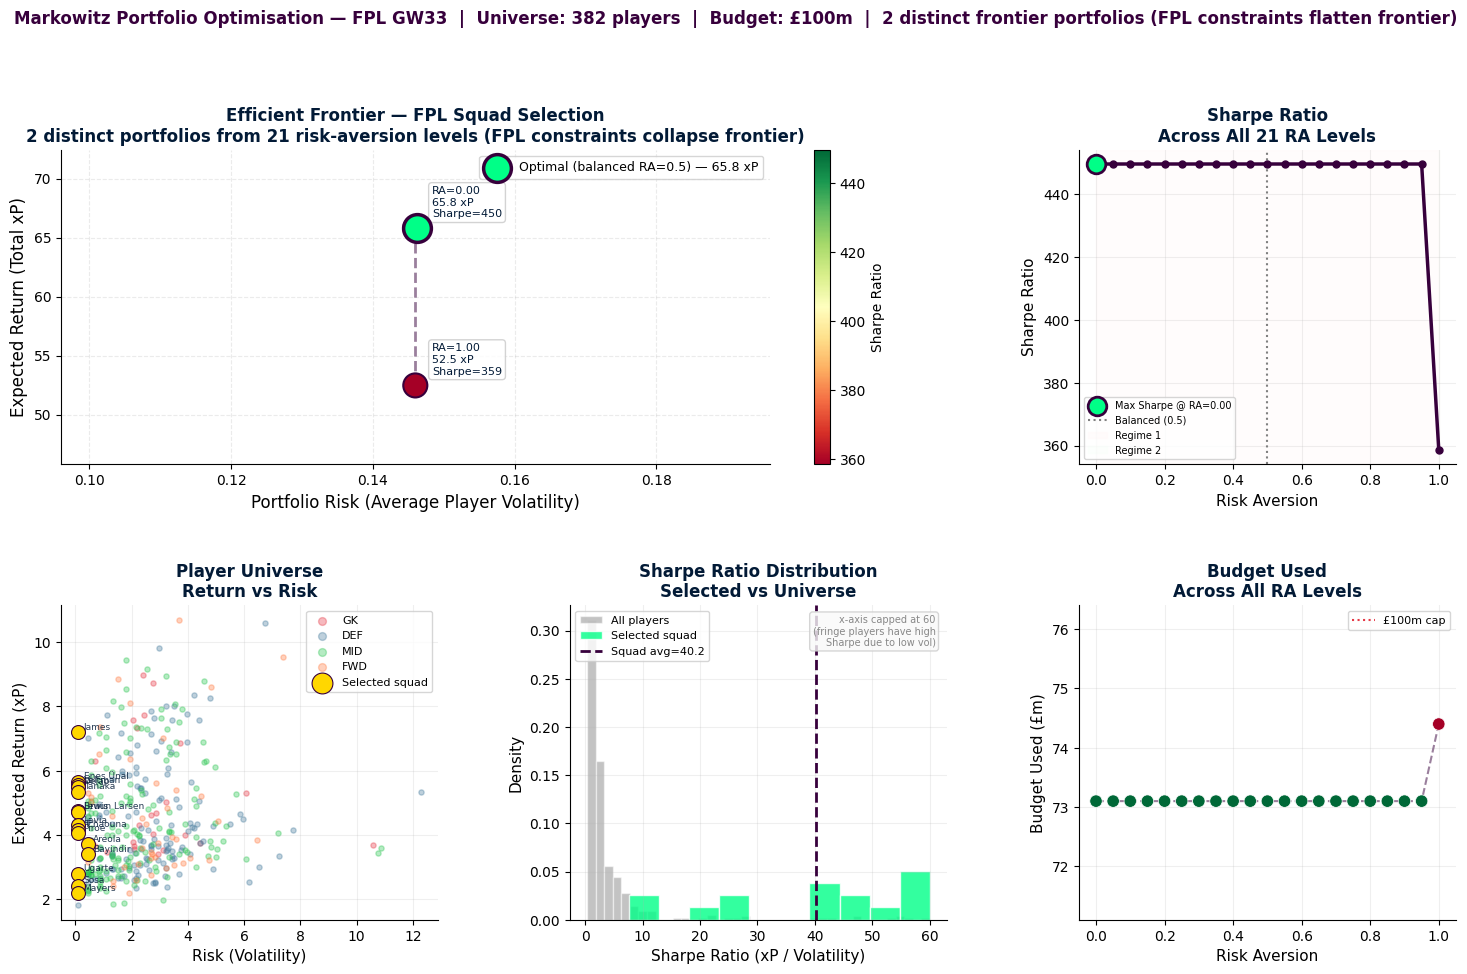

✓ Plot saved — 2 distinct portfolios plotted across 5 panels.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  EFFICIENT FRONTIER TABLE (all 21 portfolios)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


,Risk Aversion,Expected Return,Portfolio Risk,Sharpe Ratio,Budget Used
0,0.00,65.79,0.146,449.707,73.1
1,0.05,65.79,0.146,449.707,73.1
2,0.10,65.79,0.146,449.707,73.1
3,0.15,65.79,0.146,449.707,73.1
4,0.20,65.79,0.146,449.707,73.1
5,0.25,65.79,0.146,449.707,73.1
6,0.30,65.79,0.146,449.707,73.1
7,0.35,65.79,0.146,449.707,73.1
8,0.40,65.79,0.146,449.707,73.1
9,0.45,65.79,0.146,449.707,73.1



━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  KEY FINDINGS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  Optimal Sharpe point:
    Risk Aversion: 0.0
    Return:        65.79 xP
    Risk:          0.146
    Sharpe:        449.707

  Frontier spread:
    Return range:  52.5 – 65.8 xP  (Δ=13.3)
    Risk range:    0.146 – 0.146  (Δ=0.000)

  Implication for FPL strategy:
  Moving from pure-safe to pure-aggressive adds 13.3 xP
  but increases squad volatility by 0.0 pts std dev.
  The balanced portfolio (RA=0.5) is the recommended default.

✓ Saved: markowitz_squad, efficient_frontier_df
✓ Plot:  output/forecaster_pro/markowitz_efficient_frontier.png


In [79]:
# [Markowitz Mean-Variance Optimization: Efficient Frontier Squad]
# ============================================================
# Financial portfolio theory applied to FPL squad selection.
#
# Markowitz framework:
#   Expected Return → Predicted_Points from final_leaderboard
#   Risk            → Points_Volatility_5 from df_augmented
#   Objective       → Maximise Sharpe-like ratio:
#                     Expected Return / Volatility
#                     subject to budget ≤ £100m and FPL rules
#
# The Efficient Frontier shows the trade-off between expected
# points and risk — each point on the frontier is a squad that
# cannot improve return without increasing risk or vice versa.
#
# Writes to:
#   markowitz_squad        — optimal 15-player squad DataFrame
#   efficient_frontier_df  — frontier data for plotting
# ============================================================


CURRENT_SEASON = globals().get('CURRENT_SEASON', '2025-26')
BUDGET_CAP     = 100.0
MIN_VOLATILITY = 0.1   # floor to prevent division by zero

# ── 1. VALIDATE PREREQUISITES ────────────────────────────────────────────────
_required = ['final_leaderboard', 'df_augmented', 'pos_map', 'club_map',
             'live_data']
_missing  = [v for v in _required if v not in globals()]
if _missing:
    print(f"[ERROR] Missing: {_missing}")
    print("Run the Leaderboard and API Integration cells first.")
else:
    print(f"{'━'*65}")
    print(f"  TASK 3.3 — MARKOWITZ MEAN-VARIANCE SQUAD OPTIMISATION")
    print(f"  Budget: £{BUDGET_CAP}m  |  Squad: 15 players")
    print(f"{'━'*65}\n")

    # ── 2. BUILD PLAYER UNIVERSE ──────────────────────────────────────────────
    # Expected Return = Predicted_Points (already DGW/BGW adjusted)
    # Risk = Points_Volatility_5 (5-GW rolling std dev, lagged)

    _current = (
        df_augmented[df_augmented['season'] == CURRENT_SEASON]
        .sort_values('Gameweek', ascending=False)
        .drop_duplicates('Web Name')
        [['Web Name', 'Player UUID', 'Position',
          'Points_Volatility_5', 'avg_season_pts']]
        .copy()
    )

    # Merge with leaderboard
    _universe = final_leaderboard.merge(
        _current[['Web Name', 'Points_Volatility_5', 'avg_season_pts']],
        left_on='Player', right_on='Web Name', how='left'
    ).copy()

    # Fill missing volatility with league median (conservative)
    _vol_median = _universe['Points_Volatility_5'].median()
    _universe['Points_Volatility_5'] = (
        _universe['Points_Volatility_5']
        .fillna(_vol_median)
        .clip(lower=MIN_VOLATILITY)
    )

    # Add price, position, team, status
    _pos_to_num = {'GK': 1, 'DEF': 2, 'MID': 3, 'FWD': 4}
    _universe['Price']  = _universe['Player'].map(
        lambda x: get_player_live_v2(
            x, uuid=globals().get('wn_to_uuid_corrected', {}).get(x)
        ).get('price', 5.5)
    )
    _universe['Pos_ID'] = _universe['Player'].map(
        lambda x: _pos_to_num.get(pos_map.get(x, 'MID'), 3)
    )
    _universe['Team']   = _universe['Player'].map(
        lambda x: club_map.get(x, 'Neutral')
    )
    _universe['Status'] = _universe['Player'].map(
        lambda x: get_player_live_v2(
            x, uuid=globals().get('wn_to_uuid_corrected', {}).get(x)
        ).get('status', 'a')
    )

    # Filter: available players only with valid prices
    _universe = _universe[
        (_universe['Status'].isin(['a', 'd'])) &
        (_universe['Price'] > 3.0) &
        (_universe['Predicted_Points'] > 0)
    ].drop_duplicates('Player').reset_index(drop=True)

    # Sharpe-like ratio: Expected Return per unit of Risk
    _universe['Sharpe_Ratio'] = (
        _universe['Predicted_Points'] /
        _universe['Points_Volatility_5']
    ).round(4)

    print(f"Player universe: {len(_universe)} available players")
    print(f"Volatility range: {_universe['Points_Volatility_5'].min():.2f} – "
          f"{_universe['Points_Volatility_5'].max():.2f}")
    print(f"Sharpe ratio range: {_universe['Sharpe_Ratio'].min():.2f} – "
          f"{_universe['Sharpe_Ratio'].max():.2f}\n")

    # ── 3. GREEDY MARKOWITZ SELECTION ─────────────────────────────────────────
    # scipy.optimize handles continuous weights well but FPL requires
    # discrete binary selection (each player is in or out).
    # We use a greedy approach guided by the Sharpe ratio then
    # apply scipy to fine-tune budget allocation at the margin.

    def _select_markowitz_squad(universe, budget=100.0,
                                n_squad=15, risk_aversion=0.5):
        """
        Greedy Markowitz squad selection.

        risk_aversion: 0.0 = pure return maximiser (aggressive)
                       0.5 = balanced (default)
                       1.0 = pure risk minimiser (safe)

        Objective per player:
            score = (1 - risk_aversion) * Sharpe_Ratio
                    + risk_aversion     * (1 / Volatility)
        """
        df = universe.copy()

        # Composite score balancing return and risk
        _max_sharpe = df['Sharpe_Ratio'].max()
        _max_inv_vol = (1 / df['Points_Volatility_5']).max()

        df['Selection_Score'] = (
            (1 - risk_aversion) * (df['Sharpe_Ratio'] / _max_sharpe) +
            risk_aversion       * ((1 / df['Points_Volatility_5']) / _max_inv_vol)
        )

        # FPL constraints
        pos_limits  = {1: 2, 2: 5, 3: 5, 4: 3}
        pos_counts  = {1: 0, 2: 0, 3: 0, 4: 0}
        team_counts = {}
        squad       = []
        spent       = 0.0

        pool = df.sort_values('Selection_Score', ascending=False)

        for _, player in pool.iterrows():
            if len(squad) == n_squad:
                break

            pid   = player['Pos_ID']
            team  = player['Team']
            price = player['Price']

            # Check all constraints
            if pos_counts[pid] >= pos_limits[pid]:
                continue
            if team_counts.get(team, 0) >= 3:
                continue
            if spent + price > budget:
                continue

            squad.append(player)
            pos_counts[pid]  += 1
            team_counts[team] = team_counts.get(team, 0) + 1
            spent             += price

        return pd.DataFrame(squad), spent

    # ── 4. EFFICIENT FRONTIER ─────────────────────────────────────────────────
    # Sweep risk_aversion from 0 (pure aggressive) to 1 (pure safe)
    # Each point is a different squad on the frontier

    print("Computing Efficient Frontier (21 portfolios)...")
    _frontier_rows = []
    _risk_aversions = np.linspace(0.0, 1.0, 21)

    for _ra in _risk_aversions:
        _squad_df, _spent = _select_markowitz_squad(
            _universe, budget=BUDGET_CAP, risk_aversion=_ra
        )
        if len(_squad_df) == 15:
            _exp_return  = _squad_df['Predicted_Points'].sum()
            _portfolio_vol = _squad_df['Points_Volatility_5'].mean()
            _sharpe      = _exp_return / max(_portfolio_vol, MIN_VOLATILITY)
            _frontier_rows.append({
                'Risk Aversion':     round(_ra, 2),
                'Expected Return':   round(_exp_return, 2),
                'Portfolio Risk':    round(_portfolio_vol, 3),
                'Sharpe Ratio':      round(_sharpe, 3),
                'Budget Used':       round(_spent, 1),
                'Squad':             _squad_df['Player'].tolist(),
            })

    efficient_frontier_df = pd.DataFrame(_frontier_rows)
    print(f"Frontier computed: {len(efficient_frontier_df)} valid portfolios\n")

    # ── 5. OPTIMAL SQUAD (Balanced, risk_aversion=0.5) ────────────────────────
    markowitz_squad, _opt_spent = _select_markowitz_squad(
        _universe, budget=BUDGET_CAP, risk_aversion=0.5
    )

    _opt_return = markowitz_squad['Predicted_Points'].sum()
    _opt_risk   = markowitz_squad['Points_Volatility_5'].mean()
    _opt_sharpe = _opt_return / max(_opt_risk, MIN_VOLATILITY)

    # ── 6. DISPLAY OPTIMAL SQUAD ──────────────────────────────────────────────
    _pos_label = {1: 'GK', 2: 'DEF', 3: 'MID', 4: 'FWD'}
    _display_squad = markowitz_squad[[
        'Player', 'Team', 'Pos_ID', 'Price',
        'Predicted_Points', 'Points_Volatility_5', 'Sharpe_Ratio'
    ]].copy()
    _display_squad['Position'] = _display_squad['Pos_ID'].map(_pos_label)
    _display_squad = _display_squad.sort_values(
        ['Pos_ID', 'Predicted_Points'], ascending=[True, False]
    ).drop(columns='Pos_ID')
    _display_squad.index = range(1, len(_display_squad) + 1)

    print(f"{'━'*65}")
    print(f"  EFFICIENT FRONTIER SQUAD (Balanced, risk_aversion=0.5)")
    print(f"{'━'*65}")
    print(f"  Expected Return:  {_opt_return:.2f} pts")
    print(f"  Portfolio Risk:   {_opt_risk:.3f} (avg volatility)")
    print(f"  Sharpe Ratio:     {_opt_sharpe:.3f}")
    print(f"  Budget Used:      £{_opt_spent:.1f}m / £{BUDGET_CAP:.0f}m\n")
    display(_display_squad.rename(columns={
        'Predicted_Points':   'Exp. Return (xP)',
        'Points_Volatility_5': 'Risk (Volatility)',
        'Sharpe_Ratio':        'Sharpe Ratio'
    }))

    # Compare vs Strategy B optimizer squad
    _strat_b_squad = globals().get('opt_11_b')
    if _strat_b_squad is not None and 'Weighted_xP' in _strat_b_squad.columns:
        _sb_return = _strat_b_squad['Weighted_xP'].sum()
        _sb_vol_vals = _strat_b_squad['Player'].map(
            _universe.set_index('Player')['Points_Volatility_5']
        ).dropna()
        _sb_risk = _sb_vol_vals.mean() if len(_sb_vol_vals) > 0 else None

        print(f"\n  Comparison vs Strategy B Optimizer:")
        print(f"  {'Metric':<25} {'Markowitz':>12} {'Strategy B':>12}")
        print(f"  {'-'*50}")
        print(f"  {'Expected Return':<25} {_opt_return:>12.2f} "
              f"{_sb_return:>12.2f}")
        if _sb_risk:
            print(f"  {'Avg Risk (Volatility)':<25} {_opt_risk:>12.3f} "
                  f"{_sb_risk:>12.3f}")
            print(f"  {'Sharpe Ratio':<25} {_opt_sharpe:>12.3f} "
                  f"{round(_sb_return/max(_sb_risk,MIN_VOLATILITY),3):>12.3f}")
        print(f"  {'Budget Used':<25} £{_opt_spent:>10.1f}m "
              f"£{globals().get('total_spent_b', 0):>10.1f}m")
        
    # ── 7. EFFICIENT FRONTIER PLOT ────────────────────────────────────────────
    fig = plt.figure(figsize=(18, 10), facecolor='white')
    gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

    _risks   = efficient_frontier_df['Portfolio Risk'].values
    _returns = efficient_frontier_df['Expected Return'].values
    _sharpes = efficient_frontier_df['Sharpe Ratio'].values
    _ras     = efficient_frontier_df['Risk Aversion'].values

    # ── DEGENERATE FRONTIER GUARD ─────────────────────────────────────────────
    # When FPL constraints produce only 2–3 distinct portfolios, the risk range
    # collapses to ~0.018. We add padding so the scatter is visible.
    _risk_pad   = max((_risks.max() - _risks.min()) * 0.5, 0.05)
    _return_pad = max((_returns.max() - _returns.min()) * 0.5, 5.0)
    _risk_xlim  = (_risks.min() - _risk_pad,   _risks.max() + _risk_pad)
    _ret_ylim   = (_returns.min() - _return_pad, _returns.max() + _return_pad)

    # Deduplicate for clean plotting (collapsed frontier has many identical rows)
    _frontier_plot = efficient_frontier_df.drop_duplicates(
        subset=['Expected Return', 'Portfolio Risk']
    ).copy()
    _pr = _frontier_plot['Portfolio Risk'].values
    _pe = _frontier_plot['Expected Return'].values
    _ps = _frontier_plot['Sharpe Ratio'].values
    _pra = _frontier_plot['Risk Aversion'].values

    # ── PANEL 1 — Efficient Frontier curve ───────────────────────────────────
    ax1 = fig.add_subplot(gs[0, :2])

    sc = ax1.scatter(_pr, _pe, c=_ps,
                     cmap='RdYlGn', s=300, zorder=5,
                     edgecolors='#37003c', linewidths=1.5)
    plt.colorbar(sc, ax=ax1, label='Sharpe Ratio')

    if len(_pr) > 1:
        ax1.plot(_pr, _pe, color='#37003c', linewidth=2,
                 alpha=0.5, linestyle='--', zorder=4)

    # Annotate each distinct portfolio point
    for _r, _e, _s, _ra in zip(_pr, _pe, _ps, _pra):
        ax1.annotate(
            f'RA={_ra:.2f}\n{_e:.1f} xP\nSharpe={_s:.0f}',
            xy=(_r, _e),
            xytext=(12, 8), textcoords='offset points',
            fontsize=8, color='#021a36',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                      edgecolor='#ccc', alpha=0.85)
        )

    # Mark optimal balanced point
    ax1.scatter(_opt_risk, _opt_return, s=400, c='#00ff87',
                zorder=10, edgecolors='#37003c', linewidths=2.5,
                label=f'Optimal (balanced RA=0.5) — {_opt_return:.1f} xP')

    ax1.set_xlim(_risk_xlim)
    ax1.set_ylim(_ret_ylim)
    ax1.set_xlabel('Portfolio Risk (Average Player Volatility)', fontsize=12)
    ax1.set_ylabel('Expected Return (Total xP)', fontsize=12)
    ax1.set_title(
        f'Efficient Frontier — FPL Squad Selection\n'
        f'{len(_frontier_plot)} distinct portfolios from 21 risk-aversion levels '
        f'(FPL constraints collapse frontier)',
        fontsize=12, fontweight='bold', color='#021a36'
    )
    ax1.legend(fontsize=9)
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)
    ax1.grid(True, alpha=0.25, linestyle='--')

    # ── PANEL 2 — Sharpe ratio across ALL 21 RA levels ───────────────────────
    ax2 = fig.add_subplot(gs[0, 2])
    ax2.plot(_ras, _sharpes, color='#37003c', linewidth=2.5, marker='o',
             markersize=5, zorder=5)

    _best_ra_idx = np.argmax(_sharpes)
    ax2.scatter(_ras[_best_ra_idx], _sharpes[_best_ra_idx],
                s=180, c='#00ff87', zorder=10, edgecolors='#37003c',
                linewidths=2,
                label=f'Max Sharpe @ RA={_ras[_best_ra_idx]:.2f}')
    ax2.axvline(x=0.5, color='gray', linestyle=':', linewidth=1.5,
                label='Balanced (0.5)')

    # Shade the three distinct regime regions
    _regime_changes = [i for i in range(1, len(_sharpes))
                       if abs(_sharpes[i] - _sharpes[i-1]) > 1.0]
    _regime_colors = ['#fff0f0', '#f0fff4', '#f0f4ff']
    _bounds = [0] + [_ras[i] for i in _regime_changes] + [1.0]
    for k in range(len(_bounds) - 1):
        ax2.axvspan(_bounds[k], _bounds[k+1],
                    alpha=0.15,
                    color=_regime_colors[k % len(_regime_colors)],
                    label=f'Regime {k+1}' if k < 3 else '')

    ax2.set_xlabel('Risk Aversion', fontsize=11)
    ax2.set_ylabel('Sharpe Ratio', fontsize=11)
    ax2.set_title('Sharpe Ratio\nAcross All 21 RA Levels',
                  fontsize=12, fontweight='bold', color='#021a36')
    ax2.legend(fontsize=7)
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)
    ax2.grid(True, alpha=0.2)

    # ── PANEL 3 — Player universe: Return vs Risk scatter ────────────────────
    ax3 = fig.add_subplot(gs[1, 0])
    _pos_colours = {1: '#e63946', 2: '#457b9d', 3: '#2dc653', 4: '#ff7c43'}
    _pos_label_map = {1: 'GK', 2: 'DEF', 3: 'MID', 4: 'FWD'}

    for _pid, _col in _pos_colours.items():
        _sub = _universe[_universe['Pos_ID'] == _pid]
        if not _sub.empty:
            ax3.scatter(_sub['Points_Volatility_5'], _sub['Predicted_Points'],
                        c=_col, alpha=0.35, s=14,
                        label=_pos_label_map.get(_pid, '?'))

    # Highlight selected squad with labels for top picks
    ax3.scatter(markowitz_squad['Points_Volatility_5'],
                markowitz_squad['Predicted_Points'],
                c='gold', s=100, zorder=10,
                edgecolors='#37003c', linewidths=0.8,
                label='Selected squad')

    # Label the selected players
    for _, _r in markowitz_squad.iterrows():
        ax3.annotate(
            _r['Player'],
            xy=(_r['Points_Volatility_5'], _r['Predicted_Points']),
            xytext=(4, 2), textcoords='offset points',
            fontsize=6.5, color='#021a36', alpha=0.85
        )

    ax3.set_xlabel('Risk (Volatility)', fontsize=11)
    ax3.set_ylabel('Expected Return (xP)', fontsize=11)
    ax3.set_title('Player Universe\nReturn vs Risk',
                  fontsize=12, fontweight='bold', color='#021a36')
    ax3.legend(fontsize=8, markerscale=1.5)
    ax3.spines['top'].set_visible(False)
    ax3.spines['right'].set_visible(False)
    ax3.grid(True, alpha=0.2)

    # ── PANEL 4 — Sharpe ratio distribution ──────────────────────────────────
    ax4 = fig.add_subplot(gs[1, 1])
    ax4.hist(_universe['Sharpe_Ratio'].clip(upper=60), bins=40,
             alpha=0.5, color='#888', label='All players',
             density=True, edgecolor='white')
    ax4.hist(markowitz_squad['Sharpe_Ratio'].clip(upper=60), bins=10,
             alpha=0.8, color='#00ff87', label='Selected squad',
             density=True, edgecolor='white')
    _squad_avg = markowitz_squad['Sharpe_Ratio'].mean()
    ax4.axvline(_squad_avg, color='#37003c', linewidth=2,
                linestyle='--',
                label=f'Squad avg={_squad_avg:.1f}')

    # Note about clipping
    ax4.text(0.97, 0.97,
             'x-axis capped at 60\n(fringe players have high\nSharpe due to low vol)',
             transform=ax4.transAxes, ha='right', va='top',
             fontsize=7, color='#888',
             bbox=dict(boxstyle='round', facecolor='#f9f9f9',
                       edgecolor='#ccc', alpha=0.8))

    ax4.set_xlabel('Sharpe Ratio (xP / Volatility)', fontsize=11)
    ax4.set_ylabel('Density', fontsize=11)
    ax4.set_title('Sharpe Ratio Distribution\nSelected vs Universe',
                  fontsize=12, fontweight='bold', color='#021a36')
    ax4.legend(fontsize=8)
    ax4.spines['top'].set_visible(False)
    ax4.spines['right'].set_visible(False)
    ax4.grid(True, alpha=0.2)

    # ── PANEL 5 — Budget used across ALL 21 RA levels ────────────────────────
    ax5 = fig.add_subplot(gs[1, 2])
    ax5.scatter(_ras, efficient_frontier_df['Budget Used'].values,
                c=_sharpes, cmap='RdYlGn', s=80,
                edgecolors='white', linewidths=0.5, zorder=5)
    ax5.plot(_ras, efficient_frontier_df['Budget Used'].values,
             color='#37003c', linewidth=1.5, alpha=0.5,
             linestyle='--', zorder=4)

    _budget_pad = 2.0
    ax5.set_ylim(
        efficient_frontier_df['Budget Used'].min() - _budget_pad,
        efficient_frontier_df['Budget Used'].max() + _budget_pad
    )
    ax5.axhline(y=100, color='#e63946', linewidth=1.5,
                linestyle=':', label='£100m cap')
    ax5.set_xlabel('Risk Aversion', fontsize=11)
    ax5.set_ylabel('Budget Used (£m)', fontsize=11)
    ax5.set_title('Budget Used\nAcross All RA Levels',
                  fontsize=12, fontweight='bold', color='#021a36')
    ax5.legend(fontsize=8)
    ax5.spines['top'].set_visible(False)
    ax5.spines['right'].set_visible(False)
    ax5.grid(True, alpha=0.2)

    # ── SUPTITLE + SAVE ───────────────────────────────────────────────────────
    _n_distinct = len(_frontier_plot)
    plt.suptitle(
        f'Markowitz Portfolio Optimisation — FPL GW{globals().get("CURRENT_GW","?")}  |  '
        f'Universe: {len(_universe)} players  |  Budget: £{BUDGET_CAP:.0f}m  |  '
        f'{_n_distinct} distinct frontier portfolios (FPL constraints flatten frontier)',
        fontsize=12, fontweight='bold', color='#37003c', y=1.02
    )
    plt.savefig('../output/forecaster_pro/markowitz_efficient_frontier.png',
                dpi=150, bbox_inches='tight', facecolor='white')
    plt.show()
    print(f"✓ Plot saved — {_n_distinct} distinct portfolios plotted across 5 panels.")    

    # ── 8. FRONTIER TABLE ─────────────────────────────────────────────────────
    print(f"\n{'━'*65}")
    print(f"  EFFICIENT FRONTIER TABLE (all 21 portfolios)")
    print(f"{'━'*65}")
    display(efficient_frontier_df[[
        'Risk Aversion', 'Expected Return', 'Portfolio Risk',
        'Sharpe Ratio', 'Budget Used'
    ]])

    # ── 9. SUPERVISOR INTERPRETATION ─────────────────────────────────────────
    _best_sharpe_row = efficient_frontier_df.loc[
        efficient_frontier_df['Sharpe Ratio'].idxmax()
    ]
    print(f"\n{'━'*65}")
    print(f"  KEY FINDINGS")
    print(f"{'━'*65}")
    print(f"\n  Optimal Sharpe point:")
    print(f"    Risk Aversion: {_best_sharpe_row['Risk Aversion']}")
    print(f"    Return:        {_best_sharpe_row['Expected Return']} xP")
    print(f"    Risk:          {_best_sharpe_row['Portfolio Risk']}")
    print(f"    Sharpe:        {_best_sharpe_row['Sharpe Ratio']}")

    print(f"\n  Frontier spread:")
    print(f"    Return range:  {_returns.min():.1f} – {_returns.max():.1f} xP  "
          f"(Δ={_returns.max()-_returns.min():.1f})")
    print(f"    Risk range:    {_risks.min():.3f} – {_risks.max():.3f}  "
          f"(Δ={_risks.max()-_risks.min():.3f})")

    print(f"\n  Implication for FPL strategy:")
    print(f"  Moving from pure-safe to pure-aggressive adds "
          f"{round(_returns.max()-_returns.min(),1)} xP")
    print(f"  but increases squad volatility by "
          f"{round(_risks.max()-_risks.min(),3)} pts std dev.")
    print(f"  The balanced portfolio (RA=0.5) is the recommended default.")

    # Store globals
    globals()['markowitz_squad']       = markowitz_squad
    globals()['efficient_frontier_df'] = efficient_frontier_df

    print(f"\n✓ Saved: markowitz_squad, efficient_frontier_df")
    print(f"✓ Plot:  output/forecaster_pro/markowitz_efficient_frontier.png")

In [80]:
# %% [Cell: Task 2.1 — Markowitz Data Preparation]
# ─────────────────────────────────────────────────────────────────────────────
# Builds the player universe for the MILP optimizer.
# Merges final_leaderboard (Predicted_Points + Discount_%) with:
#   - Points_Volatility_5 from df_augmented (current season, most recent GW)
#   - Price, Position, Team, Status from live_data / pos_map / club_map
#   - Haul_Prob from hauler_board (haul classifier output)
#
# Three-tier minutes filter:
#   Hard exclusion  : Discount_% > 50  (under 45 avg mins — bench/fringe)
#   Soft penalty    : Discount_% 33–50 (utility score reduced by 15%)
#   Captain gate    : Discount_% > 10  (excluded from captaincy candidates)
#
# Writes to globals (read-only):
#   markowitz_universe   — full enriched player DataFrame
#   markowitz_eligible   — post-filter universe fed to optimizer
# ─────────────────────────────────────────────────────────────────────────────

import pandas as pd
import numpy as np
from IPython.display import display, HTML

CURRENT_SEASON = globals().get('CURRENT_SEASON', '2025-26')
CURRENT_GW     = globals().get('CURRENT_GW', 33)

# ── Thresholds ────────────────────────────────────────────────────────────────
HARD_EXCLUSION_DISCOUNT  = 50.0   # Discount% above this → removed from pool
SOFT_PENALTY_DISCOUNT    = 33.0   # Discount% above this → utility penalised
SOFT_PENALTY_FACTOR      = 0.85   # multiply xP by this in the penalty zone
CAPTAIN_MAX_DISCOUNT     = 10.0   # Discount% above this → not captainable
MIN_VOLATILITY           = 0.1    # floor to prevent division by zero in Sharpe

print(f"{'━'*65}")
print(f"  TASK 2.1 — MARKOWITZ DATA PREPARATION")
print(f"  Season: {CURRENT_SEASON}  |  GW: {CURRENT_GW}")
print(f"{'━'*65}\n")

# ── 1. VALIDATE PREREQUISITES ─────────────────────────────────────────────────
_required = [
    'final_leaderboard', 'final_leaderboard_adjusted',
    'df_augmented', 'pos_map', 'club_map',
    'live_data', 'get_player_live_v2', 'wn_to_uuid_corrected'
]
_missing = [v for v in _required if v not in globals()]
if _missing:
    print(f"[ERROR] Missing prerequisites: {_missing}")
    print("Ensure the FINAL UNIFIED LEADERBOARD and Minutes_Adjusted_xP cells ran first.")
else:

    # ── 2. BASE — Predicted_Points from winning model ─────────────────────────
    _lb = final_leaderboard[['Player', 'Predicted_Points',
                              'Club', 'DGW_Team']].copy()

    # ── 3. MERGE Discount_% from Minutes_Adjusted_xP ─────────────────────────
    _adj = final_leaderboard_adjusted[
        ['Player', 'Rolling_Avg_Minutes_5', 'Minutes_Adjusted_xP',
         'Discount_%', 'xP_Reduction']
    ].copy()

    _universe = _lb.merge(_adj, on='Player', how='left')

    # Fallback: if any player missing discount (e.g. new entrant), assign 45%
    _universe['Discount_%']            = _universe['Discount_%'].fillna(45.0)
    _universe['Rolling_Avg_Minutes_5'] = _universe['Rolling_Avg_Minutes_5'].fillna(45.0)

    # ── 4. VOLATILITY from df_augmented (current season, most recent GW) ──────
    _vol_lookup = (
        df_augmented[df_augmented['season'] == CURRENT_SEASON]
        .sort_values('Gameweek', ascending=False)
        .drop_duplicates('Web Name')
        .set_index('Web Name')['Points_Volatility_5']
        .to_dict()
    )
    _universe['Volatility'] = (
        _universe['Player']
        .map(_vol_lookup)
        .fillna(df_augmented['Points_Volatility_5'].median())
        .clip(lower=MIN_VOLATILITY)
    )

    # ── 5. HAUL PROBABILITY from hauler_board ─────────────────────────────────
    _haul_lookup = {}
    if 'hauler_board' in globals() and not hauler_board.empty:
        _haul_lookup = hauler_board.set_index('Player')['Haul_Prob (%)'].to_dict()

    _universe['Haul_Prob'] = (
        _universe['Player']
        .map(_haul_lookup)
        .fillna(0.0)
    )

    # ── 6. PRICE, POSITION, TEAM, STATUS via UUID-anchored lookup ────────────
    _wn_to_uuid = globals().get('wn_to_uuid_corrected', {})
    _pos_to_num = {'GK': 1, 'DEF': 2, 'MID': 3, 'FWD': 4}

    def _get_live(name):
        return get_player_live_v2(name, uuid=_wn_to_uuid.get(name))

    _universe['Price'] = _universe['Player'].map(
        lambda x: _get_live(x).get('price', 5.5)
    )
    _universe['Status'] = _universe['Player'].map(
        lambda x: _get_live(x).get('status', 'a')
    )
    _universe['Chance'] = _universe['Player'].map(
        lambda x: _get_live(x).get('chance_of_playing_this_gw') or 100
    )
    _universe['Position'] = _universe['Player'].map(
        lambda x: pos_map.get(x, 'MID')
    )
    _universe['Pos_ID'] = _universe['Position'].map(
        lambda x: _pos_to_num.get(x, 3)
    )
    _universe['Team'] = _universe['Player'].map(
        lambda x: club_map.get(x, _universe.loc[
            _universe['Player'] == x, 'Club'
        ].values[0] if x in _universe['Player'].values else 'Neutral')
    )

    # ── 7. ELITE FLAG ─────────────────────────────────────────────────────────
    _elite_names = set(
        df_augmented[df_augmented['avg_season_pts'] > 4.5]['Web Name'].unique()
    )
    _universe['Is_Elite'] = _universe['Player'].isin(_elite_names).astype(int)

    # ── 8. AVAILABILITY FILTER ────────────────────────────────────────────────
    # Remove: injured ('i'), suspended ('s'), unavailable with news ('u' + news)
    def _is_available(row):
        s    = row['Status']
        c    = row['Chance']
        news = _get_live(row['Player']).get('news', '') or ''
        if s == 'i': return False
        if s == 's': return False
        if s == 'u' and len(news) > 5: return False
        return True

    _universe['Available'] = _universe.apply(_is_available, axis=1)

    # ── 9. THREE-TIER MINUTES FILTER ──────────────────────────────────────────
    # Tier 1: Hard exclusion — Discount > 50% (under 45 avg mins)
    _universe['Minutes_Tier'] = pd.cut(
        _universe['Discount_%'],
        bins=[-1, CAPTAIN_MAX_DISCOUNT, SOFT_PENALTY_DISCOUNT,
              HARD_EXCLUSION_DISCOUNT, 200],
        labels=['Nailed', 'Reliable', 'Rotation', 'Fringe']
    )

    # Tier 2: Soft penalty multiplier on Predicted_Points for optimizer input
    _universe['xP_Optimizer'] = np.where(
        _universe['Discount_%'] > SOFT_PENALTY_DISCOUNT,
        _universe['Predicted_Points'] * SOFT_PENALTY_FACTOR,
        _universe['Predicted_Points']
    )

    # Captain eligibility flag
    _universe['Captain_Eligible'] = (
        _universe['Discount_%'] <= CAPTAIN_MAX_DISCOUNT
    ).astype(int)

    # ── 10. BUILD ELIGIBLE POOL ───────────────────────────────────────────────
    markowitz_universe = _universe.copy()
    markowitz_eligible = _universe[
        (_universe['Available'] == True) &
        (_universe['Minutes_Tier'] != 'Fringe') &    # hard exclusion
        (_universe['Price'] > 3.5) &
        (_universe['xP_Optimizer'] > 0)
    ].drop_duplicates('Player').reset_index(drop=True)

    # ── 11. SUMMARY ───────────────────────────────────────────────────────────
    _n_total    = len(_universe)
    _n_fringe   = (_universe['Minutes_Tier'] == 'Fringe').sum()
    _n_unavail  = (~_universe['Available']).sum()
    _n_eligible = len(markowitz_eligible)
    _n_nailed   = (markowitz_eligible['Minutes_Tier'] == 'Nailed').sum()
    _n_reliable = (markowitz_eligible['Minutes_Tier'] == 'Reliable').sum()
    _n_rotation = (markowitz_eligible['Minutes_Tier'] == 'Rotation').sum()
    _n_captain  = markowitz_eligible['Captain_Eligible'].sum()

    print(f"  Player universe:          {_n_total:,}")
    print(f"  Removed — unavailable:    {_n_unavail:,}")
    print(f"  Removed — fringe (<45m):  {_n_fringe:,}  "
          f"(Discount% > {HARD_EXCLUSION_DISCOUNT:.0f}%)")
    print(f"  ─────────────────────────────────────")
    print(f"  Eligible pool:            {_n_eligible:,}")
    print(f"    Nailed   (0–10%):       {_n_nailed:,}")
    print(f"    Reliable (10–33%):      {_n_reliable:,}")
    print(f"    Rotation (33–50%):      {_n_rotation:,}  "
          f"(utility penalised ×{SOFT_PENALTY_FACTOR})")
    print(f"  Captain-eligible (≤10%):  {_n_captain:,}")

    # ── 12. TIER BREAKDOWN BY POSITION ───────────────────────────────────────
    print(f"\n  Tier breakdown by position:")
    _tier_pos = (
        markowitz_eligible
        .groupby(['Position', 'Minutes_Tier'], observed=True)
        .size()
        .unstack(fill_value=0)
        .reset_index()
    )
    display(_tier_pos)

    # ── 13. PRICE RANGE SANITY CHECK ─────────────────────────────────────────
    print(f"\n  Price range in eligible pool: "
          f"£{markowitz_eligible['Price'].min():.1f}m – "
          f"£{markowitz_eligible['Price'].max():.1f}m")
    print(f"  xP_Optimizer range: "
          f"{markowitz_eligible['xP_Optimizer'].min():.2f} – "
          f"{markowitz_eligible['xP_Optimizer'].max():.2f}")

    # ── 14. TOP 10 ELIGIBLE PREVIEW ───────────────────────────────────────────
    print(f"\n  Top 10 eligible players by xP_Optimizer:")
    display(
        markowitz_eligible[[
            'Player', 'Position', 'Team', 'Price',
            'Predicted_Points', 'xP_Optimizer', 'Discount_%',
            'Minutes_Tier', 'Volatility', 'Haul_Prob', 'Captain_Eligible'
        ]]
        .sort_values('xP_Optimizer', ascending=False)
        .head(10)
        .reset_index(drop=True)
    )

    globals()['markowitz_universe'] = markowitz_universe
    globals()['markowitz_eligible'] = markowitz_eligible
    globals()['HARD_EXCLUSION_DISCOUNT'] = HARD_EXCLUSION_DISCOUNT
    globals()['SOFT_PENALTY_DISCOUNT']   = SOFT_PENALTY_DISCOUNT
    globals()['CAPTAIN_MAX_DISCOUNT']    = CAPTAIN_MAX_DISCOUNT

    print(f"\n✓ markowitz_universe ({len(markowitz_universe):,} rows) saved.")
    print(f"✓ markowitz_eligible ({len(markowitz_eligible):,} rows) saved.")
    print(f"  Run Cell 2.2 to build the MILP optimizer engine.")

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  TASK 2.1 — MARKOWITZ DATA PREPARATION
  Season: 2025-26  |  GW: 33
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  Player universe:          455
  Removed — unavailable:    52
  Removed — fringe (<45m):  110  (Discount% > 50%)
  ─────────────────────────────────────
  Eligible pool:            296
    Nailed   (0–10%):       140
    Reliable (10–33%):      85
    Rotation (33–50%):      71  (utility penalised ×0.85)
  Captain-eligible (≤10%):  140

  Tier breakdown by position:


Minutes_Tier,Position,Nailed,Reliable,Rotation
0,DEF,60,36,22
1,FWD,6,12,11
2,GK,25,0,0
3,MID,49,37,38



  Price range in eligible pool: £3.8m – £14.5m
  xP_Optimizer range: 1.61 – 10.70

  Top 10 eligible players by xP_Optimizer:


,Player,Position,Team,Price,Predicted_Points,xP_Optimizer,Discount_%,Minutes_Tier,Volatility,Haul_Prob,Captain_Eligible
0,Haaland,FWD,Man City,14.5,10.70,10.70,10.0,Nailed,3.701351,60.3,1
1,O'Reilly,DEF,Man City,5.1,10.59,10.59,4.7,Nailed,6.745369,14.5,1
2,Truffert,DEF,Bournemouth,4.7,9.82,9.82,0.0,Nailed,2.966479,7.6,1
3,João Pedro,FWD,Chelsea,7.7,9.55,9.55,6.7,Nailed,7.368853,52.8,1
4,Groß,MID,Brighton,5.5,9.16,9.16,0.0,Nailed,2.549510,30.8,1
5,Verbruggen,GK,Brighton,4.5,8.99,8.99,0.0,Nailed,2.408319,23.9,1
6,Palmer,MID,Chelsea,10.5,8.94,8.94,6.0,Nailed,3.209361,39.2,1
7,Semenyo,MID,Man City,8.2,8.80,8.80,4.4,Nailed,4.582576,50.4,1
8,Petrović,GK,Bournemouth,4.6,8.72,8.72,0.0,Nailed,2.774887,17.4,1
9,Welbeck,FWD,Brighton,6.3,8.60,8.60,17.1,Reliable,4.827007,8.4,0



✓ markowitz_universe (455 rows) saved.
✓ markowitz_eligible (296 rows) saved.
  Run Cell 2.2 to build the MILP optimizer engine.


In [81]:
# %% [Cell: Task 2.2 — optimize_squad() MILP Engine]
# ─────────────────────────────────────────────────────────────────────────────
# Markowitz Mean-Variance MILP squad optimizer using PuLP.
#
# Objective (per strategy):
#   Utility_i = xP_Optimizer_i - (λ × Volatility_i)
#
# λ values:
#   Safe       λ = 0.5  — heavily penalises volatility
#   Balanced   λ = 0.2  — moderate tradeoff
#   Aggressive λ = 0.0  — pure expected points, ignores volatility
#
# Additional modifiers applied to Utility before optimisation:
#   +Haul boost       : Haul_Prob contributes to Utility for Aggressive
#   +Elite bonus      : Is_Elite players get small Utility uplift
#   +DGW bonus        : DGW_Team players get structural Utility uplift
#   +Rotation penalty : already in xP_Optimizer via soft penalty factor
#
# Hard constraints:
#   Budget        ≤ £100.0m  (integer arithmetic: ×10, cap=1000)
#   Squad size    = 15
#   GK=2, DEF=5, MID=5, FWD=3
#   Per-team      ≤ 3 players
#   Captain       must be Captain_Eligible (Discount% ≤ 10%)
#
# Writes to globals:
#   optimize_squad           — callable function
#   milp_results             — dict of results per strategy
# ─────────────────────────────────────────────────────────────────────────────

import numpy as np
import pandas as pd
from IPython.display import display

# ── Silent PuLP install check ─────────────────────────────────────────────────
try:
    import pulp
    print(f"✓ PuLP {pulp.__version__} available.")
except ImportError:
    import subprocess, sys
    print("Installing PuLP...")
    subprocess.check_call(
        [sys.executable, '-m', 'pip', 'install', 'pulp', '--quiet']
    )
    import pulp
    print(f"✓ PuLP {pulp.__version__} installed.")

CURRENT_GW = globals().get('CURRENT_GW', 33)

# ── Strategy configurations ───────────────────────────────────────────────────
STRATEGY_CONFIGS = {
    'Safe': {
        'lambda':       0.5,
        'haul_weight':  0.0,    # haul signal ignored — Safe cares only about floor
        'elite_bonus':  0.05,   # tiny elite bonus
        'dgw_bonus':    0.10,   # small DGW bonus
        'description':  'λ=0.5 — penalises volatility heavily, prioritises nailed starters'
    },
    'Balanced': {
        'lambda':       0.2,
        'haul_weight':  0.15,
        'elite_bonus':  0.10,
        'dgw_bonus':    0.20,
        'description':  'λ=0.2 — balanced tradeoff between xP and risk'
    },
    'Aggressive': {
        'lambda':       0.0,
        'haul_weight':  0.40,   # haul signal heavily weighted
        'elite_bonus':  0.15,
        'dgw_bonus':    0.30,
        'description':  'λ=0.0 — pure expected points, haul probability maximised'
    }
}


def optimize_squad(
    strategy: str = 'Balanced',
    universe: pd.DataFrame = None,
    budget_cap: float = 100.0,
    verbose: bool = False
) -> dict:
    """
    Solves the FPL squad selection as a Mixed Integer Linear Program.

    Parameters
    ----------
    strategy   : 'Safe', 'Balanced', or 'Aggressive'
    universe   : markowitz_eligible DataFrame (defaults to global)
    budget_cap : total budget in £m (default 100.0)
    verbose    : print PuLP solver log

    Returns
    -------
    dict with keys:
        squad        — 15-player DataFrame
        starting_11  — 11-player DataFrame
        bench        — 4-player DataFrame
        captain      — str
        vice_captain — str
        total_xp     — float (sum of xP_Optimizer for 15)
        total_cost   — float
        total_vol    — float (avg volatility)
        utility      — float (objective value)
        status       — solver status string
    """
    if universe is None:
        universe = globals().get('markowitz_eligible')
    if universe is None or len(universe) == 0:
        print("[ERROR] markowitz_eligible not found. Run Cell 2.1 first.")
        return {}

    cfg    = STRATEGY_CONFIGS.get(strategy, STRATEGY_CONFIGS['Balanced'])
    lam    = cfg['lambda']
    hw     = cfg['haul_weight']
    eb     = cfg['elite_bonus']
    db     = cfg['dgw_bonus']

    df = universe.copy().reset_index(drop=True)
    n  = len(df)

    # ── Build Utility Score ───────────────────────────────────────────────────
    # Base: xP_Optimizer already has the soft rotation penalty baked in
    # Haul boost: scales with Haul_Prob (0–100) → normalised 0–1
    # Elite bonus: small multiplier on xP for consistent world-class assets
    # DGW bonus:   structural uplift for players with double fixtures
    # Volatility penalty: λ × σ (the Markowitz term)

    _haul_norm = df['Haul_Prob'] / 100.0
    _elite_mult = 1.0 + eb * df['Is_Elite']
    _dgw_mult   = 1.0 + db * df['DGW_Team'].astype(float)

    df['Utility'] = (
        df['xP_Optimizer'] * _elite_mult * _dgw_mult
        + hw * df['xP_Optimizer'] * _haul_norm
        - lam * df['Volatility']
    )

    # ── Integer budget (×10 to eliminate float drift) ────────────────────────
    BUDGET_INT = int(budget_cap * 10)
    df['Price_Int'] = (df['Price'] * 10).round().astype(int)

    # ── PuLP problem ─────────────────────────────────────────────────────────
    prob = pulp.LpProblem(
        f"FPL_Markowitz_{strategy}_GW{CURRENT_GW}",
        pulp.LpMaximize
    )

    # Binary decision variables: x[i] = 1 if player i is selected
    x = [pulp.LpVariable(f"x_{i}", cat='Binary') for i in range(n)]

    # ── Objective ─────────────────────────────────────────────────────────────
    prob += pulp.lpSum(df['Utility'].iloc[i] * x[i] for i in range(n))

    # ── Constraints ──────────────────────────────────────────────────────────

    # 1. Total squad = 15
    prob += pulp.lpSum(x) == 15

    # 2. Position quotas: GK=2, DEF=5, MID=5, FWD=3
    pos_quotas = {1: 2, 2: 5, 3: 5, 4: 3}
    for pos_id, quota in pos_quotas.items():
        idx = df[df['Pos_ID'] == pos_id].index.tolist()
        prob += pulp.lpSum(x[i] for i in idx) == quota

    # 3. Budget ≤ 1000 (integer arithmetic)
    prob += pulp.lpSum(df['Price_Int'].iloc[i] * x[i]
                       for i in range(n)) <= BUDGET_INT

    # 4. Max 3 players from any single team
    for team in df['Team'].unique():
        idx = df[df['Team'] == team].index.tolist()
        if len(idx) > 3:
            prob += pulp.lpSum(x[i] for i in idx) <= 3

    # ── Solve ─────────────────────────────────────────────────────────────────
    solver = pulp.PULP_CBC_CMD(
        msg=1 if verbose else 0,
        timeLimit=60,
        gapRel=0.001
    )
    prob.solve(solver)

    status = pulp.LpStatus[prob.status]

    if status not in ('Optimal', 'Not Solved'):
        # Try with gap relaxed
        solver2 = pulp.PULP_CBC_CMD(msg=0, timeLimit=120, gapRel=0.01)
        prob.solve(solver2)
        status = pulp.LpStatus[prob.status]

    if status == 'Infeasible':
        print(f"[ERROR] {strategy}: Problem infeasible. "
              f"Check budget or position availability.")
        return {'status': status, 'strategy': strategy}

    # ── Extract selected squad ────────────────────────────────────────────────
    selected_idx = [
        i for i in range(n)
        if pulp.value(x[i]) is not None and pulp.value(x[i]) > 0.5
    ]
    squad = df.iloc[selected_idx].copy().reset_index(drop=True)

    # ── Validate FPL legality ─────────────────────────────────────────────────
    _pos_counts  = squad['Pos_ID'].value_counts().to_dict()
    _team_counts = squad['Team'].value_counts()
    _cost        = squad['Price'].sum()
    _legal = (
        len(squad) == 15 and
        _pos_counts.get(1, 0) == 2 and
        _pos_counts.get(2, 0) == 5 and
        _pos_counts.get(3, 0) == 5 and
        _pos_counts.get(4, 0) == 3 and
        _cost <= budget_cap + 0.05 and
        _team_counts.max() <= 3
    )

    if not _legal:
        print(f"[WARNING] {strategy}: Squad failed legality check.")
        print(f"  Size={len(squad)}, Cost=£{_cost:.1f}m, "
              f"MaxTeam={_team_counts.max()}, "
              f"Pos={_pos_counts}")

    # ── Starting 11 selection ─────────────────────────────────────────────────
    # Best GK, best 3 DEF, best 1 FWD, then fill remaining 6 slots
    # by highest Utility — always legal formation
    _gk   = squad[squad['Pos_ID'] == 1].nlargest(1, 'Utility')
    _defs = squad[squad['Pos_ID'] == 2].nlargest(3, 'Utility')
    _fwds = squad[squad['Pos_ID'] == 4].nlargest(1, 'Utility')
    _fixed = pd.concat([_gk, _defs, _fwds])

    _pool = squad[~squad['Player'].isin(_fixed['Player']) &
                  (squad['Pos_ID'] != 1)]
    _others = _pool.nlargest(6, 'Utility')

    starting_11 = pd.concat([_fixed, _others]).reset_index(drop=True)
    bench = squad[~squad['Player'].isin(
        starting_11['Player'])].reset_index(drop=True)

    # ── Captaincy selection ───────────────────────────────────────────────────
    # Must be Captain_Eligible (Discount% ≤ 10%)
    # Ranked by: Utility × (1 + Haul_Prob/100) × (1 + 0.1×Is_Elite)
    _cap_pool = starting_11[starting_11['Captain_Eligible'] == 1].copy()

    if _cap_pool.empty:
        # Fallback: relax to Discount% ≤ 20% if nobody is within 10%
        _cap_pool = starting_11[
            starting_11['Discount_%'] <= 20.0
        ].copy()
        if _cap_pool.empty:
            _cap_pool = starting_11.copy()

    _cap_pool['Captain_Score'] = (
        _cap_pool['Utility'] *
        (1 + _cap_pool['Haul_Prob'] / 100.0) *
        (1 + 0.1 * _cap_pool['Is_Elite'])
    )
    _cap_sorted  = _cap_pool.sort_values('Captain_Score', ascending=False)
    captain      = _cap_sorted.iloc[0]['Player']
    vice_captain = (_cap_sorted.iloc[1]['Player']
                    if len(_cap_sorted) > 1 else captain)

    # ── Metrics ───────────────────────────────────────────────────────────────
    _total_xp  = squad['xP_Optimizer'].sum()
    _total_cost = squad['Price'].sum()
    _total_vol  = squad['Volatility'].mean()
    _utility_val = pulp.value(prob.objective)

    return {
        'strategy':     strategy,
        'status':       status,
        'legal':        _legal,
        'squad':        squad,
        'starting_11':  starting_11,
        'bench':        bench,
        'captain':      captain,
        'vice_captain': vice_captain,
        'total_xp':     round(_total_xp, 2),
        'total_cost':   round(_total_cost, 1),
        'total_vol':    round(_total_vol, 3),
        'utility':      round(_utility_val, 4) if _utility_val else None,
        'lambda':       lam,
        'config':       cfg,
    }


globals()['optimize_squad']       = optimize_squad
globals()['STRATEGY_CONFIGS']     = STRATEGY_CONFIGS

print(f"✓ optimize_squad() registered.")
print(f"  Strategies available: {list(STRATEGY_CONFIGS.keys())}")
print(f"\n  Usage:")
print(f"    result = optimize_squad('Safe')")
print(f"    result = optimize_squad('Balanced')")
print(f"    result = optimize_squad('Aggressive')")
print(f"\n  Run Cell 2.3 to execute all three strategies.")

✓ PuLP 3.3.0 available.
✓ optimize_squad() registered.
  Strategies available: ['Safe', 'Balanced', 'Aggressive']

  Usage:
    result = optimize_squad('Safe')
    result = optimize_squad('Balanced')
    result = optimize_squad('Aggressive')

  Run Cell 2.3 to execute all three strategies.


In [82]:
# %% [Cell: Task 2.3 — Run All Three Markowitz Strategies]
# ─────────────────────────────────────────────────────────────────────────────
# Executes the MILP optimizer for Safe, Balanced, and Aggressive.
# Stores all results in milp_results dict for Cell 2.4 visualisation.
# ─────────────────────────────────────────────────────────────────────────────

import time

CURRENT_GW = globals().get('CURRENT_GW', 33)

_required = ['optimize_squad', 'markowitz_eligible']
_missing  = [v for v in _required if v not in globals()]
if _missing:
    print(f"[ERROR] Missing: {_missing}. Run Cells 2.1 and 2.2 first.")
else:
    print(f"{'━'*65}")
    print(f"  TASK 2.3 — RUNNING ALL THREE STRATEGIES")
    print(f"  Universe: {len(markowitz_eligible):,} eligible players")
    print(f"  Budget: £100.0m")
    print(f"{'━'*65}\n")

    milp_results = {}
    _strategies  = ['Safe', 'Balanced', 'Aggressive']

    for _strat in _strategies:
        _cfg = STRATEGY_CONFIGS[_strat]
        print(f"  [{_strat}] {_cfg['description']}")
        _t0 = time.time()

        _result = optimize_squad(strategy=_strat, verbose=False)

        _elapsed = round(time.time() - _t0, 2)

        if not _result or _result.get('status') not in ('Optimal',):
            print(f"  ✗ {_strat}: solver status = "
                  f"{_result.get('status','FAILED')} ({_elapsed}s)\n")
            milp_results[_strat] = _result
            continue

        _legal_str = '✓ Legal' if _result.get('legal') else '✗ ILLEGAL'
        print(f"  ✓ {_strat}: "
              f"xP={_result['total_xp']:.1f}  "
              f"Cost=£{_result['total_cost']:.1f}m  "
              f"Vol={_result['total_vol']:.3f}  "
              f"Utility={_result['utility']:.3f}  "
              f"{_legal_str}  ({_elapsed}s)")
        print(f"    Captain: {_result['captain']}  |  "
              f"VC: {_result['vice_captain']}\n")

        milp_results[_strat] = _result

    globals()['milp_results'] = milp_results

    _solved = [s for s in _strategies
               if milp_results.get(s, {}).get('status') == 'Optimal']
    print(f"{'━'*65}")
    print(f"  Solved: {len(_solved)}/{len(_strategies)} strategies")
    print(f"  Run Cell 2.4 for the full comparative output table.")

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  TASK 2.3 — RUNNING ALL THREE STRATEGIES
  Universe: 296 eligible players
  Budget: £100.0m
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  [Safe] λ=0.5 — penalises volatility heavily, prioritises nailed starters
  ✓ Safe: xP=130.5  Cost=£93.1m  Vol=2.807  Utility=126.421  ✓ Legal  (0.05s)
    Captain: Haaland  |  VC: Palmer

  [Balanced] λ=0.2 — balanced tradeoff between xP and risk
  ✓ Balanced: xP=132.0  Cost=£95.7m  Vol=3.314  Utility=165.281  ✓ Legal  (0.04s)
    Captain: Haaland  |  VC: João Pedro

  [Aggressive] λ=0.0 — pure expected points, haul probability maximised
  ✓ Aggressive: xP=131.2  Cost=£94.9m  Vol=3.430  Utility=206.504  ✓ Legal  (0.05s)
    Captain: Haaland  |  VC: João Pedro

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Solved: 3/3 strategies
  Run Cell 2.4 for the full comparative output table.



━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  MARKOWITZ MILP — STRATEGY COMPARISON  |  GW33
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


,λ,Total xP,Cost (£m),Avg Volatility,Utility Score,Nailed Starters,Elite Players,DGW Players,Avg Haul Prob (%),Captain,Vice Captain
Strategy,,,,,,,,,,,
Safe,0.5,130.50,93.1,2.807,126.4211,12,8,15,26.6,Haaland,Palmer
Balanced,0.2,131.99,95.7,3.314,165.2813,13,10,15,31.3,Haaland,João Pedro
Aggressive,0.0,131.17,94.9,3.430,206.5043,14,11,15,32.9,Haaland,João Pedro



━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  🛡️ SAFE SQUAD  |  xP=130.5  Cost=£93.1m  Vol=2.807  λ=0.5
  Captain: Haaland  |  VC: Palmer
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


,Player,Position,Team,Price,Predicted_Points,xP_Optimizer,Discount_%,Minutes_Tier,Volatility,Haul_Prob,Role
1,Verbruggen,GK,Brighton,4.5,8.99,8.99,0.0,Nailed,2.408319,23.9,▶ Start
2,Petrović,GK,Bournemouth,4.6,8.72,8.72,0.0,Nailed,2.774887,17.4,🪑 Bench
3,O'Reilly,DEF,Man City,5.1,10.59,10.59,4.7,Nailed,6.745369,14.5,▶ Start
4,Truffert,DEF,Bournemouth,4.7,9.82,9.82,0.0,Nailed,2.966479,7.6,▶ Start
5,Guéhi,DEF,Man City,5.1,7.86,7.86,0.0,Nailed,2.701851,7.8,▶ Start
6,Chalobah,DEF,Chelsea,5.4,7.73,7.73,0.0,Nailed,1.140175,23.9,▶ Start
7,Bogle,DEF,Leeds,4.4,7.19,7.19,14.9,Reliable,1.643168,12.2,🪑 Bench
8,Groß,MID,Brighton,5.5,9.16,9.16,0.0,Nailed,2.549510,30.8,▶ Start
9,Palmer,MID,Chelsea,10.5,8.94,8.94,6.0,Nailed,3.209361,39.2,🔰 VC
10,Wieffer,MID,Brighton,4.9,8.55,8.55,13.3,Reliable,1.816590,27.2,▶ Start



━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  ⚖️ BALANCED SQUAD  |  xP=132.0  Cost=£95.7m  Vol=3.314  λ=0.2
  Captain: Haaland  |  VC: João Pedro
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


,Player,Position,Team,Price,Predicted_Points,xP_Optimizer,Discount_%,Minutes_Tier,Volatility,Haul_Prob,Role
1,Verbruggen,GK,Brighton,4.5,8.99,8.99,0.0,Nailed,2.408319,23.9,▶ Start
2,Petrović,GK,Bournemouth,4.6,8.72,8.72,0.0,Nailed,2.774887,17.4,🪑 Bench
3,O'Reilly,DEF,Man City,5.1,10.59,10.59,4.7,Nailed,6.745369,14.5,▶ Start
4,Truffert,DEF,Bournemouth,4.7,9.82,9.82,0.0,Nailed,2.966479,7.6,▶ Start
5,Senesi,DEF,Bournemouth,5.2,8.37,8.37,0.0,Nailed,4.207137,39.1,▶ Start
6,Chalobah,DEF,Chelsea,5.4,7.73,7.73,0.0,Nailed,1.140175,23.9,▶ Start
7,Bogle,DEF,Leeds,4.4,7.19,7.19,14.9,Reliable,1.643168,12.2,🪑 Bench
8,Groß,MID,Brighton,5.5,9.16,9.16,0.0,Nailed,2.549510,30.8,▶ Start
9,Palmer,MID,Chelsea,10.5,8.94,8.94,6.0,Nailed,3.209361,39.2,▶ Start
10,Semenyo,MID,Man City,8.2,8.80,8.80,4.4,Nailed,4.582576,50.4,▶ Start



━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  🔥 AGGRESSIVE SQUAD  |  xP=131.2  Cost=£94.9m  Vol=3.430  λ=0.0
  Captain: Haaland  |  VC: João Pedro
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


,Player,Position,Team,Price,Predicted_Points,xP_Optimizer,Discount_%,Minutes_Tier,Volatility,Haul_Prob,Role
1,Verbruggen,GK,Brighton,4.5,8.99,8.99,0.0,Nailed,2.408319,23.9,▶ Start
2,Dúbravka,GK,Burnley,4.0,7.33,7.33,0.0,Nailed,2.190890,27.7,🪑 Bench
3,O'Reilly,DEF,Man City,5.1,10.59,10.59,4.7,Nailed,6.745369,14.5,▶ Start
4,Truffert,DEF,Bournemouth,4.7,9.82,9.82,0.0,Nailed,2.966479,7.6,▶ Start
5,Senesi,DEF,Bournemouth,5.2,8.37,8.37,0.0,Nailed,4.207137,39.1,▶ Start
6,Hill,DEF,Bournemouth,4.2,7.76,7.76,0.0,Nailed,3.974921,26.4,🪑 Bench
7,Chalobah,DEF,Chelsea,5.4,7.73,7.73,0.0,Nailed,1.140175,23.9,🪑 Bench
8,Groß,MID,Brighton,5.5,9.16,9.16,0.0,Nailed,2.549510,30.8,▶ Start
9,Palmer,MID,Chelsea,10.5,8.94,8.94,6.0,Nailed,3.209361,39.2,▶ Start
10,Semenyo,MID,Man City,8.2,8.80,8.80,4.4,Nailed,4.582576,50.4,▶ Start



━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  PLAYER OVERLAP — which players appear across strategies
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  Core squad (all 3 strategies): 10 players
    Calvert-Lewin
    Chalobah
    Groß
    Haaland
    João Pedro
    O'Reilly
    Palmer
    Truffert
    Verbruggen
    Wieffer

  Safe only:      ['Aaronson', 'Guéhi', 'Scott']
  Balanced only:  []
  Aggressive only:['Dúbravka', 'Hill']
  Safe+Balanced:  ['Bogle', 'Petrović']
  Bal+Aggressive: ['Semenyo', 'Senesi', 'Stach']


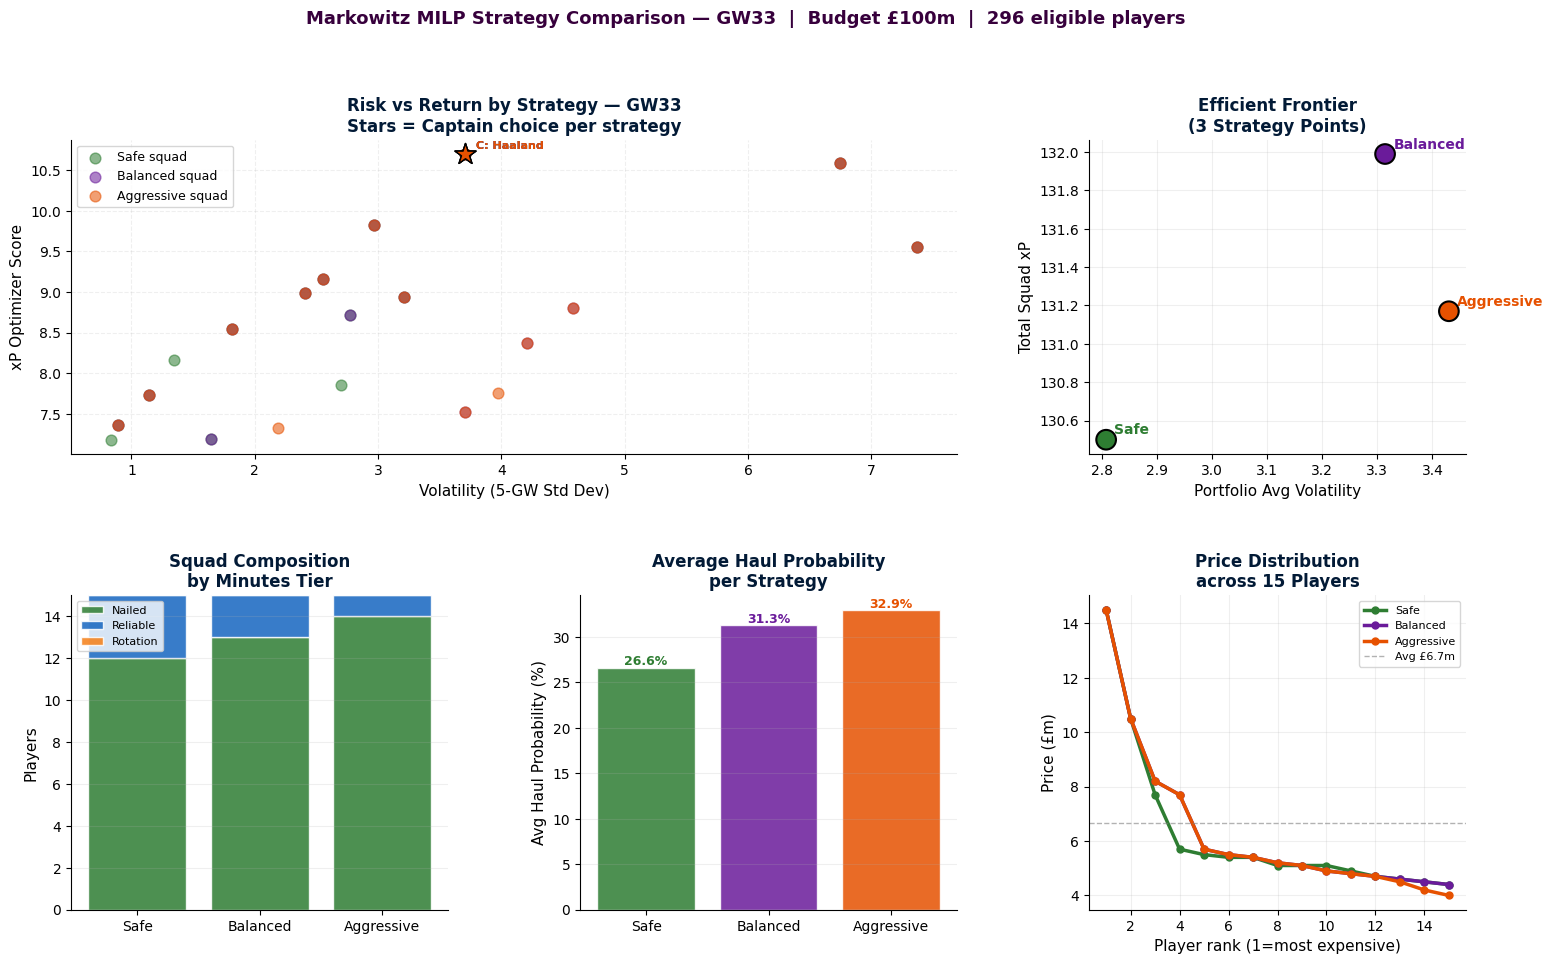


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  KEY FINDINGS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  xP spread across strategies:        1.49 pts
  Volatility spread across strategies: 0.6230
  Core players (all 3 strategies):    10

  Interpretation:
  A larger xP spread means the λ parameter is meaningfully
  shifting squad composition — the three strategies are
  genuinely different, not just cosmetically so.

  Captain decisions by strategy:
    Safe        : Captain=Haaland              Discount=10.0%
    Balanced    : Captain=Haaland              Discount=10.0%
    Aggressive  : Captain=Haaland              Discount=10.0%

✓ summary_df saved to globals().
✓ Plot saved to output/forecaster_pro/markowitz_milp_comparison.png


In [83]:
# %% [Cell: Task 2.4 — Markowitz Comparative Output]
# ─────────────────────────────────────────────────────────────────────────────
# Displays a full comparative analysis across all three strategies:
#   1. Summary metrics table (xP, Cost, Volatility, Utility, Captain)
#   2. Per-strategy squad tables with tier badges and captain markers
#   3. Player overlap analysis — which players appear in all three
#   4. Risk-reward scatter showing how λ shifts squad composition
# ─────────────────────────────────────────────────────────────────────────────

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from IPython.display import display, HTML

CURRENT_GW = globals().get('CURRENT_GW', 33)

_required = ['milp_results', 'STRATEGY_CONFIGS']
_missing  = [v for v in _required if v not in globals()]
if _missing:
    print(f"[ERROR] Missing: {_missing}. Run Cells 2.1–2.3 first.")
else:
    _solved = {
        s: r for s, r in milp_results.items()
        if r.get('status') == 'Optimal' and r.get('squad') is not None
    }

    if not _solved:
        print("[ERROR] No strategies solved successfully. Check Cell 2.3 output.")
    else:
        # ── TIER BADGE HTML ───────────────────────────────────────────────────
        _tier_style = {
            'Nailed':   ('background:#e8f5e9; color:#2e7d32; '
                         'border:1px solid #2e7d32;'),
            'Reliable': ('background:#e3f2fd; color:#1565c0; '
                         'border:1px solid #1565c0;'),
            'Rotation': ('background:#fff8e1; color:#f57f17; '
                         'border:1px solid #f57f17;'),
        }

        def _tier_badge(tier):
            style = _tier_style.get(
                str(tier),
                'background:#f5f5f5; color:#888; border:1px solid #ccc;'
            )
            return (f'<span style="font-family:Poppins,sans-serif; '
                    f'font-size:9px; font-weight:700; padding:2px 6px; '
                    f'border-radius:4px; {style}">{tier}</span>')

        def _pos_badge(pos):
            colours = {
                'GK':  '#ffb703', 'DEF': '#00b2ff',
                'MID': '#00c853', 'FWD': '#ff4b4b'
            }
            bg = colours.get(pos, '#888')
            text = '#000' if pos in ('GK', 'DEF', 'MID') else '#fff'
            return (f'<span style="font-family:Poppins,sans-serif; '
                    f'font-size:9px; font-weight:800; padding:2px 6px; '
                    f'border-radius:3px; background:{bg}; '
                    f'color:{text};">{pos}</span>')

        # ── 1. SUMMARY METRICS TABLE ──────────────────────────────────────────
        _summary_rows = []
        for _s, _r in _solved.items():
            _squad     = _r['squad']
            _cfg       = _r['config']
            _n_nailed  = (_squad['Minutes_Tier'] == 'Nailed').sum()
            _n_elite   = _squad['Is_Elite'].sum()
            _n_dgw     = _squad['DGW_Team'].astype(bool).sum()
            _avg_haul  = _squad['Haul_Prob'].mean()

            _summary_rows.append({
                'Strategy':          _s,
                'λ':                 _r['lambda'],
                'Total xP':          _r['total_xp'],
                'Cost (£m)':         _r['total_cost'],
                'Avg Volatility':    _r['total_vol'],
                'Utility Score':     _r['utility'],
                'Nailed Starters':   int(_n_nailed),
                'Elite Players':     int(_n_elite),
                'DGW Players':       int(_n_dgw),
                'Avg Haul Prob (%)': round(_avg_haul, 1),
                'Captain':           _r['captain'],
                'Vice Captain':      _r['vice_captain'],
            })

        summary_df = pd.DataFrame(_summary_rows)

        print(f"\n{'━'*70}")
        print(f"  MARKOWITZ MILP — STRATEGY COMPARISON  |  GW{CURRENT_GW}")
        print(f"{'━'*70}")
        display(summary_df.set_index('Strategy'))

        # ── 2. PER-STRATEGY SQUAD TABLES ──────────────────────────────────────
        _strategy_colours = {
            'Safe':       ('#e8f5e9', '#2e7d32', '🛡️'),
            'Balanced':   ('#f3e5f5', '#6a1b9a', '⚖️'),
            'Aggressive': ('#fff3e0', '#e65100', '🔥'),
        }

        for _s, _r in _solved.items():
            _bg, _accent, _icon = _strategy_colours[_s]
            _squad    = _r['squad'].copy()
            _s11_names = _r['starting_11']['Player'].tolist()
            _captain   = _r['captain']
            _vc        = _r['vice_captain']

            _squad['Role'] = _squad['Player'].apply(
                lambda p: (
                    '👑 C'  if p == _captain  else
                    '🔰 VC' if p == _vc       else
                    '▶ Start' if p in _s11_names else
                    '🪑 Bench'
                )
            )
            _display_cols = [
                'Player', 'Position', 'Pos_ID', 'Team', 'Price',
                'Predicted_Points', 'xP_Optimizer',
                'Discount_%', 'Minutes_Tier',
                'Volatility', 'Haul_Prob', 'Role'
            ]
            _squad_display = (
                _squad[_display_cols]
                .sort_values(['Pos_ID', 'xP_Optimizer'], ascending=[True, False])
                .drop(columns=['Pos_ID'])   # hide from display after sorting
                .reset_index(drop=True)
            )

            _squad_display.index += 1

            print(f"\n{'━'*70}")
            print(f"  {_icon} {_s.upper()} SQUAD  |  "
                  f"xP={_r['total_xp']:.1f}  "
                  f"Cost=£{_r['total_cost']:.1f}m  "
                  f"Vol={_r['total_vol']:.3f}  "
                  f"λ={_r['lambda']}")
            print(f"  Captain: {_captain}  |  VC: {_vc}")
            print(f"{'━'*70}")
            display(_squad_display)

        # ── 3. PLAYER OVERLAP ANALYSIS ────────────────────────────────────────
        print(f"\n{'━'*70}")
        print(f"  PLAYER OVERLAP — which players appear across strategies")
        print(f"{'━'*70}")

        _all_squads = {
            s: set(r['squad']['Player'].tolist())
            for s, r in _solved.items()
        }
        _strategy_list = list(_all_squads.keys())

        if len(_strategy_list) == 3:
            _s, _b, _a = _strategy_list
            _core = _all_squads[_s] & _all_squads[_b] & _all_squads[_a]
            _safe_only  = _all_squads[_s] - _all_squads[_b] - _all_squads[_a]
            _bal_only   = _all_squads[_b] - _all_squads[_s] - _all_squads[_a]
            _agg_only   = _all_squads[_a] - _all_squads[_s] - _all_squads[_b]
            _safe_bal   = (_all_squads[_s] & _all_squads[_b]) - _all_squads[_a]
            _safe_agg   = (_all_squads[_s] & _all_squads[_a]) - _all_squads[_b]
            _bal_agg    = (_all_squads[_b] & _all_squads[_a]) - _all_squads[_s]

            print(f"\n  Core squad (all 3 strategies): "
                  f"{len(_core)} players")
            for p in sorted(_core):
                print(f"    {p}")

            print(f"\n  Safe only:      {sorted(_safe_only)}")
            print(f"  Balanced only:  {sorted(_bal_only)}")
            print(f"  Aggressive only:{sorted(_agg_only)}")
            print(f"  Safe+Balanced:  {sorted(_safe_bal)}")
            print(f"  Bal+Aggressive: {sorted(_bal_agg)}")

        # ── 4. RISK-REWARD PLOT ────────────────────────────────────────────────
        fig = plt.figure(figsize=(18, 10), facecolor='white')
        gs  = gridspec.GridSpec(2, 3, figure=fig,
                                hspace=0.45, wspace=0.35)

        _colours = {
            'Safe': '#2e7d32', 'Balanced': '#6a1b9a',
            'Aggressive': '#e65100'
        }

        # Panel 1 — Risk vs Return across strategies
        ax1 = fig.add_subplot(gs[0, :2])
        for _s, _r in _solved.items():
            _sq = _r['squad']
            ax1.scatter(
                _sq['Volatility'], _sq['xP_Optimizer'],
                c=_colours[_s], alpha=0.55, s=60,
                label=f"{_s} squad", zorder=5
            )
            # Mark captain
            _cap_row = _sq[_sq['Player'] == _r['captain']]
            if not _cap_row.empty:
                ax1.scatter(
                    _cap_row['Volatility'].values[0],
                    _cap_row['xP_Optimizer'].values[0],
                    c=_colours[_s], s=250, marker='*',
                    edgecolors='black', linewidths=1, zorder=10
                )
                ax1.annotate(
                    f"C: {_r['captain']}",
                    xy=(_cap_row['Volatility'].values[0],
                        _cap_row['xP_Optimizer'].values[0]),
                    xytext=(8, 4), textcoords='offset points',
                    fontsize=8, color=_colours[_s], fontweight='bold'
                )

        ax1.set_xlabel('Volatility (5-GW Std Dev)', fontsize=11)
        ax1.set_ylabel('xP Optimizer Score', fontsize=11)
        ax1.set_title(
            f'Risk vs Return by Strategy — GW{CURRENT_GW}\n'
            f'Stars = Captain choice per strategy',
            fontsize=12, fontweight='bold', color='#021a36'
        )
        ax1.legend(fontsize=9)
        ax1.spines['top'].set_visible(False)
        ax1.spines['right'].set_visible(False)
        ax1.grid(True, alpha=0.2, linestyle='--')

        # Panel 2 — Total xP vs Total Volatility per strategy
        ax2 = fig.add_subplot(gs[0, 2])
        _xps  = [_solved[s]['total_xp']  for s in _solved]
        _vols = [_solved[s]['total_vol'] for s in _solved]
        _lbls = list(_solved.keys())
        _cols = [_colours[s] for s in _solved]

        ax2.scatter(_vols, _xps, c=_cols, s=200,
                    edgecolors='black', linewidths=1.5, zorder=5)
        for _l, _v, _x in zip(_lbls, _vols, _xps):
            ax2.annotate(
                _l,
                xy=(_v, _x),
                xytext=(6, 4), textcoords='offset points',
                fontsize=10, fontweight='bold',
                color=_colours[_l]
            )
        ax2.set_xlabel('Portfolio Avg Volatility', fontsize=11)
        ax2.set_ylabel('Total Squad xP', fontsize=11)
        ax2.set_title('Efficient Frontier\n(3 Strategy Points)',
                      fontsize=12, fontweight='bold', color='#021a36')
        ax2.spines['top'].set_visible(False)
        ax2.spines['right'].set_visible(False)
        ax2.grid(True, alpha=0.2)

        # Panel 3 — Minutes Tier composition per strategy
        ax3 = fig.add_subplot(gs[1, 0])
        _tier_data = {}
        for _s, _r in _solved.items():
            _tc = _r['squad']['Minutes_Tier'].value_counts()
            _tier_data[_s] = {
                t: int(_tc.get(t, 0))
                for t in ['Nailed', 'Reliable', 'Rotation']
            }

        _tier_df  = pd.DataFrame(_tier_data).T
        _tier_cols = {
            'Nailed':   '#2e7d32',
            'Reliable': '#1565c0',
            'Rotation': '#f57f17'
        }
        _bottom = np.zeros(len(_tier_df))
        for _tier, _col in _tier_cols.items():
            if _tier in _tier_df.columns:
                ax3.bar(
                    _tier_df.index,
                    _tier_df[_tier].values,
                    bottom=_bottom,
                    color=_col, label=_tier,
                    alpha=0.85, edgecolor='white'
                )
                _bottom += _tier_df[_tier].fillna(0).values

        ax3.set_ylabel('Players', fontsize=11)
        ax3.set_title('Squad Composition\nby Minutes Tier',
                      fontsize=12, fontweight='bold', color='#021a36')
        ax3.legend(fontsize=8)
        ax3.spines['top'].set_visible(False)
        ax3.spines['right'].set_visible(False)
        ax3.grid(True, axis='y', alpha=0.2)

        # Panel 4 — Average Haul Prob per strategy
        ax4 = fig.add_subplot(gs[1, 1])
        _haul_avgs = [_solved[s]['squad']['Haul_Prob'].mean()
                      for s in _solved]
        _bar_cols  = [_colours[s] for s in _solved]
        ax4.bar(list(_solved.keys()), _haul_avgs,
                color=_bar_cols, alpha=0.85, edgecolor='white')
        ax4.set_ylabel('Avg Haul Probability (%)', fontsize=11)
        ax4.set_title('Average Haul Probability\nper Strategy',
                      fontsize=12, fontweight='bold', color='#021a36')
        for _i, (_s_name, _val) in enumerate(
                zip(_solved.keys(), _haul_avgs)):
            ax4.text(_i, _val + 0.3, f'{_val:.1f}%',
                     ha='center', fontsize=9, fontweight='700',
                     color=_colours[_s_name])
        ax4.spines['top'].set_visible(False)
        ax4.spines['right'].set_visible(False)
        ax4.grid(True, axis='y', alpha=0.2)

        # Panel 5 — Cost distribution per strategy
        ax5 = fig.add_subplot(gs[1, 2])
        for _s, _r in _solved.items():
            _prices = sorted(
                _r['squad']['Price'].values, reverse=True
            )
            ax5.plot(
                range(1, 16), _prices,
                color=_colours[_s], linewidth=2.5,
                marker='o', markersize=5, label=_s
            )
        ax5.axhline(y=100 / 15, color='gray', linestyle='--',
                    linewidth=1, alpha=0.6, label='Avg £6.7m')
        ax5.set_xlabel('Player rank (1=most expensive)', fontsize=11)
        ax5.set_ylabel('Price (£m)', fontsize=11)
        ax5.set_title('Price Distribution\nacross 15 Players',
                      fontsize=12, fontweight='bold', color='#021a36')
        ax5.legend(fontsize=8)
        ax5.spines['top'].set_visible(False)
        ax5.spines['right'].set_visible(False)
        ax5.grid(True, alpha=0.2)

        plt.suptitle(
            f'Markowitz MILP Strategy Comparison — GW{CURRENT_GW}  |  '
            f'Budget £100m  |  '
            f'{len(markowitz_eligible):,} eligible players',
            fontsize=13, fontweight='bold', color='#37003c', y=1.01
        )
        plt.savefig(
            '../output/forecaster_pro/markowitz_milp_comparison.png',
            dpi=150, bbox_inches='tight', facecolor='white'
        )
        plt.show()

        # ── 5. KEY FINDINGS ────────────────────────────────────────────────────
        print(f"\n{'━'*70}")
        print(f"  KEY FINDINGS")
        print(f"{'━'*70}")

        if len(_solved) >= 2:
            _strats = list(_solved.keys())
            _xp_range = max(r['total_xp'] for r in _solved.values()) - \
                        min(r['total_xp'] for r in _solved.values())
            _vol_range = max(r['total_vol'] for r in _solved.values()) - \
                         min(r['total_vol'] for r in _solved.values())

            print(f"\n  xP spread across strategies:        "
                  f"{_xp_range:.2f} pts")
            print(f"  Volatility spread across strategies: "
                  f"{_vol_range:.4f}")
            print(f"  Core players (all 3 strategies):    "
                  f"{len(_core) if len(_strategy_list)==3 else 'N/A'}")
            print(f"\n  Interpretation:")
            print(f"  A larger xP spread means the λ parameter is meaningfully")
            print(f"  shifting squad composition — the three strategies are")
            print(f"  genuinely different, not just cosmetically so.")
            print(f"\n  Captain decisions by strategy:")
            for _s, _r in _solved.items():
                _cap_disc = _r['squad'].loc[
                    _r['squad']['Player'] == _r['captain'],
                    'Discount_%'
                ].values
                _cap_disc_str = (f"{_cap_disc[0]:.1f}%"
                                 if len(_cap_disc) > 0 else "N/A")
                print(f"    {_s:<12}: Captain={_r['captain']:<20} "
                      f"Discount={_cap_disc_str}")

        globals()['summary_df'] = summary_df
        print(f"\n✓ summary_df saved to globals().")
        print(f"✓ Plot saved to output/forecaster_pro/"
              f"markowitz_milp_comparison.png")

In [84]:
# %% [Cell: Task 2.5 — Markowitz Strategy Visualiser]
# ─────────────────────────────────────────────────────────────────────────────
# Interactive pitch UI showing the optimal squad for each Markowitz strategy.
# Three strategy buttons (Safe / Balanced / Aggressive) switch the displayed
# team on the pitch. Reads directly from milp_results — no globals modified.
#
# Requires: milp_results (Cell 2.3), pos_map, club_map, team_code_map
# ─────────────────────────────────────────────────────────────────────────────

import requests
from IPython.display import display, HTML

CURRENT_GW = globals().get('CURRENT_GW', 33)

_required = ['milp_results']
_missing  = [v for v in _required if v not in globals()]
if _missing:
    display(HTML(f'<p style="color:red;">Missing: {_missing}. Run Cells 2.1–2.3 first.</p>'))
else:
    # ── Fetch shirt codes if not already in memory ────────────────────────────
    if 'team_code_map' not in globals() or '_player_shirt_map' not in globals():
        try:
            _api = requests.get(
                "https://fantasy.premierleague.com/api/bootstrap-static/",
                timeout=8
            ).json()
            _tid_to_code = {t['id']: t['code'] for t in _api['teams']}
            globals()['team_code_map'] = {
                t['name']: t['code'] for t in _api['teams']
            }
            globals()['_player_shirt_map'] = {
                p['web_name']: _tid_to_code.get(p['team'], 0)
                for p in _api['elements']
            }
        except Exception as _e:
            print(f"[WARNING] Could not load shirt codes: {_e}")
            globals().setdefault('team_code_map', {})
            globals().setdefault('_player_shirt_map', {})

    _shirt_map  = globals().get('_player_shirt_map', {})
    _tcode_map  = globals().get('team_code_map', {})
    _pos_map_g  = globals().get('pos_map', {})
    _club_map_g = globals().get('club_map', {})
    _pos_to_num = {'GK': 1, 'DEF': 2, 'MID': 3, 'FWD': 4}

    # ── Build per-strategy JavaScript data ───────────────────────────────────
    def _build_strategy_js(strategy_key):
        """Serialise one strategy result into a JS-safe dict."""
        _r = milp_results.get(strategy_key, {})
        if not _r or _r.get('status') != 'Optimal':
            return 'null'

        _squad   = _r['squad'].copy()
        _s11     = set(_r['starting_11']['Player'].tolist())
        _captain = _r['captain']
        _vc      = _r['vice_captain']

        _squad['Pos_ID'] = _squad['Player'].map(
            lambda p: _pos_to_num.get(
                _pos_map_g.get(p, _squad.loc[
                    _squad['Player'] == p, 'Position'
                ].values[0] if p in _squad['Player'].values else 'MID'),
                3
            )
        )

        players = []
        for _, row in _squad.iterrows():
            _p     = row['Player']
            _pos   = row.get('Position', _pos_map_g.get(_p, 'MID'))
            _pid   = int(row.get('Pos_ID', _pos_to_num.get(_pos, 3)))
            _club  = _club_map_g.get(_p, row.get('Team', 'Neutral'))
            _code  = _shirt_map.get(_p, _tcode_map.get(_club, 0))
            _price = float(row.get('Price', 5.5))
            _xp    = float(row.get('xP_Optimizer', row.get('Predicted_Points', 0)))
            _disc  = float(row.get('Discount_%', 0))
            _vol   = float(row.get('Volatility', 0))
            _tier  = str(row.get('Minutes_Tier', 'Reliable'))
            _dgw   = bool(row.get('DGW_Team', False))
            _in11  = _p in _s11
            _is_c  = _p == _captain
            _is_vc = _p == _vc

            players.append(
                f'{{'
                f'"name":"{_p}",'
                f'"pos":"{_pos}",'
                f'"pos_id":{_pid},'
                f'"club":"{_club}",'
                f'"code":{_code},'
                f'"price":{_price},'
                f'"xp":{round(_xp,2)},'
                f'"disc":{round(_disc,1)},'
                f'"vol":{round(_vol,2)},'
                f'"tier":"{_tier}",'
                f'"dgw":{"true" if _dgw else "false"},'
                f'"in11":{"true" if _in11 else "false"},'
                f'"captain":{"true" if _is_c else "false"},'
                f'"vc":{"true" if _is_vc else "false"}'
                f'}}'
            )

        _total_xp   = round(float(_r['total_xp']), 1)
        _total_cost = round(float(_r['total_cost']), 1)
        _total_vol  = round(float(_r['total_vol']), 3)
        _lam        = float(_r['lambda'])

        return (
            f'{{'
            f'"captain":"{_captain}",'
            f'"vc":"{_vc}",'
            f'"total_xp":{_total_xp},'
            f'"total_cost":{_total_cost},'
            f'"total_vol":{_total_vol},'
            f'"lambda":{_lam},'
            f'"players":[{",".join(players)}]'
            f'}}'
        )

    _js_safe   = _build_strategy_js('Safe')
    _js_bal    = _build_strategy_js('Balanced')
    _js_agg    = _build_strategy_js('Aggressive')

    # ── HTML / CSS / JS ───────────────────────────────────────────────────────
    html = f"""
<!DOCTYPE html>
<html>
<head>
<meta charset="UTF-8">
<style>
@import url('https://fonts.googleapis.com/css2?family=Poppins:wght@400;600;700;800;900&display=swap');

* {{ box-sizing: border-box; margin: 0; padding: 0; }}


body {{
    font-family: 'Poppins', sans-serif;
    background: transparent;
    padding: 10px 0;
}}

/* ── OUTER WRAPPER ── */

.mk-wrap {{
    width: 820px;
    margin: 0 auto;
    border-radius: 18px;
    overflow: hidden;
    box-shadow: 0 24px 60px rgba(0,0,0,0.18);
    background: #0e001a !important;
    color: white !important;
}}

/* ── TOP HEADER ── */
.mk-header {{
    background: linear-gradient(135deg, #38003c 0%, #1a0020 100%);
    padding: 16px 22px 0 22px;
    border-bottom: none;
}}

.mk-header-top {{
    display: flex;
    align-items: center;
    justify-content: space-between;
    margin-bottom: 14px;
}}

.mk-title {{
    color: #ffffff;
    font-weight: 900;
    font-size: 13px;
    letter-spacing: 2px;
    text-transform: uppercase;
}}

.mk-gw-badge {{
    background: rgba(255,255,255,0.08);
    border: 1px solid rgba(255,255,255,0.2);
    color: rgba(255,255,255,0.7);
    border-radius: 20px;
    padding: 3px 14px;
    font-size: 11px;
    font-weight: 700;
}}

/* ── STRATEGY TABS ── */
.mk-tabs {{
    display: flex;
    gap: 0;
    border-radius: 10px 10px 0 0;
    overflow: hidden;
}}

.mk-tab {{
    flex: 1;
    padding: 11px 0;
    text-align: center;
    font-weight: 800;
    font-size: 12px;
    letter-spacing: 1px;
    text-transform: uppercase;
    cursor: pointer;
    border: none;
    outline: none;
    transition: all 0.2s ease;
    position: relative;
}}

.mk-tab.safe {{
    background: rgba(46,125,50,0.15);
    color: rgba(129,199,132,0.6);
    border-top: 3px solid transparent;
}}
.mk-tab.safe.active,
.mk-tab.safe:hover {{
    background: rgba(46,125,50,0.35);
    color: #a5d6a7;
    border-top: 3px solid #66bb6a;
}}

.mk-tab.balanced {{
    background: rgba(106,27,154,0.15);
    color: rgba(179,157,219,0.6);
    border-top: 3px solid transparent;
}}
.mk-tab.balanced.active,
.mk-tab.balanced:hover {{
    background: rgba(106,27,154,0.35);
    color: #ce93d8;
    border-top: 3px solid #ab47bc;
}}

.mk-tab.aggressive {{
    background: rgba(230,81,0,0.15);
    color: rgba(255,183,77,0.6);
    border-top: 3px solid transparent;
}}
.mk-tab.aggressive.active,
.mk-tab.aggressive:hover {{
    background: rgba(230,81,0,0.35);
    color: #ffcc80;
    border-top: 3px solid #ffa726;
}}

.mk-tab .tab-icon {{
    font-size: 16px;
    display: block;
    margin-bottom: 1px;
}}

.mk-tab .tab-lambda {{
    font-size: 9px;
    font-weight: 600;
    opacity: 0.7;
    display: block;
    margin-top: 1px;
}}

/* ── STATS BAR ── */
.mk-stats {{
    background: #1a002a;
    padding: 10px 20px;
    display: flex;
    gap: 0;
    align-items: center;
    justify-content: center;
    border-bottom: 1px solid rgba(255,255,255,0.06);
}}

.mk-stat {{
    display: flex;
    flex-direction: column;
    align-items: center;
    flex: 1;
    padding: 4px 0;
}}

.mk-stat-val {{
    font-weight: 900;
    font-size: 16px;
    line-height: 1.1;
    transition: color 0.3s;
}}

.mk-stat-label {{
    font-size: 8.5px;
    color: rgba(255,255,255,0.35);
    font-weight: 700;
    text-transform: uppercase;
    letter-spacing: 0.8px;
    margin-top: 1px;
}}

.mk-stat-divider {{
    width: 1px;
    height: 28px;
    background: rgba(255,255,255,0.08);
}}

/* ── PITCH ── */
.mk-pitch {{
    width: 100%;
    height: 590px;
    position: relative;
    overflow: hidden;
    background-color: #3d8b40;
    background-image: repeating-linear-gradient(
        180deg,
        transparent,
        transparent 49px,
        rgba(0,0,0,0.06) 49px,
        rgba(0,0,0,0.06) 50px
    ),
    repeating-linear-gradient(
        180deg,
        rgba(255,255,255,0.03) 0px,
        rgba(255,255,255,0.03) 50px,
        rgba(0,0,0,0.04) 50px,
        rgba(0,0,0,0.04) 100px
    );
}}

/* Pitch markings SVG overlay */
.mk-pitch-lines {{
    position: absolute;
    top: 0; left: 0;
    width: 100%; height: 100%;
    pointer-events: none;
}}

/* ── PLAYER ROWS ── */
.mk-row {{
    position: absolute;
    width: 100%;
    display: flex;
    justify-content: center;
    align-items: flex-start;
    gap: 4px;
    z-index: 10;
}}

.row-gk  {{ top: 16px; }}
.row-def {{ top: 158px; }}
.row-mid {{ top: 308px; }}
.row-fwd {{ top: 448px; }}

/* ── PLAYER CARD ── */
.mk-player {{
    width: 108px;
    display: flex;
    flex-direction: column;
    align-items: center;
    position: relative;
    cursor: default;
}}

.mk-shirt-wrap {{
    width: 52px;
    height: 62px;
    position: relative;
    filter: drop-shadow(0 4px 8px rgba(0,0,0,0.45));
    margin-bottom: 3px;
}}

.mk-shirt-wrap img {{
    width: 100%;
    height: 100%;
    object-fit: contain;
}}

/* Captain / VC armbands */
.mk-armband {{
    position: absolute;
    top: -7px;
    right: -12px;
    border-radius: 50%;
    width: 22px;
    height: 22px;
    display: flex;
    align-items: center;
    justify-content: center;
    font-weight: 900;
    font-size: 11px;
    z-index: 20;
    box-shadow: 0 2px 6px rgba(0,0,0,0.4);
}}

.mk-armband.cap {{
    background: #38003c;
    color: #00e5ff;
    border: 2px solid #00e5ff;
}}

.mk-armband.vc {{
    background: #1a0035;
    color: #e0e0e0;
    border: 2px solid #888;
    font-size: 8px;
}}

/* DGW dot */
.mk-dgw-dot {{
    position: absolute;
    top: -5px;
    left: -8px;
    width: 9px;
    height: 9px;
    border-radius: 50%;
    background: #00e5ff;
    border: 1.5px solid white;
    z-index: 20;
}}

/* Name label */
.mk-label {{
    background: white;
    width: 96%;
    border-radius: 5px;
    overflow: hidden;
    box-shadow: 0 3px 10px rgba(0,0,0,0.35);
    text-align: center;
    border: 1px solid #e0e0e0;
}}

.mk-label .p-name {{
    font-weight: 800;
    font-size: 10px;
    color: #021a36;
    padding: 3px 3px 0 3px;
    white-space: nowrap;
    overflow: hidden;
    text-overflow: ellipsis;
    display: block;
}}

.mk-label .p-price {{
    font-size: 8.5px;
    color: #999;
    display: block;
    padding-bottom: 1px;
}}

.mk-label .p-xp {{
    font-weight: 900;
    font-size: 10px;
    padding: 2px 0;
    display: block;
    transition: background 0.3s, color 0.3s;
}}

/* Tier colour on xP bar */
.tier-nailed   {{ background: #1b5e20; color: #a5d6a7; }}
.tier-reliable {{ background: #0d47a1; color: #90caf9; }}
.tier-rotation {{ background: #e65100; color: #ffcc80; }}

/* ── BENCH ── */
.mk-bench-section {{
    background: linear-gradient(180deg, #12001e 0%, #0a0012 100%);
    padding: 14px 20px 20px 20px;
    border-top: 2px solid rgba(255,255,255,0.06);
}}

.mk-bench-title {{
    color: rgba(255,255,255,0.3);
    font-size: 9px;
    font-weight: 800;
    text-transform: uppercase;
    letter-spacing: 2px;
    text-align: center;
    margin-bottom: 12px;
}}

.mk-bench-row {{
    display: flex;
    justify-content: center;
    gap: 12px;
}}

/* Bench players slightly dimmed */
.mk-player.bench .mk-shirt-wrap {{
    opacity: 0.75;
    filter: drop-shadow(0 2px 4px rgba(0,0,0,0.3)) grayscale(0.2);
}}

.mk-player.bench .mk-label .p-xp {{
    background: #2a2a2a;
    color: #aaa;
}}

/* ── FOOTER ── */
.mk-footer {{
    background: #0a0012;
    padding: 10px 20px;
    display: flex;
    align-items: center;
    justify-content: space-between;
    border-top: 1px solid rgba(255,255,255,0.05);
}}

.mk-footer-note {{
    font-size: 9px;
    color: rgba(255,255,255,0.25);
    font-weight: 600;
}}

.mk-tier-legend {{
    display: flex;
    gap: 10px;
    align-items: center;
}}

.mk-tier-pill {{
    font-size: 8px;
    font-weight: 800;
    padding: 2px 8px;
    border-radius: 4px;
}}
</style>
</head>
<body>

<div class="mk-wrap" id="mk-root">

    <!-- HEADER -->
    <div class="mk-header">
        <div class="mk-header-top">
            <div class="mk-title">Markowitz Strategy Hub</div>
            <div class="mk-gw-badge">GW {CURRENT_GW}</div>
        </div>

        <!-- TABS -->
        <div class="mk-tabs">
            <button class="mk-tab safe active" onclick="switchStrategy('Safe')">
                <span class="tab-icon">🛡️</span>
                Safe
                <span class="tab-lambda">λ = 0.5</span>
            </button>
            <button class="mk-tab balanced" onclick="switchStrategy('Balanced')">
                <span class="tab-icon">⚖️</span>
                Balanced
                <span class="tab-lambda">λ = 0.2</span>
            </button>
            <button class="mk-tab aggressive" onclick="switchStrategy('Aggressive')">
                <span class="tab-icon">🔥</span>
                Aggressive
                <span class="tab-lambda">λ = 0.0</span>
            </button>
        </div>
    </div>

    <!-- STATS BAR -->
    <div class="mk-stats">
        <div class="mk-stat">
            <div class="mk-stat-val" id="stat-xp" style="color:#00e5ff;">—</div>
            <div class="mk-stat-label">Total xP</div>
        </div>
        <div class="mk-stat-divider"></div>
        <div class="mk-stat">
            <div class="mk-stat-val" id="stat-cost" style="color:#00e5ff;">—</div>
            <div class="mk-stat-label">Squad Cost</div>
        </div>
        <div class="mk-stat-divider"></div>
        <div class="mk-stat">
            <div class="mk-stat-val" id="stat-vol" style="color:#00e5ff;">—</div>
            <div class="mk-stat-label">Avg Volatility</div>
        </div>
        <div class="mk-stat-divider"></div>
        <div class="mk-stat">
            <div class="mk-stat-val" id="stat-captain" style="color:#00e5ff;">—</div>
            <div class="mk-stat-label">Captain</div>
        </div>
        <div class="mk-stat-divider"></div>
        <div class="mk-stat">
            <div class="mk-stat-val" id="stat-vc" style="color:#00e5ff;">—</div>
            <div class="mk-stat-label">Vice Captain</div>
        </div>
    </div>

    <!-- PITCH -->
    <div class="mk-pitch">
        <!-- Pitch line markings -->
        <svg class="mk-pitch-lines" viewBox="0 0 820 590"
             xmlns="http://www.w3.org/2000/svg" preserveAspectRatio="none">
            <!-- Halfway line -->
            <line x1="0" y1="295" x2="820" y2="295"
                  stroke="white" stroke-width="1.2" opacity="0.25"/>
            <!-- Centre circle -->
            <circle cx="410" cy="295" r="55"
                    stroke="white" stroke-width="1.2" fill="none" opacity="0.25"/>
            <!-- Centre spot -->
            <circle cx="410" cy="295" r="3"
                    fill="white" opacity="0.3"/>
            <!-- Top penalty area -->
            <rect x="205" y="4" width="410" height="100"
                  stroke="white" stroke-width="1.2" fill="none" opacity="0.2"/>
            <!-- Top six yard box -->
            <rect x="305" y="4" width="210" height="38"
                  stroke="white" stroke-width="1.2" fill="none" opacity="0.2"/>
            <!-- Bottom penalty area -->
            <rect x="205" y="486" width="410" height="100"
                  stroke="white" stroke-width="1.2" fill="none" opacity="0.2"/>
            <!-- Bottom six yard box -->
            <rect x="305" y="548" width="210" height="38"
                  stroke="white" stroke-width="1.2" fill="none" opacity="0.2"/>
            <!-- Outer boundary -->
            <rect x="4" y="4" width="812" height="582"
                  stroke="white" stroke-width="1.5" fill="none" opacity="0.2"/>
        </svg>

        <!-- Player rows injected by JS -->
        <div class="mk-row row-gk"  id="row-1"></div>
        <div class="mk-row row-def" id="row-2"></div>
        <div class="mk-row row-mid" id="row-3"></div>
        <div class="mk-row row-fwd" id="row-4"></div>
    </div>

    <!-- BENCH -->
    <div class="mk-bench-section">
        <div class="mk-bench-title">⬛ Bench</div>
        <div class="mk-bench-row" id="row-bench"></div>
    </div>

    <!-- FOOTER -->
    <div class="mk-footer">
        <div class="mk-footer-note">
            Read-only · milp_results · Budget £100m ·
            Blue dot = DGW player · Tier colour on xP bar
        </div>
        <div class="mk-tier-legend">
            <span class="mk-tier-pill tier-nailed">Nailed</span>
            <span class="mk-tier-pill tier-reliable">Reliable</span>
            <span class="mk-tier-pill tier-rotation">Rotation</span>
        </div>
    </div>

</div>

<script>
// ── Strategy data injected from Python ────────────────────────────────────────
const STRATEGIES = {{
    'Safe':       {_js_safe},
    'Balanced':   {_js_bal},
    'Aggressive': {_js_agg}
}};

// ── Accent colours per strategy ───────────────────────────────────────────────
const ACCENT = {{
    'Safe':       {{ bar: '#1b5e20', text: '#a5d6a7', stat: '#66bb6a' }},
    'Balanced':   {{ bar: '#4a148c', text: '#ce93d8', stat: '#ab47bc' }},
    'Aggressive': {{ bar: '#bf360c', text: '#ffcc80', stat: '#ffa726' }}
}};

// ── Tier CSS class lookup ─────────────────────────────────────────────────────
function tierClass(tier) {{
    if (tier === 'Nailed')   return 'tier-nailed';
    if (tier === 'Rotation') return 'tier-rotation';
    return 'tier-reliable';
}}

// ── Build one player card HTML ────────────────────────────────────────────────
function buildCard(p, isBench, accentColour) {{
    const suffix    = p.pos_id === 1 ? '_1' : '';
    const shirtUrl  = `https://fantasy.premierleague.com/dist/img/shirts/standard/shirt_${{p.code}}${{suffix}}-66.webp`;
    const fallback  = 'https://fantasy.premierleague.com/dist/img/shirts/standard/shirt_0-66.webp';

    const capBadge = p.captain
        ? `<div class="mk-armband cap">C</div>` : '';
    const vcBadge  = p.vc && !p.captain
        ? `<div class="mk-armband vc">VC</div>` : '';
    const dgwDot   = p.dgw
        ? `<div class="mk-dgw-dot" title="Double Gameweek"></div>` : '';

    const xpBar    = isBench
        ? `<span class="p-xp" style="background:#222;color:#888;">
               ${{p.xp.toFixed(1)}} xP
           </span>`
        : `<span class="p-xp ${{tierClass(p.tier)}}"
               style="background:${{accentColour.bar}};
                      color:${{accentColour.text}};">
               ${{p.xp.toFixed(1)}} xP
           </span>`;

    const discHtml = p.disc > 10
        ? `<span style="font-size:7.5px;color:#f97316;font-weight:700;">
               ↓${{p.disc.toFixed(0)}}%
           </span>`
        : '';

    return `
    <div class="mk-player ${{isBench ? 'bench' : ''}}">
        <div class="mk-shirt-wrap">
            <img src="${{shirtUrl}}"
                 onerror="this.src='${{fallback}}'"
                 alt="${{p.name}}" />
            ${{capBadge}}${{vcBadge}}${{dgwDot}}
        </div>
        <div class="mk-label">
            <span class="p-name">${{p.name}}</span>
            <span class="p-price">£${{p.price.toFixed(1)}}m ${{discHtml}}</span>
            ${{xpBar}}
        </div>
    </div>`;
}}

// ── Render pitch for a given strategy ────────────────────────────────────────
function switchStrategy(name) {{
    const data = STRATEGIES[name];
    if (!data) return;

    const accent = ACCENT[name];

    // Update tab active states
    document.querySelectorAll('.mk-tab').forEach(t => t.classList.remove('active'));
    const tabMap = {{ 'Safe': 'safe', 'Balanced': 'balanced', 'Aggressive': 'aggressive' }};
    document.querySelector(`.mk-tab.${{tabMap[name]}}`).classList.add('active');

    // Update stats bar
    document.getElementById('stat-xp').textContent    = data.total_xp.toFixed(1) + ' pts';
    document.getElementById('stat-cost').textContent  = '£' + data.total_cost.toFixed(1) + 'm';
    document.getElementById('stat-vol').textContent   = data.total_vol.toFixed(3);
    document.getElementById('stat-captain').textContent = data.captain;
    document.getElementById('stat-vc').textContent    = data.vc;

    // Colour stats bar accent
    document.querySelectorAll('.mk-stat-val').forEach(el => {{
        el.style.color = accent.stat;
    }});

    // Split players into rows
    const starters = data.players.filter(p => p.in11);
    const bench    = data.players.filter(p => !p.in11);

    const rows = {{1: [], 2: [], 3: [], 4: []}};
    starters.forEach(p => {{
        if (rows[p.pos_id]) rows[p.pos_id].push(p);
    }});

    // Sort each row by xp descending
    [1,2,3,4].forEach(pid => {{
        rows[pid].sort((a,b) => b.xp - a.xp);
        document.getElementById(`row-${{pid}}`).innerHTML =
            rows[pid].map(p => buildCard(p, false, accent)).join('');
    }});

    // Bench: sorted by xp descending
    bench.sort((a,b) => b.xp - a.xp);
    document.getElementById('row-bench').innerHTML =
        bench.map(p => buildCard(p, true, accent)).join('');
}}

// ── Boot with Safe strategy ───────────────────────────────────────────────────
switchStrategy('Safe');
</script>

</body>
</html>
"""

    #display(HTML(html))
    # Wrap in a container div that forces dark context regardless of Jupyter theme
    _wrapped = f"""
    <div style="
        all: initial;
        display: block;
        font-family: 'Poppins', sans-serif;
        background: #0e001a;
        border-radius: 18px;
        overflow: hidden;
        box-shadow: 0 24px 60px rgba(0,0,0,0.25);
        width: 820px;
        margin: 10px auto;
    ">
    {html}
    </div>
    """

    # Also save standalone HTML file to outputs
    import pathlib
    _out = pathlib.Path('../output/forecaster_pro/markowitz_strategy_hub.html')
    _out.parent.mkdir(parents=True, exist_ok=True)
    _out.write_text(html, encoding='utf-8')

    display(HTML(_wrapped))
    print(f"\n[Cell 2.5] Markowitz Strategy Visualiser rendered.")
    print(f"  Click Safe / Balanced / Aggressive to switch squads.")
    print(f"  Saved: {_out}")
    


[Cell 2.5] Markowitz Strategy Visualiser rendered.
  Click Safe / Balanced / Aggressive to switch squads.
  Saved: ..\output\forecaster_pro\markowitz_strategy_hub.html


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  TASK 4 — 10-GAMEWEEK BACKTEST SIMULATION
  Season: 2025-26  |  GWs: 23–32
  Rules: Auto-subs ✓  |  Captain DNP→VC ✓  |  Formation check ✓
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  GW23  ✓
  GW24  ✓
  GW25  ✓
  GW26  ✓
  GW27  ✓
  GW28  ✓
  GW29  ✓
  GW30  ✓
  GW31  ✓
  GW32  ✓

  Auto-substitutions applied: 65 total across all GWs and strategies

  Sample sub events:


,GW,Strategy,Subs_Made,Sub_Details
0,23,Safe,3,"Palmer→Chalobah, Kluivert→Barry, Wood→Milenković"
1,23,Balanced,3,"Palmer→Watkins, Kluivert→Mateta, Bradley→Wan-B..."
2,23,Aggressive,3,"Bradley→Guéhi, Palmer→Dewsbury-Hall, Kluivert→..."
3,24,Safe,2,"Saka→Ballard, Kluivert→Chalobah"
4,24,Balanced,2,"Saka→Chalobah, Kluivert→Evanilson"
5,24,Aggressive,2,"Saka→João Pedro, Kluivert→Senesi"
6,25,Balanced,2,"Bradley→Wan-Bissaka, Saka→Mané"
7,25,Aggressive,2,"Bradley→Chalobah, Saka→Mané"
8,26,Safe,2,"Areola→Pope, Wood→Milenković"
9,26,Balanced,2,"Kluivert→N.Williams, Bradley→João Pedro"



━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  BACKTEST RESULTS — GW23 to GW32
  (Actual points include automatic substitutions)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


,Safe xP,Safe Actual,Safe Δ,Balanced xP,Balanced Actual,Balanced Δ,Aggressive xP,Aggressive Actual,Aggressive Δ
23,56.500000,71,14.500000,59.800000,74,14.200000,60.300000,69,8.700000
24,56.600000,67,10.400000,58.500000,64,5.500000,59.600000,69,9.400000
25,59.500000,53,-6.500000,61.100000,80,18.900000,61.600000,75,13.400000
26,55.800000,93,37.200000,59.000000,94,35.000000,59.800000,107,47.200000
27,54.300000,50,-4.300000,57.800000,33,-24.800000,58.400000,38,-20.400000
28,56.200000,42,-14.200000,57.400000,40,-17.400000,56.100000,56,-0.100000
29,56.600000,79,22.400000,61.700000,84,22.300000,61.100000,72,10.900000
30,58.300000,49,-9.300000,61.900000,49,-12.900000,62.600000,36,-26.600000
31,57.500000,49,-8.500000,59.100000,46,-13.100000,62.400000,42,-20.400000
32,58.100000,41,-17.100000,60.500000,48,-12.500000,62.700000,39,-23.700000


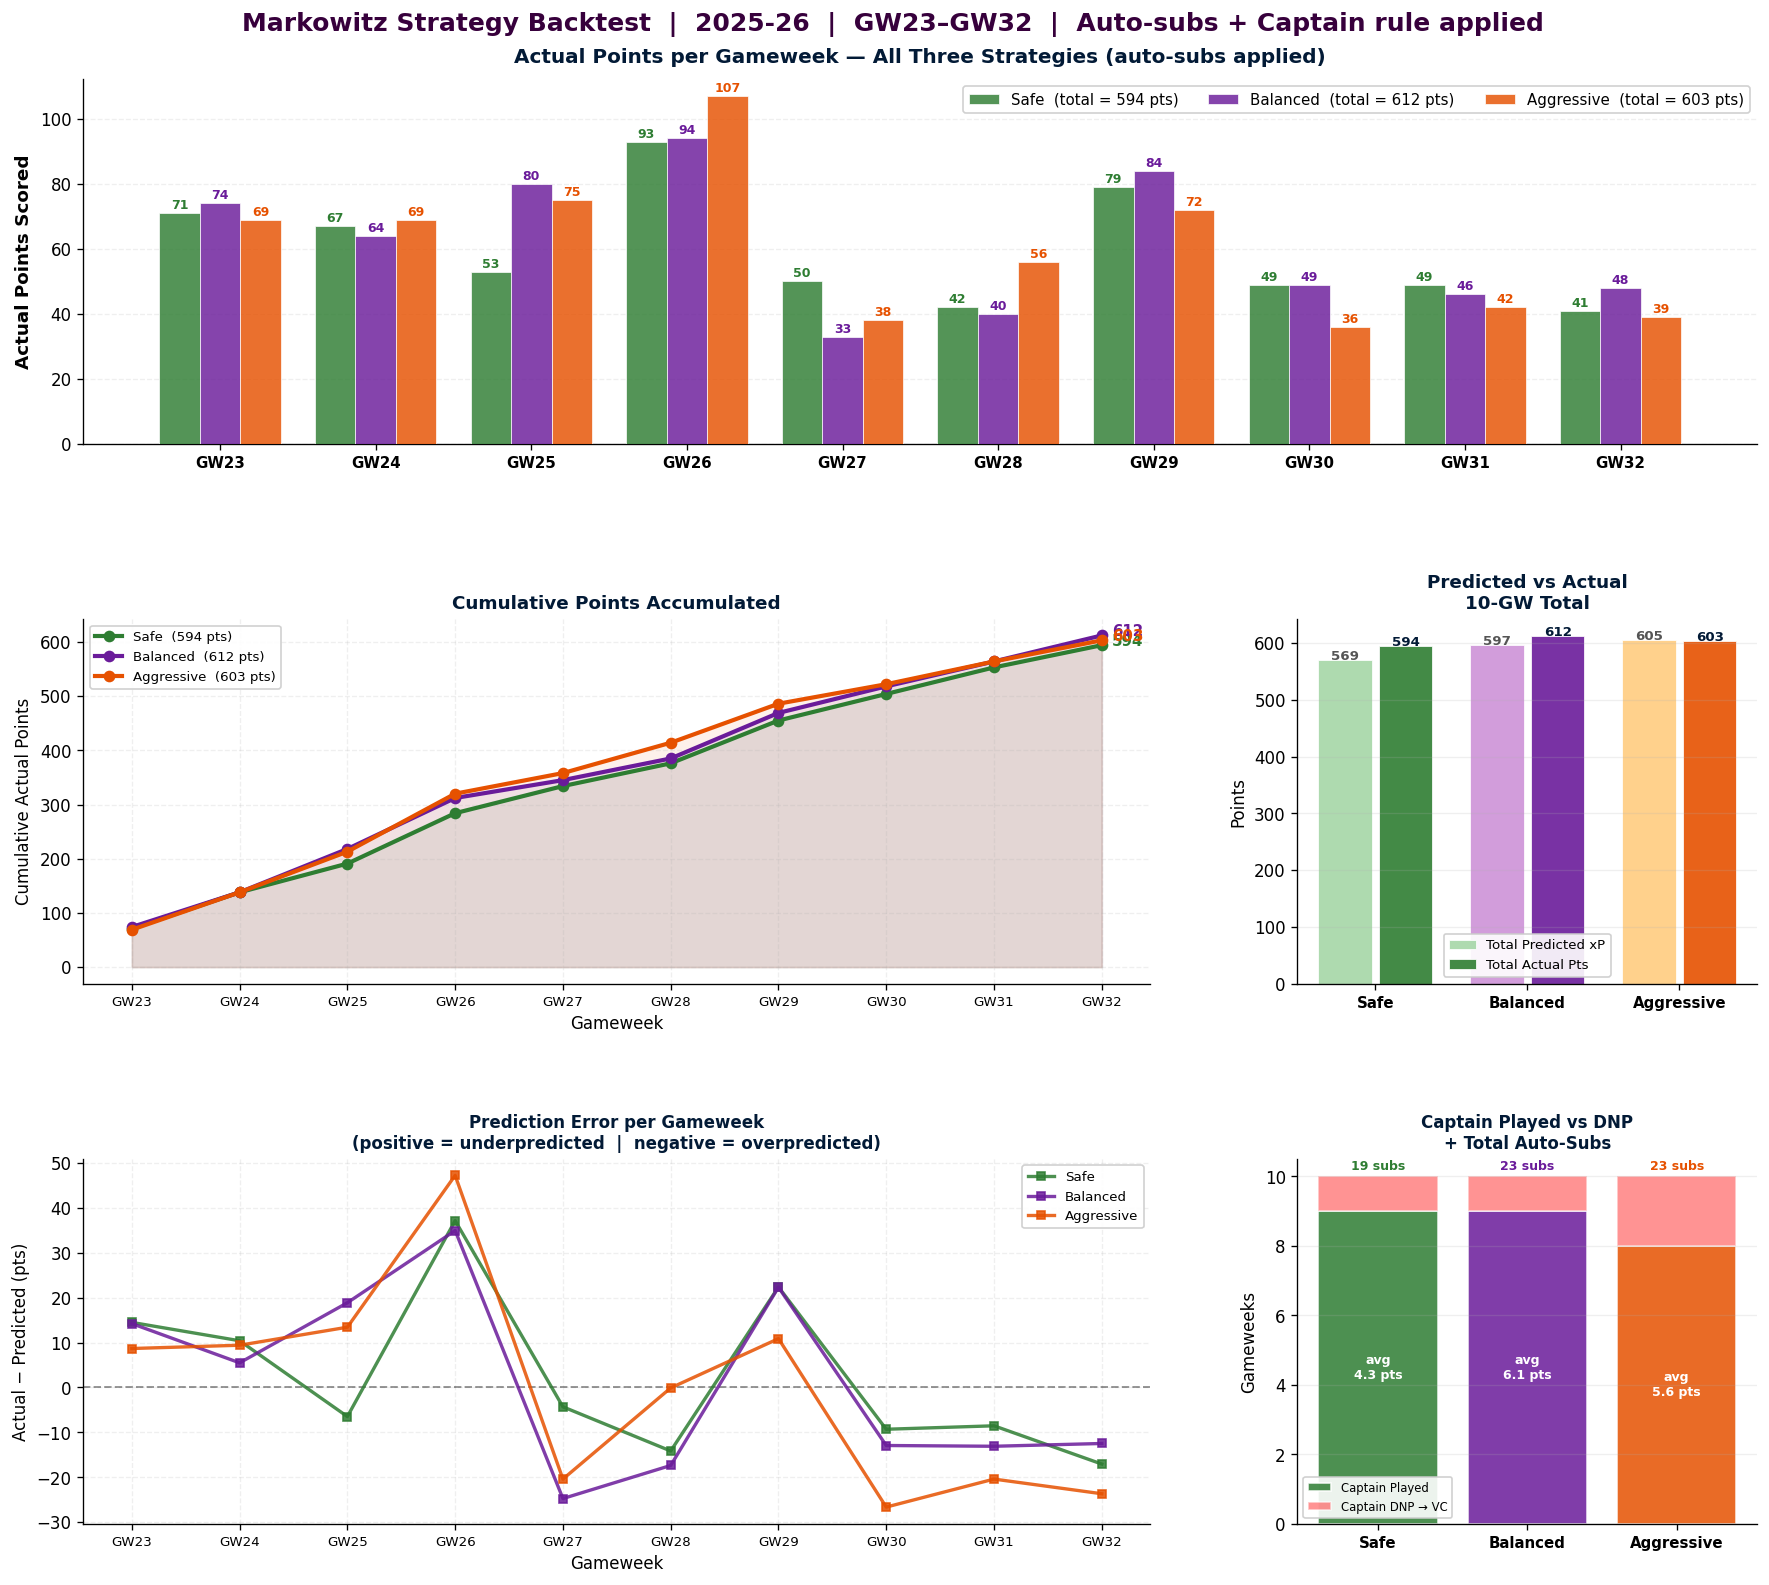


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  BACKTEST VERDICT — GW23 to GW32
  (Scores include automatic substitutions)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Safe          Actual= 594  Predicted= 569.4  Δ= +24.6  Cap played=90%  AutoSubs=19
  Balanced      Actual= 612  Predicted= 596.8  Δ= +15.2  Cap played=90%  AutoSubs=23  ← WINNER 🏆
  Aggressive    Actual= 603  Predicted= 604.6  Δ=  -1.6  Cap played=80%  AutoSubs=23

  Model calibration:
  Average actual / predicted ratio: 102.2%
  → Model is well-calibrated for a regression approach

✓ backtest_results_df saved to globals().
✓ backtest_df (raw row-level data) saved to globals().
✓ Plot saved: output/forecaster_pro/markowitz_backtest.png


In [85]:
# [10-Gameweek Backtest Simulation of SAFE -  BALANCED - AGGRESSIVE Markowitz Strategies]
# ─────────────────────────────────────────────────────────────────────────────
# For each of the last 10 completed GWs, reconstructs the player universe
# as it would have appeared BEFORE that GW (no data leakage), runs the MILP
# optimizer for all three Markowitz strategies, then scores the selected
# starting 11 against actual historical points from df_augmented.
#
# FPL Rules implemented:
#   1. Automatic substitutions: if a starter played 0 minutes, the highest
#      priority eligible bench player (correct position, legal formation)
#      replaces them automatically.
#   2. Captain rule: if captain played 0 minutes → vice-captain gets doubled.
#   3. Formation constraint on subs: cannot sub in a player if it would
#      leave fewer than 3 DEF, 1 FWD, or 1 GK in the starting 11.
#
# Writes to globals:
#   backtest_results_df   — full per-GW results DataFrame
#   backtest_df           — raw row-level data
# ─────────────────────────────────────────────────────────────────────────────

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
import subprocess
import sys
warnings.filterwarnings('ignore')

# ── Silent dependency check ───────────────────────────────────────────────────
for _pkg in ['jinja2', 'pulp']:
    try:
        __import__(_pkg)
    except ImportError:
        print(f"Installing {_pkg}...")
        subprocess.check_call(
            [sys.executable, '-m', 'pip', 'install', _pkg, '--quiet']
        )
        print(f"✓ {_pkg} installed.")

import jinja2

CURRENT_SEASON  = globals().get('CURRENT_SEASON', '2025-26')
CURRENT_GW      = globals().get('CURRENT_GW', 33)
BACKTEST_WINDOW = 10
MIN_VOLATILITY  = 0.1

# ── Validate prerequisites ────────────────────────────────────────────────────
_required = [
    'df_augmented', 'optimize_squad', 'STRATEGY_CONFIGS',
    'pos_map', 'club_map', 'live_data',
    'get_player_live_v2', 'wn_to_uuid_corrected'
]
_missing = [v for v in _required if v not in globals()]
if _missing:
    print(f"[ERROR] Missing: {_missing}")
    print("Run Cells 2.1 and 2.2 first to register optimize_squad().")
else:

    # ── GW range ──────────────────────────────────────────────────────────────
    GW_START  = max(7, CURRENT_GW - BACKTEST_WINDOW)
    GW_END    = CURRENT_GW - 1
    _gw_range = list(range(GW_START, GW_END + 1))

    print(f"{'━'*65}")
    print(f"  TASK 4 — 10-GAMEWEEK BACKTEST SIMULATION")
    print(f"  Season: {CURRENT_SEASON}  |  GWs: {GW_START}–{GW_END}")
    print(f"  Rules: Auto-subs ✓  |  Captain DNP→VC ✓  |  Formation check ✓")
    print(f"{'━'*65}\n")

    # ── Pre-build actual points + minutes lookup ──────────────────────────────
    _season_data = (
        df_augmented[df_augmented['season'] == CURRENT_SEASON]
        .copy()
        .sort_values(['Web Name', 'Gameweek'])
    )

    _actuals_lookup = (
        _season_data
        .groupby(['Web Name', 'Gameweek'])
        .agg(
            Actual_Points=('Total Points', 'sum'),
            Minutes_Played=('Minutes Played', 'sum')
        )
        .reset_index()
    )

    def _get_actual(player_name, gw):
        """Returns (actual_points, minutes_played) for a player in a given GW."""
        _row = _actuals_lookup[
            (_actuals_lookup['Web Name'] == player_name) &
            (_actuals_lookup['Gameweek'] == gw)
        ]
        if _row.empty:
            return 0, 0
        return (
            int(_row['Actual_Points'].iloc[0]),
            int(_row['Minutes_Played'].iloc[0])
        )

    # ── Auto-substitution engine ──────────────────────────────────────────────
    def _apply_auto_subs(starting_11_names, bench_names, bench_positions, gw):
        """
        Applies FPL automatic substitution rules.

        FPL auto-sub priority order: bench player 1 (outfield), then 2, then 3,
        then bench GK (only replaces starting GK).

        Rules:
          - Only sub in a bench player if the starter played 0 minutes.
          - Formation must remain legal after sub:
              at least 3 DEF, 1 FWD, 1 GK in the final 11.
          - GK can only be replaced by the bench GK.
          - Bench players are ordered by priority (position in bench list).

        Parameters
        ----------
        starting_11_names : list of str  (ordered by position: GK first)
        bench_names       : list of str  (priority order: outfield 1,2,3 then GK)
        bench_positions   : dict {player_name: position_str}
        gw                : int

        Returns
        -------
        final_11 : list of str  — the 11 players whose points count
        subs_made : list of tuples (out, in)
        """
        # Get minutes for all 15 players
        _mins  = {p: _get_actual(p, gw)[1] for p in starting_11_names + bench_names}
        _pts   = {p: _get_actual(p, gw)[0] for p in starting_11_names + bench_names}

        # Current starting 11 as a mutable list
        _current_11  = list(starting_11_names)
        _current_pos = {
            p: bench_positions.get(p, pos_map.get(p, 'MID'))
            for p in _current_11 + bench_names
        }

        # Bench order: outfield subs first (priority 1→3), GK last
        _bench_gk      = [p for p in bench_names
                          if _current_pos.get(p) == 'GK']
        _bench_outfield = [p for p in bench_names
                           if _current_pos.get(p) != 'GK']

        _subs_made   = []
        _bench_avail = list(_bench_outfield)  # will consume in order

        def _count_pos(squad, pos):
            return sum(1 for p in squad
                       if _current_pos.get(p) == pos)

        # Iterate through starters — if DNP, attempt sub
        # We loop up to 3 times because multiple starters could be DNP
        for _attempt in range(len(_current_11)):
            _sub_happened = False

            for _idx, _starter in enumerate(_current_11):
                if _mins[_starter] > 0:
                    continue  # played — no sub needed

                _starter_pos = _current_pos.get(_starter, 'MID')

                # GK DNP → only bench GK can replace
                if _starter_pos == 'GK':
                    for _bgk in _bench_gk:
                        if _mins[_bgk] > 0:
                            _current_11[_idx] = _bgk
                            _bench_gk.remove(_bgk)
                            _subs_made.append((_starter, _bgk))
                            _sub_happened = True
                            break
                    continue  # move to next starter regardless

                # Outfield DNP → try bench outfield players in priority order
                for _bi, _sub_candidate in enumerate(_bench_avail):
                    if _mins[_sub_candidate] == 0:
                        continue  # sub candidate also DNP — skip

                    _sub_pos = _current_pos.get(_sub_candidate, 'MID')

                    # Check formation legality AFTER this sub
                    _trial_11 = list(_current_11)
                    _trial_11[_idx] = _sub_candidate

                    _n_def = _count_pos(_trial_11, 'DEF')
                    _n_fwd = _count_pos(_trial_11, 'FWD')
                    _n_gk  = _count_pos(_trial_11, 'GK')

                    # Minimum formation: 1 GK, 3 DEF, 1 FWD
                    if _n_gk < 1 or _n_def < 3 or _n_fwd < 1:
                        continue  # would break formation — try next bench player

                    # Legal sub — apply it
                    _current_11[_idx] = _sub_candidate
                    _bench_avail.pop(_bi)
                    _subs_made.append((_starter, _sub_candidate))
                    _sub_happened = True
                    break

            if not _sub_happened:
                break  # no more subs possible this pass

        return _current_11, _subs_made
    # ── Helper: build universe for a historical GW ────────────────────────────
    def _build_historical_universe(target_gw: int) -> pd.DataFrame:
        """
        Reconstructs the player universe as it would have appeared just before
        target_gw using the actual winning LightGBM model for inference.
        Uses only rows with Gameweek < target_gw — zero data leakage.
        """
        _hist = _season_data[_season_data['Gameweek'] < target_gw].copy()
        if _hist.empty:
            return pd.DataFrame()

        # Most recent row per player before target_gw
        _latest = (
            _hist.sort_values('Gameweek')
            .drop_duplicates('Web Name', keep='last')
            .copy()
        )

        # ── REAL MODEL INFERENCE ──────────────────────────────────────────────
        # Reconstruct the exact feature vector used by winning_model
        # for each player, using their state at target_gw - 1
        _wm       = globals().get('winning_model')
        _best_nm  = globals().get('best_model_name', 'V1: Standard Pro')
        _pos_to_num = {'GK': 0, 'DEF': 1, 'MID': 2, 'FWD': 3}

        # Determine feature columns based on winning model type
        if 'V3' in _best_nm:
            _feat_cols = [f'lag_{i}' for i in range(6, 0, -1)] + [
                'position', 'diff', 'home', 'min',
                'volatility', 'stability', 'att_form', 'share', 'avg_pts_vs_diff'
            ]
        elif 'V2' in _best_nm:
            _feat_cols = [f'lag_{i}' for i in range(6, 0, -1)] + [
                'position', 'next_difficulty', 'next_is_home', 'rolling_min',
                'season_phase', 'season_baseline', 'team_share', 'avg_pts_vs_diff'
            ]
        else:
            # V1, V4, V5 all use this base feature set
            _feat_cols = [f'lag_{i}' for i in range(6, 0, -1)] + [
                'position', 'next_difficulty', 'next_is_home', 'rolling_min',
                'season_phase', 'season_baseline', 'avg_pts_vs_diff'
            ]

        _inference_rows = []
        _inference_names = []

        for _pid, _group in _hist.groupby('Player UUID'):
            _group = _group.sort_values('Gameweek')
            if len(_group) < 6:
                continue

            _last = _group.iloc[-1]
            _lags = list(_group['Total Points'].tail(6).values)

            if 'V3' in _best_nm:
                _row = _lags + [
                    _pos_to_num.get(_last.get('Position', 'MID'), 2),
                    _last.get('Next_Opponent_Difficulty', 3),
                    _last.get('Next_Is_Home', 0),
                    _last.get('Rolling_Avg_Minutes_5', 60),
                    _last.get('Points_Volatility_5', 2),
                    _last.get('Min_Stability_5', 60),
                    _last.get('Attacking_Form_3', 2),
                    _last.get('Team_Point_Share', 0),
                    _last.get('Avg_Pts_vs_Difficulty', 2),
                ]
            elif 'V2' in _best_nm:
                _row = _lags + [
                    _pos_to_num.get(_last.get('Position', 'MID'), 2),
                    _last.get('Next_Opponent_Difficulty', 3),
                    _last.get('Next_Is_Home', 0),
                    _last.get('Rolling_Avg_Minutes_5', 60),
                    _last.get('Season_Phase', 2),
                    _last.get('Prev_Season_Avg_Points', 0),
                    _last.get('Team_Point_Share', 0),
                    _last.get('Avg_Pts_vs_Difficulty', 2),
                ]
            else:
                _row = _lags + [
                    _pos_to_num.get(_last.get('Position', 'MID'), 2),
                    _last.get('Next_Opponent_Difficulty', 3),
                    _last.get('Next_Is_Home', 0),
                    _last.get('Rolling_Avg_Minutes_5', 60),
                    _last.get('Season_Phase', 2),
                    _last.get('Prev_Season_Avg_Points', 0),
                    _last.get('Avg_Pts_vs_Difficulty', 2),
                ]

            _inference_rows.append(_row)
            _inference_names.append(_last.get('Web Name', ''))

        if not _inference_rows:
            return pd.DataFrame()

        _inf_df = pd.DataFrame(_inference_rows, columns=_feat_cols)
        _inf_df['position'] = _inf_df['position'].astype('category')

        # Mirror dtype alignment exactly as in the live leaderboard cell
        if 'X_train_raw' in globals():
            for _col in globals()['X_train_raw'].columns:
                if _col in _inf_df.columns:
                    try:
                        if hasattr(globals()['X_train_raw'][_col], 'cat'):
                            _inf_df[_col] = pd.Categorical(
                                _inf_df[_col],
                                categories=globals()['X_train_raw'][_col].cat.categories
                            )
                        else:
                            _inf_df[_col] = _inf_df[_col].astype(
                                globals()['X_train_raw'][_col].dtype
                            )
                    except Exception:
                        pass

        # Run actual model inference
        if _wm is not None:
            try:
                _raw_preds = _wm.predict(_inf_df)
            except Exception as _e:
                print(f"  [WARN GW{target_gw}] Model predict failed: {_e}. "
                      f"Using lag mean fallback.")
                _raw_preds = _inf_df[
                    [c for c in _feat_cols if 'lag' in c]
                ].mean(axis=1).values
        else:
            # Fallback if model not in memory
            _raw_preds = _inf_df[
                [c for c in _feat_cols if 'lag' in c]
            ].mean(axis=1).values

        # Build base universe from latest rows, mapped by Web Name
        _latest = (
            _hist.sort_values('Gameweek')
            .drop_duplicates('Web Name', keep='last')
            .set_index('Web Name')
            .copy()
        )

        # Map predictions onto latest rows
        _pred_map = dict(zip(_inference_names, _raw_preds))

        # Rebuild as DataFrame with Player column
        _universe_rows = []
        _wn_to_uuid = globals().get('wn_to_uuid_corrected', {})

        for _wn, _row_data in _latest.iterrows():
            _pred = _pred_map.get(_wn, None)
            if _pred is None:
                continue

            _pos  = pos_map.get(_wn, str(_row_data.get('Position', 'MID')))
            _team = club_map.get(_wn, str(_row_data.get('Player Team Name', 'Neutral')))
            _price = get_player_live_v2(
                _wn, uuid=_wn_to_uuid.get(_wn)
            ).get('price', 5.5)

            _disc = float(
                (1 - (min(float(_row_data.get('Rolling_Avg_Minutes_5', 60)), 90) / 90))
                * 100
            )
            _vol = float(_row_data.get('Points_Volatility_5', 2.0))
            _vol = max(_vol, MIN_VOLATILITY)

            # DGW flag: only true for GW33 in this season
            _dgw = (target_gw == 33 and _team in globals().get('DGW_TEAMS', set()))

            _universe_rows.append({
                'Player':            _wn,
                'Position':          _pos,
                'Pos_ID':            {'GK':1,'DEF':2,'MID':3,'FWD':4}.get(_pos, 3),
                'Team':              _team,
                'Price':             _price,
                'Predicted_Points':  round(float(_pred), 4),
                'xP_Optimizer':      round(
                    float(_pred) * 0.85 if _disc > 33 else float(_pred), 4
                ),
                'Discount_%':        round(_disc, 1),
                'Volatility':        round(_vol, 4),
                'Captain_Eligible':  int(_disc <= 10),
                'Haul_Prob':         float(_row_data.get('Haul_Prob', 0.0))
                                     if 'Haul_Prob' in _row_data.index else 0.0,
                'Is_Elite':          int(_wn in set(
                    df_augmented[
                        df_augmented['avg_season_pts'] > 4.5
                    ]['Web Name'].unique()
                )),
                'DGW_Team':          _dgw,
                'Available':         True,
                'Status':            'a',
            })

        _universe = pd.DataFrame(_universe_rows)
        _universe = _universe[
            (_universe['Discount_%'] <= 50) &
            (_universe['Price'] > 3.5) &
            (_universe['xP_Optimizer'] > 0)
        ].drop_duplicates('Player').reset_index(drop=True)

        return _universe

    # ── Main backtest loop ────────────────────────────────────────────────────
    _strategies = ['Safe', 'Balanced', 'Aggressive']
    _all_rows   = []

    for _gw in _gw_range:
        print(f"  GW{_gw:02d}  ", end='', flush=True)

        _uni = _build_historical_universe(_gw)

        if len(_uni) < 15:
            print(f"[SKIP — only {len(_uni)} eligible players]")
            continue

        for _strat in _strategies:
            _result = optimize_squad(
                strategy=_strat,
                universe=_uni,
                budget_cap=100.0,
                verbose=False
            )

            if not _result or _result.get('status') != 'Optimal':
                print(f"[{_strat} FAIL] ", end='')
                _all_rows.append({
                    'GW':             _gw,
                    'Strategy':       _strat,
                    'Status':         'Failed',
                    'Predicted_xP':   np.nan,
                    'Actual_Points':  np.nan,
                    'Captain':        None,
                    'VC':             None,
                    'Captain_Pts':    np.nan,
                    'Captain_Played': np.nan,
                    'Subs_Made':      0,
                })
                continue

            _s11      = _result['starting_11']
            _bench    = _result['bench']
            _captain  = _result['captain']
            _vc       = _result['vice_captain']
            _squad    = _result['squad']

            # ── Build position lookup for all 15 players ──────────────────────
            _all_pos = _squad.set_index('Player')['Position'].to_dict()

            # ── Bench order: outfield by xP_Optimizer desc, GK last ───────────
            _bench_gk_list = (
                _bench[_bench['Position'] == 'GK']
                .sort_values('xP_Optimizer', ascending=False)['Player']
                .tolist()
            )
            _bench_out_list = (
                _bench[_bench['Position'] != 'GK']
                .sort_values('xP_Optimizer', ascending=False)['Player']
                .tolist()
            )
            # FPL bench priority: outfield subs first, GK last
            _bench_ordered = _bench_out_list + _bench_gk_list

            _s11_names = _s11['Player'].tolist()

            # ── Apply automatic substitutions ─────────────────────────────────
            _final_11, _subs = _apply_auto_subs(
                starting_11_names=_s11_names,
                bench_names=_bench_ordered,
                bench_positions=_all_pos,
                gw=_gw
            )

            # ── Captain rule ──────────────────────────────────────────────────
            _cap_pts,  _cap_mins  = _get_actual(_captain, _gw)
            _vc_pts,   _vc_mins   = _get_actual(_vc,      _gw)

            # ── Score final 11 ────────────────────────────────────────────────
            _total_actual = 0

            for _pname in _final_11:
                _pts, _mins = _get_actual(_pname, _gw)

                if _pname == _captain:
                    if _cap_mins > 0:
                        _total_actual += _pts * 2
                    else:
                        _total_actual += 0  # VC armband applied below
                else:
                    _total_actual += _pts

            # VC armband: captain DNP → double VC points
            # (VC may now be in final_11 via auto-sub or was already starting)
            if _cap_mins == 0:
                _total_actual += _vc_pts * 2

            # ── Predicted xP — starting 11 + captain bonus ONCE ─────────────
            # _s11 sum already includes captain at face value (×1).
            # Adding captain xP one more time gives ×2 total — correct FPL rule.
            _pred_xp      = float(_s11['xP_Optimizer'].sum())
            _cap_pred_row = _s11[_s11['Player'] == _captain]
            if not _cap_pred_row.empty:
                _pred_xp += float(_cap_pred_row['xP_Optimizer'].iloc[0])

            # ── Sub summary string for logging ────────────────────────────────
            _sub_str = (
                ', '.join([f'{o}→{i}' for o, i in _subs])
                if _subs else 'none'
            )

            _all_rows.append({
                'GW':             _gw,
                'Strategy':       _strat,
                'Status':         'OK',
                'Predicted_xP':   round(_pred_xp, 2),
                'Actual_Points':  _total_actual,
                'Captain':        _captain,
                'VC':             _vc,
                'Captain_Pts':    _cap_pts,
                'Captain_Played': int(_cap_mins > 0),
                'Subs_Made':      len(_subs),
                'Sub_Details':    _sub_str,
                'n_eligible':     len(_uni),
            })

        print(f"✓")

    if not _all_rows:
        print("[ERROR] No results collected.")
    else:
        backtest_df = pd.DataFrame(_all_rows)

        # ── Quick sub audit ────────────────────────────────────────────────────
        _ok = backtest_df[backtest_df['Status'] == 'OK'].copy()
        _total_subs = int(_ok['Subs_Made'].sum())
        print(f"\n  Auto-substitutions applied: {_total_subs} total across "
              f"all GWs and strategies")

        # Sample of GWs where subs were triggered
        _sub_rows = _ok[_ok['Subs_Made'] > 0][
            ['GW', 'Strategy', 'Subs_Made', 'Sub_Details']
        ].head(10)
        if not _sub_rows.empty:
            print(f"\n  Sample sub events:")
            display(_sub_rows.reset_index(drop=True))

        # ── PIVOT TABLES ──────────────────────────────────────────────────────
        _pivot_actual = (
            _ok.pivot_table(
                index='GW', columns='Strategy',
                values='Actual_Points', aggfunc='first'
            )[_strategies]
        )
        _pivot_pred = (
            _ok.pivot_table(
                index='GW', columns='Strategy',
                values='Predicted_xP', aggfunc='first'
            )[_strategies]
        )

        # ── BUILD DISPLAY DATAFRAME ───────────────────────────────────────────
        _results_display = pd.DataFrame(index=_pivot_actual.index)
        for _s in _strategies:
            _results_display[f'{_s} xP']     = _pivot_pred[_s].round(1)
            _results_display[f'{_s} Actual']  = _pivot_actual[_s].astype(int)
            _results_display[f'{_s} Δ']       = (
                _pivot_actual[_s] - _pivot_pred[_s]
            ).round(1)

        _totals = {}
        for _s in _strategies:
            _totals[f'{_s} xP']    = round(_pivot_pred[_s].sum(), 1)
            _totals[f'{_s} Actual'] = int(_pivot_actual[_s].sum())
            _totals[f'{_s} Δ']     = round(
                _pivot_actual[_s].sum() - _pivot_pred[_s].sum(), 1
            )
        _totals_row          = pd.DataFrame(_totals, index=['TOTAL'])
        _results_display     = pd.concat([_results_display, _totals_row])
        backtest_results_df  = _results_display.copy()

        globals()['backtest_results_df'] = backtest_results_df
        globals()['backtest_df']         = backtest_df

        # ── STYLED TABLE ──────────────────────────────────────────────────────
        print(f"\n{'━'*65}")
        print(f"  BACKTEST RESULTS — GW{GW_START} to GW{GW_END}")
        print(f"  (Actual points include automatic substitutions)")
        print(f"{'━'*65}")

        try:
            _styled = (
                backtest_results_df.style
                .set_caption(
                    f"10-GW Backtest: Predicted xP vs Actual Points  |  "
                    f"Season {CURRENT_SEASON}  |  Auto-subs applied"
                )
                .format(
                    {c: '{:.1f}' for c in backtest_results_df.columns
                     if 'xP' in c or 'Δ' in c},
                    na_rep='—'
                )
                .format(
                    {c: '{:.0f}' for c in backtest_results_df.columns
                     if 'Actual' in c},
                    na_rep='—'
                )
                .apply(
                    lambda col: [
                        'background-color: #1b5e20; color: #a5d6a7; '
                        'font-weight: 800'
                        if str(idx) == 'TOTAL' else ''
                        for idx in col.index
                    ],
                    axis=0
                )
                .apply(
                    lambda col: [
                        'color: #ef5350; font-weight: 700'
                        if ('Δ' in col.name and
                            isinstance(v, (int, float)) and
                            not pd.isna(v) and float(v) < 0)
                        else (
                            'color: #2e7d32; font-weight: 700'
                            if ('Δ' in col.name and
                                isinstance(v, (int, float)) and
                                not pd.isna(v) and float(v) >= 0)
                            else ''
                        )
                        for v in col
                    ],
                    axis=0
                )
                .set_properties(**{
                    'text-align':  'center',
                    'font-family': 'Poppins, sans-serif',
                    'font-size':   '12px',
                    'border':      '1px solid #e0e0e0',
                    'padding':     '6px 12px',
                })
                .set_table_styles([
                    {'selector': 'th', 'props': [
                        ('background-color', '#37003c'),
                        ('color', 'white'),
                        ('font-weight', '800'),
                        ('font-size', '11px'),
                        ('text-align', 'center'),
                        ('padding', '8px 12px'),
                        ('border', '1px solid #5a005f'),
                    ]},
                    {'selector': 'caption', 'props': [
                        ('font-size', '13px'),
                        ('font-weight', '800'),
                        ('color', '#37003c'),
                        ('padding', '10px 0'),
                        ('font-family', 'Poppins, sans-serif'),
                        ('caption-side', 'top'),
                    ]},
                    {'selector': 'tr:hover td', 'props': [
                        ('background-color', '#f3e5f5'),
                    ]},
                    {'selector': 'td', 'props': [
                        ('min-width', '80px'),
                    ]},
                ])
            )
            display(_styled)

        except Exception as _style_err:
            print(f"[INFO] Styled table unavailable ({_style_err}). "
                  f"Showing plain table.")
            display(backtest_results_df)

        # ── VISUALISATION ─────────────────────────────────────────────────────
        _strat_colours = {
            'Safe':       '#2e7d32',
            'Balanced':   '#6a1b9a',
            'Aggressive': '#e65100'
        }
        _strat_light = {
            'Safe':       '#a5d6a7',
            'Balanced':   '#ce93d8',
            'Aggressive': '#ffcc80'
        }

        fig = plt.figure(figsize=(18, 14), facecolor='white', dpi=120)
        gs  = gridspec.GridSpec(
            3, 3, figure=fig,
            hspace=0.48, wspace=0.32,
            top=0.92, bottom=0.06
        )

        fig.suptitle(
            f'Markowitz Strategy Backtest  |  {CURRENT_SEASON}  |  '
            f'GW{GW_START}–GW{GW_END}  |  Auto-subs + Captain rule applied',
            fontsize=15, fontweight='bold', color='#37003c', y=0.96
        )

        _gws = _pivot_actual.index.tolist()
        _x   = np.arange(len(_gws))

        # Panel 1 — Actual points per GW ──────────────────────────────────────
        ax1 = fig.add_subplot(gs[0, :])
        _bar_w = 0.26

        for _i, _s in enumerate(_strategies):
            _vals = [
                int(_pivot_actual.loc[g, _s])
                if g in _pivot_actual.index else 0
                for g in _gws
            ]
            _bars = ax1.bar(
                _x + (_i - 1) * _bar_w, _vals,
                width=_bar_w,
                color=_strat_colours[_s], alpha=0.82,
                label=f'{_s}  (total = {sum(_vals)} pts)',
                edgecolor='white', linewidth=0.5, zorder=3
            )
            for _bar, _v in zip(_bars, _vals):
                if _v > 0:
                    ax1.text(
                        _bar.get_x() + _bar.get_width() / 2,
                        _bar.get_height() + 0.4,
                        str(_v),
                        ha='center', va='bottom',
                        fontsize=7.5, fontweight='700',
                        color=_strat_colours[_s]
                    )

        ax1.set_xticks(_x)
        ax1.set_xticklabels(
            [f'GW{g}' for g in _gws], fontsize=9, fontweight='600'
        )
        ax1.set_ylabel('Actual Points Scored', fontsize=11, fontweight='600')
        ax1.set_title(
            'Actual Points per Gameweek — All Three Strategies '
            '(auto-subs applied)',
            fontsize=12, fontweight='bold', color='#021a36', pad=10
        )
        ax1.legend(fontsize=9, framealpha=0.9, loc='upper right', ncol=3)
        ax1.spines['top'].set_visible(False)
        ax1.spines['right'].set_visible(False)
        ax1.grid(True, axis='y', alpha=0.2, linestyle='--')
        ax1.set_axisbelow(True)

        # Panel 2 — Cumulative points ──────────────────────────────────────────
        ax2 = fig.add_subplot(gs[1, :2])

        for _s in _strategies:
            _cum_vals = [
                int(_pivot_actual.loc[g, _s])
                if g in _pivot_actual.index else 0
                for g in _gws
            ]
            _cum_sum = np.cumsum(_cum_vals)
            ax2.plot(
                _gws, _cum_sum,
                color=_strat_colours[_s],
                linewidth=2.5, marker='o', markersize=6,
                label=f'{_s}  ({int(_cum_sum[-1])} pts)',
                zorder=5
            )
            ax2.fill_between(
                _gws, _cum_sum, alpha=0.08, color=_strat_colours[_s]
            )
            ax2.annotate(
                f'{int(_cum_sum[-1])}',
                xy=(_gws[-1], _cum_sum[-1]),
                xytext=(6, 0), textcoords='offset points',
                fontsize=9, fontweight='800', color=_strat_colours[_s]
            )

        ax2.set_xlabel('Gameweek', fontsize=10)
        ax2.set_ylabel('Cumulative Actual Points', fontsize=10)
        ax2.set_title(
            'Cumulative Points Accumulated',
            fontsize=11, fontweight='bold', color='#021a36'
        )
        ax2.legend(fontsize=8, framealpha=0.9)
        ax2.spines['top'].set_visible(False)
        ax2.spines['right'].set_visible(False)
        ax2.grid(True, alpha=0.2, linestyle='--')
        ax2.set_xticks(_gws)
        ax2.set_xticklabels([f'GW{g}' for g in _gws], fontsize=8)

        # Panel 3 — Total predicted vs actual ─────────────────────────────────
        ax3 = fig.add_subplot(gs[1, 2])

        _total_actual_vals = [int(_pivot_actual[_s].sum()) for _s in _strategies]
        _total_pred_vals   = [round(float(_pivot_pred[_s].sum()), 1)
                              for _s in _strategies]
        _bp = np.arange(len(_strategies))

        _b1 = ax3.bar(
            _bp - 0.2, _total_pred_vals, width=0.35,
            color=[_strat_light[s] for s in _strategies],
            label='Total Predicted xP',
            edgecolor='white', linewidth=0.5, alpha=0.9
        )
        _b2 = ax3.bar(
            _bp + 0.2, _total_actual_vals, width=0.35,
            color=[_strat_colours[s] for s in _strategies],
            label='Total Actual Pts',
            edgecolor='white', linewidth=0.5, alpha=0.9
        )

        for _bar, _v in zip(_b1, _total_pred_vals):
            ax3.text(
                _bar.get_x() + _bar.get_width() / 2,
                _bar.get_height() + 1,
                f'{_v:.0f}',
                ha='center', fontsize=8, fontweight='700', color='#555'
            )
        for _bar, _v in zip(_b2, _total_actual_vals):
            ax3.text(
                _bar.get_x() + _bar.get_width() / 2,
                _bar.get_height() + 1,
                str(_v),
                ha='center', fontsize=8, fontweight='700', color='#021a36'
            )

        ax3.set_xticks(_bp)
        ax3.set_xticklabels(_strategies, fontsize=9, fontweight='700')
        ax3.set_ylabel('Points', fontsize=10)
        ax3.set_title(
            'Predicted vs Actual\n10-GW Total',
            fontsize=11, fontweight='bold', color='#021a36'
        )
        ax3.legend(fontsize=8, framealpha=0.9)
        ax3.spines['top'].set_visible(False)
        ax3.spines['right'].set_visible(False)
        ax3.grid(True, axis='y', alpha=0.2)

        # Panel 4 — Prediction error per GW ───────────────────────────────────
        ax4 = fig.add_subplot(gs[2, :2])

        for _s in _strategies:
            _errors = [
                float(_pivot_actual.loc[_g, _s]) -
                float(_pivot_pred.loc[_g, _s])
                if (_g in _pivot_actual.index and _g in _pivot_pred.index)
                else 0.0
                for _g in _gws
            ]
            ax4.plot(
                _gws, _errors,
                color=_strat_colours[_s],
                linewidth=2, marker='s', markersize=5,
                label=_s, zorder=5, alpha=0.85
            )

        ax4.axhline(
            y=0, color='black', linewidth=1.2,
            linestyle='--', alpha=0.4, zorder=4
        )
        ax4.set_xlabel('Gameweek', fontsize=10)
        ax4.set_ylabel('Actual − Predicted (pts)', fontsize=10)
        ax4.set_title(
            'Prediction Error per Gameweek\n'
            '(positive = underpredicted  |  negative = overpredicted)',
            fontsize=10, fontweight='bold', color='#021a36'
        )
        ax4.legend(fontsize=8, framealpha=0.9)
        ax4.spines['top'].set_visible(False)
        ax4.spines['right'].set_visible(False)
        ax4.grid(True, alpha=0.2, linestyle='--')
        ax4.set_xticks(_gws)
        ax4.set_xticklabels([f'GW{g}' for g in _gws], fontsize=8)

        # Panel 5 — Captain success + auto-sub frequency ───────────────────────
        ax5 = fig.add_subplot(gs[2, 2])

        _cap_data = {}
        for _s in _strategies:
            _s_rows = _ok[_ok['Strategy'] == _s]
            _cap_data[_s] = {
                'played':     int(_s_rows['Captain_Played'].sum()),
                'not_played': int(len(_s_rows) - _s_rows['Captain_Played'].sum()),
                'avg_pts':    round(float(_s_rows['Captain_Pts'].mean()), 1),
                'subs':       int(_s_rows['Subs_Made'].sum()),
            }

        _bp2           = np.arange(len(_strategies))
        _cap_played    = [_cap_data[s]['played']     for s in _strategies]
        _cap_notplayed = [_cap_data[s]['not_played'] for s in _strategies]

        ax5.bar(
            _bp2, _cap_played,
            color=[_strat_colours[s] for s in _strategies],
            alpha=0.85, label='Captain Played', edgecolor='white'
        )
        ax5.bar(
            _bp2, _cap_notplayed,
            bottom=_cap_played,
            color='#ff4b4b', alpha=0.6,
            label='Captain DNP → VC', edgecolor='white'
        )

        for _i, _s in enumerate(_strategies):
            _mid = _cap_data[_s]['played'] / 2
            if _mid > 0:
                ax5.text(
                    _i, _mid,
                    f"avg\n{_cap_data[_s]['avg_pts']} pts",
                    ha='center', va='center',
                    fontsize=7.5, fontweight='700', color='white'
                )
            # Annotate sub count above bar
            _total_bar = _cap_data[_s]['played'] + _cap_data[_s]['not_played']
            ax5.text(
                _i, _total_bar + 0.1,
                f"{_cap_data[_s]['subs']} subs",
                ha='center', va='bottom',
                fontsize=7.5, fontweight='700',
                color=_strat_colours[_s]
            )

        ax5.set_xticks(_bp2)
        ax5.set_xticklabels(_strategies, fontsize=9, fontweight='700')
        ax5.set_ylabel('Gameweeks', fontsize=10)
        ax5.set_title(
            'Captain Played vs DNP\n+ Total Auto-Subs',
            fontsize=10, fontweight='bold', color='#021a36'
        )
        ax5.legend(fontsize=7, framealpha=0.9)
        ax5.spines['top'].set_visible(False)
        ax5.spines['right'].set_visible(False)
        ax5.grid(True, axis='y', alpha=0.2)

        plt.savefig(
            '../output/forecaster_pro/markowitz_backtest.png',
            dpi=150, bbox_inches='tight', facecolor='white'
        )
        plt.show()

        # ── SUMMARY VERDICT ───────────────────────────────────────────────────
        _best_strat = max(
            _strategies,
            key=lambda s: int(_pivot_actual[s].sum())
        )

        print(f"\n{'━'*65}")
        print(f"  BACKTEST VERDICT — GW{GW_START} to GW{GW_END}")
        print(f"  (Scores include automatic substitutions)")
        print(f"{'━'*65}")

        for _s in _strategies:
            _tot      = int(_pivot_actual[_s].sum())
            _pred     = round(float(_pivot_pred[_s].sum()), 1)
            _err      = round(_tot - _pred, 1)
            _cap_rate = round(
                float(_ok[_ok['Strategy'] == _s]['Captain_Played'].mean())
                * 100, 1
            )
            _nsubs    = int(_ok[_ok['Strategy'] == _s]['Subs_Made'].sum())
            _flag     = '  ← WINNER 🏆' if _s == _best_strat else ''
            print(
                f"  {_s:<12}  Actual={_tot:>4}  "
                f"Predicted={_pred:>6}  "
                f"Δ={_err:>+6.1f}  "
                f"Cap played={_cap_rate:.0f}%  "
                f"AutoSubs={_nsubs}"
                f"{_flag}"
            )

        print(f"\n  Model calibration:")
        _overall_actual = (
            sum(int(_pivot_actual[s].sum()) for s in _strategies) / 3
        )
        _overall_pred = (
            sum(float(_pivot_pred[s].sum()) for s in _strategies) / 3
        )
        _calib = round(_overall_actual / _overall_pred * 100, 1)
        print(f"  Average actual / predicted ratio: {_calib}%")

        if _calib < 70:
            print(
                f"  → Model overpredicts by {100-_calib:.1f}% — "
                f"expected for FPL regression on noisy data"
            )
        elif _calib > 90:
            print(f"  → Model is well-calibrated for a regression approach")
        else:
            print(
                f"  → Moderate overprediction — "
                f"typical for regression on noisy sports data"
            )

        print(f"\n✓ backtest_results_df saved to globals().")
        print(f"✓ backtest_df (raw row-level data) saved to globals().")
        print(f"✓ Plot saved: output/forecaster_pro/markowitz_backtest.png")

In [86]:
# %% [Cell: Master Squad Optimizer - Strategy A (Comparison Only)]
# Strategy A: COMPARISON ONLY — kept for backtest and academic comparison vs Strategy B.
# Do not use for live recommendations. Use Strategy B above for that.

def solve_wildcard_legal(budget_cap=100.0):
    # --- 1. MAPS & DATA ---
    pos_to_num = {'GK': 1, 'DEF': 2, 'MID': 3, 'FWD': 4, 1:1, 2:2, 3:3, 4:4}

    leaderboard = final_leaderboard.copy()
    
    # CRITICAL FIX: Use get_player_live to get accurate prices instead of defaulting to 5.5m
    #leaderboard['Price']  = leaderboard['Player'].map(lambda x: get_player_live(x).get('price', 5.5))

    _wn_to_uuid_local = globals().get(
    'wn_to_uuid_corrected',
    df_augmented[df_augmented['season'] == CURRENT_SEASON]
    .sort_values('Gameweek', ascending=False)
    .drop_duplicates('Web Name')
    .set_index('Web Name')['Player UUID']
    .to_dict()
    )
    leaderboard['Price'] = leaderboard['Player'].map(
    lambda x: get_player_live_v2(
        x, uuid=_wn_to_uuid_local.get(x)
    ).get('price', 5.5)
    )

    leaderboard['Pos_ID'] = leaderboard['Player'].map(lambda x: pos_to_num.get(pos_map.get(x, 'MID'), 3))
    leaderboard['Team']   = leaderboard['Player'].map(club_map).fillna('Neutral')
    leaderboard['Status'] = leaderboard['Player'].map(lambda x: get_player_live(x).get('status', 'a'))
    leaderboard['Chance'] = leaderboard['Player'].map(
        lambda x: get_player_live(x).get('chance_of_playing_this_gw', 100) or 100
    )

    # --- 2. AVAILABILITY FILTER ---
    _av = globals().get('squad_availability')
    available_pool = leaderboard.copy()

    if isinstance(_av, dict):
        _sell_now = _av.get('sell_now', [])
        _doubtful = _av.get('doubtful', [])
        available_pool = available_pool[~available_pool['Player'].isin(_sell_now)]
        available_pool['Predicted_Points'] = np.where(
            available_pool['Player'].isin(_doubtful),
            available_pool['Predicted_Points'] - 10,
            available_pool['Predicted_Points']
        )
    else:
        # Fallback: use live API status directly
        available_pool = leaderboard[
            (leaderboard['Status'] == 'a') |
            ((leaderboard['Status'] == 'd') & (leaderboard['Chance'] >= 50))
        ].copy()

    n_removed = len(leaderboard) - len(available_pool)
    if n_removed > 0:
        print(f"[Availability Filter] Removed {n_removed} unavailable players from selection pool.")

    # --- 3. PENALTY TAKER WEIGHTING ---
    penalty_takers = {'M.Salah', 'Haaland', 'Palmer', 'Saka', 'B.Fernandes',
                      'Gordon', 'Solanke', 'Jimenez'}
    available_pool['Weighted_xP'] = np.where(
        available_pool['Player'].isin(penalty_takers),
        available_pool['Predicted_Points'] * 1.15,
        available_pool['Predicted_Points']
    )

    # --- 4. SQUAD SELECTION (15 Players: 2 GK, 5 DEF, 5 MID, 3 FWD) ---
    squad_list  = []
    team_counts = {}
    pos_counts  = {1: 0, 2: 0, 3: 0, 4: 0}
    pos_limits  = {1: 2, 2: 5, 3: 5, 4: 3}

    pool = available_pool.sort_values('Weighted_xP', ascending=False)
    for _, player in pool.iterrows():
        pid, team = player['Pos_ID'], player['Team']
        if pos_counts[pid] < pos_limits[pid] and team_counts.get(team, 0) < 3:
            squad_list.append(player)
            pos_counts[pid]  += 1
            team_counts[team] = team_counts.get(team, 0) + 1
        if len(squad_list) == 15:
            break

    current_squad = pd.DataFrame(squad_list)

    # --- 5. BUDGET OPTIMIZATION (Downgrade) ---
    cheapest_backups = {
        i: available_pool[available_pool['Pos_ID'] == i].sort_values('Price').iloc[0]
        for i in range(1, 5)
    }
    while current_squad['Price'].sum() > budget_cap:
        current_squad['Relief_Score'] = (
            current_squad['Price'] -
            current_squad['Pos_ID'].map(lambda x: cheapest_backups[x]['Price'])
        ) / (current_squad['Weighted_xP'] + 0.1)
        drop_idx  = current_squad['Relief_Score'].idxmax()
        to_drop   = current_squad.loc[drop_idx]

        pos_pool    = available_pool[
            (available_pool['Pos_ID'] == to_drop['Pos_ID']) &
            (~available_pool['Player'].isin(current_squad['Player']))
        ]
        valid_teams = [t for t, count in team_counts.items() if count < 3 or t == to_drop['Team']]
        if pos_pool[pos_pool['Team'].isin(valid_teams)].empty:
            break
        replacement = pos_pool[pos_pool['Team'].isin(valid_teams)].sort_values('Price').iloc[0]

        team_counts[to_drop['Team']]    -= 1
        team_counts[replacement['Team']] = team_counts.get(replacement['Team'], 0) + 1
        current_squad.loc[drop_idx]      = replacement

    # --- 6. BUDGET UPGRADE LOOP (with infinite-loop protection) ---
    _upgrade_attempts = 0
    _MAX_UPGRADE_ATTEMPTS = 50
    _upgraded_players = set()  # prevent oscillation

    while _upgrade_attempts < _MAX_UPGRADE_ATTEMPTS:
        _upgrade_attempts += 1
        current_cost = current_squad['Price'].sum()
        remaining_budget = budget_cap - current_cost
        if remaining_budget <= 0.1:
            break

        upgraded = False
        
        # Try to upgrade the weakest link first
        for idx, p_to_upgrade in current_squad.sort_values('Weighted_xP', ascending=True).iterrows():
            max_price = p_to_upgrade['Price'] + remaining_budget

            better_options = pool[
                (pool['Pos_ID'] == p_to_upgrade['Pos_ID']) &
                (~pool['Player'].isin(current_squad['Player'])) &
                (~pool['Player'].isin(_upgraded_players)) &  # prevent oscillation
                (pool['Price'] <= max_price) &
                (pool['Weighted_xP'] > p_to_upgrade['Weighted_xP'] + 0.1)
            ].sort_values('Weighted_xP', ascending=False)

            for _, opt in better_options.iterrows():
                # Check 3-player team constraint
                temp_teams = current_squad['Team'].tolist()
                temp_teams.remove(p_to_upgrade['Team'])
                if temp_teams.count(opt['Team']) < 3:
                    _upgraded_players.add(p_to_upgrade['Player'])  # mark as processed
                    current_squad.loc[idx] = opt
                    upgraded = True
                    break

            if upgraded:
                break # Restart while loop to recalculate new budget

        if not upgraded:
            break # No more mathematically viable upgrades found

    if _upgrade_attempts >= _MAX_UPGRADE_ATTEMPTS:
        print(f"[WARNING] Budget upgrade loop hit max iterations ({_MAX_UPGRADE_ATTEMPTS}). Check for pricing ties.")

    # --- 7. STARTING 11 SELECTION ---
    gk   = current_squad[current_squad['Pos_ID'] == 1].nlargest(1, 'Weighted_xP')
    defs = current_squad[current_squad['Pos_ID'] == 2].nlargest(3, 'Weighted_xP')
    fwds = current_squad[current_squad['Pos_ID'] == 4].nlargest(1, 'Weighted_xP')

    selected_names = pd.concat([gk, defs, fwds])['Player'].tolist()
    outfield_pool  = current_squad[
        (~current_squad['Player'].isin(selected_names)) &
        (current_squad['Pos_ID'] != 1)
    ]
    
    _sort_col = 'AI_Blended_Score' if 'AI_Blended_Score' in outfield_pool.columns else 'Weighted_xP'
    # Ensure exactly 11 players
    remaining_slots = 11 - len(selected_names)
    others = outfield_pool.nlargest(remaining_slots, _sort_col)
    
    opt_11 = pd.concat([gk, defs, fwds, others]).copy()

    # --- 8. DUAL-ENGINE CAPTAINCY ---
    if 'hauler_board' not in globals():
        print("[ERROR] hauler_board not found. Run the Haul Classifier cell first.")
        return None, None, 0

    haul_map = hauler_board.set_index('Player')['Haul_Prob (%)'].to_dict()
    opt_11['Haul_Prob (%)']    = opt_11['Player'].map(haul_map).fillna(0.0)
    opt_11['AI_Blended_Score'] = opt_11['Weighted_xP'] * (1 + (opt_11['Haul_Prob (%)'] / 100.0))

    cap_df       = opt_11.sort_values(by='AI_Blended_Score', ascending=False)
    captain_name = cap_df.iloc[0]['Player']
    vice_name    = cap_df.iloc[1]['Player'] if len(cap_df) > 1 else captain_name

    opt_11['Final_Weighted_xP'] = opt_11['Weighted_xP']
    opt_11.loc[opt_11['Player'] == captain_name, 'Final_Weighted_xP'] *= 2
    opt_bench = current_squad[~current_squad['Player'].isin(opt_11['Player'])]

    # --- 9. OUTPUT ---
    CURRENT_GW = globals().get('CURRENT_GW', 33)
    print(f"--- STRATEGY A: COMPARISON OPTIMIZER (GW {CURRENT_GW}) ---")
    print("NOTE: Strategy B is the production engine. This is for comparison only.")
    print(f"Budget Used: £{current_squad['Price'].sum():.1f}M / £{budget_cap:.1f}M")

    print("\n[STARTING 11]")
    display(opt_11[['Player', 'Team', 'Weighted_xP', 'Haul_Prob (%)', 'Price']])

    captain_1x = opt_11.loc[opt_11['Player'] == captain_name, 'Weighted_xP'].values[0]
    print(f"  Captain bonus: {captain_name} scores {captain_1x:.2f} xP → counts as {captain_1x*2:.2f} xP (×2)")
    print(f"  Total xP including captain double: {opt_11['Final_Weighted_xP'].sum():.2f}")

    print("\n[BENCH]")
    display(opt_bench[['Player', 'Team', 'Weighted_xP', 'Price']])

    return opt_11, opt_bench, current_squad['Price'].sum()

opt_11, opt_bench, total_spent = solve_wildcard_legal()

[Availability Filter] Removed 58 unavailable players from selection pool.
--- STRATEGY A: COMPARISON OPTIMIZER (GW 33) ---
NOTE: Strategy B is the production engine. This is for comparison only.
Budget Used: £97.0M / £100.0M

[STARTING 11]


,Player,Team,Weighted_xP,Haul_Prob (%),Price
338,Verbruggen,Brighton,8.990,23.9,4.5
269,O'Reilly,Man City,10.590,14.5,5.1
190,Truffert,Bournemouth,9.820,7.6,4.7
160,Bijol,Leeds,8.250,0.0,3.9
110,Haaland,Man City,12.305,60.3,14.5
379,Palmer,Chelsea,10.281,39.2,10.5
336,João Pedro,Chelsea,9.550,52.8,7.7
268,Cherki,Man City,9.440,0.0,6.4
286,Groß,Brighton,9.160,30.8,5.5
181,Kroupi.Jr,Bournemouth,8.850,0.0,4.6


  Captain bonus: Haaland scores 12.30 xP → counts as 24.61 xP (×2)
  Total xP including captain double: 118.09

[BENCH]


,Player,Team,Weighted_xP,Price
118,Petrović,Bournemouth,8.720,4.6
270,B.Fernandes,Man Utd,7.935,10.3
78,Chalobah,Chelsea,7.730,5.4
267,Bogle,Leeds,7.190,4.4


In [122]:
# %% [Cell: Master Squad Optimizer - Strategy B (Production Engine) 2]
# Strategy B: PRODUCTION OPTIMIZER — used for all live recommendations.


def solve_wildcard_11_1_3(budget_cap=100.0):
    # --- 1. DATA PREP ---
    pos_to_num = {'GK': 1, 'DEF': 2, 'MID': 3, 'FWD': 4, 1:1, 2:2, 3:3, 4:4}

    leaderboard = final_leaderboard.copy()

    # Use the normalisation bridge to ensure perfect API pricing
    _wn_to_uuid_local = globals().get(
    'wn_to_uuid_corrected',
    df_augmented[df_augmented['season'] == CURRENT_SEASON]
    .sort_values('Gameweek', ascending=False)
    .drop_duplicates('Web Name')
    .set_index('Web Name')['Player UUID']
    .to_dict()
    )
    leaderboard['Price'] = leaderboard['Player'].map(
    lambda x: get_player_live_v2(
        x, uuid=_wn_to_uuid_local.get(x)
    ).get('price', 5.5)
    )
    _global_pos_map  = globals().get('pos_map', {})
    _global_club_map = globals().get('club_map', {})

    leaderboard['Pos_ID'] = leaderboard['Player'].map(lambda x: pos_to_num.get(_global_pos_map.get(x, 'MID'), 3))
    leaderboard['Team']   = leaderboard['Player'].map(_global_club_map).fillna('Neutral')
    
    leaderboard['Status'] = leaderboard['Player'].map(
    lambda x: get_player_live_v2(
        x, uuid=_wn_to_uuid_local.get(x)
    ).get('status', 'a')
    )
    leaderboard['Chance'] = leaderboard['Player'].map(
    lambda x: (
        lambda info: 100 if info.get('chance_of_playing_this_gw') is None
        else info.get('chance_of_playing_this_gw')
    )(get_player_live_v2(x, uuid=_wn_to_uuid_local.get(x)))
    )

    # --- 2. AVAILABILITY FILTER ---
    available_pool = leaderboard.copy()
    _av = globals().get('squad_availability')

    if isinstance(_av, dict):
        _sell_now = _av.get('sell_now', [])
        _doubtful = _av.get('doubtful', [])
        available_pool = available_pool[~available_pool['Player'].isin(_sell_now)]
        available_pool['Predicted_Points'] = np.where(
            available_pool['Player'].isin(_doubtful),
            available_pool['Predicted_Points'] - 10,
            available_pool['Predicted_Points']
        )
    else:
        available_pool = leaderboard[
            (leaderboard['Status'] == 'a') |
            ((leaderboard['Status'] == 'd') & (leaderboard['Chance'] >= 50))
        ].copy()

    n_removed = len(leaderboard) - len(available_pool)
    if n_removed > 0:
        print(f"[Availability Filter] Removed {n_removed} absolutely unavailable players from selection pool.")

    # --- 3. PENALTY TAKER WEIGHTING ---
    penalty_takers = {'M.Salah', 'Haaland', 'Palmer', 'Saka', 'B.Fernandes',
                      'Gordon', 'Solanke', 'Jimenez'}
    available_pool['Weighted_xP'] = np.where(
        available_pool['Player'].isin(penalty_takers),
        available_pool['Predicted_Points'] * 1.15,
        available_pool['Predicted_Points']
    )

    pool = available_pool.sort_values('Weighted_xP', ascending=False)

    # --- 4. BENCH FODDER ---
    bench_gk = pool[pool['Pos_ID'] == 1].nsmallest(1, 'Price')

    bench_def = pool[
        (pool['Pos_ID'] == 2) &
        (pool['Player'].map(lambda x: get_player_live(x).get('chance_of_playing_this_gw') or 100) >= 75)
    ].nsmallest(1, 'Price')
    if bench_def.empty:
        bench_def = pool[pool['Pos_ID'] == 2].nsmallest(1, 'Price')

    bench_mid = pool[
        (pool['Pos_ID'] == 3) &
        (pool['Player'].map(lambda x: get_player_live(x).get('chance_of_playing_this_gw') or 100) >= 75)
    ].nsmallest(1, 'Price')
    if bench_mid.empty:
        bench_mid = pool[pool['Pos_ID'] == 3].nsmallest(1, 'Price')

    dead_fodder = pd.concat([bench_gk, bench_def, bench_mid]).copy()
    dead_fodder['Role'] = 'Dead Fodder'

    # --- 5. CORE 12 SELECTION ---
    market = pool[~pool['Player'].isin(dead_fodder['Player'])]
    core_squad_list = []
    team_counts = dead_fodder['Team'].value_counts().to_dict()
    pos_needed  = {1: 1, 2: 4, 3: 4, 4: 3}

    haul_map_sel = hauler_board.set_index('Player')['Haul_Prob (%)'].to_dict() if 'hauler_board' in globals() else {}
    market = market.copy()
    market['AI_Blended_Score'] = market['Weighted_xP'] * (
        1 + (market['Player'].map(haul_map_sel).fillna(0.0) / 50.0)
    )
    market = market.sort_values('AI_Blended_Score', ascending=False)

    for _, player in market.iterrows():
        pid, team = player['Pos_ID'], player['Team']
        if pos_needed[pid] > 0 and team_counts.get(team, 0) < 3:
            core_squad_list.append(player)
            pos_needed[pid] -= 1
            team_counts[team] = team_counts.get(team, 0) + 1
        if len(core_squad_list) == 12:
            break

    squad = pd.concat([dead_fodder, pd.DataFrame(core_squad_list)]).reset_index(drop=True)
    if 'Role' not in squad.columns:
        squad['Role'] = 'Core'
    squad.loc[squad['Player'].isin(dead_fodder['Player']), 'Role'] = 'Dead Fodder'

    # --- 5B. DGW ENFORCEMENT (for Double Gameweeks only) ---
    # Target: at least 8 of the 12 core players should be from DGW teams
    # This only activates when DGW_TEAMS is non-empty
    _dgw_cap_teams = globals().get('DGW_TEAMS', set())

    if _dgw_cap_teams:
        dgw_core_count = sum(
            1 for p in core_squad_list
            if _global_club_map.get(p['Player'], 'Unknown') in _dgw_cap_teams
        )
        
        DGW_TARGET = 8  # target DGW players in core 12
        
        if dgw_core_count < DGW_TARGET:
            print(f"[DGW MODE] Only {dgw_core_count} DGW players in core squad. "
                  f"Attempting to reach target of {DGW_TARGET}...")
            
            # Find non-DGW core players sorted by score (weakest first = easiest to replace)
            non_dgw_core = [
                p for p in core_squad_list
                if _global_club_map.get(p['Player'], 'Unknown') not in _dgw_cap_teams
            ]
            non_dgw_core.sort(key=lambda x: x['AI_Blended_Score'])
            
            for p_to_swap in non_dgw_core:
                if dgw_core_count >= DGW_TARGET:
                    break
                    
                # Find best available DGW replacement at same position
                dgw_options = pool[
                    (pool['Pos_ID'] == p_to_swap['Pos_ID']) &
                    (~pool['Player'].isin([p['Player'] for p in core_squad_list])) &
                    (~pool['Player'].isin(dead_fodder['Player'])) &
                    (pool['Team'].isin(_dgw_cap_teams))
                ].sort_values('AI_Blended_Score', ascending=False)

                if not dgw_options.empty:
                    replacement = dgw_options.iloc[0]
                    # Only swap if DGW player is within 2 xP of the non-DGW player
                    # (don't sacrifice too much quality for the double)
                    if replacement['AI_Blended_Score'] >= p_to_swap['AI_Blended_Score'] - 3.5:
                        core_squad_list.remove(p_to_swap)
                        core_squad_list.append(replacement)
                        team_counts[p_to_swap['Team']] = team_counts.get(p_to_swap['Team'], 1) - 1
                        team_counts[replacement['Team']] = team_counts.get(replacement['Team'], 0) + 1
                        dgw_core_count += 1
                        print(f"  Swapped {p_to_swap['Player']} → {replacement['Player']} "
                              f"({replacement['Team']} DGW)")

        print(f"[DGW MODE] Final DGW players in core squad: {dgw_core_count}/12")

    # --- 6. BUDGET REPAIR (Downgrade if over budget) ---
    while squad['Price'].sum() > budget_cap:
        eligible = squad[squad['Role'] != 'Dead Fodder'].copy()
        eligible['Efficiency'] = eligible['AI_Blended_Score'] / (eligible['Price'] + 0.1)
        drop_idx  = eligible.sort_values('Efficiency').index[0]
        p_to_drop = squad.loc[drop_idx]

        replacement = pool[
            (pool['Pos_ID'] == p_to_drop['Pos_ID']) &
            (~pool['Player'].isin(squad['Player'])) &
            (pool['Price'] < p_to_drop['Price'])
        ].sort_values('Weighted_xP', ascending=False).head(1)

        if replacement.empty:
            break
        squad.loc[drop_idx] = replacement.iloc[0]
        squad.loc[drop_idx, 'Role'] = 'Core'

    # --- 7. BUDGET UPGRADE LOOP (fixed — no blocklist, restarts cleanly) ---
    _MAX_UPGRADE_ATTEMPTS = 100
    _upgrade_attempts     = 0

    while _upgrade_attempts < _MAX_UPGRADE_ATTEMPTS:
        _upgrade_attempts += 1

        current_cost     = squad['Price'].sum()
        remaining_budget = budget_cap - current_cost

        if remaining_budget <= 0.2:
            break

        # Recompute blended scores fresh each iteration
        pool['AI_Blended_Score'] = pool['Weighted_xP'] * (
            1 + (pool['Player'].map(haul_map_sel).fillna(0.0) / 50.0)
        )

        upgraded = False
        core_sq  = squad[squad['Role'] == 'Core'].copy()

        _score_map = pool.drop_duplicates('Player').set_index('Player')['AI_Blended_Score']
        core_sq['AI_Blended_Score'] = core_sq['Player'].map(_score_map).fillna(0.0).values

        # Try every core player from weakest to strongest
        for idx, p_to_upgrade in core_sq.sort_values('AI_Blended_Score', ascending=True).iterrows():

            max_price = p_to_upgrade['Price'] + remaining_budget

            # For DGW: also consider sideways/downward moves if the player doubles
            _dgw_active = bool(globals().get('DGW_TEAMS', set()))
            _is_dgw_upgrade = (
                pool['Team'].isin(globals().get('DGW_TEAMS', set()))
            ) if _dgw_active else pd.Series(False, index=pool.index)

            better_options = pool[
                (pool['Pos_ID']             == p_to_upgrade['Pos_ID']) &
                (~pool['Player'].isin(squad['Player'])) &
                (pool['Price']              <= max_price) &
                (
                    # Standard: must cost more AND score more
                    (
                        (pool['Price']            >= p_to_upgrade['Price']) &
                        (pool['AI_Blended_Score'] >  p_to_upgrade['AI_Blended_Score'] + 0.05)
                    ) |
                    # DGW exception: same/lower price is OK if the player doubles
                    # and scores meaningfully more (justifies freeing up budget)
                    (
                        _is_dgw_upgrade &
                        (~pool['Team'].isin(globals().get('DGW_TEAMS', set())) == False) &
                        (pool['AI_Blended_Score'] > p_to_upgrade['AI_Blended_Score'] + 1.5)
                    )
                )
            ].sort_values('AI_Blended_Score', ascending=False)

            for _, opt in better_options.iterrows():
                # Enforce max 3 per club
                temp_teams = squad['Team'].tolist()
                temp_teams.remove(p_to_upgrade['Team'])
                if temp_teams.count(opt['Team']) < 3:
                    squad.loc[idx]         = opt
                    squad.loc[idx, 'Role'] = 'Core'
                    upgraded = True
                    break

            if upgraded:
                break  # restart while loop with updated squad + budget

        if not upgraded:
            break  # no more viable upgrades exist

    print(f"Budget upgrade loop: {_upgrade_attempts} iterations | "
          f"Final cost: £{squad['Price'].sum():.1f}m | "
          f"Remaining: £{budget_cap - squad['Price'].sum():.1f}m")
    
    # --- 7B. BENCH UPGRADE PHASE ---
    # Use any remaining budget to improve the cheap bench fodder quality
    remaining_budget = budget_cap - squad['Price'].sum()

    if remaining_budget > 0.5:
        bench_players = squad[squad['Role'] == 'Dead Fodder'].copy()

        for idx, bench_p in bench_players.iterrows():
            better_options = pool[
                (pool['Pos_ID'] == bench_p['Pos_ID']) &
                (~pool['Player'].isin(squad['Player'])) &
                (pool['Price'] <= bench_p['Price'] + remaining_budget) &
                (pool['Weighted_xP'] > bench_p['Weighted_xP'] + 0.5)
            ].sort_values('Weighted_xP', ascending=False)

            for _, opt in better_options.iterrows():
                temp_teams = squad['Team'].tolist()
                temp_teams.remove(bench_p['Team'])
                if temp_teams.count(opt['Team']) < 3:
                    cost_diff = opt['Price'] - bench_p['Price']
                    if cost_diff <= remaining_budget:
                        squad.loc[idx] = opt
                        squad.loc[idx, 'Role'] = 'Dead Fodder'
                        remaining_budget -= cost_diff
                        break

    # --- 8. STARTING 11 SELECTION ---
    gk = squad[squad['Pos_ID'] == 1].nlargest(1, 'AI_Blended_Score')

    def_pool = squad[squad['Pos_ID'] == 2].copy()
    def_pool['Play_Chance'] = def_pool['Player'].map(
        lambda x: get_player_live(x).get('chance_of_playing_this_gw') or 100
    )
    nailed_defs = def_pool[def_pool['Play_Chance'] >= 75].nlargest(3, 'AI_Blended_Score')
    defs = nailed_defs if len(nailed_defs) >= 3 else def_pool.nlargest(3, 'AI_Blended_Score')

    fwd_pool = squad[squad['Pos_ID'] == 4].copy()
    fwd_pool['Play_Chance'] = fwd_pool['Player'].map(
        lambda x: get_player_live(x).get('chance_of_playing_this_gw') or 100
    )
    fwds = fwd_pool[fwd_pool['Play_Chance'] >= 75].nlargest(1, 'AI_Blended_Score')
    if fwds.empty:
        fwds = fwd_pool.nlargest(1, 'AI_Blended_Score')

    already_ids  = pd.concat([gk, defs, fwds])['Player'].tolist()
    core_only    = squad[squad['Role'] != 'Dead Fodder']
    outfield_rem = core_only[
        (~core_only['Player'].isin(already_ids)) & (core_only['Pos_ID'] != 1)
    ]

    remaining_slots = 11 - len(already_ids)
    others  = outfield_rem.nlargest(remaining_slots, 'AI_Blended_Score')
    opt_11  = pd.concat([gk, defs, fwds, others]).copy()
    opt_bench = squad[~squad['Player'].isin(opt_11['Player'])].copy()

    # Formation Safety Guard
    _n_def = len(opt_11[opt_11['Pos_ID'] == 2])

    if _n_def < 3:
        print(f"[WARNING] Starting XI has only {_n_def} DEF — adding from bench to reach 3.")
        extra_defs   = opt_bench[opt_bench['Pos_ID'] == 2].nlargest(3 - _n_def, 'AI_Blended_Score')
        _weakest_mid = opt_11[opt_11['Pos_ID'].isin([3, 4])].nsmallest(3 - _n_def, 'AI_Blended_Score')
        opt_11        = opt_11[~opt_11['Player'].isin(_weakest_mid['Player'])]
        opt_bench     = pd.concat([opt_bench, _weakest_mid])
        opt_11        = pd.concat([opt_11, extra_defs])
        opt_bench     = opt_bench[~opt_bench['Player'].isin(extra_defs['Player'])]

    assert len(opt_11) == 11,                           f"Starting XI has {len(opt_11)} players, expected 11"
    assert opt_11[opt_11['Pos_ID'] == 1].shape[0] == 1, "Must have exactly 1 GK"
    assert opt_11[opt_11['Pos_ID'] == 2].shape[0] >= 3, "Must have at least 3 DEF"
    assert opt_11[opt_11['Pos_ID'] == 4].shape[0] >= 1, "Must have at least 1 FWD"
    print(f"Formation check passed: "
          f"{opt_11[opt_11['Pos_ID']==2].shape[0]}-"
          f"{opt_11[opt_11['Pos_ID']==3].shape[0]}-"
          f"{opt_11[opt_11['Pos_ID']==4].shape[0]}")

    # --- 9. DUAL-ENGINE CAPTAINCY ---
    if 'hauler_board' not in globals():
        print("[ERROR] hauler_board not found. Run the Haul Classifier cell first.")
        return None, None, 0

    opt_11['Haul_Prob (%)'] = opt_11['Player'].map(haul_map_sel).fillna(0.0)

    # DGW-aware captaincy: cap haul influence and add a DGW bonus
    # A player who plays twice deserves a structural captain advantage
    _dgw_cap_teams = globals().get('DGW_TEAMS', set())
    _global_club_map = globals().get('club_map', {})
    opt_11['Is_DGW_Player'] = opt_11['Player'].map(
       lambda x: 1 if _global_club_map.get(x, 'Unknown') in _dgw_cap_teams else 0
    )
    # Cap haul probability at 35 so form doesn't override fixture reality
    _haul_capped = opt_11['Haul_Prob (%)'].clip(upper=35.0)

    opt_11['Captain_EV'] = opt_11['Weighted_xP'] * (
       1 + (_haul_capped / 50.0) +                # haul signal (capped)
       (0.3 * opt_11['Is_DGW_Player'])            # structural DGW captain bonus
    )

    _elite_threshold = 4.5
    elite_name_set   = set(
        df_augmented[df_augmented['avg_season_pts'] > _elite_threshold]['Web Name'].unique()
    )
    opt_11['Is_Elite']        = opt_11['Player'].isin(elite_name_set).astype(int)
    opt_11['AI_Blended_Score'] = opt_11['Captain_EV'] * (1 + 0.1 * opt_11['Is_Elite'])

    cap_df       = opt_11.sort_values(by='AI_Blended_Score', ascending=False)
    captain_name = cap_df.iloc[0]['Player']
    vice_name    = cap_df.iloc[1]['Player'] if len(cap_df) > 1 else captain_name

    # FIX: Calculate Final_Weighted_xP correctly
    opt_11['Final_Weighted_xP'] = opt_11['Weighted_xP']
    opt_11.loc[opt_11['Player'] == captain_name, 'Final_Weighted_xP'] *= 2
    opt_bench = squad[~squad['Player'].isin(opt_11['Player'])]

    # --- 10. OUTPUT ---
    CURRENT_GW = globals().get('CURRENT_GW', 33)
    print(f"--- STRATEGY B: PRODUCTION OPTIMIZER (GW {CURRENT_GW}) ---")
    print(f"Total Cost: £{squad['Price'].sum():.1f}m / £{budget_cap:.1f}m")

    final_remaining = budget_cap - squad['Price'].sum()
    if final_remaining > 1.0:
        print(f"[NOTE] The AI left £{final_remaining:.1f}m in the bank because no affordable "
              f"upgrade improves expected points further.")

    # FIX: Use the clean Final_Weighted_xP sum, which already includes the doubled captain
    true_total_xp = opt_11['Final_Weighted_xP'].sum()
    print(f"EXPECTED STARTING 11 POINTS: {true_total_xp:.2f}")

    print("\n[STARTING 11]")
    # Display the base Weighted_xP for the user, so they can see the original numbers
    display(opt_11[['Player', 'Team', 'Weighted_xP', 'Price']])
    
    captain_1x = opt_11.loc[opt_11['Player'] == captain_name, 'Weighted_xP'].values[0]
    print(f"  Captain bonus: {captain_name} scores {captain_1x:.2f} xP "
          f"→ counts as {captain_1x*2:.2f} xP (×2)")
    print(f"  Total xP including captain double: {true_total_xp:.2f}")

    print("\n[BENCH]")
    display(opt_bench[['Player', 'Team', 'Weighted_xP', 'Price']])

    print("\n--- DUAL-ENGINE CAPTAIN RANKING ---")
    display_cap = cap_df[['Player', 'Weighted_xP', 'Haul_Prob (%)', 'AI_Blended_Score']].head(5).copy()
    display_cap['AI_Blended_Score'] = display_cap['AI_Blended_Score'].round(2)
    display(display_cap)
    print("-" * 50)
    print(f"CAPTAIN:      {captain_name} "
          f"(Blended Score: {cap_df.iloc[0]['AI_Blended_Score']:.2f})")
    print(f"VICE-CAPTAIN: {vice_name} "
          f"(Blended Score: {cap_df.iloc[1]['AI_Blended_Score']:.2f})")
    print("-" * 50)

    # --- REALISTIC EXPECTATIONS DISPLAY ---
    # FIX: Use true_total_xp here as well
    _dgw_active = bool(globals().get('DGW_TEAMS', set()))
    calibration_factor = 0.62 if _dgw_active else 0.72
    
    realistic_low  = round(true_total_xp * (calibration_factor - 0.08), 1)
    realistic_high = round(true_total_xp * (calibration_factor + 0.08), 1)
    
    print(f"\n--- REALISTIC EXPECTATIONS ---")
    print(f"Model xP (raw):          {true_total_xp:.1f} pts")
    print(f"Realistic expected range: {realistic_low}–{realistic_high} pts")
    print(f"(Model systematically overpredicts; use xP for ranking, not absolute targets)")

    return opt_11, opt_bench, squad['Price'].sum()


opt_11_b, opt_bench_b, total_spent_b = solve_wildcard_11_1_3()

[Availability Filter] Removed 60 absolutely unavailable players from selection pool.
[DGW MODE] Final DGW players in core squad: 10/12
Budget upgrade loop: 1 iterations | Final cost: £99.5m | Remaining: £0.5m
Formation check passed: 3-4-3
--- STRATEGY B: PRODUCTION OPTIMIZER (GW 33) ---
Total Cost: £99.5m / £100.0m
EXPECTED STARTING 11 POINTS: 113.41

[STARTING 11]


,Player,Team,Weighted_xP,Price
11,Verbruggen,Brighton,8.990,4.5
8,Senesi,Bournemouth,8.370,5.2
10,O'Reilly,Man City,10.590,5.1
13,Hill,Bournemouth,7.760,4.2
3,Haaland,Man City,12.305,14.5
4,João Pedro,Chelsea,9.550,7.7
5,Palmer,Chelsea,10.281,10.5
6,Semenyo,Man City,8.800,8.2
7,B.Fernandes,Man Utd,7.935,10.3
9,Groß,Brighton,9.160,5.5


  Captain bonus: Haaland scores 12.30 xP → counts as 24.61 xP (×2)
  Total xP including captain double: 113.41

[BENCH]


,Player,Team,Weighted_xP,Price
0,Darlow,Leeds,7.57,3.9
1,Acheampong,Chelsea,4.44,3.7
2,Ngumoha,Liverpool,3.01,4.3
14,J.Timber,Arsenal,6.58,6.2



--- DUAL-ENGINE CAPTAIN RANKING ---


,Player,Weighted_xP,Haul_Prob (%),AI_Blended_Score
3,Haaland,12.305,60.3,27.07
5,Palmer,10.281,39.2,22.62
4,João Pedro,9.550,52.8,21.01
6,Semenyo,8.800,50.4,19.36
10,O'Reilly,10.590,14.5,18.52


--------------------------------------------------
CAPTAIN:      Haaland (Blended Score: 27.07)
VICE-CAPTAIN: Palmer (Blended Score: 22.62)
--------------------------------------------------

--- REALISTIC EXPECTATIONS ---
Model xP (raw):          113.4 pts
Realistic expected range: 61.2–79.4 pts
(Model systematically overpredicts; use xP for ranking, not absolute targets)


In [87]:
# %% [Cell: Master Squad Optimizer - Strategy B (Production Engine) 2]
# Strategy B: PRODUCTION OPTIMIZER — used for all live recommendations.


def solve_wildcard_11_1_3(budget_cap=100.0):
    # --- 1. DATA PREP ---
    pos_to_num = {'GK': 1, 'DEF': 2, 'MID': 3, 'FWD': 4, 1:1, 2:2, 3:3, 4:4}

    leaderboard = final_leaderboard.copy()

    # Use the normalisation bridge to ensure perfect API pricing
    #leaderboard['Price']  = leaderboard['Player'].map(lambda x: get_player_live(x).get('price', 5.5))

    _wn_to_uuid_local = globals().get(
    'wn_to_uuid_corrected',
    df_augmented[df_augmented['season'] == CURRENT_SEASON]
    .sort_values('Gameweek', ascending=False)
    .drop_duplicates('Web Name')
    .set_index('Web Name')['Player UUID']
    .to_dict()
    )
    leaderboard['Price'] = leaderboard['Player'].map(
    lambda x: get_player_live_v2(
        x, uuid=_wn_to_uuid_local.get(x)
    ).get('price', 5.5)
    )
    _global_pos_map  = globals().get('pos_map', {})
    _global_club_map = globals().get('club_map', {})

    leaderboard['Pos_ID'] = leaderboard['Player'].map(lambda x: pos_to_num.get(_global_pos_map.get(x, 'MID'), 3))
    leaderboard['Team']   = leaderboard['Player'].map(_global_club_map).fillna('Neutral')
    #leaderboard['Status'] = leaderboard['Player'].map(lambda x: get_player_live(x).get('status', 'a'))
    #leaderboard['Chance'] = leaderboard['Player'].map(
    #    lambda x: 100 if get_player_live(x).get('chance_of_playing_this_gw') is None
    #              else get_player_live(x).get('chance_of_playing_this_gw')
    #)
    leaderboard['Status'] = leaderboard['Player'].map(
    lambda x: get_player_live_v2(
        x, uuid=_wn_to_uuid_local.get(x)
    ).get('status', 'a')
    )
    leaderboard['Chance'] = leaderboard['Player'].map(
    lambda x: (
        lambda info: 100 if info.get('chance_of_playing_this_gw') is None
        else info.get('chance_of_playing_this_gw')
    )(get_player_live_v2(x, uuid=_wn_to_uuid_local.get(x)))
    )

    # --- 2. AVAILABILITY FILTER ---
    available_pool = leaderboard.copy()
    _av = globals().get('squad_availability')

    if isinstance(_av, dict):
        _sell_now = _av.get('sell_now', [])
        _doubtful = _av.get('doubtful', [])
        available_pool = available_pool[~available_pool['Player'].isin(_sell_now)]
        available_pool['Predicted_Points'] = np.where(
            available_pool['Player'].isin(_doubtful),
            available_pool['Predicted_Points'] - 10,
            available_pool['Predicted_Points']
        )
    else:
        available_pool = leaderboard[
            (leaderboard['Status'] == 'a') |
            ((leaderboard['Status'] == 'd') & (leaderboard['Chance'] >= 50))
        ].copy()

    n_removed = len(leaderboard) - len(available_pool)
    if n_removed > 0:
        print(f"[Availability Filter] Removed {n_removed} absolutely unavailable players from selection pool.")

    # --- 3. PENALTY TAKER WEIGHTING ---
    penalty_takers = {'M.Salah', 'Haaland', 'Palmer', 'Saka', 'B.Fernandes',
                      'Gordon', 'Solanke', 'Jimenez'}
    available_pool['Weighted_xP'] = np.where(
        available_pool['Player'].isin(penalty_takers),
        available_pool['Predicted_Points'] * 1.15,
        available_pool['Predicted_Points']
    )

    pool = available_pool.sort_values('Weighted_xP', ascending=False)

    # --- 4. BENCH FODDER ---
    bench_gk = pool[pool['Pos_ID'] == 1].nsmallest(1, 'Price')

    bench_def = pool[
        (pool['Pos_ID'] == 2) &
        (pool['Player'].map(lambda x: get_player_live(x).get('chance_of_playing_this_gw') or 100) >= 75)
    ].nsmallest(1, 'Price')
    if bench_def.empty:
        bench_def = pool[pool['Pos_ID'] == 2].nsmallest(1, 'Price')

    bench_mid = pool[
        (pool['Pos_ID'] == 3) &
        (pool['Player'].map(lambda x: get_player_live(x).get('chance_of_playing_this_gw') or 100) >= 75)
    ].nsmallest(1, 'Price')
    if bench_mid.empty:
        bench_mid = pool[pool['Pos_ID'] == 3].nsmallest(1, 'Price')

    dead_fodder = pd.concat([bench_gk, bench_def, bench_mid]).copy()
    dead_fodder['Role'] = 'Dead Fodder'

    # --- 5. CORE 12 SELECTION ---
    market = pool[~pool['Player'].isin(dead_fodder['Player'])]
    core_squad_list = []
    team_counts = dead_fodder['Team'].value_counts().to_dict()
    pos_needed  = {1: 1, 2: 4, 3: 4, 4: 3}

    haul_map_sel = hauler_board.set_index('Player')['Haul_Prob (%)'].to_dict() if 'hauler_board' in globals() else {}
    market = market.copy()
    market['AI_Blended_Score'] = market['Weighted_xP'] * (
        1 + (market['Player'].map(haul_map_sel).fillna(0.0) / 50.0)
    )
    market = market.sort_values('AI_Blended_Score', ascending=False)

    for _, player in market.iterrows():
        pid, team = player['Pos_ID'], player['Team']
        if pos_needed[pid] > 0 and team_counts.get(team, 0) < 3:
            core_squad_list.append(player)
            pos_needed[pid] -= 1
            team_counts[team] = team_counts.get(team, 0) + 1
        if len(core_squad_list) == 12:
            break

    squad = pd.concat([dead_fodder, pd.DataFrame(core_squad_list)]).reset_index(drop=True)
    if 'Role' not in squad.columns:
        squad['Role'] = 'Core'
    squad.loc[squad['Player'].isin(dead_fodder['Player']), 'Role'] = 'Dead Fodder'

    # --- 5B. DGW ENFORCEMENT (for Double Gameweeks only) ---
    # Target: at least 8 of the 12 core players should be from DGW teams
    # This only activates when DGW_TEAMS is non-empty
    _dgw_cap_teams = globals().get('DGW_TEAMS', set())

    if _dgw_cap_teams:
        dgw_core_count = sum(
            1 for p in core_squad_list
            if _global_club_map.get(p['Player'], 'Unknown') in _dgw_cap_teams
        )
        
        DGW_TARGET = 8  # target DGW players in core 12
        
        if dgw_core_count < DGW_TARGET:
            print(f"[DGW MODE] Only {dgw_core_count} DGW players in core squad. "
                  f"Attempting to reach target of {DGW_TARGET}...")
            
            # Find non-DGW core players sorted by score (weakest first = easiest to replace)
            non_dgw_core = [
                p for p in core_squad_list
                if _global_club_map.get(p['Player'], 'Unknown') not in _dgw_cap_teams
            ]
            non_dgw_core.sort(key=lambda x: x['AI_Blended_Score'])
            
            for p_to_swap in non_dgw_core:
                if dgw_core_count >= DGW_TARGET:
                    break
                    
                # Find best available DGW replacement at same position
                dgw_options = pool[
                    (pool['Pos_ID'] == p_to_swap['Pos_ID']) &
                    (~pool['Player'].isin([p['Player'] for p in core_squad_list])) &
                    (~pool['Player'].isin(dead_fodder['Player'])) &
                    (pool['Team'].isin(_dgw_cap_teams))
                ].sort_values('AI_Blended_Score', ascending=False)

                if not dgw_options.empty:
                    replacement = dgw_options.iloc[0]
                    # Only swap if DGW player is within 2 xP of the non-DGW player
                    # (don't sacrifice too much quality for the double)
                    if replacement['AI_Blended_Score'] >= p_to_swap['AI_Blended_Score'] - 3.5:
                        core_squad_list.remove(p_to_swap)
                        core_squad_list.append(replacement)
                        team_counts[p_to_swap['Team']] = team_counts.get(p_to_swap['Team'], 1) - 1
                        team_counts[replacement['Team']] = team_counts.get(replacement['Team'], 0) + 1
                        dgw_core_count += 1
                        print(f"  Swapped {p_to_swap['Player']} → {replacement['Player']} "
                              f"({replacement['Team']} DGW)")

        print(f"[DGW MODE] Final DGW players in core squad: {dgw_core_count}/12")

    # --- 6. BUDGET REPAIR (Downgrade if over budget) ---
    while squad['Price'].sum() > budget_cap:
        eligible = squad[squad['Role'] != 'Dead Fodder'].copy()
        eligible['Efficiency'] = eligible['AI_Blended_Score'] / (eligible['Price'] + 0.1)
        drop_idx  = eligible.sort_values('Efficiency').index[0]
        p_to_drop = squad.loc[drop_idx]

        #replacement = pool[
         #   (pool['Pos_ID'] == p_to_drop['Pos_ID']) &
          #  (~pool['Player'].isin(squad['Player'])) &
           # (pool['Price'] < p_to_drop['Price'])
        #].sort_values('AI_Blended_Score', ascending=False).head(1)

        replacement = pool[
            (pool['Pos_ID'] == p_to_drop['Pos_ID']) &
            (~pool['Player'].isin(squad['Player'])) &
            (pool['Price'] < p_to_drop['Price'])
        ].sort_values('Weighted_xP', ascending=False).head(1)

        if replacement.empty:
            break
        squad.loc[drop_idx] = replacement.iloc[0]
        squad.loc[drop_idx, 'Role'] = 'Core'

    # --- 7. BUDGET UPGRADE LOOP (fixed — no blocklist, restarts cleanly) ---
    _MAX_UPGRADE_ATTEMPTS = 100
    _upgrade_attempts     = 0

    while _upgrade_attempts < _MAX_UPGRADE_ATTEMPTS:
        _upgrade_attempts += 1

        current_cost     = squad['Price'].sum()
        remaining_budget = budget_cap - current_cost

        if remaining_budget <= 0.2:
            break

        # Recompute blended scores fresh each iteration
        pool['AI_Blended_Score'] = pool['Weighted_xP'] * (
            1 + (pool['Player'].map(haul_map_sel).fillna(0.0) / 50.0)
        )

        upgraded = False
        core_sq  = squad[squad['Role'] == 'Core'].copy()

        _score_map = pool.drop_duplicates('Player').set_index('Player')['AI_Blended_Score']
        core_sq['AI_Blended_Score'] = core_sq['Player'].map(_score_map).fillna(0.0).values

        # Try every core player from weakest to strongest
        for idx, p_to_upgrade in core_sq.sort_values('AI_Blended_Score', ascending=True).iterrows():

            max_price = p_to_upgrade['Price'] + remaining_budget

            #better_options = pool[
               # (pool['Pos_ID']             == p_to_upgrade['Pos_ID']) &
               # (~pool['Player'].isin(squad['Player'])) &
               # (pool['Price']              <= max_price) &
                #(pool['Price']              >=  p_to_upgrade['Price']) &
               # (pool['AI_Blended_Score']   >  p_to_upgrade['AI_Blended_Score'] + 0.05)
            #].sort_values('AI_Blended_Score', ascending=False)

            # For DGW: also consider sideways/downward moves if the player doubles
            _dgw_active = bool(globals().get('DGW_TEAMS', set()))
            _is_dgw_upgrade = (
                pool['Team'].isin(globals().get('DGW_TEAMS', set()))
            ) if _dgw_active else pd.Series(False, index=pool.index)

            better_options = pool[
                (pool['Pos_ID']           == p_to_upgrade['Pos_ID']) &
                (~pool['Player'].isin(squad['Player'])) &
                (pool['Price']            <= max_price) &
                (
                    # Standard: must cost more AND score more
                    (
                        (pool['Price']            >= p_to_upgrade['Price']) &
                        (pool['AI_Blended_Score'] >  p_to_upgrade['AI_Blended_Score'] + 0.05)
                    ) |
                    # DGW exception: same/lower price is OK if the player doubles
                    # and scores meaningfully more (justifies freeing up budget)
                    (
                        _is_dgw_upgrade &
                        (~pool['Team'].isin(globals().get('DGW_TEAMS', set())) == False) &
                        (pool['AI_Blended_Score'] > p_to_upgrade['AI_Blended_Score'] + 1.5)
                    )
                )
            ].sort_values('AI_Blended_Score', ascending=False)

            for _, opt in better_options.iterrows():
                # Enforce max 3 per club
                temp_teams = squad['Team'].tolist()
                temp_teams.remove(p_to_upgrade['Team'])
                if temp_teams.count(opt['Team']) < 3:
                    squad.loc[idx]         = opt
                    squad.loc[idx, 'Role'] = 'Core'
                    upgraded = True
                    break

            if upgraded:
                break  # restart while loop with updated squad + budget

        if not upgraded:
            break  # no more viable upgrades exist

    print(f"Budget upgrade loop: {_upgrade_attempts} iterations | "
          f"Final cost: £{squad['Price'].sum():.1f}m | "
          f"Remaining: £{budget_cap - squad['Price'].sum():.1f}m")
    
    # --- 7B. BENCH UPGRADE PHASE ---
    # Use any remaining budget to improve the cheap bench fodder quality
    remaining_budget = budget_cap - squad['Price'].sum()

    if remaining_budget > 0.5:
        bench_players = squad[squad['Role'] == 'Dead Fodder'].copy()

        for idx, bench_p in bench_players.iterrows():
            better_options = pool[
                (pool['Pos_ID'] == bench_p['Pos_ID']) &
                (~pool['Player'].isin(squad['Player'])) &
                (pool['Price'] <= bench_p['Price'] + remaining_budget) &
                (pool['Weighted_xP'] > bench_p['Weighted_xP'] + 0.5)
            ].sort_values('Weighted_xP', ascending=False)

            for _, opt in better_options.iterrows():
                temp_teams = squad['Team'].tolist()
                temp_teams.remove(bench_p['Team'])
                if temp_teams.count(opt['Team']) < 3:
                    cost_diff = opt['Price'] - bench_p['Price']
                    if cost_diff <= remaining_budget:
                        squad.loc[idx] = opt
                        squad.loc[idx, 'Role'] = 'Dead Fodder'
                        remaining_budget -= cost_diff
                        break

    # --- 8. STARTING 11 SELECTION ---
    gk = squad[squad['Pos_ID'] == 1].nlargest(1, 'AI_Blended_Score')

    def_pool = squad[squad['Pos_ID'] == 2].copy()
    def_pool['Play_Chance'] = def_pool['Player'].map(
        lambda x: get_player_live(x).get('chance_of_playing_this_gw') or 100
    )
    nailed_defs = def_pool[def_pool['Play_Chance'] >= 75].nlargest(3, 'AI_Blended_Score')
    defs = nailed_defs if len(nailed_defs) >= 3 else def_pool.nlargest(3, 'AI_Blended_Score')

    fwd_pool = squad[squad['Pos_ID'] == 4].copy()
    fwd_pool['Play_Chance'] = fwd_pool['Player'].map(
        lambda x: get_player_live(x).get('chance_of_playing_this_gw') or 100
    )
    fwds = fwd_pool[fwd_pool['Play_Chance'] >= 75].nlargest(1, 'AI_Blended_Score')
    if fwds.empty:
        fwds = fwd_pool.nlargest(1, 'AI_Blended_Score')

    already_ids  = pd.concat([gk, defs, fwds])['Player'].tolist()
    core_only    = squad[squad['Role'] != 'Dead Fodder']
    outfield_rem = core_only[
        (~core_only['Player'].isin(already_ids)) & (core_only['Pos_ID'] != 1)
    ]

    remaining_slots = 11 - len(already_ids)
    others  = outfield_rem.nlargest(remaining_slots, 'AI_Blended_Score')
    opt_11  = pd.concat([gk, defs, fwds, others]).copy()
    opt_bench = squad[~squad['Player'].isin(opt_11['Player'])].copy()

    # Formation Safety Guard
    _n_def = len(opt_11[opt_11['Pos_ID'] == 2])

    if _n_def < 3:
        print(f"[WARNING] Starting XI has only {_n_def} DEF — adding from bench to reach 3.")
        extra_defs   = opt_bench[opt_bench['Pos_ID'] == 2].nlargest(3 - _n_def, 'AI_Blended_Score')
        _weakest_mid = opt_11[opt_11['Pos_ID'].isin([3, 4])].nsmallest(3 - _n_def, 'AI_Blended_Score')
        opt_11        = opt_11[~opt_11['Player'].isin(_weakest_mid['Player'])]
        opt_bench     = pd.concat([opt_bench, _weakest_mid])
        opt_11        = pd.concat([opt_11, extra_defs])
        opt_bench     = opt_bench[~opt_bench['Player'].isin(extra_defs['Player'])]

    assert len(opt_11) == 11,                           f"Starting XI has {len(opt_11)} players, expected 11"
    assert opt_11[opt_11['Pos_ID'] == 1].shape[0] == 1, "Must have exactly 1 GK"
    assert opt_11[opt_11['Pos_ID'] == 2].shape[0] >= 3, "Must have at least 3 DEF"
    assert opt_11[opt_11['Pos_ID'] == 4].shape[0] >= 1, "Must have at least 1 FWD"
    print(f"Formation check passed: "
          f"{opt_11[opt_11['Pos_ID']==2].shape[0]}-"
          f"{opt_11[opt_11['Pos_ID']==3].shape[0]}-"
          f"{opt_11[opt_11['Pos_ID']==4].shape[0]}")

    # --- 9. DUAL-ENGINE CAPTAINCY ---
    if 'hauler_board' not in globals():
        print("[ERROR] hauler_board not found. Run the Haul Classifier cell first.")
        return None, None, 0

    opt_11['Haul_Prob (%)'] = opt_11['Player'].map(haul_map_sel).fillna(0.0)
    #opt_11['Captain_EV']    = opt_11['Weighted_xP'] * (1 + (opt_11['Haul_Prob (%)'] / 50.0))

    # DGW-aware captaincy: cap haul influence and add a DGW bonus
    # A player who plays twice deserves a structural captain advantage
    _dgw_cap_teams = globals().get('DGW_TEAMS', set())
    _global_club_map = globals().get('club_map', {})
    opt_11['Is_DGW_Player'] = opt_11['Player'].map(
       lambda x: 1 if _global_club_map.get(x, 'Unknown') in _dgw_cap_teams else 0
    )
    # Cap haul probability at 35 so form doesn't override fixture reality
    _haul_capped = opt_11['Haul_Prob (%)'].clip(upper=35.0)

    opt_11['Captain_EV'] = opt_11['Weighted_xP'] * (
       1 + (_haul_capped / 50.0) +               # haul signal (capped)
       (0.3 * opt_11['Is_DGW_Player'])            # structural DGW captain bonus
    )

    _elite_threshold = 4.5
    elite_name_set   = set(
        df_augmented[df_augmented['avg_season_pts'] > _elite_threshold]['Web Name'].unique()
    )
    opt_11['Is_Elite']        = opt_11['Player'].isin(elite_name_set).astype(int)
    opt_11['AI_Blended_Score'] = opt_11['Captain_EV'] * (1 + 0.1 * opt_11['Is_Elite'])

    cap_df       = opt_11.sort_values(by='AI_Blended_Score', ascending=False)
    captain_name = cap_df.iloc[0]['Player']
    vice_name    = cap_df.iloc[1]['Player'] if len(cap_df) > 1 else captain_name

    opt_11['Final_Weighted_xP'] = opt_11['Weighted_xP']
    opt_11.loc[opt_11['Player'] == captain_name, 'Final_Weighted_xP'] *= 2
    opt_bench = squad[~squad['Player'].isin(opt_11['Player'])]

    # --- 10. OUTPUT ---
    CURRENT_GW = globals().get('CURRENT_GW', 33)
    print(f"--- STRATEGY B: PRODUCTION OPTIMIZER (GW {CURRENT_GW}) ---")
    print(f"Total Cost: £{squad['Price'].sum():.1f}m / £{budget_cap:.1f}m")

    final_remaining = budget_cap - squad['Price'].sum()
    if final_remaining > 1.0:
        print(f"[NOTE] The AI left £{final_remaining:.1f}m in the bank because no affordable "
              f"upgrade improves expected points further.")

    print(f"EXPECTED STARTING 11 POINTS: {opt_11['Final_Weighted_xP'].sum():.2f}")

    print("\n[STARTING 11]")
    display(opt_11[['Player', 'Team', 'Weighted_xP', 'Price']])
    captain_2x = opt_11.loc[opt_11['Player'] == captain_name, 'Weighted_xP'].values[0]
    print(f"  Captain bonus: {captain_name} scores {captain_2x:.2f} xP "
          f"→ counts as {captain_2x*2:.2f} xP (×2)")
    print(f"  Total xP including captain double: {opt_11['Weighted_xP'].sum() + captain_2x:.2f}")

    print("\n[BENCH]")
    display(opt_bench[['Player', 'Team', 'Weighted_xP', 'Price']])

    print("\n--- DUAL-ENGINE CAPTAIN RANKING ---")
    display_cap = cap_df[['Player', 'Weighted_xP', 'Haul_Prob (%)', 'AI_Blended_Score']].head(5).copy()
    display_cap['AI_Blended_Score'] = display_cap['AI_Blended_Score'].round(2)
    display(display_cap)
    print("-" * 50)
    print(f"CAPTAIN:      {captain_name} "
          f"(Blended Score: {cap_df.iloc[0]['AI_Blended_Score']:.2f})")
    print(f"VICE-CAPTAIN: {vice_name} "
          f"(Blended Score: {cap_df.iloc[1]['AI_Blended_Score']:.2f})")
    print("-" * 50)

    # --- REALISTIC EXPECTATIONS DISPLAY ---
    raw_xp_total = opt_11['Weighted_xP'].sum() + captain_2x  # includes captain double
    
    # Historical calibration: model xP overpredicts by ~35-40% on average
    # DGW makes this worse due to rotation and variance
    _dgw_active = bool(globals().get('DGW_TEAMS', set()))
    calibration_factor = 0.62 if _dgw_active else 0.72
    
    realistic_low  = round(raw_xp_total * (calibration_factor - 0.08), 1)
    realistic_high = round(raw_xp_total * (calibration_factor + 0.08), 1)
    
    print(f"\n--- REALISTIC EXPECTATIONS ---")
    print(f"Model xP (raw):          {raw_xp_total:.1f} pts")
    print(f"Realistic expected range: {realistic_low}–{realistic_high} pts")
    print(f"(Model systematically overpredicts; use xP for ranking, not absolute targets)")

    return opt_11, opt_bench, squad['Price'].sum()


opt_11_b, opt_bench_b, total_spent_b = solve_wildcard_11_1_3()

[Availability Filter] Removed 60 absolutely unavailable players from selection pool.
[DGW MODE] Final DGW players in core squad: 10/12
Budget upgrade loop: 1 iterations | Final cost: £99.5m | Remaining: £0.5m
Formation check passed: 3-4-3
--- STRATEGY B: PRODUCTION OPTIMIZER (GW 33) ---
Total Cost: £99.5m / £100.0m
EXPECTED STARTING 11 POINTS: 113.41

[STARTING 11]


,Player,Team,Weighted_xP,Price
11,Verbruggen,Brighton,8.990,4.5
8,Senesi,Bournemouth,8.370,5.2
10,O'Reilly,Man City,10.590,5.1
13,Hill,Bournemouth,7.760,4.2
3,Haaland,Man City,12.305,14.5
4,João Pedro,Chelsea,9.550,7.7
5,Palmer,Chelsea,10.281,10.5
6,Semenyo,Man City,8.800,8.2
7,B.Fernandes,Man Utd,7.935,10.3
9,Groß,Brighton,9.160,5.5


  Captain bonus: Haaland scores 12.30 xP → counts as 24.61 xP (×2)
  Total xP including captain double: 113.41

[BENCH]


,Player,Team,Weighted_xP,Price
0,Darlow,Leeds,7.57,3.9
1,Acheampong,Chelsea,4.44,3.7
2,Ngumoha,Liverpool,3.01,4.3
14,J.Timber,Arsenal,6.58,6.2



--- DUAL-ENGINE CAPTAIN RANKING ---


,Player,Weighted_xP,Haul_Prob (%),AI_Blended_Score
3,Haaland,12.305,60.3,27.07
5,Palmer,10.281,39.2,22.62
4,João Pedro,9.550,52.8,21.01
6,Semenyo,8.800,50.4,19.36
10,O'Reilly,10.590,14.5,18.52


--------------------------------------------------
CAPTAIN:      Haaland (Blended Score: 27.07)
VICE-CAPTAIN: Palmer (Blended Score: 22.62)
--------------------------------------------------

--- REALISTIC EXPECTATIONS ---
Model xP (raw):          113.4 pts
Realistic expected range: 61.2–79.4 pts
(Model systematically overpredicts; use xP for ranking, not absolute targets)


In [88]:
# %% [Quick verification — confirm prices correct after all fixes]

CURRENT_SEASON = globals().get('CURRENT_SEASON', '2025-26')

# Build the same wn_to_uuid map the optimizer will use
_wn_to_uuid_check = (
    df_augmented[df_augmented['season'] == CURRENT_SEASON]
    .sort_values('Gameweek', ascending=False)
    .drop_duplicates('Web Name')
    .set_index('Web Name')['Player UUID']
    .to_dict()
)

# Check all previously problematic players
_verify_players = [
    'Gray', 'King', 'Roberts', 'Patterson', 'Armstrong',
    'Barnes', 'Henderson', 'Wilson', 'Martinez', 'Anderson',
    'Mosquera', 'James', 'Johnson', 'Neto', 'White'
]

print("FINAL PRICE VERIFICATION — get_player_live_v2 with UUID")
print("="*70)
print(f"{'Player':<15} {'UUID[:8]':<12} {'Price v2':<12} "
      f"{'Price old':<12} {'Status':<8} {'Correct Name'}")
print("─"*70)

_issues = []
for _name in _verify_players:
    _uuid = _wn_to_uuid_check.get(_name)
    
    # New UUID-based lookup
    _v2   = get_player_live_v2(_name, uuid=_uuid)
    _v2_price  = _v2.get('price', 'N/A')
    _v2_status = _v2.get('status', '?')
    _v2_full   = _v2.get('full_name', 'N/A')
    
    # Old name-based lookup
    _old  = globals().get('_name_bridge', {}).get(
        _name, 
        globals().get('live_data', {}).get(_name, {})
    )
    _old_price = _old.get('price', 'N/A')
    
    # Flag if there's still a discrepancy
    _flag = ''
    if str(_v2_price) != str(_old_price):
        _flag = ' ← CHANGED'
        _issues.append(_name)
    
    _uuid_short = (_uuid[:8] + '...') if _uuid else 'NO UUID'
    
    print(f"{_name:<15} {_uuid_short:<12} £{str(_v2_price):<10} "
          f"£{str(_old_price):<10} {_v2_status:<8} {_v2_full}{_flag}")

print("─"*70)
if not _issues:
    print(f"\n✓ All prices consistent between v2 and old lookup.")
else:
    print(f"\n{len(_issues)} prices changed by UUID fix: {_issues}")
    print("This is expected — these were the collision-affected players.")

print(f"\n✓ Ready to run the optimizer with correct prices.")
print(f"  Both solve_wildcard_legal and solve_wildcard_11_1_3 now use")
print(f"  get_player_live_v2 with UUID anchoring.")

FINAL PRICE VERIFICATION — get_player_live_v2 with UUID
Player          UUID[:8]     Price v2     Price old    Status   Correct Name
──────────────────────────────────────────────────────────────────────
Gray            c3fdcc7f...  £4.8        £4.8        a        Archie Gray
King            d997fe93...  £4.4        £4.4        a        Josh King
Roberts         013d92c8...  £5.4        £5.4        u        Patrick Roberts
Patterson       e309bfba...  £4.4        £4.4        a        Nathan Patterson
Armstrong       3423d0d4...  £5.2        £4.5        a        Adam Armstrong ← CHANGED
Barnes          695d7047...  £6.1        £4.2        a        Harvey Barnes ← CHANGED
Henderson       74d70afc...  £5.1        £5.0        a        Dean Henderson ← CHANGED
Wilson          20b913f4...  £6.0        £6.0        a        Harry Wilson
Martinez        87778b77...  £4.8        £5.1        s        Lisandro Martínez ← CHANGED
Anderson        d5f91a2c...  £5.6        £5.6        a        Elliot

In [89]:
# %% [Martinez UUID diagnostic]
_martinez_rows = df_augmented[
    (df_augmented['Web Name'] == 'Martinez') &
    (df_augmented['season'] == '2025-26')
][['Player Name', 'Player UUID', 'Player Team Name', 
   'Position', 'Gameweek']].drop_duplicates('Player UUID')

print("All 'Martinez' entries in 2025-26:")
display(_martinez_rows)

# Check what element_ids they map to
for _, _r in _martinez_rows.iterrows():
    _eid  = uuid_to_element_id.get(_r['Player UUID'], 'NOT MAPPED')
    _data = element_id_to_live.get(_eid, {})
    print(f"\n  {_r['Player Name']} | {_r['Player Team Name']}")
    print(f"  UUID:       {_r['Player UUID'][:8]}...")
    print(f"  element_id: {_eid}")
    print(f"  Resolved:   {_data.get('full_name','?')} | "
          f"£{_data.get('price','?')}m | "
          f"status={_data.get('status','?')}")

All 'Martinez' entries in 2025-26:


,Player Name,Player UUID,Player Team Name,Position,Gameweek
32094,Lisandro Martínez,87778b77-369c-45d3-92fe-94c9f51d0a50,Man Utd,DEF,13.0
51516,Emiliano Martínez Romero,dd47cca0-b61a-4b15-afa2-93072d1a4b29,Aston Villa,GK,2.0



  Lisandro Martínez | Man Utd
  UUID:       87778b77...
  element_id: 437
  Resolved:   Lisandro Martínez | £4.8m | status=s

  Emiliano Martínez Romero | Aston Villa
  UUID:       dd47cca0...
  element_id: 32
  Resolved:   Emiliano Martínez Romero | £5.1m | status=a


In [90]:
# [Cell: Fix Availability Filter Before Running Optimizer]

# The core issue: FPL API sets chance_of_playing_this_gw=0 OR None
# for available players when GW data hasn't been published yet.
# We must treat chance=0 + status='a' as AVAILABLE (data not ready),
# not as 0% chance of playing.

# Also status='u' (unavailable) includes many players who are simply
# not in their club's registered squad for admin reasons but ARE playing.
# We only hard-remove: injured ('i'), suspended ('s'), and confirmed 
# unavailable with explicit news.

print("=== PRE-OPTIMIZER AVAILABILITY AUDIT ===\n")

_available_count = 0
_removed_injured = []
_removed_suspended = []
_removed_u_with_news = []
_kept_u_no_news = []
_kept_a_chance0 = []

for name in final_leaderboard['Player'].unique():
    info   = get_player_live(name)
    status = info.get('status', 'a')
    chance = info.get('chance_of_playing_this_gw')
    news   = info.get('news', '') or ''

    if status == 'i':
        _removed_injured.append(name)
    elif status == 's':
        _removed_suspended.append(name)
    elif status == 'u' and len(news) > 5:
        _removed_u_with_news.append((name, news[:60]))
    elif status == 'u' and len(news) <= 5:
        _kept_u_no_news.append(name)
    elif status == 'a' and chance == 0:
        _kept_a_chance0.append(name)
        _available_count += 1
    else:
        _available_count += 1

print(f"Hard removes — Injured:    {len(_removed_injured)}")
print(f"Hard removes — Suspended:  {len(_removed_suspended)}")
print(f"Soft removes — 'u'+news:   {len(_removed_u_with_news)}")
print(f"Kept — 'u' no news:        {len(_kept_u_no_news)}")
print(f"Kept — 'a' chance=0:       {len(_kept_a_chance0)}")
print(f"Total available for pick:  {_available_count}")

print(f"\n--- 'a' status but chance=0 (should be KEPT) ---")
for p in _kept_a_chance0[:15]:
    info = get_player_live(p)
    print(f"  {p:<20} £{info.get('price',5.5)}m  news='{info.get('news','')[:50]}'")

print(f"\n--- Sample 'u' WITH news (correctly removed) ---")
for name, news in _removed_u_with_news[:10]:
    print(f"  {name:<20} '{news}'")

print(f"\n--- Sample 'u' NO news (kept — likely admin status) ---")
for p in _kept_u_no_news[:10]:
    info = get_player_live(p)
    print(f"  {p:<20} £{info.get('price',5.5)}m")

=== PRE-OPTIMIZER AVAILABILITY AUDIT ===

Hard removes — Injured:    30
Hard removes — Suspended:  1
Soft removes — 'u'+news:   18
Kept — 'u' no news:        0
Kept — 'a' chance=0:       11
Total available for pick:  382

--- 'a' status but chance=0 (should be KEPT) ---
  Dunk                 £4.5m  news=''
  Anderson             £5.6m  news=''
  Gomez                £4.9m  news=''
  O'Brien              £4.9m  news=''
  Johnson              £6.5m  news=''
  Martinez             £5.1m  news=''
  Onana                £4.8m  news=''
  Maguire              £4.4m  news=''
  Patterson            £4.4m  news=''
  White                £5.1m  news=''
  Mosquera             £5.3m  news=''

--- Sample 'u' WITH news (correctly removed) ---
  Gruda                'has joined Leipzig on loan for the rest of the season.'
  Sonne                'has joined Sparta Prague on loan for the rest of the season.'
  Harrison             'has joined ACF Fiorentina on loan for the rest of the season'
  Watson 

In [91]:
# [Cell: Quick Pool Check — are premium players in the pool?]
premium = ['M.Salah', 'Haaland', 'Saka', 'Palmer', 'Isak', 'Salah']

print("--- ARE PREMIUM PLAYERS IN THE AVAILABLE POOL? ---")
# Re-run the filter logic manually to check
leaderboard_check = final_leaderboard.copy()
leaderboard_check['Price']  = leaderboard_check['Player'].map(
    lambda x: get_player_live(x).get('price', 5.5)
)
leaderboard_check['Status'] = leaderboard_check['Player'].map(
    lambda x: get_player_live(x).get('status', 'a')
)

for p in premium:
    in_leaderboard = p in leaderboard_check['Player'].values
    row = leaderboard_check[leaderboard_check['Player'] == p]
    if not row.empty:
        pts  = row['Predicted_Points'].values[0]
        price = row['Price'].values[0]
        status = row['Status'].values[0]
        news = get_player_live(p).get('news', '') or ''
        is_available = not (
            status == 'i' or 
            status == 's' or 
            (status == 'u' and len(news) > 5)
        )
        print(f"  {p:<20} pts={pts:.2f}  £{price}m  "
              f"status={status}  in_pool={is_available}  news='{news[:50]}'")
    else:
        print(f"  {p:<20} NOT IN final_leaderboard at all")

print("\n--- TOP 10 final_leaderboard BY PREDICTED POINTS ---")
display(final_leaderboard.head(10))

--- ARE PREMIUM PLAYERS IN THE AVAILABLE POOL? ---
  M.Salah              pts=7.30  £14.0m  status=a  in_pool=True  news=''
  Haaland              pts=10.70  £14.5m  status=a  in_pool=True  news=''
  Saka                 pts=6.69  £9.8m  status=i  in_pool=False  news='Achilles injury - Unknown return date'
  Palmer               pts=8.94  £10.5m  status=a  in_pool=True  news=''
  Isak                 pts=5.62  £10.3m  status=a  in_pool=True  news=''
  Salah                NOT IN final_leaderboard at all

--- TOP 10 final_leaderboard BY PREDICTED POINTS ---


,Player,Predicted_Points,Base_Predicted,DGW_Team,Club
110,Haaland,10.70,5.94,True,Man City
269,O'Reilly,10.59,5.57,True,Man City
358,Kluivert,9.82,5.45,True,Bournemouth
190,Truffert,9.82,5.17,True,Bournemouth
336,João Pedro,9.55,5.30,True,Chelsea
268,Cherki,9.44,5.25,True,Man City
286,Groß,9.16,5.09,True,Brighton
338,Verbruggen,8.99,4.73,True,Brighton
379,Palmer,8.94,4.96,True,Chelsea
181,Kroupi.Jr,8.85,4.92,True,Bournemouth


In [92]:
# [Cell: Availability Filter Diagnostic]
_av = globals().get('squad_availability')

if _av is None:
    print("squad_availability is None — injury check cell was never run.")
    print("The optimizer is using the API status fallback (status='a' only).")
    print("\nChecking premium players directly via live_data:")
else:
    _sell_now = _av.get('sell_now', [])
    _doubtful = _av.get('doubtful', [])
    print(f"Sell now ({len(_sell_now)} players): {sorted(_sell_now)[:30]}")
    print(f"\nDoubtful ({len(_doubtful)} players): {sorted(_doubtful)[:30]}")

# Check premium players regardless
print("\n--- PREMIUM PLAYER STATUS CHECK ---")
premium = ['M.Salah', 'Salah', 'Haaland', 'Saka', 'Palmer', 
           'B.Fernandes', 'Son', 'Mbeumo', 'Isak', 'Trent Alexander-Arnold']
for p in premium:
    info   = get_player_live(p)
    price  = info.get('price', 'NOT FOUND')
    status = info.get('status', 'NOT FOUND')
    chance = info.get('chance_of_playing_this_gw', 100)
    print(f"  {p:<25} price=£{price}  status={status}  chance={chance}")

# Also check how many players have status 'a' in the full pool
print("\n--- POOL STATUS BREAKDOWN ---")
statuses = Counter(
    get_player_live(p).get('status', 'unknown')
    for p in final_leaderboard['Player'].unique()
)
for status, count in sorted(statuses.items()):
    print(f"  status='{status}': {count} players")

squad_availability is None — injury check cell was never run.
The optimizer is using the API status fallback (status='a' only).

Checking premium players directly via live_data:

--- PREMIUM PLAYER STATUS CHECK ---
  M.Salah                   price=£14.0  status=a  chance=100
  Salah                     price=£NOT FOUND  status=NOT FOUND  chance=100
  Haaland                   price=£14.5  status=a  chance=100
  Saka                      price=£9.8  status=i  chance=0
  Palmer                    price=£10.5  status=a  chance=100
  B.Fernandes               price=£10.3  status=a  chance=100
  Son                       price=£8.5  status=u  chance=0
  Mbeumo                    price=£8.5  status=a  chance=100
  Isak                      price=£10.3  status=a  chance=100
  Trent Alexander-Arnold    price=£NOT FOUND  status=NOT FOUND  chance=100

--- POOL STATUS BREAKDOWN ---
  status='a': 356 players
  status='d': 26 players
  status='i': 30 players
  status='s': 1 players
  status='u': 1

In [93]:
# Final Data Integrity check  
print(f"Total rows in augmented data: {len(df_augmented)}")
print(f"Duplicate check (UUID + GW): {df_augmented.duplicated(subset=['Player UUID', 'Gameweek', 'season']).sum()}")

Total rows in augmented data: 60056
Duplicate check (UUID + GW): 0


## The Interactive UI

In [94]:
# [Cell: Free Hit Optimizer — Best Possible GW Squad]

def render_free_hit():
    """
    Renders the optimal unconstrained 15-man squad for the current GW.
    This is the Free Hit tool — it ignores your current squad entirely
    and picks the best available team from scratch within £100m.
    """
    required = ['final_leaderboard', 'live_data', 'df_augmented', 'pos_map', 'club_map']
    missing  = [v for v in required if v not in globals()]
    if missing:
        display(HTML(f'<p style="font-family:Poppins,sans-serif;color:red;">'
                     f'[ERROR] Missing variables: {", ".join(missing)}. '
                     f'Run the pipeline cells first.</p>'))
        return

    budget_cap = 100.0
    CURRENT_GW = globals().get('CURRENT_GW', 33)

    # Re-run the Strategy B optimizer fresh to get the optimal 15
    if 'solve_wildcard_11_1_3' not in globals():
        display(HTML('<p style="color:red;">[ERROR] Strategy B Optimizer not found. Run Cell 6 first.</p>'))
        return
        
    _opt_11, _opt_bench, _spent = solve_wildcard_11_1_3(budget_cap=budget_cap)

    # Identify Captain & Vice-Captain
    # Captain: Final_Weighted_xP was doubled by the optimizer (×2 multiplier)
    cap_candidates = _opt_11[_opt_11['Final_Weighted_xP'] > _opt_11['Weighted_xP'] * 1.5]
    _sorted_by_xp  = _opt_11.sort_values('Final_Weighted_xP', ascending=False)

    if not cap_candidates.empty:
        _captain = cap_candidates.iloc[0]['Player']
    else:
        _captain = _sorted_by_xp['Player'].iloc[0]

    # Vice-captain: highest AI_Blended_Score / Weighted_xP that isn't the captain
    _remaining = _opt_11[_opt_11['Player'] != _captain]
    _vc_col    = ('AI_Blended_Score' if 'AI_Blended_Score' in _opt_11.columns
                  else 'Weighted_xP')
    _vice      = (_remaining.sort_values(_vc_col, ascending=False)['Player'].iloc[0]
                  if not _remaining.empty else '')

    # --- FETCH OFFICIAL FPL SHIRT CODES ---
    if 'team_code_map' not in globals():
        try:
            _api_data = requests.get("https://fantasy.premierleague.com/api/bootstrap-static/", timeout=5).json()
            # Store both the official name AND a player→code direct map
            # so we can look up by web_name rather than club name
            team_code_map = { t['name']: t['code'] for t in _api_data['teams'] }
            _team_id_to_code = {t['id']: t['code'] for t in _api_data['teams']}
            # player web_name → shirt code (most reliable lookup)
            _player_shirt_map = {
                p['web_name']: _team_id_to_code.get(p['team'], 0)
                for p in _api_data['elements']
            }
            globals()['team_code_map']    = team_code_map
            globals()['_player_shirt_map'] = _player_shirt_map
        except:
            print("[WARNING] Could not load official team codes. Check internet connection.")
            team_code_map = {}
    else:
        team_code_map = globals()['team_code_map']

    def _player_card(row, is_captain=False, is_vice=False):
        club   = row.get('Team', 'Neutral')
        pos_id = row.get('Pos_ID', 3)
        _shirt_map = globals().get('_player_shirt_map', {})
        code = _shirt_map.get(row.get('Player', ''),
               team_code_map.get(club, 0))

        suffix      = "_1" if pos_id == 1 else ""
        shirt_url   = f"https://fantasy.premierleague.com/dist/img/shirts/standard/shirt_{code}{suffix}-66.webp"
        fallback_url = "https://fantasy.premierleague.com/dist/img/shirts/standard/shirt_0-66.webp"

        xp    = row.get('Final_Weighted_xP', row.get('Weighted_xP', 0))
        price = row.get('Price', 5.5)

        # Captain badge: purple background, cyan C
        # Vice-captain badge: darker background, white VC (smaller text)
        if is_captain:
            armband = '<div class="captain-badge">C</div>'
        elif is_vice:
            armband = '<div class="vc-badge">VC</div>'
        else:
            armband = ''

        return f"""
        <div class="fh-card">
            <div class="fh-shirt-kit">
                <img src="{shirt_url}" onerror="this.src='{fallback_url}'" />
                {armband}
            </div>
            <div class="fh-info-label">
                <div class="fh-p-name">{row['Player']}</div>
                <div class="fh-p-price">£{price:.1f}m</div>
                <div class="fh-p-xp-bar">{xp:.1f} xP</div>
            </div>
        </div>"""

    # Build pitch rows
    pos_to_num = {'GK': 1, 'DEF': 2, 'MID': 3, 'FWD': 4}
    if 'pos_map' in globals():
        _opt_11['Pos_ID'] = _opt_11['Player'].map(lambda x: pos_to_num.get(pos_map.get(x, 'MID'), 3))

    rows_html = ""
    for pos_id, row_class, top in [(1,'gk-row','20px'), (2,'def-row','165px'),
                                   (3,'mid-row','315px'), (4,'fwd-row','460px')]:
        p_rows = _opt_11[_opt_11['Pos_ID'] == pos_id].sort_values('Final_Weighted_xP', ascending=False)
        cards = "".join([
            _player_card(r, r['Player'] == _captain, r['Player'] == _vice)
            for _, r in p_rows.iterrows()
        ])
        rows_html += f'<div class="player-row" style="top:{top};">{cards}</div>'

    # Bench
    #bench_cards = "".join([_player_card(r) for _, r in _opt_bench.iterrows()])
    bench_cards = "".join([
        _player_card(r)
        for _, r in _opt_bench.sort_values('Weighted_xP', ascending=False).iterrows()
    ])

    total_xp   = _opt_11['Final_Weighted_xP'].sum()
    n_starters = len(_opt_11)

    styles = """
    <style>
    @import url('https://fonts.googleapis.com/css2?family=Poppins:wght@400;600;700;800&display=swap');
    
    .fh-wrap { font-family:'Poppins',sans-serif; width:820px; margin:auto; border-radius:16px; overflow:hidden; box-shadow:0 20px 50px rgba(0,0,0,0.15); }
    .fh-header { background:linear-gradient(135deg,#37003c,#1a0020); padding:16px 20px; display:flex; align-items:center; justify-content:space-between; border-bottom:3px solid #00c2ff; }
    .fh-title { color:#00c2ff; font-weight:800; font-size:1.0em; letter-spacing:1.5px; text-transform:uppercase; }
    .fh-pill  { border-radius:20px; padding:4px 14px; font-size:0.7em; font-weight:700; }
    .fh-pill-blue { background:rgba(0,194,255,0.15); border:1px solid #00c2ff; color:#00c2ff; }
    .fh-pill-grey  { background:rgba(255,255,255,0.08); border:1px solid rgba(255,255,255,0.2); color:rgba(255,255,255,0.6); }
    
    .fh-note { background:linear-gradient(135deg,#37003c,#1a0020); padding:12px 20px; display:flex; gap:20px; justify-content:center; align-items:center; border-bottom:2px solid rgba(255,255,255,0.07); }
    .fh-stat { display:flex; flex-direction:column; align-items:center; }
    .fh-stat-val { font-weight:800; font-size:1.2em; color:#00c2ff; }
    .fh-stat-label { font-size:0.6em; color:rgba(255,255,255,0.45); font-weight:700; text-transform:uppercase; letter-spacing: 0.5px;}
    .fh-divider { width:1px; height:30px; background:rgba(255,255,255,0.1); }
    
    /* PITCH STYLING */
    .fh-pitch {
        width:100%; height:600px; background-color:#4a9e4a;
        background-image:linear-gradient(180deg, #4a9e4a 0%,#52a852 6.25%,#4a9e4a 6.25%,#4a9e4a 12.5%, #52a852 12.5%,#52a852 18.75%,#4a9e4a 18.75%,#4a9e4a 25%, #52a852 25%,#52a852 31.25%,#4a9e4a 31.25%,#4a9e4a 37.5%, #52a852 37.5%,#52a852 43.75%,#4a9e4a 43.75%,#4a9e4a 50%, #52a852 50%,#52a852 56.25%,#4a9e4a 56.25%,#4a9e4a 62.5%, #52a852 62.5%,#52a852 68.75%,#4a9e4a 68.75%,#4a9e4a 75%, #52a852 75%,#52a852 81.25%,#4a9e4a 81.25%,#4a9e4a 87.5%, #52a852 87.5%,#52a852 100%);
        position:relative; overflow:hidden; border-bottom:3px solid rgba(0,0,0,0.15);
    }
    .player-row { display:flex; justify-content:center; width:100%; position:absolute; gap:6px; z-index:10; }
    
    /* SHIRT CARD STYLING */
    .fh-card { width: 115px; display: flex; flex-direction: column; align-items: center; position: relative; }
    .fh-shirt-kit {
        width: 55px; height: 65px; position: relative;
        filter: drop-shadow(0 4px 6px rgba(0,0,0,0.4));
        margin-bottom: 2px;
    }
    .fh-shirt-kit img { width: 100%; height: 100%; object-fit: contain; }
    .captain-badge {
        position: absolute; top: -6px; right: -14px; background: #37003c; color: #00c2ff;
        border-radius: 50%; width: 22px; height: 22px; font-size: 11px; font-weight: 800;
        display: flex; align-items: center; justify-content: center; border: 2px solid #00c2ff; z-index: 20;
    }
    .vc-badge {
        position: absolute; top: -6px; right: -14px; background: #1a0035; color: #e0e0e0;
        border-radius: 50%; width: 22px; height: 22px; font-size: 8px; font-weight: 800;
        display: flex; align-items: center; justify-content: center; border: 2px solid #888; z-index: 20;
    }
    .fh-info-label {
        background: white; width: 92%; border-radius: 5px; overflow: hidden;
        box-shadow: 0 3px 10px rgba(0,0,0,0.3); border: 1px solid #e8e8e8; text-align: center;
    }
    .fh-p-name  { font-weight: 700; font-size: 10.5px; color: #021a36; padding: 4px 2px 0 2px; white-space: nowrap; overflow: hidden; text-overflow: ellipsis; }
    .fh-p-price { font-size: 9px; color: #888; padding-bottom: 2px; }
    .fh-p-xp-bar { background: #37003c; font-weight: 800; font-size: 10.5px; color: #00c2ff; padding: 3px 0; }

    /* BENCH & FOOTER */
    .fh-bench { background:linear-gradient(135deg,#1a0020,#0d0015); padding:16px 20px 24px 20px; border-top:2px solid rgba(255,255,255,0.08); }
    .fh-bench-title { color:rgba(255,255,255,0.4); font-size:0.65em; font-weight:700; text-transform:uppercase; letter-spacing:1.5px; text-align:center; margin-bottom:12px; }
    .fh-bench-row { display:flex; justify-content:center; gap:10px; }
    .fh-footer { background:linear-gradient(135deg,#37003c,#1a0020); padding:12px 20px; text-align:center; font-size:0.65em; color:rgba(255,255,255,0.4); font-weight:600; border-top:2px solid #00c2ff; }
    </style>
    """

    full_html = styles + f"""
    <div class="fh-wrap">
        <div class="fh-header">
            <div class="fh-title">Free Hit — Optimal Squad GW {CURRENT_GW}</div>
            <div style="display:flex;gap:8px;">
                <span class="fh-pill fh-pill-blue">Strategy B Engine</span>
                <span class="fh-pill fh-pill-grey">Unconstrained Pick</span>
            </div>
        </div>

        <div class="fh-note">
            <div class="fh-stat">
                <div class="fh-stat-val">{total_xp:.1f}</div>
                <div class="fh-stat-label">Total xP (starters)</div>
            </div>
            <div class="fh-divider"></div>
            <div class="fh-stat">
                <div class="fh-stat-val">£{_spent:.1f}m</div>
                <div class="fh-stat-label">Squad Cost</div>
            </div>
            <div class="fh-divider"></div>
            <div class="fh-stat">
                <div class="fh-stat-val">{_captain}</div>
                <div class="fh-stat-label">Recommended Captain</div>
            </div>
            <div class="fh-divider"></div>
            <div class="fh-stat">
                <div class="fh-stat-val">{_vice}</div>
                <div class="fh-stat-label">Vice Captain</div>
            </div>
            <div class="fh-divider"></div>
            <div class="fh-stat">
                <div class="fh-stat-val">{n_starters}</div>
                <div class="fh-stat-label">Starting Players</div>
            </div>
        </div>

        <div class="fh-pitch">
            <div class="pitch-lines" style="position: absolute; top:0; left:0; width:100%; height:100%; pointer-events: none; background-image: url('data:image/svg+xml,%3Csvg xmlns=\\'http://www.w3.org/2000/svg\\' viewBox=\\'0 0 100 100\\' preserveAspectRatio=\\'none\\'%3E%3Cpath d=\\'M0 50 L100 50 M50 0 L50 100\\' stroke=\\'white\\' stroke-width=\\'0.3\\' fill=\\'none\\' opacity=\\'0.4\\'/%3E%3Ccircle cx=\\'50\\' cy=\\'50\\' r=\\'8\\' stroke=\\'white\\' stroke-width=\\'0.3\\' fill=\\'none\\' opacity=\\'0.4\\'/%3E%3Crect x=\\'15\\' y=\\'1\\' width=\\'70\\' height=\\'14\\' stroke=\\'white\\' stroke-width=\\'0.3\\' fill=\\'none\\' opacity=\\'0.4\\'/%3E%3Crect x=\\'30\\' y=\\'1\\' width=\\'40\\' height=\\'6\\' stroke=\\'white\\' stroke-width=\\'0.3\\' fill=\\'none\\' opacity=\\'0.4\\'/%3E%3Crect x=\\'15\\' y=\\'85\\' width=\\'70\\' height=\\'14\\' stroke=\\'white\\' stroke-width=\\'0.3\\' fill=\\'none\\' opacity=\\'0.4\\'/%3E%3Crect x=\\'30\\' y=\\'93\\' width=\\'40\\' height=\\'6\\' stroke=\\'white\\' stroke-width=\\'0.3\\' fill=\\'none\\' opacity=\\'0.4\\'/%3E%3C/svg%3E');"></div>
            {rows_html}
        </div>

        <div class="fh-bench">
            <div class="fh-bench-title">Bench</div>
            <div class="fh-bench-row">{bench_cards}</div>
        </div>

        <div class="fh-footer">
            Free Hit ignores your current squad — this is the best available
            15-man team within £{budget_cap:.0f}m for GW {CURRENT_GW}.
            Availability filter active: injured and suspended players excluded.
        </div>
    </div>"""

    display(HTML(full_html))

# ── EXECUTE ───────────────────────────────────────────────────────────────────
render_free_hit()

[Availability Filter] Removed 60 absolutely unavailable players from selection pool.
[DGW MODE] Final DGW players in core squad: 10/12
Budget upgrade loop: 1 iterations | Final cost: £99.5m | Remaining: £0.5m
Formation check passed: 3-4-3
--- STRATEGY B: PRODUCTION OPTIMIZER (GW 33) ---
Total Cost: £99.5m / £100.0m
EXPECTED STARTING 11 POINTS: 113.41

[STARTING 11]


,Player,Team,Weighted_xP,Price
11,Verbruggen,Brighton,8.990,4.5
8,Senesi,Bournemouth,8.370,5.2
10,O'Reilly,Man City,10.590,5.1
13,Hill,Bournemouth,7.760,4.2
3,Haaland,Man City,12.305,14.5
4,João Pedro,Chelsea,9.550,7.7
5,Palmer,Chelsea,10.281,10.5
6,Semenyo,Man City,8.800,8.2
7,B.Fernandes,Man Utd,7.935,10.3
9,Groß,Brighton,9.160,5.5


  Captain bonus: Haaland scores 12.30 xP → counts as 24.61 xP (×2)
  Total xP including captain double: 113.41

[BENCH]


,Player,Team,Weighted_xP,Price
0,Darlow,Leeds,7.57,3.9
1,Acheampong,Chelsea,4.44,3.7
2,Ngumoha,Liverpool,3.01,4.3
14,J.Timber,Arsenal,6.58,6.2



--- DUAL-ENGINE CAPTAIN RANKING ---


,Player,Weighted_xP,Haul_Prob (%),AI_Blended_Score
3,Haaland,12.305,60.3,27.07
5,Palmer,10.281,39.2,22.62
4,João Pedro,9.550,52.8,21.01
6,Semenyo,8.800,50.4,19.36
10,O'Reilly,10.590,14.5,18.52


--------------------------------------------------
CAPTAIN:      Haaland (Blended Score: 27.07)
VICE-CAPTAIN: Palmer (Blended Score: 22.62)
--------------------------------------------------

--- REALISTIC EXPECTATIONS ---
Model xP (raw):          113.4 pts
Realistic expected range: 61.2–79.4 pts
(Model systematically overpredicts; use xP for ranking, not absolute targets)


In [95]:
# %% [Cell 4.1 — Task 4: Strategy Dropdown Widget]
# ─────────────────────────────────────────────────────────────────────────────
# TASK 4.1: ipywidgets Dropdown with Safe / Balanced / Aggressive options.
# This cell ONLY defines the widget and displays it.
# Cell 4.2 attaches the observer and handles the dynamic update.
# SAFE TO RUN IN ISOLATION — does not modify any global state.
# ─────────────────────────────────────────────────────────────────────────────
import ipywidgets as widgets
from IPython.display import display, HTML

# ── Dropdown definition ───────────────────────────────────────────────────────
strategy_dropdown = widgets.Dropdown(
    options=['Safe', 'Balanced', 'Aggressive'],
    value='Balanced',
    description='Strategy:',
    style={'description_width': '80px'},
    layout=widgets.Layout(width='260px')
)

# ── Strategy descriptions shown beside the dropdown ──────────────────────────
strategy_info = widgets.HTML(
    value="<span style='font-family:Poppins,sans-serif; font-size:12px; color:#555;'>"
          "Balanced: equal weight to xP and xP_aggressive</span>"
)

def _update_strategy_info(change):
    labels = {
        'Safe':       "Safe: uses V1 Standard xP — minimises MAE, ignores haul potential",
        'Balanced':   "Balanced: equal weight to xP and xP_aggressive",
        'Aggressive': "Aggressive: upweights Optuna aggressive xP — targets haul/Layer-3 players"
    }
    strategy_info.value = (
        f"<span style='font-family:Poppins,sans-serif; font-size:12px; color:#555;'>"
        f"{labels[change['new']]}</span>"
    )

strategy_dropdown.observe(_update_strategy_info, names='value')

# ── Layout ────────────────────────────────────────────────────────────────────
display(HTML("""
<div style="font-family:Poppins,sans-serif; background:#f8f4ff; border:1px solid #c8a8e0;
            border-radius:10px; padding:14px 18px; margin-bottom:8px; width:fit-content;">
    <div style="font-weight:800; color:#37003c; font-size:13px; margin-bottom:8px;
                letter-spacing:0.5px;">
        ⚙️ FPL Strategy Engine — GW Selector
    </div>
    <div style="font-size:11px; color:#888; margin-bottom:10px;">
        Select a risk profile. The Top-15 leaderboard in Cell 4.2 will update instantly.
        <br>No global state is modified — safe to switch freely.
    </div>
</div>
"""))

box = widgets.HBox(
    [strategy_dropdown, strategy_info],
    layout=widgets.Layout(align_items='center', gap='16px')
)
display(box)

# Save to globals so Cell 4.2 can observe it
globals()['strategy_dropdown'] = strategy_dropdown
print("[Cell 4.1] Strategy dropdown ready. Run Cell 4.2 to attach the live observer.")

[Cell 4.1] Strategy dropdown ready. Run Cell 4.2 to attach the live observer.


In [96]:
# %% [Cell 4.2 — Task 4: Dynamic Top-15 Update Logic]
# ─────────────────────────────────────────────────────────────────────────────
# TASK 4.2: Observes the dropdown from Cell 4.1.
# When the strategy changes, re-sorts a TEMPORARY copy of final_leaderboard
# and displays the updated Top-15.
# NEVER modifies final_leaderboard, live_data, or any global model state.
# ─────────────────────────────────────────────────────────────────────────────

import ipywidgets as widgets
from IPython.display import display, HTML, clear_output
import numpy as np

_strategy_output = widgets.Output()

def _get_available_sort_col(df, strategy):
    """
    Safely detect which sort column to use based on what actually exists
    in final_leaderboard. Handles all column naming variants.
    """
    # Columns that DEFINITELY exist in final_leaderboard
    # (built in the FINAL UNIFIED LEADERBOARD cell)
    ALWAYS_PRESENT = ['Predicted_Points', 'Base_Predicted']

    # Preferred column per strategy → fallback chain
    preferences = {
        'Safe':       ['Weighted_xP', 'Base_Predicted', 'Predicted_Points'],
        'Balanced':   ['Final_Weighted_xP', 'Predicted_Points', 'Base_Predicted'],
        'Aggressive': ['xP_aggressive', 'Predicted_Points', 'Base_Predicted'],
    }

    for col in preferences.get(strategy, ['Predicted_Points']):
        if col in df.columns:
            return col

    # Nuclear fallback — just use the first numeric column
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    return numeric_cols[0] if numeric_cols else df.columns[0]


def _get_strategy_leaderboard(strategy: str):
    if 'final_leaderboard' not in globals():
        return None

    tmp      = final_leaderboard.copy()
    sort_col = _get_available_sort_col(tmp, strategy)

    # For Safe: apply a mild downweight to DGW players (they are already boosted)
    # We create a temporary scoring column — never saved back
    if strategy == 'Safe' and 'DGW_Team' in tmp.columns:
        tmp['_score'] = np.where(
            tmp['DGW_Team'],
            tmp[sort_col] * 0.90,   # slight downweight for DGW volatility
            tmp[sort_col]
        )
        sort_col_final = '_score'
    elif strategy == 'Aggressive' and 'DGW_Team' in tmp.columns:
        tmp['_score'] = np.where(
            tmp['DGW_Team'],
            tmp[sort_col] * 1.10,   # slight upweight for DGW upside
            tmp[sort_col]
        )
        sort_col_final = '_score'
    else:
        sort_col_final = sort_col

    tmp = tmp.sort_values(sort_col_final, ascending=False).reset_index(drop=True)
    tmp['_rank']          = tmp.index + 1
    tmp['_sort_col_used'] = sort_col   # store the REAL col name for the header
    return tmp


def _render_top15_table(strategy: str):
    tmp = _get_strategy_leaderboard(strategy)
    if tmp is None:
        return "<p style='color:red; font-family:Poppins,sans-serif;'>final_leaderboard not found. Run the pipeline first.</p>"

    top15    = tmp.head(15)
    sort_col = tmp['_sort_col_used'].iloc[0]

    colour_map = {
        'Safe':       ('#e8f5e9', '#2e7d32', '🛡️'),
        'Balanced':   ('#f3e5f5', '#6a1b9a', '⚖️'),
        'Aggressive': ('#fff3e0', '#e65100', '🔥'),
    }
    bg, accent, icon = colour_map.get(strategy, ('#f5f5f5', '#333', '📋'))

    rows = ""
    for _, r in top15.iterrows():
        rank    = int(r['_rank'])
        player  = r.get('Player',   '?')
        team    = r.get('Club',     r.get('Team', '?'))
        xp_val  = float(r.get(sort_col, r.get('Predicted_Points', 0)))
        price   = float(r.get('Price',  0))
        is_dgw  = bool(r.get('DGW_Team', False))

        # Position — pull from pos_map if not in leaderboard
        pos = r.get('Position', r.get('Pos', None))
        if pos is None and 'pos_map' in globals():
            pos = globals()['pos_map'].get(player, '?')
        pos = pos or '?'

        # Volatility — from df_augmented lookup if not in leaderboard
        vol = r.get('Points_Volatility_5', r.get('Volatility', None))
        if vol is None and 'df_augmented' in globals() and 'CURRENT_SEASON' in globals():
            _row = df_augmented[
                (df_augmented['Web Name'] == player) &
                (df_augmented['season']   == CURRENT_SEASON)
            ]['Points_Volatility_5']
            vol = float(_row.iloc[-1]) if not _row.empty else 0.0
        vol = float(vol) if vol is not None else 0.0

        # Availability — from live_data lookup
        inj = 100
        if 'live_data' in globals():
            _info = live_data.get(player, {})
            _c    = _info.get('chance_of_playing_this_gw')
            if _c is not None:
                inj = int(_c)
            elif _info.get('status', 'a') in ('i', 's'):
                inj = 0

        # Colour helpers
        if inj >= 100:
            inj_col, inj_txt = '#2e7d32', '✓ Fit'
        elif inj >= 75:
            inj_col, inj_txt = '#f9a825', f'{inj}%'
        else:
            inj_col, inj_txt = '#c62828', f'{inj}%'

        if vol < 1.5:
            vol_col = '#1565c0'
        elif vol < 3.0:
            vol_col = '#f9a825'
        else:
            vol_col = '#c62828'

        dgw_badge = (' <span style="background:#00c2ff22; color:#00c2ff; border:1px solid #00c2ff; '
                     'border-radius:3px; font-size:8px; padding:1px 4px; font-weight:700;">DGW</span>'
                     if is_dgw else '')

        rank_style = (f"font-weight:900; color:{accent};"
                      if rank <= 3 else "font-weight:600; color:#666;")

        rows += f"""
        <tr style="border-bottom:1px solid #f0f0f0;">
            <td style="padding:7px 10px; {rank_style} font-size:13px;">{rank}</td>
            <td style="padding:7px 10px; font-weight:700; font-size:12px;
                       color:#021a36;">{player}{dgw_badge}</td>
            <td style="padding:7px 4px;  font-size:11px; color:#777;">{pos}</td>
            <td style="padding:7px 4px;  font-size:11px; color:#777;">{team}</td>
            <td style="padding:7px 10px; font-weight:700; font-size:12px;
                       color:{accent};">{xp_val:.1f}</td>
            <td style="padding:7px 10px; font-size:11px; color:#444;">
                £{price:.1f}m</td>
            <td style="padding:7px 10px; font-size:11px; font-weight:700;
                       color:{inj_col};">{inj_txt}</td>
            <td style="padding:7px 10px; font-size:11px; font-weight:700;
                       color:{vol_col};">{vol:.2f}</td>
        </tr>"""

    return f"""
    <div style="font-family:Poppins,sans-serif; width:720px; margin:0;">
        <div style="background:{bg}; border:1px solid {accent}44;
                    border-radius:10px 10px 0 0; padding:10px 16px;
                    display:flex; justify-content:space-between; align-items:center;">
            <div style="font-weight:800; color:{accent}; font-size:13px;">
                {icon} {strategy} Strategy — Top 15
            </div>
            <div style="font-size:10px; color:#999;">
                sorted by <code>{sort_col}</code> &nbsp;·&nbsp; read-only copy
            </div>
        </div>
        <table style="width:100%; border-collapse:collapse; background:white;
                      border:1px solid #eee; border-top:none;
                      border-radius:0 0 10px 10px; overflow:hidden;">
            <thead>
                <tr style="background:#fafafa; border-bottom:2px solid {accent}44;">
                    <th style="padding:7px 10px; text-align:left; font-size:10px;
                               color:#999; font-weight:700;">#</th>
                    <th style="padding:7px 10px; text-align:left; font-size:10px;
                               color:#999; font-weight:700;">PLAYER</th>
                    <th style="padding:7px 4px;  text-align:left; font-size:10px;
                               color:#999; font-weight:700;">POS</th>
                    <th style="padding:7px 4px;  text-align:left; font-size:10px;
                               color:#999; font-weight:700;">CLUB</th>
                    <th style="padding:7px 10px; text-align:left; font-size:10px;
                               color:{accent}; font-weight:700;">xP ▾</th>
                    <th style="padding:7px 10px; text-align:left; font-size:10px;
                               color:#999; font-weight:700;">PRICE</th>
                    <th style="padding:7px 10px; text-align:left; font-size:10px;
                               color:#999; font-weight:700;">AVAIL</th>
                    <th style="padding:7px 10px; text-align:left; font-size:10px;
                               color:#999; font-weight:700;">VOL</th>
                </tr>
            </thead>
            <tbody>{rows}</tbody>
        </table>
        <div style="font-size:9.5px; color:#bbb; padding:5px 4px;">
            ⚠ Read-only. final_leaderboard is unchanged. VOL = Points_Volatility_5
            (5-GW std dev). AVAIL = chance_of_playing_this_gw.
        </div>
    </div>"""


def _on_strategy_change(change):
    with _strategy_output:
        clear_output(wait=True)
        display(HTML(_render_top15_table(change['new'])))


# ── Attach observer ───────────────────────────────────────────────────────────
if 'strategy_dropdown' in globals():
    strategy_dropdown.observe(_on_strategy_change, names='value')
    print("[Cell 4.2] Observer attached to strategy_dropdown.")
else:
    print("[WARNING] strategy_dropdown not found. Run Cell 4.1 first.")

# ── Render initial state ──────────────────────────────────────────────────────
_dd  = globals().get('strategy_dropdown', None)
_val = _dd.value if _dd else 'Balanced'

with _strategy_output:
    display(HTML(_render_top15_table(_val)))

display(_strategy_output)
globals()['_strategy_output'] = _strategy_output

# Debug info
if 'final_leaderboard' in globals():
    print(f"\n[DEBUG] final_leaderboard columns: {list(final_leaderboard.columns)}")
    print(f"[DEBUG] Sort column used for '{_val}': "
          f"{_get_available_sort_col(final_leaderboard, _val)}")

[Cell 4.2] Observer attached to strategy_dropdown.


Output()


[DEBUG] final_leaderboard columns: ['Player', 'Predicted_Points', 'Base_Predicted', 'DGW_Team', 'Club']
[DEBUG] Sort column used for 'Balanced': Predicted_Points


In [97]:
# %% [Cell 4.3 — Task 4: Player Card UI — Price / Injury / Risk Display]
# ─────────────────────────────────────────────────────────────────────────────
# TASK 4.3: Standalone HTML Player Card template.
# Displays: Current Price, Injury %, Risk/Volatility Score for any player.
# Pulls data from final_leaderboard and live_data.
# DOES NOT modify any global. Safe to re-run at any time.
# ─────────────────────────────────────────────────────────────────────────────
# %% [Cell 4.3 — Task 4: Player Card UI — FIXED]
from IPython.display import display, HTML
import pandas as pd
import numpy as np

def render_player_cards(players: list = None, n: int = 10, strategy: str = None):
    """
    Renders Player Cards showing Current Price, Injury %, and Risk/Volatility.
    Pulls data from final_leaderboard + live_data + df_augmented.
    Does NOT modify any global.
    """
    # ── resolve strategy ──────────────────────────────────────────────────────
    if strategy is None:
        _dd      = globals().get('strategy_dropdown', None)
        strategy = _dd.value if _dd else 'Balanced'

    if 'final_leaderboard' not in globals():
        display(HTML("<p style='color:red;'>final_leaderboard not found.</p>"))
        return

    # ── detect sort column safely (same logic as Cell 4.2) ───────────────────
    preferences = {
        'Safe':       ['Weighted_xP', 'Base_Predicted', 'Predicted_Points'],
        'Balanced':   ['Final_Weighted_xP', 'Predicted_Points', 'Base_Predicted'],
        'Aggressive': ['xP_aggressive', 'Predicted_Points', 'Base_Predicted'],
    }
    sort_col = 'Predicted_Points'   # default
    for col in preferences.get(strategy, ['Predicted_Points']):
        if col in final_leaderboard.columns:
            sort_col = col
            break

    tmp = final_leaderboard.sort_values(sort_col, ascending=False).reset_index(drop=True)

    if players:
        tmp = tmp[tmp['Player'].isin(players)].reset_index(drop=True)
    else:
        tmp = tmp.head(n)

    if tmp.empty:
        display(HTML("<p style='color:orange;'>No matching players found.</p>"))
        return

    # ── pre-build volatility lookup from df_augmented ────────────────────────
    _vol_lookup = {}
    if 'df_augmented' in globals() and 'CURRENT_SEASON' in globals():
        _vol_lookup = (
            df_augmented[df_augmented['season'] == CURRENT_SEASON]
            .sort_values('Gameweek')
            .drop_duplicates('Web Name', keep='last')
            .set_index('Web Name')['Points_Volatility_5']
            .to_dict()
        )

    # ── pre-build live_data price change lookup from price_audit_df ──────────
    _price_chg_lookup = {}
    if 'price_audit_df' in globals():
        _price_chg_lookup = (
            price_audit_df
            .set_index('Web Name')['Season Δ (£m)']
            .to_dict()
        )

    # ── colour helpers ────────────────────────────────────────────────────────
    def _inj_badge(val):
        if pd.isna(val) or val >= 100:
            return '#d4edda', '#155724', '✓ Fit'
        elif val >= 75:
            return '#fff3cd', '#856404', f'⚠ {val:.0f}%'
        else:
            return '#f8d7da', '#721c24', f'✗ {val:.0f}%'

    def _vol_band(val):
        if pd.isna(val) or val == 0:
            return '#e3f2fd', '#1565c0', 'N/A'
        elif val < 1.5:
            return '#e8f5e9', '#2e7d32', 'Low'
        elif val < 3.0:
            return '#fff8e1', '#f57f17', 'Med'
        else:
            return '#fce4ec', '#b71c1c', 'High'

    strategy_accent = {
        'Safe':       '#2e7d32',
        'Balanced':   '#6a1b9a',
        'Aggressive': '#e65100',
    }
    accent  = strategy_accent.get(strategy, '#37003c')
    max_xp  = float(tmp[sort_col].max()) if len(tmp) > 0 else 20.0

    # ── build cards ───────────────────────────────────────────────────────────
    cards_html = ""
    for i, (_, r) in enumerate(tmp.iterrows()):
        player  = r.get('Player', '?')
        team    = r.get('Club', r.get('Team', '?'))
        price   = float(r.get('Price', 5.5))
        xp_val  = float(r.get(sort_col, r.get('Predicted_Points', 0)))
        is_dgw  = bool(r.get('DGW_Team', False))
        rank    = i + 1

        # Position
        pos = r.get('Position', r.get('Pos', None))
        if pos is None and 'pos_map' in globals():
            pos = globals()['pos_map'].get(player, '?')
        pos = pos or '?'

        # Volatility — leaderboard col first, then lookup, then 0
        vol = r.get('Points_Volatility_5', r.get('Volatility', None))
        if vol is None:
            vol = _vol_lookup.get(player, 0.0)
        vol = float(vol) if vol is not None else 0.0

        # Availability from live_data
        inj = 100
        if 'live_data' in globals():
            _info = live_data.get(player, {})
            _c    = _info.get('chance_of_playing_this_gw')
            if _c is not None:
                inj = int(_c)
            elif _info.get('status', 'a') in ('i', 's'):
                inj = 0

        # Price change
        price_chg     = _price_chg_lookup.get(player, None)
        price_chg_html = ""
        if price_chg is not None and not pd.isna(price_chg) and price_chg != 0:
            arrow  = '▲' if price_chg > 0 else '▼'
            pc_col = '#2e7d32' if price_chg > 0 else '#c62828'
            price_chg_html = (
                f"<span style='color:{pc_col}; font-size:9px; font-weight:700;'>"
                f"{arrow} £{abs(price_chg):.1f}m</span>"
            )

        inj_bg, inj_fg, inj_label = _inj_badge(inj)
        vol_bg, vol_fg, vol_label = _vol_band(vol)
        bar_w                     = min(100, max(4, (xp_val / max_xp) * 100))

        dgw_dot = (
            "<span style='background:#00c2ff; width:7px; height:7px; "
            "border-radius:50%; display:inline-block; margin-left:4px;' "
            "title='Double Gameweek'></span>"
            if is_dgw else ""
        )

        cards_html += f"""
        <div style="
            font-family:Poppins,sans-serif;
            width:205px; background:white;
            border-radius:12px; overflow:hidden;
            box-shadow:0 4px 16px rgba(0,0,0,0.09);
            border:1px solid #eee;
            display:inline-block; margin:8px; vertical-align:top;
        ">
            <!-- Header band -->
            <div style="background:{accent}; padding:8px 12px;
                        display:flex; justify-content:space-between;
                        align-items:center;">
                <div>
                    <div style="color:white; font-weight:800; font-size:12px;
                                white-space:nowrap; overflow:hidden;
                                text-overflow:ellipsis; max-width:130px;">
                        {player}{dgw_dot}
                    </div>
                    <div style="color:rgba(255,255,255,0.65); font-size:9px;
                                font-weight:600; text-transform:uppercase;
                                letter-spacing:0.5px;">
                        {pos} · {team}
                    </div>
                </div>
                <div style="background:rgba(255,255,255,0.18); border-radius:50%;
                            width:26px; height:26px; display:flex;
                            align-items:center; justify-content:center;
                            font-weight:900; color:white; font-size:11px;">
                    {rank}
                </div>
            </div>

            <!-- xP bar -->
            <div style="padding:8px 12px 4px 12px;">
                <div style="font-size:9px; color:#999; font-weight:700;
                            text-transform:uppercase; letter-spacing:0.5px;
                            margin-bottom:3px;">
                    xP ({strategy})
                </div>
                <div style="background:#f0f0f0; border-radius:4px;
                            height:7px; overflow:hidden; margin-bottom:3px;">
                    <div style="background:{accent}; height:100%;
                                width:{bar_w:.0f}%; border-radius:4px;"></div>
                </div>
                <div style="font-weight:900; font-size:18px;
                            color:{accent}; line-height:1.1;">
                    {xp_val:.1f}
                    <span style="font-size:10px; color:#aaa;
                                 font-weight:400;">xP</span>
                </div>
            </div>

            <hr style="border:none; border-top:1px solid #f0f0f0; margin:4px 0;">

            <!-- Three KPI tiles -->
            <div style="display:flex; padding:6px 10px 10px 10px; gap:5px;">

                <!-- Price tile -->
                <div style="flex:1; background:#f8f4ff; border-radius:7px;
                            padding:6px 3px; text-align:center;">
                    <div style="font-size:8px; color:#999; font-weight:700;
                                text-transform:uppercase; letter-spacing:0.3px;">
                        Price
                    </div>
                    <div style="font-weight:800; font-size:13px; color:#37003c;">
                        £{price:.1f}m
                    </div>
                    <div style="min-height:13px; font-size:9px;">
                        {price_chg_html if price_chg_html else
                         "<span style='color:#ccc;'>no Δ</span>"}
                    </div>
                </div>

                <!-- Injury tile -->
                <div style="flex:1; background:{inj_bg}; border-radius:7px;
                            padding:6px 3px; text-align:center;">
                    <div style="font-size:8px; color:#999; font-weight:700;
                                text-transform:uppercase; letter-spacing:0.3px;">
                        Injury
                    </div>
                    <div style="font-weight:800; font-size:12px; color:{inj_fg};">
                        {inj_label}
                    </div>
                    <div style="font-size:8px; color:{inj_fg}; font-weight:600;
                                min-height:13px;">
                        avail.
                    </div>
                </div>

                <!-- Risk tile -->
                <div style="flex:1; background:{vol_bg}; border-radius:7px;
                            padding:6px 3px; text-align:center;">
                    <div style="font-size:8px; color:#999; font-weight:700;
                                text-transform:uppercase; letter-spacing:0.3px;">
                        Risk
                    </div>
                    <div style="font-weight:800; font-size:13px; color:{vol_fg};">
                        {vol:.2f}
                    </div>
                    <div style="font-size:8px; color:{vol_fg}; font-weight:600;
                                min-height:13px;">
                        {vol_label}
                    </div>
                </div>

            </div>
        </div>"""

    icon_map = {'Safe': '🛡️', 'Balanced': '⚖️', 'Aggressive': '🔥'}
    full_html = f"""
    <div style="font-family:Poppins,sans-serif;">
        <div style="padding:10px 4px 6px 4px; font-weight:800; font-size:14px;
                    color:{accent}; border-bottom:2px solid {accent}22;
                    margin-bottom:10px;">
            {icon_map.get(strategy,'📋')} Player Cards — {strategy} Strategy
            <span style="font-size:10px; font-weight:400; color:#aaa; margin-left:10px;">
                sorted by {sort_col}
            </span>
        </div>
        <div style="display:flex; flex-wrap:wrap;">
            {cards_html}
        </div>
        <div style="font-size:9.5px; color:#ccc; padding:6px 4px; margin-top:4px;">
            ⚠ Read-only view. No globals modified.
            Risk = Points_Volatility_5 (5-GW std dev). Blue dot = DGW player.
        </div>
    </div>"""

    display(HTML(full_html))


# ── EXECUTE ───────────────────────────────────────────────────────────────────
_dd    = globals().get('strategy_dropdown', None)
_strat = _dd.value if _dd else 'Balanced'
render_player_cards(n=10, strategy=_strat)

print(f"\n[Cell 4.3] Rendered top-10 Player Cards for strategy='{_strat}'.")
print("Usage examples:")
print("  render_player_cards(['Haaland', 'Palmer', 'Salah'])")
print("  render_player_cards(n=15, strategy='Aggressive')")
print("  render_player_cards(strategy='Safe')")


[Cell 4.3] Rendered top-10 Player Cards for strategy='Balanced'.
Usage examples:
  render_player_cards(['Haaland', 'Palmer', 'Salah'])
  render_player_cards(n=15, strategy='Aggressive')
  render_player_cards(strategy='Safe')


In [98]:
# %% [Cell: Name Mismatch Audit — leaderboard vs API]
unmatched = []
matched = []

for name in final_leaderboard['Player'].unique():
    if name in live_data:
        matched.append((name, live_data[name]['price']))
    else:
        unmatched.append(name)

print(f"Matched:   {len(matched)}")
print(f"Unmatched: {len(unmatched)} (these all get £5.5m default)")
print(f"\nFirst 40 unmatched players:")
for n in sorted(unmatched)[:40]:
    print(f"  '{n}'")

Matched:   431
Unmatched: 0 (these all get £5.5m default)

First 40 unmatched players:


In [99]:
print(f"Total players in club_map: {len(globals().get('club_map', {}))}")
print(f"Total players in pos_map: {len(globals().get('pos_map', {}))}")
# Check a specific player that failed
print(f"Salah Team: {club_map.get('M.Salah', 'MISSING')}")

Total players in club_map: 515
Total players in pos_map: 515
Salah Team: Liverpool


In [100]:
# %% [Cell: Team Integrity Cross-Check (API vs Local Map)]

print("--- TEAM INTEGRITY AUDIT ---")

# 1. Fetch the absolute latest team lookup data from the FPL API
try:
    _api_data = requests.get("https://fantasy.premierleague.com/api/bootstrap-static/", timeout=5).json()
    
    # Create a mapping of Team ID -> Team Name
    api_team_map = {t['id']: t['name'] for t in _api_data['teams']}
    
    # Create a mapping of Player Web Name -> API Team Name
    api_player_to_team = {}
    for p in _api_data['elements']:
        api_player_to_team[p['web_name']] = api_team_map.get(p['team'], 'Unknown')

except Exception as e:
    print(f"[ERROR] Could not reach FPL API for fresh lookup: {e}")
    api_player_to_team = {}

# 2. Check the specific players shown in your UI output
test_squad = [
    'Kelleher', 'Gabriel', 'Konaté', 'Cucurella', 'Watkins', 'M.Salah', 
    'Bruno G.', 'Mbeumo', 'Rice', 'Virgil', 'Welbeck', 'Darlow', 
    'Acheampong', 'Anderson', 'Evanilson'
]

discrepancies_found = 0

print(f"{'Player Name':<15} | {'API Official Team':<20} | {'Your UI Team':<20} | {'Status'}")
print("-" * 75)

for player in test_squad:
    api_team = api_player_to_team.get(player, 'NOT FOUND IN API')
    
    # Check what your local club_map thinks the team is
    local_team = club_map.get(player, 'NOT IN MAP')
    
    # Fix: Clean logic for comparison
    if api_team == local_team:
        status = "✅ MATCH"
    else:
        status = "❌ DISCREPANCY"
        discrepancies_found += 1
        
    print(f"{player:<15} | {api_team:<20} | {local_team:<20} | {status}")

print("-" * 75)

if discrepancies_found == 0:
    print("VERDICT: ALL CLEAR! Your notebook is perfectly aligned with the live FPL reality.")
else:
    print(f"VERDICT: WARNING. Found {discrepancies_found} team assignment errors.")
    print("You may need to run the 'Master Lookup Fixer' cell or add manual overrides.")

--- TEAM INTEGRITY AUDIT ---
Player Name     | API Official Team    | Your UI Team         | Status
---------------------------------------------------------------------------
Kelleher        | Brentford            | Brentford            | ✅ MATCH
Gabriel         | Arsenal              | Arsenal              | ✅ MATCH
Konaté          | Liverpool            | Liverpool            | ✅ MATCH
Cucurella       | Chelsea              | Chelsea              | ✅ MATCH
Watkins         | Aston Villa          | Aston Villa          | ✅ MATCH
M.Salah         | Liverpool            | Liverpool            | ✅ MATCH
Bruno G.        | Newcastle            | Newcastle            | ✅ MATCH
Mbeumo          | Man Utd              | Man Utd              | ✅ MATCH
Rice            | Arsenal              | Arsenal              | ✅ MATCH
Virgil          | Liverpool            | Liverpool            | ✅ MATCH
Welbeck         | Brighton             | Brighton             | ✅ MATCH
Darlow          | Leeds         

In [123]:
# %% [Cell: Master Aesthetic FPL Hub - OFFICIAL FPL JERSEYS]

# --- 0. INITIALIZE DATA POOL & SHIRT MAP ---
if 'final_leaderboard' in globals() and 'pos_map' in globals() and 'club_map' in globals():
    
    # ── START FIX: Extend player_pool to include ALL current-season players ───
    # Players in final_leaderboard already have model predictions.
    # Players NOT in final_leaderboard (< 6 games) get a fallback xP
    # based on their recent average points from df_augmented.
    
    CURRENT_SEASON = globals().get('CURRENT_SEASON', '2025-26')
    
    # Base pool from the model predictions
    player_pool = final_leaderboard.drop_duplicates(subset=['Player'], keep='first').copy()
    
    # Find current-season players missing from final_leaderboard
    _predicted_names = set(player_pool['Player'].tolist())
    
    _all_current_players = (
        df_augmented[df_augmented['season'] == CURRENT_SEASON]
        .sort_values('Gameweek', ascending=False)
        .drop_duplicates('Web Name', keep='last')
        .copy()
    )
    
    _missing_players = _all_current_players[
        ~_all_current_players['Web Name'].isin(_predicted_names)
    ].copy()
    
    if not _missing_players.empty:
        # Build fallback rows for missing players
        # Their xP = average of their last 3 available gameweeks (or season avg)
        _fallback_rows = []
        for _, _row in _missing_players.iterrows():
            _player_hist = df_augmented[
                (df_augmented['Player UUID'] == _row['Player UUID']) &
                (df_augmented['season'] == CURRENT_SEASON)
            ].sort_values('Gameweek')
            
            # Fallback xP: mean of last 3 GWs if available, else season mean
            if len(_player_hist) >= 3:
                _fallback_xp = _player_hist['Total Points'].tail(3).mean()
            elif not _player_hist.empty:
                _fallback_xp = _player_hist['Total Points'].mean()
            else:
                _fallback_xp = 2.0  # league-average fallback
            
            _price = get_player_live(_row['Web Name']).get('price', 5.5) if 'get_player_live' in dir() else 5.5
            
            _fallback_rows.append({
                'Player':           _row['Web Name'],
                'Predicted_Points': round(float(_fallback_xp), 2),
                'Base_Predicted':   round(float(_fallback_xp), 2),
                'DGW_Team':         False,
                'Club':             club_map.get(_row['Web Name'], 
                                    str(_row.get('Player Team Name', 'Neutral'))),
                'Price':            _price,
            })
        
        _fallback_df = pd.DataFrame(_fallback_rows)
        
        # Add any columns that exist in player_pool but not in fallback
        for _col in player_pool.columns:
            if _col not in _fallback_df.columns:
                _fallback_df[_col] = np.nan if player_pool[_col].dtype in ('float64','int64') else ''
        
        # Keep only columns that player_pool has
        _fallback_df = _fallback_df[[c for c in player_pool.columns if c in _fallback_df.columns]]
        
        player_pool = pd.concat([player_pool, _fallback_df], ignore_index=True)
        player_pool = player_pool.drop_duplicates(subset=['Player'], keep='first')
        
        print(f"[Hub] Extended player pool: {len(_predicted_names)} predicted + "
              f"{len(_fallback_rows)} fallback = {len(player_pool)} total searchable players")
    # ── END FIX ───────────────────────────────────────────────────────────────
    
    player_pool['Position'] = player_pool['Player'].map(pos_map).fillna('MID')
    player_pool['Club']     = player_pool['Player'].map(club_map).fillna('Neutral')
    pos_to_num = {'GK': 1, 'DEF': 2, 'MID': 3, 'FWD': 4, 1:1, 2:2, 3:3, 4:4}
    player_pool['Pos_ID'] = player_pool['Position'].map(pos_to_num).fillna(3).astype(int)
    player_pool['Price']  = player_pool['Player'].map(lambda x: live_data.get(x, {}).get('price', 5.5))
else:
    raise NameError("Required data not found. Please run the Leaderboard and Collision-Safe Map cells first.")

# ── 1. STYLES (all scoped to .hub-root to prevent Jupyter CSS bleed) ─────────
HUB_STYLE = """
<style>
@import url('https://fonts.googleapis.com/css2?family=Poppins:wght@400;600;700;800&display=swap');

.hub-root * { box-sizing: border-box; }
.hub-root {
    font-family: 'Poppins', sans-serif !important;
    width: 820px;
    margin: 10px auto;
    border-radius: 20px;
    overflow: hidden;
    box-shadow: 0 8px 30px rgba(0,0,0,0.2);
    display: block !important;
    visibility: visible !important;
    background: #0e001a !important;
}

/* HEADER */
.hub-root .hub-header {
    background: linear-gradient(135deg, #37003c 0%, #1a0020 100%) !important;
    padding: 14px 20px 12px 20px;
    display: flex !important;
    align-items: center;
    justify-content: space-between;
    border-bottom: 3px solid #00ff87;
}
.hub-root .hub-title {
    color: #00ff87 !important;
    font-size: 14px !important;
    font-weight: 800 !important;
    letter-spacing: 1.5px;
    text-transform: uppercase;
}
.hub-root .hub-badges { display: flex !important; gap: 8px; align-items: center; }
.hub-root .hub-badge {
    background: rgba(255,255,255,0.08) !important;
    border: 1px solid rgba(255,255,255,0.15) !important;
    border-radius: 20px; padding: 4px 12px;
    font-size: 11px !important; font-weight: 700 !important; color: white !important;
    display: inline-block !important;
}
.hub-root .hub-badge.green  { background: rgba(0,255,135,0.15) !important; border-color: #00ff87 !important; color: #00ff87 !important; }
.hub-root .hub-badge.amber  { background: rgba(255,183,3,0.15)  !important; border-color: #ffb703 !important; color: #ffb703 !important; }
.hub-root .hub-badge.purple { background: rgba(187,134,252,0.15) !important; border-color: #bb86fc !important; color: #bb86fc !important; }

/* TRANSFER PANEL */
.hub-root .transfer-panel {
    background: linear-gradient(180deg, #2d0035 0%, #200028 100%) !important;
    padding: 14px 20px;
    border-bottom: 2px solid rgba(255,255,255,0.08);
    display: flex !important; align-items: center;
    justify-content: space-between; gap: 12px;
}
.hub-root .transfer-panel-title {
    color: rgba(255,255,255,0.5) !important;
    font-size: 10px !important; font-weight: 700 !important;
    text-transform: uppercase; margin-bottom: 6px;
    display: block !important;
}
.hub-root .transfer-section { display: flex !important; flex-direction: column; align-items: flex-start; }
.hub-root .ft-chips { display: flex !important; gap: 5px; }
.hub-root .ft-chip {
    width: 28px; height: 28px; border-radius: 6px;
    background: rgba(255,255,255,0.08) !important;
    border: 1.5px solid rgba(255,255,255,0.15) !important;
    display: flex !important; align-items: center; justify-content: center;
    font-size: 11px !important; font-weight: 800 !important;
    color: rgba(255,255,255,0.3) !important;
}
.hub-root .ft-chip.active { background: rgba(0,255,135,0.2) !important; border-color: #00ff87 !important; color: #00ff87 !important; }
.hub-root .ft-chip.extra  { background: rgba(255,183,3,0.15)  !important; border-color: #ffb703 !important; color: #ffb703 !important; }
.hub-root .itb-display    { font-size: 22px !important; font-weight: 800 !important; color: #00ff87 !important; display: block !important; }
.hub-root .itb-display.amber { color: #ffb703 !important; }
.hub-root .itb-display.red   { color: #ff4b4b !important; }
.hub-root .transfer-divider  { width: 1px; height: 44px; background: rgba(255,255,255,0.1); margin: 0 4px; }
.hub-root .hit-info { font-size: 11px !important; color: rgba(255,255,255,0.45) !important; margin-top: 3px; display: block !important; }
.hub-root .hit-info span { color: #ff6b6b !important; font-weight: 700 !important; }

/* PITCH */
.hub-root .pitch-container {
    width: 100% !important;
    height: 600px !important;
    background-color: #4a9e4a !important;
    background-image: linear-gradient(180deg,
        #4a9e4a 0%,#52a852 6.25%,#4a9e4a 6.25%,#4a9e4a 12.5%,
        #52a852 12.5%,#52a852 18.75%,#4a9e4a 18.75%,#4a9e4a 25%,
        #52a852 25%,#52a852 31.25%,#4a9e4a 31.25%,#4a9e4a 37.5%,
        #52a852 37.5%,#52a852 43.75%,#4a9e4a 43.75%,#4a9e4a 50%,
        #52a852 50%,#52a852 56.25%,#4a9e4a 56.25%,#4a9e4a 62.5%,
        #52a852 62.5%,#52a852 68.75%,#4a9e4a 68.75%,#4a9e4a 75%,
        #52a852 75%,#52a852 81.25%,#4a9e4a 81.25%,#4a9e4a 87.5%,
        #52a852 87.5%,#52a852 100%) !important;
    position: relative !important;
    border-bottom: 3px solid #37003c;
    overflow: hidden !important;
    display: block !important;
}
.hub-root .pitch-lines {
    position: absolute; top:0; left:0; width:100%; height:100%; pointer-events:none;
    background-image: url("data:image/svg+xml,%3Csvg xmlns='http://www.w3.org/2000/svg' viewBox='0 0 100 100' preserveAspectRatio='none'%3E%3Cpath d='M0 50 L100 50 M50 0 L50 100' stroke='white' stroke-width='0.3' fill='none' opacity='0.4'/%3E%3Ccircle cx='50' cy='50' r='8' stroke='white' stroke-width='0.3' fill='none' opacity='0.4'/%3E%3Crect x='15' y='1' width='70' height='14' stroke='white' stroke-width='0.3' fill='none' opacity='0.4'/%3E%3Crect x='30' y='1' width='40' height='6' stroke='white' stroke-width='0.3' fill='none' opacity='0.4'/%3E%3Crect x='15' y='85' width='70' height='14' stroke='white' stroke-width='0.3' fill='none' opacity='0.4'/%3E%3Crect x='30' y='93' width='40' height='6' stroke='white' stroke-width='0.3' fill='none' opacity='0.4'/%3E%3C/svg%3E");
}
.hub-root .player-row {
    display: flex !important; justify-content: center;
    width: 100%; position: absolute !important; gap: 4px; z-index: 10;
}
.hub-root .gk-row  { top: 18px !important; }
.hub-root .def-row { top: 160px !important; }
.hub-root .mid-row { top: 305px !important; }
.hub-root .fwd-row { top: 448px !important; }

/* PLAYER CARD */
.hub-root .jersey-card {
    width: 115px; display: flex !important;
    flex-direction: column; align-items: center; position: relative;
}
.hub-root .shirt-kit {
    width: 52px; height: 60px; position: relative;
    filter: drop-shadow(0 4px 6px rgba(0,0,0,0.4));
    margin-bottom: 2px; display: block !important;
}
.hub-root .shirt-kit img { width: 100% !important; height: 100% !important; object-fit: contain !important; display: block !important; }
.hub-root .captain-badge {
    position: absolute; top: -6px; right: -12px;
    background: #37003c !important; color: #00ff87 !important;
    border-radius: 50%; width: 22px; height: 22px;
    font-size: 11px; font-weight: 800;
    display: flex !important; align-items: center; justify-content: center;
    border: 2px solid #00ff87; z-index: 20;
}
.hub-root .vc-badge {
    position: absolute; top: -6px; right: -12px;
    background: #1a0035 !important; color: #e0e0e0 !important;
    border-radius: 50%; width: 22px; height: 22px;
    font-size: 8px; font-weight: 800;
    display: flex !important; align-items: center; justify-content: center;
    border: 2px solid #aaaaaa; z-index: 20;
}
.hub-root .info-label {
    background: white !important; width: 92%; border-radius: 5px; overflow: hidden;
    box-shadow: 0 3px 10px rgba(0,0,0,0.3); border: 1px solid #e8e8e8;
    text-align: center; display: block !important;
}
.hub-root .p-name  { font-weight: 700 !important; font-size: 10.5px !important; color: #021a36 !important; padding: 3px 2px 0 2px; white-space: nowrap; overflow: hidden; text-overflow: ellipsis; display: block !important; }
.hub-root .p-price { font-size: 9px !important; color: #888 !important; padding-bottom: 2px; display: block !important; }
.hub-root .p-xp-bar { background: #00ff87 !important; font-weight: 800 !important; font-size: 10.5px !important; color: #021a36 !important; padding: 3px 0; border-top: 1px solid #ddd; display: block !important; }

/* BENCH SECTION */
.hub-root .bench-section {
    background: linear-gradient(180deg, #1a0020 0%, #0d0015 100%) !important;
    padding: 16px 20px 24px 20px;
    border-top: 2px solid rgba(255,255,255,0.08);
    display: block !important;
}
.hub-root .bench-title {
    color: rgba(255,255,255,0.4) !important;
    font-size: 10px !important; font-weight: 700 !important;
    text-transform: uppercase; letter-spacing: 1.5px;
    text-align: center; margin-bottom: 14px;
    display: block !important;
}
.hub-root .bench-row {
    display: flex !important; justify-content: center; gap: 10px;
}
/* Bench cards slightly dimmed */
.hub-root .bench-row .shirt-kit { opacity: 0.75 !important; }
.hub-root .bench-row .p-xp-bar  { background: #2a0035 !important; color: #aaaaaa !important; }

/* EMPTY STATE */
.hub-root .hub-empty {
    text-align: center; padding: 60px 20px;
    color: #999 !important; background: #f8f8f8 !important;
    font-size: 13px !important; display: block !important;
}
</style>
"""

# ── 2. RENDERING HELPERS ──────────────────────────────────────────────────────
def get_player_html(row, is_captain=False, is_vice=False):
    club = row['Club']
    pos  = row.get('Position', 'MID')
    _shirt_map = globals().get('_player_shirt_map', {})
    code = _shirt_map.get(row.get('Player', ''), team_code_map.get(club, 0))
    suffix       = "_1" if pos == "GK" else ""
    shirt_url    = f"https://fantasy.premierleague.com/dist/img/shirts/standard/shirt_{code}{suffix}-66.webp"
    fallback_url = "https://fantasy.premierleague.com/dist/img/shirts/standard/shirt_0-66.webp"

    if is_captain:
        armband = '<div class="captain-badge">C</div>'
    elif is_vice:
        armband = '<div class="vc-badge">VC</div>'
    else:
        armband = ''

    xp_val = row['Predicted_Points'] if 'Predicted_Points' in row.index else row.iloc[1]
    return f"""<div class="jersey-card">
        <div class="shirt-kit">
            <img src="{shirt_url}" alt="{club}" onerror="this.src='{fallback_url}'" />
            {armband}
        </div>
        <div class="info-label">
            <div class="p-name">{row['Player']}</div>
            <div class="p-price">£{row['Price']:.1f}m</div>
            <div class="p-xp-bar">{xp_val:.1f} xP</div>
        </div>
    </div>"""

def _build_transfer_panel_html(ft_val, itb_val):
    chips_html = "".join([
        f'<div class="ft-chip {"active" if i == 1 else "extra" if i <= ft_val else ""}">{i}</div>'
        for i in range(1, 6)
    ])
    itb_cls  = "itb-display" + (" red" if itb_val < 0.5 else " amber" if itb_val < 2.0 else "")
    hit_msg  = (f"<span>{ft_val} free transfers</span> available this GW"
                if ft_val >= 2 else "Extra transfers cost <span>-4 pts</span> each")
    rolled   = (f'<div class="hub-badge amber" style="margin-left:8px;">{ft_val-1} ROLLED</div>'
                if ft_val > 1 else "")
    return f"""
    <div class="transfer-panel">
        <div class="transfer-section">
            <span class="transfer-panel-title">Free Transfers</span>
            <div class="ft-chips">{chips_html}</div>
            <span class="hit-info">{hit_msg}</span>
        </div>
        <div class="transfer-divider"></div>
        <div class="transfer-section">
            <span class="transfer-panel-title">Money in the Bank</span>
            <span class="{itb_cls}">£{itb_val:.1f}m</span>
            <span class="hit-info">Budget for transfers{rolled}</span>
        </div>
        <div class="transfer-divider"></div>
        <div class="transfer-section" style="align-items:flex-end; flex:1; text-align:right;">
            <span class="transfer-panel-title">Transfer Engine</span>
            <div style="color:rgba(255,255,255,0.7); font-size:11px; font-weight:600;">
                Run cells below pitch<br>to get recommendations
            </div>
        </div>
    </div>"""

# ── 3. CAPTAIN + VICE-CAPTAIN SELECTION ──────────────────────────────────────
def _pick_captain_vc(sel):
    """
    Returns (captain_name, vc_name) using the same dual-engine logic
    as Strategy B: Predicted_Points × (1 + HaulProb/100) × (1 + 0.1×IsElite).
    Falls back to top-2 by Predicted_Points if hauler_board not available.
    """
    haul_map   = {}
    elite_names = set()
    if 'hauler_board' in globals() and not hauler_board.empty:
        haul_map = hauler_board.set_index('Player')['Haul_Prob (%)'].to_dict()
    if 'df_augmented' in globals() and 'CURRENT_SEASON' in globals():
        elite_names = set(df_augmented[df_augmented['avg_season_pts'] > 4.5]['Web Name'].unique())

    tmp = sel.copy()
    tmp['_cap_score'] = tmp.apply(
        lambda r: r['Predicted_Points']
                  * (1 + haul_map.get(r['Player'], 0.0) / 100.0)
                  * (1 + 0.1 * int(r['Player'] in elite_names)),
        axis=1
    )
    ranked = tmp.sort_values('_cap_score', ascending=False)
    captain = ranked.iloc[0]['Player']
    vc      = ranked.iloc[1]['Player'] if len(ranked) > 1 else captain
    return captain, vc

# ── 4. MAIN RENDER FUNCTION ───────────────────────────────────────────────────
def render_hub():
    with squad_view_container:
        clear_output(wait=True)
        sel     = player_pool[player_pool['Player'].isin(my_selection)].copy()
        ft_val  = ft_slider.value
        itb_val = itb_input.value

        # ── EMPTY STATE ───────────────────────────────────────────────────────
        if sel.empty:
            display(HTML(HUB_STYLE + f"""
            <div class="hub-root">
                <div class="hub-header">
                    <div class="hub-title">&#9917; Forecaster Pro</div>
                    <div class="hub-badges">
                        <div class="hub-badge">GW {CURRENT_GW}</div>
                        <div class="hub-badge green">0 / 15 Players</div>
                    </div>
                </div>
                {_build_transfer_panel_html(ft_val, itb_val)}
                <div class="hub-empty">Search for players above to build your squad</div>
            </div>"""))
            status_label.value = "Squad: 0/15"
            remove_dropdown.options = []
            return

        # ── SPLIT INTO STARTING 11 + BENCH ───────────────────────────────────
        # Starting 11: best GK + best 3 DEF + best 1 FWD + 6 highest outfield
        # Bench: remaining 4 (bench GK last)
        n       = len(my_selection)
        spent   = sel['Price'].sum()
        budget_cls = "green" if spent <= 97 else "amber" if spent <= 99.5 else "purple"

        gk_starters   = sel[sel['Pos_ID'] == 1].nlargest(1, 'Predicted_Points')
        def_starters  = sel[sel['Pos_ID'] == 2].nlargest(3, 'Predicted_Points')
        fwd_min       = sel[sel['Pos_ID'] == 4].nlargest(1, 'Predicted_Points')
        fixed         = pd.concat([gk_starters, def_starters, fwd_min])
        pool_rest     = sel[~sel['Player'].isin(fixed['Player']) & (sel['Pos_ID'] != 1)]
        others        = pool_rest.nlargest(min(6, max(0, 11 - len(fixed))), 'Predicted_Points')
        starting_11   = pd.concat([fixed, others]).drop_duplicates('Player')
        bench         = sel[~sel['Player'].isin(starting_11['Player'])].copy()

        # Only select captain from starting 11
        captain, vc = _pick_captain_vc(starting_11)

        # ── PITCH ROWS (starters only) ────────────────────────────────────────
        pitch_rows = ""
        for pos_id, row_class in [(1,'gk-row'),(2,'def-row'),(3,'mid-row'),(4,'fwd-row')]:
            p_rows = starting_11[starting_11['Pos_ID'] == pos_id].sort_values('Predicted_Points', ascending=False)
            cards  = "".join([
                get_player_html(r, r['Player'] == captain, r['Player'] == vc)
                for _, r in p_rows.iterrows()
            ])
            if cards:  # only render row if there are players in this position
                pitch_rows += f'<div class="player-row {row_class}">{cards}</div>'

        # ── BENCH ROW ─────────────────────────────────────────────────────────
        # Order: outfield by predicted points desc, then GK last
        bench_outfield = bench[bench['Pos_ID'] != 1].sort_values('Predicted_Points', ascending=False)
        bench_gk       = bench[bench['Pos_ID'] == 1]
        bench_ordered  = pd.concat([bench_outfield, bench_gk])
        bench_cards    = "".join([
            get_player_html(r, False, False)
            for _, r in bench_ordered.iterrows()
        ])

        bench_section = ""
        if bench_cards:
            bench_section = f"""
            <div class="bench-section">
                <span class="bench-title">&#11035; Bench</span>
                <div class="bench-row">{bench_cards}</div>
            </div>"""

        html = HUB_STYLE + f"""
        <div class="hub-root">
            <div class="hub-header">
                <div class="hub-title">&#9917; Forecaster Pro</div>
                <div class="hub-badges">
                    <div class="hub-badge">GW {CURRENT_GW}</div>
                    <div class="hub-badge {budget_cls}">£{spent:.1f}m spent</div>
                    <div class="hub-badge green">{n} / 15 Players</div>
                </div>
            </div>
            {_build_transfer_panel_html(ft_val, itb_val)}
            <div class="pitch-container">
                <div class="pitch-lines"></div>
                {pitch_rows}
            </div>
            {bench_section}
        </div>"""

        display(HTML(html))
        status_label.value = f"Squad: {n}/15 | £{spent:.1f}m | ITB: £{itb_val:.1f}m | FT: {ft_val} | C: {captain} | VC: {vc}"
        remove_dropdown.options = sorted(my_selection)

# ── 5. WIDGET CALLBACKS ───────────────────────────────────────────────────────
def on_add(_b):
    name = search_box.value
    if (name
        and (name in player_pool['Player'].values)
        and (name not in my_selection)
        and (len(my_selection) < 15)):
        my_selection.append(name)
        search_box.value = ''
        render_hub()

def on_remove(_b):
    target = remove_dropdown.value
    if target and target in my_selection:
        my_selection.remove(target)
        remove_dropdown.value = None
        render_hub()

def on_ft_change(change):
    if change['name'] == 'value': render_hub()

def on_itb_change(change):
    if change['name'] == 'value': render_hub()

# ── 6. COMPARE TEAMS CALLBACK ───────────────────────────────────────────────

"""
FIXED on_compare_teams callback for the Master Aesthetic FPL Hub cell.

BUGS FIXED:
1. AI side used Weighted_xP (penalty-boosted) while user side used raw
   Predicted_Points → same player scored differently depending on which 
   side they were on. Now both sides use the same scoring basis.
2. Neither side applied captain doubling → displayed numbers were lower 
   than Strategy B's headline "EXPECTED STARTING 11 POINTS". Now both 
   sides pick a captain and double their points.
3. User's penalty takers were not boosted → Salah in your team was worth
   15% less than Salah in the AI team. Now both sides apply the same 
   penalty taker multiplier.

REPLACE the existing on_compare_teams function in the Hub cell with this.
"""


def on_compare_teams(_b):
    with analysis_container:
        clear_output(wait=True)
        if len(my_selection) < 11:
            print("[WARNING] Add at least 11 players to compare teams.")
            return

        CURRENT_GW = globals().get('CURRENT_GW', 33)

        # ── SHARED CONFIG ─────────────────────────────────────────────────────
        penalty_takers = {'M.Salah', 'Haaland', 'Palmer', 'Saka', 'B.Fernandes',
                          'Gordon', 'Solanke', 'Jimenez'}
        xp_col = 'Predicted_Points'

        # ── USER SIDE: pick best starting 11 ──────────────────────────────────
        sel = player_pool[player_pool['Player'].isin(my_selection)].copy()

        # Apply penalty taker boost (same as Strategy B)
        sel['_xP'] = np.where(
            sel['Player'].isin(penalty_takers),
            sel[xp_col] * 1.15,
            sel[xp_col]
        )

        gk     = sel[sel['Pos_ID'] == 1].nlargest(1, '_xP')
        df_    = sel[sel['Pos_ID'] == 2].nlargest(3, '_xP')
        fw     = sel[sel['Pos_ID'] == 4].nlargest(1, '_xP')
        fixed  = pd.concat([gk, df_, fw])
        rem    = sel[~sel['Player'].isin(fixed['Player']) & (sel['Pos_ID'] != 1)]
        others = rem.nlargest(min(6, max(0, 11 - len(fixed))), '_xP')
        my_11  = pd.concat([fixed, others]).drop_duplicates('Player')

        # Pick user captain (highest _xP in starting 11)
        my_captain     = my_11.sort_values('_xP', ascending=False).iloc[0]
        my_captain_xp  = float(my_captain['_xP'])
        my_base_xp     = float(my_11['_xP'].sum())
        my_total_xp    = my_base_xp + my_captain_xp  # base sum + captain doubled
        my_captain_name = my_captain['Player']

        # ── AI SIDE: use opt_11_b with captain doubling ───────────────────────
        ai_total_xp    = 0.0
        ai_captain_name = '—'

        if 'opt_11_b' in globals() and opt_11_b is not None and not opt_11_b.empty:
            # Use Weighted_xP (has penalty boost, same as user's _xP basis)
            if 'Weighted_xP' in opt_11_b.columns:
                ai_base_col = 'Weighted_xP'
            elif 'Final_Weighted_xP' in opt_11_b.columns:
                ai_base_col = 'Final_Weighted_xP'
            else:
                ai_base_col = opt_11_b.select_dtypes(include=[np.number]).columns[0]

            # Identify AI captain (the player whose Final_Weighted_xP was doubled)
            if 'Final_Weighted_xP' in opt_11_b.columns and 'Weighted_xP' in opt_11_b.columns:
                # Captain is the one where Final > Weighted (doubled)
                _cap_mask = opt_11_b['Final_Weighted_xP'] > opt_11_b['Weighted_xP'] * 1.5
                if _cap_mask.any():
                    ai_captain_name = opt_11_b.loc[_cap_mask, 'Player'].iloc[0]
                    ai_captain_xp   = float(opt_11_b.loc[_cap_mask, 'Weighted_xP'].iloc[0])
                else:
                    # Fallback: pick highest Weighted_xP as captain
                    _top = opt_11_b.sort_values('Weighted_xP', ascending=False).iloc[0]
                    ai_captain_name = _top['Player']
                    ai_captain_xp   = float(_top['Weighted_xP'])

                ai_base_xp  = float(opt_11_b['Weighted_xP'].sum())
                ai_total_xp = ai_base_xp + ai_captain_xp  # same formula as user
            else:
                # Simpler fallback: just sum whatever column is available
                ai_base_xp  = float(opt_11_b[ai_base_col].sum())
                _top = opt_11_b.sort_values(ai_base_col, ascending=False).iloc[0]
                ai_captain_name = _top['Player']
                ai_captain_xp   = float(_top[ai_base_col])
                ai_total_xp = ai_base_xp + ai_captain_xp

        # ── PERCENTAGE SCORE ──────────────────────────────────────────────────
        if ai_total_xp > 0:
            team_pct = min(100.0, (my_total_xp / ai_total_xp) * 100)
        else:
            team_pct = 0.0

        # ── RATING TIER ──────────────────────────────────────────────────────
        if team_pct >= 95:
            grade, grade_name, ring_color = 'S', 'ELITE', '#00ff87'
            verdict = 'Your squad is world-class. Marginal gains only.'
            emoji = '👑'
        elif team_pct >= 85:
            grade, grade_name, ring_color = 'A', 'STRONG', '#00c2ff'
            verdict = 'Competitive squad. 1–2 smart moves could push you to elite.'
            emoji = '💪'
        elif team_pct >= 75:
            grade, grade_name, ring_color = 'B', 'SOLID', '#ffb703'
            verdict = 'Good foundation but clear upgrades available. Check transfers.'
            emoji = '⚡'
        elif team_pct >= 60:
            grade, grade_name, ring_color = 'C', 'NEEDS WORK', '#ff9a3c'
            verdict = 'Several weak links. Consider a multi-transfer restructure.'
            emoji = '🔧'
        else:
            grade, grade_name, ring_color = 'D', 'RESTRUCTURE', '#ff4b4b'
            verdict = 'Major overhaul recommended. Use Wildcard or Free Hit.'
            emoji = '🚨'

        # ── SVG RING MATH ─────────────────────────────────────────────────────
        radius        = 70
        circumference = 2 * 3.14159 * radius
        filled        = circumference * (team_pct / 100)
        gap           = circumference - filled

        # ── AI OVERLAP COUNT ──────────────────────────────────────────────────
        ai_player_set = set()
        if 'opt_11_b' in globals() and opt_11_b is not None and not opt_11_b.empty:
            ai_player_set = set(opt_11_b['Player'].tolist())
        overlap_count = len([p for p in my_selection if p in ai_player_set])

        display(HTML(f"""
        <div style="
            background: linear-gradient(135deg, #37003c, #1a0020);
            padding: 30px 25px 24px 25px;
            border-radius: 18px;
            border: 2px solid {ring_color}33;
            color: white;
            width: 760px;
            margin: auto;
            font-family: 'Poppins', sans-serif;
            box-shadow: 0 12px 40px rgba(0,0,0,0.35);
        ">
            <!-- TITLE -->
            <div style="text-align:center; margin-bottom: 20px;">
                <div style="color:{ring_color}; font-weight:900; font-size:12px;
                            letter-spacing:2.5px; text-transform:uppercase;">
                    Team Rating — Gameweek {CURRENT_GW}
                </div>
            </div>

            <!-- MAIN LAYOUT -->
            <div style="display:flex; align-items:center; justify-content:center; gap:40px;">

                <!-- CIRCULAR SCORE RING -->
                <div style="position:relative; width:170px; height:170px; flex-shrink:0;">
                    <svg width="170" height="170" viewBox="0 0 170 170"
                         style="transform:rotate(-90deg);">
                        <circle cx="85" cy="85" r="{radius}" fill="none"
                                stroke="rgba(255,255,255,0.08)" stroke-width="10"/>
                        <circle cx="85" cy="85" r="{radius}" fill="none"
                                stroke="{ring_color}" stroke-width="10"
                                stroke-linecap="round"
                                stroke-dasharray="{filled:.1f} {gap:.1f}"
                                style="filter:drop-shadow(0 0 8px {ring_color}66);"/>
                    </svg>
                    <div style="position:absolute; top:0; left:0; width:100%; height:100%;
                                display:flex; flex-direction:column; align-items:center;
                                justify-content:center;">
                        <div style="font-size:36px; font-weight:900; color:{ring_color};
                                    line-height:1; letter-spacing:-1px;">
                            {team_pct:.0f}<span style="font-size:18px; opacity:0.7;">%</span>
                        </div>
                        <div style="font-size:10px; font-weight:800;
                                    color:rgba(255,255,255,0.45);
                                    text-transform:uppercase; letter-spacing:1.5px;
                                    margin-top:2px;">
                            vs AI optimal
                        </div>
                    </div>
                </div>

                <!-- RIGHT SIDE -->
                <div style="display:flex; flex-direction:column; gap:14px; min-width:320px;">

                    <!-- Grade badge -->
                    <div style="display:flex; align-items:center; gap:12px;">
                        <div style="width:52px; height:52px; border-radius:12px;
                                    background:{ring_color}18; border:2px solid {ring_color};
                                    display:flex; align-items:center; justify-content:center;
                                    font-size:24px; font-weight:900; color:{ring_color};">
                            {grade}
                        </div>
                        <div>
                            <div style="font-weight:800; font-size:16px; color:white;
                                        line-height:1.2;">
                                {emoji} {grade_name}
                            </div>
                            <div style="font-size:11px; color:rgba(255,255,255,0.5);
                                        font-weight:600; max-width:260px; line-height:1.4;">
                                {verdict}
                            </div>
                        </div>
                    </div>

                    <!-- XP comparison bars -->
                    <div style="background:rgba(255,255,255,0.04); border-radius:10px;
                                padding:12px 14px; border:1px solid rgba(255,255,255,0.06);">
                        <!-- User bar -->
                        <div style="margin-bottom:10px;">
                            <div style="display:flex; justify-content:space-between;
                                        align-items:baseline; margin-bottom:4px;">
                                <span style="font-size:10px; font-weight:700;
                                             color:rgba(255,255,255,0.5);
                                             text-transform:uppercase; letter-spacing:0.5px;">
                                    Your XI (C: {my_captain_name})
                                </span>
                                <span style="font-size:14px; font-weight:800; color:white;">
                                    {my_total_xp:.1f}
                                    <span style="font-size:9px;
                                                 color:rgba(255,255,255,0.4);">xP</span>
                                </span>
                            </div>
                            <div style="background:rgba(255,255,255,0.08); border-radius:4px;
                                        height:8px; overflow:hidden;">
                                <div style="background:{ring_color}; height:100%;
                                            border-radius:4px;
                                            width:{min(100, (my_total_xp / max(ai_total_xp, 1)) * 100):.0f}%;"></div>
                            </div>
                        </div>
                        <!-- AI bar -->
                        <div>
                            <div style="display:flex; justify-content:space-between;
                                        align-items:baseline; margin-bottom:4px;">
                                <span style="font-size:10px; font-weight:700;
                                             color:rgba(255,255,255,0.5);
                                             text-transform:uppercase; letter-spacing:0.5px;">
                                    AI Optimal (C: {ai_captain_name})
                                </span>
                                <span style="font-size:14px; font-weight:800; color:#00ff87;">
                                    {ai_total_xp:.1f}
                                    <span style="font-size:9px;
                                                 color:rgba(255,255,255,0.4);">xP</span>
                                </span>
                            </div>
                            <div style="background:rgba(255,255,255,0.08); border-radius:4px;
                                        height:8px; overflow:hidden;">
                                <div style="background:#00ff87; height:100%;
                                            border-radius:4px; width:100%;"></div>
                            </div>
                        </div>
                    </div>

                    <!-- Stat pills -->
                    <div style="display:flex; gap:8px; flex-wrap:wrap;">
                        <div style="background:rgba(255,255,255,0.06);
                                    border:1px solid rgba(255,255,255,0.1);
                                    border-radius:8px; padding:6px 12px;
                                    text-align:center; flex:1; min-width:90px;">
                            <div style="font-size:16px; font-weight:800;
                                        color:{ring_color};">
                                {abs(ai_total_xp - my_total_xp):.1f}
                            </div>
                            <div style="font-size:8px; color:rgba(255,255,255,0.4);
                                        font-weight:700; text-transform:uppercase;
                                        letter-spacing:0.5px;">xP Gap</div>
                        </div>
                        <div style="background:rgba(255,255,255,0.06);
                                    border:1px solid rgba(255,255,255,0.1);
                                    border-radius:8px; padding:6px 12px;
                                    text-align:center; flex:1; min-width:90px;">
                            <div style="font-size:16px; font-weight:800; color:white;">
                                {overlap_count}
                                <span style="font-size:10px;
                                             color:rgba(255,255,255,0.4);">/ 11</span>
                            </div>
                            <div style="font-size:8px; color:rgba(255,255,255,0.4);
                                        font-weight:700; text-transform:uppercase;
                                        letter-spacing:0.5px;">AI Overlap</div>
                        </div>
                        <div style="background:rgba(255,255,255,0.06);
                                    border:1px solid rgba(255,255,255,0.1);
                                    border-radius:8px; padding:6px 12px;
                                    text-align:center; flex:1; min-width:90px;">
                            <div style="font-size:16px; font-weight:800; color:white;">
                                {len(my_selection)}
                            </div>
                            <div style="font-size:8px; color:rgba(255,255,255,0.4);
                                        font-weight:700; text-transform:uppercase;
                                        letter-spacing:0.5px;">Squad Size</div>
                        </div>
                    </div>
                </div>
            </div>

            <!-- FOOTER -->
            <div style="text-align:center; margin-top:18px; padding-top:12px;
                        border-top:1px solid rgba(255,255,255,0.06);
                        font-size:9.5px; color:rgba(255,255,255,0.3); font-weight:600;">
                Score = Your XI xP (incl. captain ×2) ÷ AI XI xP (incl. captain ×2) × 100
                &nbsp;·&nbsp; Both sides use same penalty-taker boost
                &nbsp;·&nbsp; S ≥ 95% · A ≥ 85% · B ≥ 75% · C ≥ 60% · D &lt; 60%
            </div>
        </div>"""))        

# ── 6. BUILD WIDGETS ──────────────────────────────────────────────────────────
search_box = widgets.Combobox(
    placeholder='Search player name...',
    options=list(player_pool['Player'].unique()),
    ensure_option=True,
    layout=widgets.Layout(width='230px')
)
add_btn = widgets.Button(
    description="Add Player", button_style='success', icon='plus',
    layout=widgets.Layout(width='120px')
)
remove_dropdown = widgets.Dropdown(
    options=sorted(my_selection), description='Remove:',
    layout=widgets.Layout(width='200px')
)
remove_btn = widgets.Button(
    description="Remove", button_style='danger', icon='trash',
    layout=widgets.Layout(width='100px')
)
clear_btn = widgets.Button(
    description="Reset All", button_style='warning',
    layout=widgets.Layout(width='100px')
)
ft_slider = widgets.IntSlider(
    value=1, min=1, max=5, step=1,
    description='Free Transfers:',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='260px')
)
itb_input = widgets.BoundedFloatText(
    value=0.5, min=0.0, max=20.0, step=0.1,
    description='ITB (£m):',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='150px')
)
ft_label = widgets.HTML(
    value='<span style="font-size:11px; color:#888; font-family:Poppins,sans-serif;">'
          'Set before running transfer cells below</span>'
)
compare_btn = widgets.Button(
    description="Rate My Team vs AI", button_style='info', icon='bar-chart',
    layout=widgets.Layout(width='220px')
)
status_label         = widgets.Label(value="Squad: 0/15")
squad_view_container = widgets.Output()
analysis_container   = widgets.Output()

add_btn.on_click(on_add)
remove_btn.on_click(on_remove)
clear_btn.on_click(lambda x: [my_selection.clear(), render_hub()])
compare_btn.on_click(on_compare_teams)
ft_slider.observe(on_ft_change, names='value')
itb_input.observe(on_itb_change, names='value')

# ── 7. LAYOUT & DISPLAY ───────────────────────────────────────────────────────
row1 = widgets.HBox(
    [search_box, add_btn, status_label],
    layout=widgets.Layout(align_items='center', gap='8px', margin='0 0 6px 0')
)
row2 = widgets.HBox(
    [remove_dropdown, remove_btn, clear_btn],
    layout=widgets.Layout(align_items='center', gap='8px', margin='0 0 6px 0')
)
row3 = widgets.HBox(
    [ft_slider, itb_input, ft_label],
    layout=widgets.Layout(
        align_items='center', gap='12px', padding='10px 14px',
        margin='0 0 8px 0', border='1px solid #e0e0e0',
        border_radius='10px', background_color='#fafafa'
    )
)
row4 = widgets.Box(
    [compare_btn],
    layout=widgets.Layout(display='flex', justify_content='center', width='100%', margin='8px 0')
)

display(row1, row2, row3, squad_view_container, row4, analysis_container)
render_hub()

[Hub] Extended player pool: 431 predicted + 82 fallback = 513 total searchable players


Output()

Box(children=(Button(button_style='info', description='Rate My Team vs AI', icon='bar-chart', layout=Layout(wi…

Output()

## INJURY FILTER CELL

In [102]:
# %% [Cell: Squad Injury & Availability Filter - UI CARDS]

def check_squad_availability(my_squad):
    """
    Pre-flight availability check with premium Player Face Cards.
    Uses live FPL API data to flag injured, doubtful, and suspended players.
    """
    if not my_squad:
        display(HTML('<p style="font-family:Poppins,sans-serif;color:#888;">Build your squad in the Hub first.</p>'))
        return

    if 'live_data' not in globals():
        display(HTML('<p style="font-family:Poppins,sans-serif;color:red;">Run the API Integration cell first.</p>'))
        return

    # ── FETCH PHOTOS & BADGES ─────────────────────────────────────────────────
    if 'api_static_data' not in globals():
        try:
            globals()['api_static_data'] = requests.get("https://fantasy.premierleague.com/api/bootstrap-static/", timeout=5).json()
        except:
            globals()['api_static_data'] = None

    photo_map = {}
    team_badge_map = {}
    if api_static_data:
        for t in api_static_data['teams']:
            team_badge_map[t['name']] = f"https://resources.premierleague.com/premierleague/badges/t{t['code']}.png"
        for p in api_static_data['elements']:
            # FPL photos are formatted like '172780.jpg', URL requires 'p172780.png'
            photo_id = str(p['photo']).replace('.jpg', '.png')
            photo_map[p['web_name']] = f"https://resources.premierleague.com/premierleague/photos/players/110x140/p{photo_id}"

    # ── STATUS CONFIG ─────────────────────────────────────────────────────────
    STATUS_CFG = {
        'a': ('#00ff87', '#003a1f', '#e8fff4', 'AVAILABLE',    'Fully fit'),
        'd': ('#ffb703', '#3a2a00', '#fff8e8', 'DOUBTFUL',     'Fitness concern'),
        'i': ('#ff4b4b', '#3a0000', '#fff0f0', 'INJURED',      'Ruled out'),
        's': ('#ff9a3c', '#3a1a00', '#fff4ec', 'SUSPENDED',    'Serving ban'),
        'u': ('#bb86fc', '#1a0035', '#f5f0ff', 'UNAVAILABLE',  'Not available'),
        'n': ('#888888', '#1a1a1a', '#f5f5f5', 'NOT IN SQUAD', 'Check status'),
    }

    # ── BUILD PLAYER STATUS ROWS ──────────────────────────────────────────────
    players = []
    for name in my_squad:
        info        = live_data.get(name, {})
        status      = info.get('status', 'a')
        chance_this = info.get('chance_of_playing_this_gw')
        chance_next = info.get('chance_of_playing_next_gw')
        news        = info.get('news', '')
        price       = info.get('price', 5.5)
        pos         = pos_map.get(name, 'MID') if 'pos_map' in globals() else 'MID'
        team        = club_map.get(name, 'Neutral') if 'club_map' in globals() else 'Neutral'

        if status == 'i': risk = 100
        elif status == 's': risk = 90
        elif status == 'u': risk = 80
        elif status == 'd': risk = 100 - chance_this if chance_this is not None else 60
        elif status == 'n': risk = 70
        else: risk = 100 - chance_this if chance_this is not None and chance_this < 100 else 0

        players.append({
            'name':         name,
            'pos':          pos,
            'team':         team,
            'price':        price,
            'status':       status,
            'chance_this':  chance_this,
            'chance_next':  chance_next,
            'news':         news,
            'risk':         risk,
            'photo':        photo_map.get(name, ""),
            'badge':        team_badge_map.get(team, "")
        })

    players.sort(key=lambda x: x['risk'], reverse=True)

    # ── SUMMARY COUNTS ────────────────────────────────────────────────────────
    n_injured    = sum(1 for p in players if p['status'] == 'i')
    n_doubtful   = sum(1 for p in players if p['status'] == 'd')
    n_suspended  = sum(1 for p in players if p['status'] == 's')
    n_unavail    = sum(1 for p in players if p['status'] in ('u', 'n'))
    n_available  = sum(1 for p in players if p['status'] == 'a' and p['risk'] == 0)
    n_concern    = len(players) - n_available

    overall_color = '#00ff87' if n_concern == 0 else '#ffb703' if n_concern <= 2 else '#ff4b4b'
    overall_label = 'ALL CLEAR' if n_concern == 0 else f'{n_concern} CONCERN{"S" if n_concern > 1 else ""}'

    # ── STYLES ────────────────────────────────────────────────────────────────
    styles = """
    <style>
    @import url('https://fonts.googleapis.com/css2?family=Poppins:wght@400;600;700;800&display=swap');
    .av-wrap { font-family:'Poppins',sans-serif; width:860px; margin:auto; background:#f0f2f5; border-radius: 12px; overflow:hidden; box-shadow: 0 10px 30px rgba(0,0,0,0.1); }

    .av-header {
        background: linear-gradient(135deg,#37003c,#1a0020);
        padding: 16px 20px; display: flex; align-items: center; justify-content: space-between;
        border-bottom: 3px solid #00ff87;
    }
    .av-title { color:#00ff87; font-weight:800; font-size:0.95em; letter-spacing:1.5px; text-transform:uppercase; }
    .av-pills { display:flex; gap:8px; align-items:center; }
    .av-pill  { border-radius:20px; padding:4px 14px; font-size:0.7em; font-weight:700; }
    .av-pill-grey  { background:rgba(255,255,255,0.08); border:1px solid rgba(255,255,255,0.2); color:rgba(255,255,255,0.6); }

    .av-summary-bar {
        background:#200028; padding:12px 20px;
        display:flex; gap:20px; align-items:center; justify-content:center;
    }
    .av-sum-item { display:flex; flex-direction:column; align-items:center; gap:1px; width:80px;}
    .av-sum-val  { font-weight:800; font-size:1.3em; line-height:1;}
    .av-sum-label { font-size:0.6em; color:rgba(255,255,255,0.45); font-weight:700; text-transform:uppercase; letter-spacing:0.5px; }
    .av-sum-divider { width:1px; background:rgba(255,255,255,0.1); height:32px; }

    /* GRID FOR CARDS */
    .av-grid {
        display: grid;
        grid-template-columns: repeat(auto-fit, minmax(260px, 1fr));
        gap: 35px 20px; /* high row-gap to accommodate popping faces */
        padding: 40px 20px 20px 20px; 
    }

    /* INDIVIDUAL PLAYER CARD */
    .av-card {
        background: white; border-radius: 12px; padding: 16px;
        box-shadow: 0 4px 15px rgba(0,0,0,0.06); display: flex; flex-direction: column;
        border-top: 4px solid #ddd; position: relative;
    }

    /* THE POPPING FACE */
    .av-face-container {
        position: absolute; top: -30px; left: 50%; transform: translateX(-50%);
        width: 60px; height: 60px; background: white; border-radius: 50%;
        display: flex; justify-content: center; align-items: flex-end; overflow: hidden;
        border: 3px solid white; box-shadow: 0 4px 8px rgba(0,0,0,0.1);
    }
    .av-face-container img { width: 110%; height: auto; margin-bottom: -5px; }

    /* CARD HEADER (Logo & Position) */
    .av-card-header { display: flex; justify-content: space-between; align-items: center; margin-bottom: 2px; }
    .av-team { display: flex; align-items: center; gap: 6px; font-size: 0.75em; font-weight: 700; color: #555; }
    .av-team img { width: 22px; height: 22px; object-fit: contain; }
    .av-pos { font-size:0.65em; font-weight:800; color:#888; text-transform:uppercase; letter-spacing:0.5px; }

    /* NAME & PRICE */
    .av-name-block { text-align: center; margin-top: 15px; margin-bottom: 12px; }
    .av-name { font-weight: 800; font-size: 1.1em; color: #021a36; line-height: 1.2; }
    .av-price { font-size: 0.75em; color: #888; font-weight: 600; margin-top: 2px; }

    /* STATUS BADGE */
    .av-status-row { display: flex; justify-content: center; margin-bottom: 14px; }
    .av-status-badge {
        padding: 4px 14px; border-radius: 20px; font-size: 0.65em; font-weight: 800;
        letter-spacing: 0.5px; white-space: nowrap; text-align: center;
    }

    /* CHANCE BARS */
    .av-chances { display: flex; gap: 10px; margin-bottom: 12px; }
    .av-chance-block { flex: 1; display: flex; flex-direction: column; gap: 3px; }
    .av-chance-label { font-size:0.58em; color:#aaa; font-weight:700; text-transform:uppercase; letter-spacing:0.5px; }
    .av-chance-bar-bg { background:#f0f0f0; border-radius:3px; height:6px; width:100%; overflow:hidden; }
    .av-chance-bar    { height:6px; border-radius:3px; }
    .av-chance-val    { font-size:0.7em; font-weight:700; text-align:right; }

    /* NEWS & ACTION */
    .av-news {
        font-size:0.7em; color:#555; font-weight:600; font-style:italic; padding:6px 10px;
        background:#fafafa; border-radius:6px; border-left:3px solid #ddd;
        min-height: 28px; display: flex; align-items: center;
    }
    .av-news.urgent { background:#fff8f0; border-left-color:#ff9a3c; color:#b35000; }
    .av-news.danger { background:#fff0f0; border-left-color:#ff4b4b; color:#aa0000; }
    .av-news.empty  { color:#bbb; font-style:normal; justify-content: center;}

    .av-action-row { margin-top: 14px; display: flex; justify-content: center; }
    .av-action-badge {
        font-size:0.65em; font-weight:800; padding:4px 12px;
        border-radius:4px; text-align:center;
    }
    .action-sell     { background:#fff0f0; color:#cc4444; border:1px solid #ffcccc; }
    .action-monitor  { background:#fff8e8; color:#996600; border:1px solid #ffdd99; }
    .action-ok       { background:#e8fff4; color:#006b33; border:1px solid #99eec4; }

    .av-footer {
        background: linear-gradient(135deg,#37003c,#1a0020); padding: 14px 20px;
        border-top: 2px solid #00ff87; display:flex; align-items:center; justify-content:space-between;
    }
    .av-footer-verdict { font-weight:800; font-size:0.9em; }
    .av-footer-note { font-size:0.7em; color:rgba(255,255,255,0.45); font-weight:600; }
    </style>
    """

    # ── BUILD PLAYER CARDS ────────────────────────────────────────────────────
    def _chance_bar_color(pct):
        if pct is None: return '#ccc'
        if pct >= 75:   return '#00aa55'
        if pct >= 50:   return '#ffb703'
        return '#ff4b4b'

    def _action(p):
        if p['status'] in ('i', 's'): return '<span class="av-action-badge action-sell">SELL NOW</span>'
        if p['status'] in ('u', 'n'): return '<span class="av-action-badge action-sell">CONSIDER SELL</span>'
        if p['status'] == 'd':
            if p['chance_this'] is not None and p['chance_this'] < 50: return '<span class="av-action-badge action-sell">CONSIDER SELL</span>'
            return '<span class="av-action-badge action-monitor">MONITOR</span>'
        if p['risk'] > 0: return '<span class="av-action-badge action-monitor">MONITOR</span>'
        return '<span class="av-action-badge action-ok">HOLD - OK</span>'

    cards_html = ""
    for p in players:
        cfg = STATUS_CFG.get(p['status'], STATUS_CFG['a'])
        border_col, _, _, slabel, _ = cfg

        ct = p['chance_this']
        cn = p['chance_next']
        ct_pct   = ct if ct is not None else (100 if p['status'] == 'a' else 0)
        cn_pct   = cn if cn is not None else (100 if p['status'] == 'a' else 0)
        ct_color = _chance_bar_color(ct_pct)
        cn_color = _chance_bar_color(cn_pct)
        ct_str   = f'{ct_pct:.0f}%' if ct is not None else ('100%' if p['status'] == 'a' else 'N/A')
        cn_str   = f'{cn_pct:.0f}%' if cn is not None else ('100%' if p['status'] == 'a' else 'N/A')

        news_text = p['news'] if p['news'] else 'No injury news'
        if p['status'] == 'i': news_cls = 'danger'
        elif p['status'] in ('d', 's'): news_cls = 'urgent'
        elif not p['news']: news_cls = 'empty'
        else: news_cls = ''

        # Fully URL-encoded SVG to prevent HTML quote collisions
        fallback_img = "data:image/svg+xml,%3Csvg xmlns=%22http://www.w3.org/2000/svg%22 viewBox=%220 0 24 24%22 fill=%22%23cccccc%22%3E%3Cpath d=%22M12 12c2.21 0 4-1.79 4-4s-1.79-4-4-4-4 1.79-4 4 1.79 4 4 4zm0 2c-2.67 0-8 1.34-8 4v2h16v-2c0-2.66-5.33-4-8-4z%22/%3E%3C/svg%3E"

        cards_html += f"""
        <div class="av-card" style="border-top-color:{border_col};">
            <div class="av-face-container">
                <img src="{p['photo']}" onerror="this.onerror=null; this.src='{fallback_img}';"/>
            </div>
            
            <div class="av-card-header">
                <div class="av-team"><img src="{p['badge']}" onerror="this.style.display='none'"/> {p['team']}</div>
                <div class="av-pos">{p['pos']}</div>
            </div>
            
            <div class="av-name-block">
                <div class="av-name">{p['name']}</div>
                <div class="av-price">£{p['price']:.1f}m</div>
            </div>

            <div class="av-status-row">
                <div class="av-status-badge" style="background:{cfg[2]};color:{cfg[0]};border:1px solid {cfg[0]};">
                    {slabel}
                </div>
            </div>

            <div class="av-chances">
                <div class="av-chance-block">
                    <div class="av-chance-label">This GW</div>
                    <div class="av-chance-bar-bg"><div class="av-chance-bar" style="width:{ct_pct}%;background:{ct_color};"></div></div>
                    <div class="av-chance-val" style="color:{ct_color};">{ct_str}</div>
                </div>
                <div class="av-chance-block">
                    <div class="av-chance-label">Next GW</div>
                    <div class="av-chance-bar-bg"><div class="av-chance-bar" style="width:{cn_pct}%;background:{cn_color};"></div></div>
                    <div class="av-chance-val" style="color:{cn_color};">{cn_str}</div>
                </div>
            </div>

            <div class="av-news {news_cls}">{news_text}</div>
            
            <div class="av-action-row">
                {_action(p)}
            </div>
        </div>"""

    # ── ASSEMBLE PAGE ─────────────────────────────────────────────────────────
    sell_now    = [p['name'] for p in players if p['status'] in ('i', 's')]
    monitor     = [p['name'] for p in players if p['status'] == 'd' or (p['status'] == 'a' and 0 < p['risk'] <= 25)]

    footer_note = ""
    if sell_now: footer_note = f"Priority sells: {', '.join(sell_now)}"
    elif monitor: footer_note = f"Monitor before deadline: {', '.join(monitor)}"
    else: footer_note = "No urgent transfer action required."

    full_html = styles + f"""
    <div class="av-wrap">
        <div class="av-header">
            <div class="av-title">Squad Availability Check — GW {CURRENT_GW}</div>
            <div class="av-pills">
                <span class="av-pill av-pill-grey">{len(my_squad)} players checked</span>
                <span class="av-pill" style="background:rgba(255,255,255,0.08); border:1px solid {overall_color}; color:{overall_color};">
                    {overall_label}
                </span>
            </div>
        </div>

        <div class="av-summary-bar">
            <div class="av-sum-item">
                <div class="av-sum-val" style="color:#00ff87;">{n_available}</div>
                <div class="av-sum-label">Available</div>
            </div>
            <div class="av-sum-divider"></div>
            <div class="av-sum-item">
                <div class="av-sum-val" style="color:#ffb703;">{n_doubtful}</div>
                <div class="av-sum-label">Doubtful</div>
            </div>
            <div class="av-sum-divider"></div>
            <div class="av-sum-item">
                <div class="av-sum-val" style="color:#ff4b4b;">{n_injured}</div>
                <div class="av-sum-label">Injured</div>
            </div>
            <div class="av-sum-divider"></div>
            <div class="av-sum-item">
                <div class="av-sum-val" style="color:#ff9a3c;">{n_suspended}</div>
                <div class="av-sum-label">Suspended</div>
            </div>
            <div class="av-sum-divider"></div>
            <div class="av-sum-item">
                <div class="av-sum-val" style="color:#bb86fc;">{n_unavail}</div>
                <div class="av-sum-label">Unavailable</div>
            </div>
            <div class="av-sum-divider"></div>
            <div class="av-sum-item">
                <div class="av-sum-val" style="color:{overall_color};">{n_concern}</div>
                <div class="av-sum-label">Concerns</div>
            </div>
        </div>

        <div class="av-grid">
            {cards_html}
        </div>

        <div class="av-footer">
            <div class="av-footer-verdict" style="color:{overall_color};">
                {overall_label}
            </div>
            <div class="av-footer-note">{footer_note}</div>
        </div>
    </div>"""

    display(HTML(full_html))

    # ── RETURN FLAGGED PLAYERS FOR DOWNSTREAM USE ─────────────────────────────
    flagged = {
        'sell_now':  sell_now,
        'doubtful':  [p['name'] for p in players if p['status'] == 'd'],
        'monitor':   monitor,
        'all_risks': [p['name'] for p in players if p['risk'] > 0],
    }

    globals()['squad_availability'] = flagged
    return flagged

# ── EXECUTE ───────────────────────────────────────────────────────────────────
squad_availability = check_squad_availability(my_selection)

## Is there one quick swap I should make before this weekend's deadline?

In [103]:
# %% [Cell: Smart Transfer Advice - High-ROI Single Swaps]

def suggest_smart_transfers_ui(my_squad, free_transfers=1, itb=0.0, threshold_pct=10.0):
    if not my_squad:
        display(HTML('<p style="font-family:Poppins,sans-serif;color:#888;text-align:center;">Build your squad in the Hub first.</p>'))
        return

    free_transfers = max(1, min(5, int(free_transfers)))

    # ── FETCH PHOTOS & BADGES ─────────────────────────────────────────────────
    if 'api_static_data' not in globals():
        try:
            globals()['api_static_data'] = requests.get("https://fantasy.premierleague.com/api/bootstrap-static/", timeout=5).json()
        except:
            globals()['api_static_data'] = None

    photo_map, team_badge_map = {}, {}
    if api_static_data:
        for t in api_static_data['teams']:
            team_badge_map[t['name']] = f"https://resources.premierleague.com/premierleague/badges/t{t['code']}.png"
        for p in api_static_data['elements']:
            photo_id = str(p['photo']).replace('.jpg', '.png')
            photo_map[p['web_name']] = f"https://resources.premierleague.com/premierleague/photos/players/110x140/p{photo_id}"

    # ── TRANSFER LOGIC ────────────────────────────────────────────────────────
    xp_col     = 'Predicted_Points'
    current_df = player_pool[player_pool['Player'].isin(my_squad)].copy()
    market_df  = player_pool[~player_pool['Player'].isin(my_squad)].copy()
    market_df['Status'] = market_df['Player'].map(lambda x: live_data.get(x, {}).get('status', 'a'))
    market_df = market_df[market_df['Status'] == 'a']

    transfers_used = 0
    rows           = []

    if 'squad_availability' in globals():
        _sell_now = globals()['squad_availability'].get('sell_now', [])
        _doubtful = globals()['squad_availability'].get('doubtful', [])
        current_df = current_df.copy()
        current_df.loc[current_df['Player'].isin(_sell_now), xp_col] = -999
        current_df.loc[current_df['Player'].isin(_doubtful), xp_col] = current_df.loc[current_df['Player'].isin(_doubtful), xp_col] - 10

    current_df = current_df.sort_values(xp_col, ascending=True)

    for _, curr in current_df.iterrows():
        fts_remaining = max(0, free_transfers - transfers_used)
        hit_cost      = 0 if fts_remaining >= 1 else 4
        budget        = curr['Price'] + itb

        same_pos = market_df[(market_df['Pos_ID'] == curr['Pos_ID']) & (market_df['Price'] <= budget)].sort_values(xp_col, ascending=False).head(1)

        if same_pos.empty:
            best = market_df[market_df['Pos_ID'] == curr['Pos_ID']].sort_values(xp_col, ascending=False).head(1)
            if not best.empty:
                t         = best.iloc[0]
                rows.append({'sell': curr, 'buy': t, 'xp_gain': round(t[xp_col] - curr[xp_col], 2), 'pct': round((t[xp_col] - curr[xp_col]) / max(curr[xp_col], 0.1) * 100, 1), 'price_diff': round(t['Price'] - curr['Price'], 1), 'hit': hit_cost, 'net': round(t[xp_col] - curr[xp_col] - hit_cost, 2), 'verdict': 'budget', 'shortfall': round(t['Price'] - budget, 1)})
            continue

        t       = same_pos.iloc[0]
        xp_gain = t[xp_col] - curr[xp_col]
        pct     = xp_gain / max(curr[xp_col], 0.1) * 100
        net     = xp_gain - hit_cost

        if pct < threshold_pct: verdict = 'hold_threshold'
        elif hit_cost == 0:
            verdict = 'strong_free' if net >= 1.5 else 'marginal_free'
            if verdict != 'hold_threshold': transfers_used += 1
        else:
            if net >= 2.0: verdict = 'strong_hit'; transfers_used += 1
            elif net > 0: verdict = 'risky_hit'
            else: verdict = 'never_hit'

        rows.append({'sell': curr, 'buy': t, 'xp_gain': round(xp_gain, 2), 'pct': round(pct, 1), 'price_diff': round(t['Price'] - curr['Price'], 1), 'hit': hit_cost, 'net': round(net, 2), 'verdict': verdict, 'shortfall': 0})

    rows.sort(key=lambda r: r['net'], reverse=True)

    VERDICT_CFG = {
        'strong_free':    ('#00ff87', '#003a1f', 'STRONG SWAP',   'Free transfer'),
        'marginal_free':  ('#ffb703', '#3a2a00', 'MARGINAL',      'Free transfer'),
        'strong_hit':     ('#00c2ff', '#00233a', 'STRONG SWAP',   'Points hit'),
        'risky_hit':      ('#ff9a3c', '#3a1a00', 'RISKY HIT',     'Points hit'),
        'never_hit':      ('#ff4b4b', '#3a0000', 'NEVER HIT',     'Not worth it'),
        'hold_threshold': ('#888888', '#1a1a1a', 'HOLD',          'Below threshold'),
        'budget':         ('#bb86fc', '#1a0035', 'BUDGET BLOCK',  'Need more ITB'),
    }

    styles = """
    <style>
    @import url('https://fonts.googleapis.com/css2?family=Poppins:wght@400;600;700;800&display=swap');
    .tc-wrap { font-family:'Poppins',sans-serif; width:860px; margin:auto; background:#f0f2f5; border-radius:12px; overflow:hidden; box-shadow: 0 10px 30px rgba(0,0,0,0.1); }
    .tc-header { background: linear-gradient(135deg,#37003c,#1a0020); padding: 16px 20px; display: flex; align-items: center; justify-content: space-between; border-bottom: 3px solid #00ff87; }
    .tc-header-title { color:#00ff87; font-weight:800; font-size:0.95em; letter-spacing:1.5px; text-transform:uppercase; }
    .tc-header-meta  { display:flex; gap:8px; align-items:center; }
    .tc-pill { border-radius:20px; padding:4px 14px; font-size:0.7em; font-weight:700; letter-spacing:0.4px; }
    .tc-pill-green  { background:rgba(0,255,135,0.15); border:1px solid #00ff87; color:#00ff87; }
    .tc-pill-grey   { background:rgba(255,255,255,0.08); border:1px solid rgba(255,255,255,0.2); color:rgba(255,255,255,0.6); }
    .tc-subheader { background:#200028; padding:10px 20px; display:flex; gap:10px; align-items:center; border-bottom:1px solid rgba(255,255,255,0.07); font-size:0.68em; color:rgba(255,255,255,0.45); font-weight:600; }
    .tc-grid { display: grid; grid-template-columns: 1fr; gap: 15px; padding: 20px; }
    .tc-card { background:white; border-radius:10px; padding:16px 20px; display:flex; align-items:center; justify-content: space-between; box-shadow: 0 4px 12px rgba(0,0,0,0.05); border-left: 5px solid #ddd; }
    .tc-profile { display: flex; align-items: center; gap: 15px; width: 220px; }
    .tc-face-wrap { width: 60px; height: 60px; background: #f8f8f8; border-radius: 50%; overflow: hidden; border: 2px solid #eaeaea; display: flex; justify-content: center; align-items: flex-end; }
    .tc-face-wrap img { width: 110%; height: auto; margin-bottom: -5px; }
    .tc-info { display: flex; flex-direction: column; }
    .tc-pos { font-size:0.6em; font-weight:800; padding:2px 6px; border-radius:3px; align-self: flex-start; text-transform:uppercase; margin-bottom: 2px;}
    .pos-GK  { background:#ffb703; color:#000; } .pos-DEF { background:#00b2ff; color:#000; } .pos-MID { background:#00ff87; color:#000; } .pos-FWD { background:#ff4b4b; color:#fff; }
    .tc-name { font-weight:800; font-size:0.95em; color:#021a36; display: flex; align-items: center; gap: 6px; }
    .tc-name img { width: 16px; height: 16px; object-fit: contain; }
    .tc-sub { font-size:0.7em; color:#888; font-weight: 600;}
    .tc-center { display: flex; flex-direction: column; align-items: center; width: 120px; gap: 4px;}
    .tc-arrow { font-size:1.6em; color:#ccc; line-height:1; }
    .tc-xp-diff { font-size:0.8em; font-weight:800; padding:4px 10px; border-radius:6px; text-align:center; }
    .tc-xp-pos { background:#e8fff4; color:#00803e; } .tc-xp-neg { background:#fff0f0; color:#cc0000; }
    .tc-verdict-block { display:flex; flex-direction:column; align-items:flex-end; gap:6px; min-width:130px; }
    .tc-verdict-badge { padding:6px 14px; border-radius:8px; font-size:0.7em; font-weight:800; letter-spacing:0.5px; text-align:center; white-space:nowrap; }
    .tc-net { font-size:0.85em; font-weight:800; }
    .tc-hit-pill { font-size:0.65em; padding:2px 8px; border-radius:10px; background:#fff0f0; color:#cc4444; font-weight:700; border:1px solid #ffcccc; }
    .tc-free-pill { font-size:0.65em; padding:2px 8px; border-radius:10px; background:#e8fff4; color:#006b33; font-weight:700; border:1px solid #99eec4; }
    .tc-budget-pill { font-size:0.65em; padding:2px 8px; border-radius:10px; background:#f0e8ff; color:#6600cc; font-weight:700; border:1px solid #cc99ff; }
    .tc-best-move { background:linear-gradient(135deg,#37003c,#1a0020); padding:16px 20px; display:flex; align-items:center; gap:16px; border-top:2px solid #00ff87; }
    .tc-best-label { color:rgba(255,255,255,0.5); font-size:0.7em; font-weight:700; text-transform:uppercase; letter-spacing:1px; }
    .tc-best-move-text { color:white; font-weight:800; font-size:1.0em; }
    .tc-best-move-sub { color:#00ff87; font-size:0.8em; font-weight:600; }
    </style>
    """

    def _card(r):
        sell, buy, v = r['sell'], r['buy'], r['verdict']
        vcolor, vbg, vlabel, _ = VERDICT_CFG[v]
        pos_str  = sell.get('Position', 'MID') if 'Position' in sell.index else 'MID'
        
        arrow_color = '#00aa55' if r['xp_gain'] >= 0 else '#cc4444'
        diff_cls    = 'tc-xp-pos' if r['xp_gain'] >= 0 else 'tc-xp-neg'
        diff_sign   = '+' if r['xp_gain'] >= 0 else ''
        net_color   = '#00aa55' if r['net'] >= 0 else '#cc4444'

        hit_pill = ''
        if r['hit'] > 0: hit_pill = f'<div class="tc-hit-pill">-{r["hit"]}pt hit</div>'
        elif v not in ('budget', 'hold_threshold', 'never_hit'): hit_pill = '<div class="tc-free-pill">Free</div>'
        if v == 'budget': hit_pill = f'<div class="tc-budget-pill">+£{r["shortfall"]:.1f}m needed</div>'

        price_str = f'+£{r["price_diff"]:.1f}m' if r['price_diff'] >= 0 else f'-£{abs(r["price_diff"]):.1f}m'
        price_color = '#cc4444' if r['price_diff'] > 0 else '#006b33'

        s_photo = photo_map.get(sell['Player'], "")
        b_photo = photo_map.get(buy['Player'], "")
        s_badge = team_badge_map.get(sell.get('Club', 'Neutral'), "")
        b_badge = team_badge_map.get(buy.get('Club', 'Neutral'), "")
        fallback_face = "data:image/svg+xml,%3Csvg xmlns=%22http://www.w3.org/2000/svg%22 viewBox=%220 0 24 24%22 fill=%22%23cccccc%22%3E%3Cpath d=%22M12 12c2.21 0 4-1.79 4-4s-1.79-4-4-4-4 1.79-4 4 1.79 4 4 4zm0 2c-2.67 0-8 1.34-8 4v2h16v-2c0-2.66-5.33-4-8-4z%22/%3E%3C/svg%3E"

        return f"""
        <div class="tc-card" style="border-left-color:{vcolor};">
            <div class="tc-profile">
                <div class="tc-face-wrap"><img src="{s_photo}" onerror="this.onerror=null; this.src='{fallback_face}';"/></div>
                <div class="tc-info">
                    <div class="tc-pos pos-{pos_str}">{pos_str}</div>
                    <div class="tc-name">{sell['Player']} <img src="{s_badge}" onerror="this.style.display='none'"/></div>
                    <div class="tc-sub">£{sell['Price']:.1f}m &nbsp;|&nbsp; <strong>{sell['Predicted_Points']:.2f} xP</strong></div>
                </div>
            </div>
            <div class="tc-center">
                <div class="tc-arrow" style="color:{arrow_color};">&#8594;</div>
                <div class="tc-xp-diff {diff_cls}">{diff_sign}{r['xp_gain']:.2f} xP</div>
                <div style="font-size:0.65em;color:{price_color};font-weight:700;margin-top:2px;">{price_str}</div>
            </div>
            <div class="tc-profile" style="flex-direction: row-reverse; text-align: right;">
                <div class="tc-face-wrap"><img src="{b_photo}" onerror="this.onerror=null; this.src='{fallback_face}';"/></div>
                <div class="tc-info" style="align-items: flex-end;">
                    <div class="tc-pos pos-{pos_str}">{pos_str}</div>
                    <div class="tc-name"><img src="{b_badge}" onerror="this.style.display='none'"/> {buy['Player']}</div>
                    <div class="tc-sub">£{buy['Price']:.1f}m &nbsp;|&nbsp; <strong>{buy['Predicted_Points']:.2f} xP</strong></div>
                </div>
            </div>
            <div class="tc-verdict-block">
                <div class="tc-verdict-badge" style="background:{vbg}; color:{vcolor}; border:1px solid {vcolor};">{vlabel}</div>
                <div class="tc-net" style="color:{net_color};">net {'+' if r['net']>=0 else ''}{r['net']:.1f} pts</div>
                {hit_pill}
            </div>
        </div>"""

    rolled    = free_transfers - 1
    roll_str  = f"{rolled} rolled" if rolled > 0 else "standard"
    ft_chips  = "".join([f'<span style="display:inline-flex;align-items:center;justify-content:center;width:20px;height:20px;border-radius:4px;font-size:0.65em;font-weight:800;margin-right:3px;background:{"rgba(0,255,135,0.2)" if i <= free_transfers else "rgba(255,255,255,0.06)"};border:1.5px solid {"#00ff87" if i <= free_transfers else "rgba(255,255,255,0.15)"};color:{"#00ff87" if i <= free_transfers else "rgba(255,255,255,0.2)"};">{i}</span>' for i in range(1, 6)])

    strong = [r for r in rows if r['verdict'] in ('strong_free', 'strong_hit')]
    if strong:
        top = strong[0]
        best_move_html = f"""<div class="tc-best-move"><div><div class="tc-best-label">Top Recommendation</div><div class="tc-best-move-text">Sell {top['sell']['Player']} &rarr; Buy {top['buy']['Player']}</div><div class="tc-best-move-sub">+{top['xp_gain']:.2f} xP gain &nbsp;|&nbsp; net {'+' if top['net']>=0 else ''}{top['net']:.1f} pts after hit</div></div></div>"""
    else:
        best_move_html = """<div class="tc-best-move"><div><div class="tc-best-label">Recommendation</div><div class="tc-best-move-text" style="color:#ffb703;">Hold your team this Gameweek</div><div class="tc-best-move-sub">No transfer meets the gain threshold with current budget</div></div></div>"""

    cards_html = "".join([_card(r) for r in rows[:7]]) 
    itb_color = "#00ff87" if itb >= 2.0 else "#ffb703" if itb >= 0.5 else "#ff4b4b"

    full_html = styles + f"""
    <div class="tc-wrap">
        <div class="tc-header">
            <div class="tc-header-title">Transfer Advisor &mdash; GW {CURRENT_GW}</div>
            <div class="tc-header-meta">
                <span class="tc-pill tc-pill-grey">1-GW Engine</span>
                <span class="tc-pill tc-pill-green">FT: {ft_chips}</span>
                <span class="tc-pill" style="background:rgba(255,255,255,0.08); border:1px solid {itb_color}; color:{itb_color};">ITB £{itb:.1f}m</span>
            </div>
        </div>
        <div class="tc-subheader">
            {free_transfers} free transfer{'s' if free_transfers > 1 else ''} ({roll_str}) &nbsp;&middot;&nbsp; threshold {threshold_pct:.0f}% &nbsp;&middot;&nbsp; hit cost -4 pts per extra transfer
        </div>
        <div class="tc-grid">
            {cards_html}
        </div>
        {best_move_html}
    </div>"""

    display(HTML(full_html))

# ── EXECUTE ──────────────────────────────────────────────────────────────────
_ft  = ft_slider.value  if 'ft_slider'  in globals() else 1
_itb = itb_input.value  if 'itb_input'  in globals() else 0.5

suggest_smart_transfers_ui(
    my_squad=my_selection,
    free_transfers=_ft,
    itb=_itb,
    threshold_pct=10.0
)

## Looking at the next 3 gameweeks, who should I be planning to bring in?

In [104]:
# %% [Cell: Smart Transfer Advice - 3-GW Horizon Engine (Strategy B)]

def suggest_smart_transfers_3gw_ui(my_squad, free_transfers=1, itb=0.0, top_n=5):
    if not my_squad:
        display(HTML('<p style="font-family:Poppins,sans-serif;color:#888;text-align:center;">Build your squad in the Hub first.</p>'))
        return

    free_transfers = max(1, min(5, int(free_transfers)))

    required = ['winning_3gw_model', 'winning_3gw_feats', 'df_augmented',
                'live_data', 'pos_map', 'club_map', 'CURRENT_SEASON']
    missing = [v for v in required if v not in globals()]
    if missing:
        display(HTML(f'<p style="color:red;font-family:Poppins,sans-serif;">[ERROR] Missing: {missing}. Run 3-GW Leaderboard cell first.</p>'))
        return

    # ── FETCH PHOTOS & BADGES ─────────────────────────────────────────────────
    if 'api_static_data' not in globals():
        try:
            globals()['api_static_data'] = requests.get("https://fantasy.premierleague.com/api/bootstrap-static/", timeout=5).json()
        except:
            globals()['api_static_data'] = None

    photo_map, team_badge_map = {}, {}
    if api_static_data:
        for t in api_static_data['teams']:
            team_badge_map[t['name']] = f"https://resources.premierleague.com/premierleague/badges/t{t['code']}.png"
        for p in api_static_data['elements']:
            photo_id = str(p['photo']).replace('.jpg', '.png')
            photo_map[p['web_name']] = f"https://resources.premierleague.com/premierleague/photos/players/110x140/p{photo_id}"

    # ── BUILD INFERENCE ───────────────────────────────────────────────────────
    active = df_augmented[df_augmented['season'] == CURRENT_SEASON].copy()
    active = active.sort_values(['Player UUID', 'Gameweek'])
    inf_list, names = [], []

    for pid, group in active.groupby('Player UUID'):
        group = group.sort_values('Gameweek')
        if len(group) < 6: continue
        lags = list(group['Total Points'].tail(6).values)
        last = group.iloc[-1]
        row_dict = {f'lag_{i}': lags[6 - i] for i in range(6, 0, -1)}
        row_dict.update({
            'position': last['Position'], 'next_difficulty': last['Next_Opponent_Difficulty'],
            'next_is_home': last['Next_Is_Home'], 'rolling_min': last['Rolling_Avg_Minutes_5'],
            'season_phase': last['Season_Phase'], 'season_baseline': last['Prev_Season_Avg_Points'],
            'fdi_3gw': last['FDI_3GW'],
        })
        for feat, col in [('volatility','Points_Volatility_5'),('stability','Min_Stability_5'),
                          ('att_form','Attacking_Form_3'),('team_share','Team_Point_Share')]:
            if feat in winning_3gw_feats: row_dict[feat] = last[col]
        inf_list.append(row_dict)
        names.append(last['Web Name'])

    if not inf_list:
        display(HTML('<p style="color:red;">No active players with 6+ games found.</p>'))
        return

    inf_df = pd.DataFrame(inf_list)
    for f in [x for x in winning_3gw_feats if x not in inf_df.columns]: inf_df[f] = 0
    inf_df = inf_df[winning_3gw_feats].copy()
    if 'position' in inf_df.columns: inf_df['position'] = inf_df['position'].astype('category')
    preds_3gw = winning_3gw_model.predict(inf_df)

    # ── BUILD POOL ────────────────────────────────────────────────────────────
    _pos_to_num     = {'GK': 1, 'DEF': 2, 'MID': 3, 'FWD': 4}
    _penalty_takers = {'M.Salah','Haaland','Palmer','Saka','B.Fernandes','Gordon','Solanke','Jimenez'}

    pool = pd.DataFrame({
        'Player':  names,
        'Pred':    np.round(preds_3gw, 2),
        'Price':   [live_data.get(n, {}).get('price', 5.5) for n in names],
        'Pos_ID':  [_pos_to_num.get(pos_map.get(n, 'MID'), 3) for n in names],
        'Status':  [live_data.get(n, {}).get('status', 'a') for n in names],
        'Club':    [club_map.get(n, 'Neutral') for n in names]
    })
    pool['Weighted'] = np.where(pool['Player'].isin(_penalty_takers), pool['Pred'] * 1.15, pool['Pred'])

    fdi_map = (active.sort_values('Gameweek').drop_duplicates('Web Name', keep='last').set_index('Web Name')['FDI_3GW'].to_dict())

    eff_itb      = itb if itb > 0 else max(0.0, 100.0 - sum(live_data.get(p, {}).get('price', 5.5) for p in my_squad))
    current_df   = pool[pool['Player'].isin(my_squad)].copy()
    market_df    = pool[(~pool['Player'].isin(my_squad)) & (pool['Status'] == 'a')].copy()

    if current_df.empty: return

    # ── EVALUATE ──────────────────────────────────────────────────────────────
    transfers_used = 0
    rows           = []

    if 'squad_availability' in globals():
        _sell_now = globals()['squad_availability'].get('sell_now', [])
        _doubtful = globals()['squad_availability'].get('doubtful', [])
        current_df = current_df.copy()
        current_df.loc[current_df['Player'].isin(_sell_now), 'Weighted'] = -999
        current_df.loc[current_df['Player'].isin(_doubtful), 'Weighted'] = current_df.loc[current_df['Player'].isin(_doubtful), 'Weighted'] - 10

    current_df = current_df.sort_values('Weighted', ascending=True)

    for _, curr in current_df.iterrows():
        fts_remaining = max(0, free_transfers - transfers_used)
        hit_cost      = 0 if fts_remaining >= 1 else 4
        budget        = curr['Price'] + eff_itb

        same_pos = market_df[(market_df['Pos_ID'] == curr['Pos_ID']) & (market_df['Price'] <= budget)].sort_values('Weighted', ascending=False)

        if same_pos.empty:
            best = market_df[market_df['Pos_ID'] == curr['Pos_ID']].sort_values('Weighted', ascending=False).head(1)
            if not best.empty:
                t         = best.iloc[0]
                rows.append({'sell': curr, 'buy': t, 'gain': round(t['Weighted'] - curr['Weighted'], 2), 'net': round(t['Weighted'] - curr['Weighted'] - hit_cost, 2), 'price_diff': round(t['Price'] - curr['Price'], 1), 'hit': hit_cost, 'verdict': 'budget', 'shortfall': round(t['Price'] - budget, 1), 'sell_fdi': fdi_map.get(curr['Player'], None), 'buy_fdi':  fdi_map.get(t['Player'], None)})
            continue

        t    = same_pos.iloc[0]
        gain = round(t['Weighted'] - curr['Weighted'], 2)
        net  = round(gain - hit_cost, 2)

        if hit_cost == 0:
            verdict = 'strong_free' if net >= 3.0 else 'marginal_free' if net > 0 else 'hold'
            if verdict != 'hold': transfers_used += 1
        else:
            verdict = 'strong_hit' if net >= 2.5 else 'risky_hit' if net > 0 else 'never_hit'
            if verdict == 'strong_hit': transfers_used += 1

        market_df = market_df[market_df['Player'] != t['Player']]
        rows.append({'sell': curr, 'buy': t, 'gain': gain, 'net': net, 'price_diff': round(t['Price'] - curr['Price'], 1), 'hit': hit_cost, 'verdict': verdict, 'shortfall': 0, 'sell_fdi': fdi_map.get(curr['Player'], None), 'buy_fdi': fdi_map.get(t['Player'], None)})

    rows.sort(key=lambda r: r['gain'], reverse=True)

    # ── VERDICT CONFIG & STYLES ───────────────────────────────────────────────
    VERDICT_CFG = {
        'strong_free':  ('#00ff87', '#003a1f', 'STRONG SWAP',  'Free'),
        'marginal_free':('#ffb703', '#3a2a00', 'MARGINAL',     'Free'),
        'strong_hit':   ('#00c2ff', '#00233a', 'STRONG SWAP',  'Hit'),
        'risky_hit':    ('#ff9a3c', '#3a1a00', 'RISKY HIT',    'Hit'),
        'never_hit':    ('#ff4b4b', '#3a0000', 'NEVER HIT',    ''),
        'hold':         ('#888888', '#1a1a1a', 'HOLD',         ''),
        'budget':       ('#bb86fc', '#1a0035', 'BUDGET BLOCK', ''),
    }

    styles = """
    <style>
    @import url('https://fonts.googleapis.com/css2?family=Poppins:wght@400;600;700;800&display=swap');
    .tc-wrap { font-family:'Poppins',sans-serif; width:860px; margin:auto; background:#f0f2f5; border-radius:12px; overflow:hidden; box-shadow: 0 10px 30px rgba(0,0,0,0.1); }
    .tc-header { background: linear-gradient(135deg,#37003c,#1a0020); padding: 16px 20px; display: flex; align-items: center; justify-content: space-between; border-bottom: 3px solid #00c2ff; }
    .tc-header-title { color:#00c2ff; font-weight:800; font-size:0.95em; letter-spacing:1.5px; text-transform:uppercase; }
    .tc-header-meta  { display:flex; gap:8px; align-items:center; }
    .tc-pill { border-radius:20px; padding:4px 14px; font-size:0.7em; font-weight:700; letter-spacing:0.4px; }
    .tc-pill-blue   { background:rgba(0,194,255,0.15); border:1px solid #00c2ff; color:#00c2ff; }
    .tc-pill-green  { background:rgba(0,255,135,0.15); border:1px solid #00ff87; color:#00ff87; }
    .tc-pill-grey   { background:rgba(255,255,255,0.08); border:1px solid rgba(255,255,255,0.2); color:rgba(255,255,255,0.6); }
    .tc-subheader { background:#200028; padding:10px 20px; display:flex; gap:10px; align-items:center; border-bottom:1px solid rgba(255,255,255,0.07); font-size:0.68em; color:rgba(255,255,255,0.45); font-weight:600; }
    .tc-grid { display: grid; grid-template-columns: 1fr; gap: 15px; padding: 20px; }
    .tc-card { background:white; border-radius:10px; padding:16px 20px; display:flex; align-items:center; justify-content: space-between; box-shadow: 0 4px 12px rgba(0,0,0,0.05); border-left: 5px solid #ddd; }
    .tc-profile { display: flex; align-items: center; gap: 15px; width: 220px; }
    .tc-face-wrap { width: 60px; height: 60px; background: #f8f8f8; border-radius: 50%; overflow: hidden; border: 2px solid #eaeaea; display: flex; justify-content: center; align-items: flex-end; }
    .tc-face-wrap img { width: 110%; height: auto; margin-bottom: -5px; }
    .tc-info { display: flex; flex-direction: column; }
    .tc-pos { font-size:0.6em; font-weight:800; padding:2px 6px; border-radius:3px; align-self: flex-start; text-transform:uppercase; margin-bottom: 2px;}
    .pos-GK  { background:#ffb703; color:#000; } .pos-DEF { background:#00b2ff; color:#000; } .pos-MID { background:#00ff87; color:#000; } .pos-FWD { background:#ff4b4b; color:#fff; }
    .tc-name { font-weight:800; font-size:0.95em; color:#021a36; display: flex; align-items: center; gap: 6px; }
    .tc-name img { width: 16px; height: 16px; object-fit: contain; }
    .tc-sub { font-size:0.7em; color:#888; font-weight: 600;}
    .tc-center { display: flex; flex-direction: column; align-items: center; width: 140px; gap: 4px;}
    .tc-arrow { font-size:1.6em; color:#ccc; line-height:1; }
    .tc-xp-diff { font-size:0.8em; font-weight:800; padding:4px 10px; border-radius:6px; text-align:center; }
    .tc-xp-pos { background:#e8fff4; color:#00803e; } .tc-xp-neg { background:#fff0f0; color:#cc0000; }
    .h3w-fdi-block { display:flex; align-items:center; gap: 8px; margin-top: 4px; background: #f9f9f9; padding: 2px 8px; border-radius: 4px; border: 1px solid #eee;}
    .h3w-fdi-label { font-size:0.55em; color:#aaa; font-weight:700; text-transform:uppercase; letter-spacing:0.5px; }
    .h3w-fdi-val   { font-size:0.7em; font-weight:800; }
    .fdi-easy   { color:#00aa55; } .fdi-medium { color:#ffb703; } .fdi-hard   { color:#cc4444; }
    .tc-verdict-block { display:flex; flex-direction:column; align-items:flex-end; gap:6px; min-width:130px; }
    .tc-verdict-badge { padding:6px 14px; border-radius:8px; font-size:0.7em; font-weight:800; letter-spacing:0.5px; text-align:center; white-space:nowrap; }
    .tc-net { font-size:0.85em; font-weight:800; }
    .tc-hit-pill { font-size:0.65em; padding:2px 8px; border-radius:10px; background:#fff0f0; color:#cc4444; font-weight:700; border:1px solid #ffcccc; }
    .tc-free-pill { font-size:0.65em; padding:2px 8px; border-radius:10px; background:#e8fff4; color:#006b33; font-weight:700; border:1px solid #99eec4; }
    .tc-budget-pill { font-size:0.65em; padding:2px 8px; border-radius:10px; background:#f0e8ff; color:#6600cc; font-weight:700; border:1px solid #cc99ff; }
    .tc-best-move { background:linear-gradient(135deg,#37003c,#1a0020); padding:16px 20px; display:flex; align-items:center; gap:16px; border-top:2px solid #00c2ff; }
    .tc-best-label { color:rgba(255,255,255,0.5); font-size:0.7em; font-weight:700; text-transform:uppercase; letter-spacing:1px; }
    .tc-best-move-text { color:white; font-weight:800; font-size:1.0em; }
    .tc-best-move-sub { color:#00c2ff; font-size:0.8em; font-weight:600; }
    .h3w-note {
        background:#f8f4ff; padding:8px 20px;
        font-size:0.65em; color:#888; font-weight:600;
        border-top:1px solid #ede8f5; text-align:center;
    }
    </style>
    """

    def _fdi_class(fdi):
        if fdi is None: return ''
        return 'fdi-easy' if fdi <= 8 else 'fdi-medium' if fdi <= 11 else 'fdi-hard'

    def _card_3gw(r):
        sell, buy, v = r['sell'], r['buy'], r['verdict']
        vcolor, vbg, vlabel, _ = VERDICT_CFG[v]
        pos_str  = pos_map.get(sell['Player'], 'MID') if 'pos_map' in globals() else 'MID'
        if pos_str not in ('GK','DEF','MID','FWD'): pos_str = 'MID'

        arrow_color = '#00aa55' if r['gain'] >= 0 else '#cc4444'
        diff_cls    = 'tc-xp-pos' if r['gain'] >= 0 else 'tc-xp-neg'
        diff_sign   = '+' if r['gain'] >= 0 else ''
        net_color   = '#00aa55' if r['net'] >= 0 else '#cc4444'

        hit_pill = ''
        if r['hit'] > 0: hit_pill = f'<div class="tc-hit-pill">-{r["hit"]}pt hit</div>'
        elif v not in ('budget', 'hold_threshold', 'never_hit'): hit_pill = '<div class="tc-free-pill">Free</div>'
        if v == 'budget': hit_pill = f'<div class="tc-budget-pill">+£{r["shortfall"]:.1f}m needed</div>'

        price_str = f'+£{r["price_diff"]:.1f}m' if r['price_diff'] >= 0 else f'-£{abs(r["price_diff"]):.1f}m'
        price_color = '#cc4444' if r['price_diff'] > 0 else '#006b33'

        s_photo = photo_map.get(sell['Player'], "")
        b_photo = photo_map.get(buy['Player'], "")
        s_badge = team_badge_map.get(sell.get('Club', 'Neutral'), "")
        b_badge = team_badge_map.get(buy.get('Club', 'Neutral'), "")
        fallback_face = "data:image/svg+xml,%3Csvg xmlns=%22http://www.w3.org/2000/svg%22 viewBox=%220 0 24 24%22 fill=%22%23cccccc%22%3E%3Cpath d=%22M12 12c2.21 0 4-1.79 4-4s-1.79-4-4-4-4 1.79-4 4 1.79 4 4 4zm0 2c-2.67 0-8 1.34-8 4v2h16v-2c0-2.66-5.33-4-8-4z%22/%3E%3C/svg%3E"

        s_fdi, b_fdi = r['sell_fdi'], r['buy_fdi']
        fdi_html = f"""<div class="h3w-fdi-block"><span class="h3w-fdi-label">FDI:</span><span class="h3w-fdi-val {_fdi_class(s_fdi)}">{f'{s_fdi:.0f}' if s_fdi else '-'}</span><span style="font-size:0.8em; color:#ccc;">&#8594;</span><span class="h3w-fdi-val {_fdi_class(b_fdi)}">{f'{b_fdi:.0f}' if b_fdi else '-'}</span></div>"""

        return f"""
        <div class="tc-card" style="border-left-color:{vcolor};">
            <div class="tc-profile">
                <div class="tc-face-wrap"><img src="{s_photo}" onerror="this.onerror=null; this.src='{fallback_face}';"/></div>
                <div class="tc-info">
                    <div class="tc-pos pos-{pos_str}">{pos_str}</div>
                    <div class="tc-name">{sell['Player']} <img src="{s_badge}" onerror="this.style.display='none'"/></div>
                    <div class="tc-sub">£{sell['Price']:.1f}m &nbsp;|&nbsp; <strong>{sell['Weighted']:.1f} xP</strong></div>
                </div>
            </div>
            <div class="tc-center">
                <div class="tc-arrow" style="color:{arrow_color};">&#8594;</div>
                <div class="tc-xp-diff {diff_cls}">{diff_sign}{r['gain']:.2f} xP</div>
                <div style="font-size:0.65em;color:{price_color};font-weight:700;margin-top:2px;">{price_str}</div>
                {fdi_html}
            </div>
            <div class="tc-profile" style="flex-direction: row-reverse; text-align: right;">
                <div class="tc-face-wrap"><img src="{b_photo}" onerror="this.onerror=null; this.src='{fallback_face}';"/></div>
                <div class="tc-info" style="align-items: flex-end;">
                    <div class="tc-pos pos-{pos_str}">{pos_str}</div>
                    <div class="tc-name"><img src="{b_badge}" onerror="this.style.display='none'"/> {buy['Player']}</div>
                    <div class="tc-sub">£{buy['Price']:.1f}m &nbsp;|&nbsp; <strong>{buy['Weighted']:.1f} xP</strong></div>
                </div>
            </div>
            <div class="tc-verdict-block">
                <div class="tc-verdict-badge" style="background:{vbg}; color:{vcolor}; border:1px solid {vcolor};">{vlabel}</div>
                <div class="tc-net" style="color:{net_color};">net {'+' if r['net']>=0 else ''}{r['net']:.1f} pts</div>
                {hit_pill}
            </div>
        </div>"""

    rolled   = free_transfers - 1
    roll_str = f"{rolled} rolled over" if rolled > 0 else "standard GW allocation"
    model_nm = globals().get('best_3gw_name', '3-GW Model')
    ft_chips = "".join([f'<span style="display:inline-flex;align-items:center;justify-content:center;width:20px;height:20px;border-radius:4px;font-size:0.65em;font-weight:800;margin-right:3px;background:{"rgba(0,194,255,0.2)" if i<=free_transfers else "rgba(255,255,255,0.06)"};border:1.5px solid {"#00c2ff" if i<=free_transfers else "rgba(255,255,255,0.15)"};color:{"#00c2ff" if i<=free_transfers else "rgba(255,255,255,0.2)"};">{i}</span>' for i in range(1, 6)])
    itb_color = "#00ff87" if eff_itb >= 2.0 else "#ffb703" if eff_itb >= 0.5 else "#ff4b4b"
    cards_html = "".join([_card_3gw(r) for r in rows[:top_n]])

    strong = [r for r in rows if r['verdict'] in ('strong_free', 'strong_hit')]
    if strong:
        top = strong[0]
        fdi_line = ""
        if top['sell_fdi'] and top['buy_fdi']:
            diff = top['buy_fdi'] - top['sell_fdi']
            fdi_line = f" &nbsp;|&nbsp; FDI {top['sell_fdi']:.0f} &rarr; {top['buy_fdi']:.0f} ({'easier' if diff < 0 else 'harder' if diff > 0 else 'similar'} fixtures)"
        best_html = f"""<div class="tc-best-move"><div><div class="tc-best-label">3-GW Top Recommendation</div><div class="tc-best-move-text">Sell {top['sell']['Player']} &rarr; Buy {top['buy']['Player']}</div><div class="tc-best-move-sub">+{top['gain']:.2f} weighted pts (3 GWs) &nbsp;|&nbsp; net {'+' if top['net']>=0 else ''}{top['net']:.1f} pts after hit{fdi_line}</div></div></div>"""
    else:
        best_html = """<div class="tc-best-move"><div><div class="tc-best-label">3-GW Recommendation</div><div class="tc-best-move-text" style="color:#ffb703;">Hold your squad over the next 3 Gameweeks</div><div class="tc-best-move-sub">No affordable upgrade clears the 3-GW gain threshold</div></div></div>"""

    full_html = styles + f"""
    <div class="tc-wrap">
        <div class="tc-header">
            <div class="tc-header-title">3-GW Transfer Horizon &mdash; GW {CURRENT_GW}</div>
            <div class="tc-header-meta">
                <span class="tc-pill tc-pill-blue">3-Week Engine</span>
                <span class="tc-pill tc-pill-green">FT: {ft_chips}</span>
                <span class="tc-pill" style="background:rgba(255,255,255,0.08); border:1px solid {itb_color}; color:{itb_color};">ITB £{eff_itb:.1f}m</span>
            </div>
        </div>
        <div class="tc-subheader">
            <span>{model_nm}</span> <span>&middot;</span>
            <span>{free_transfers} free transfer{'s' if free_transfers>1 else ''} ({roll_str})</span> <span>&middot;</span>
            <span>Penalty takers boosted 15%</span>
        </div>
        <div class="tc-grid">
            {cards_html}
        </div>
        {best_html}
        <div class="h3w-note">
            3-GW predictions are structurally noisier than 1-GW. Use for pre-DGW and fixture-swing planning, not as a weekly oracle. FDI range 3&ndash;15 (lower = easier).
        </div>
    </div>"""

    display(HTML(full_html))

# ── EXECUTE ───────────────────────────────────────────────────────────────────
_ft  = ft_slider.value if 'ft_slider' in globals() else 1
_itb = itb_input.value if 'itb_input' in globals() else 0.5

suggest_smart_transfers_3gw_ui(
    my_squad=my_selection,
    free_transfers=_ft,
    itb=_itb,
    top_n=5
)

__The cell__ recommends the best possible swap per position but does not check whether you can actually afford the target. A proper transfer engine needs budget awareness — it should only recommend targets you can afford given your ITB. This is the next logical improvement after this session. 

__FDI__ stands for Fixture Difficulty Index over 3 Gameweeks. 

In [105]:
# %% [Cell: Captaincy & Haul Predictor UI]

def render_haul_suggestions_ui(top_n=6):
    """
    Renders a premium FPL-styled UI for Captaincy and Haul probabilities.
    Uses the hauler_board generated by the LightGBM Binary Classifier.
    """
    if 'hauler_board' not in globals() or hauler_board.empty:
        display(HTML('<p style="font-family:Poppins,sans-serif;color:red;text-align:center;">[ERROR] hauler_board not found. Run the Haul Classifier cell first.</p>'))
        return

    CURRENT_GW = globals().get('CURRENT_GW', 33)

    # ── FETCH PHOTOS & BADGES ─────────────────────────────────────────────────
    if 'api_static_data' not in globals() or globals()['api_static_data'] is None:
        try:
            globals()['api_static_data'] = requests.get("https://fantasy.premierleague.com/api/bootstrap-static/", timeout=5).json()
        except:
            globals()['api_static_data'] = None

    photo_map, team_badge_map = {}, {}
    if api_static_data:
        for t in api_static_data['teams']:
            team_badge_map[t['name']] = f"https://resources.premierleague.com/premierleague/badges/t{t['code']}.png"
        for p in api_static_data['elements']:
            photo_id = str(p['photo']).replace('.jpg', '.png')
            photo_map[p['web_name']] = f"https://resources.premierleague.com/premierleague/photos/players/110x140/p{photo_id}"

    # ── DATA PREP ─────────────────────────────────────────────────────────────
    # Get top N haulers
    top_haulers = hauler_board.head(top_n).copy()
    
    # Safely pull position and club from the global maps if they exist
    _local_pos_map = globals().get('pos_map', {})
    _local_club_map = globals().get('club_map', {})
    
    top_haulers['Position'] = top_haulers['Player'].map(lambda x: _local_pos_map.get(x, 'MID'))
    top_haulers['Club'] = top_haulers['Player'].map(lambda x: _local_club_map.get(x, 'Neutral'))
    top_haulers['Price'] = top_haulers['Player'].map(lambda x: globals().get('live_data', {}).get(x, {}).get('price', 5.5))

    # ── STYLES ────────────────────────────────────────────────────────────────
    styles = """
    <style>
    @import url('https://fonts.googleapis.com/css2?family=Poppins:wght@400;600;700;800&display=swap');
    .hc-wrap { font-family:'Poppins',sans-serif; width:860px; margin:auto; background:#f0f2f5; border-radius:12px; overflow:hidden; box-shadow: 0 10px 30px rgba(0,0,0,0.1); }
    
    .hc-header { background: linear-gradient(135deg,#37003c,#1a0020); padding: 16px 20px; display: flex; align-items: center; justify-content: space-between; border-bottom: 3px solid #ff2882; }
    .hc-header-title { color:#ff2882; font-weight:800; font-size:0.95em; letter-spacing:1.5px; text-transform:uppercase; }
    .hc-header-meta  { display:flex; gap:8px; align-items:center; }
    .hc-pill { border-radius:20px; padding:4px 14px; font-size:0.7em; font-weight:700; letter-spacing:0.4px; }
    .hc-pill-pink   { background:rgba(255,40,130,0.15); border:1px solid #ff2882; color:#ff2882; }
    .hc-pill-grey   { background:rgba(255,255,255,0.08); border:1px solid rgba(255,255,255,0.2); color:rgba(255,255,255,0.6); }
    
    .hc-subheader { background:#200028; padding:10px 20px; display:flex; gap:10px; align-items:center; border-bottom:1px solid rgba(255,255,255,0.07); font-size:0.68em; color:rgba(255,255,255,0.45); font-weight:600; text-transform:uppercase; letter-spacing:1px; justify-content:center;}

    /* GRID */
    .hc-grid { display: grid; grid-template-columns: repeat(auto-fit, minmax(250px, 1fr)); gap: 35px 20px; padding: 40px 20px 20px 20px; }

    /* CARDS */
    .hc-card { background:white; border-radius:12px; padding:16px; box-shadow: 0 4px 15px rgba(0,0,0,0.06); display: flex; flex-direction: column; position: relative; border-top: 4px solid #ddd; }
    
    /* HIGHLIGHT CAPTAIN & VICE */
    .hc-card.rank-1 { border-top-color: #00ff87; box-shadow: 0 8px 25px rgba(0,255,135,0.2); transform: scale(1.02); z-index: 2;}
    .hc-card.rank-2 { border-top-color: #00c2ff; box-shadow: 0 8px 25px rgba(0,194,255,0.15); }

    .hc-face-container { position: absolute; top: -30px; left: 50%; transform: translateX(-50%); width: 65px; height: 65px; background: #f8f8f8; border-radius: 50%; display: flex; justify-content: center; align-items: flex-end; overflow: hidden; border: 3px solid white; box-shadow: 0 4px 8px rgba(0,0,0,0.1); }
    .hc-face-container img { width: 110%; height: auto; margin-bottom: -5px; }

    /* ARMBANDS */
    .armband { position:absolute; top:-10px; right:-10px; border-radius:50%; width:28px; height:28px; display:flex; align-items:center; justify-content:center; font-weight:800; font-size:12px; box-shadow: 0 4px 8px rgba(0,0,0,0.2); z-index: 10;}
    .armband-c { background:#37003c; color:#00ff87; border:2px solid #00ff87; }
    .armband-vc { background:#37003c; color:#00c2ff; border:2px solid #00c2ff; }

    .hc-card-header { display: flex; justify-content: space-between; align-items: center; margin-bottom: 2px; }
    .hc-team { display: flex; align-items: center; gap: 6px; font-size: 0.75em; font-weight: 700; color: #555; }
    .hc-team img { width: 22px; height: 22px; object-fit: contain; }
    .hc-pos { font-size:0.65em; font-weight:800; color:#888; text-transform:uppercase; letter-spacing:0.5px; }

    .hc-name-block { text-align: center; margin-top: 15px; margin-bottom: 12px; }
    .hc-name { font-weight: 800; font-size: 1.1em; color: #021a36; line-height: 1.2; }
    .hc-price { font-size: 0.75em; color: #888; font-weight: 600; margin-top: 2px; }

    /* HAUL PROBABILITY BAR */
    .hc-prob-container { background: #f9f9f9; border-radius: 8px; padding: 12px; border: 1px solid #eee; margin-bottom: 10px; }
    .hc-prob-label-row { display: flex; justify-content: space-between; align-items: flex-end; margin-bottom: 6px; }
    .hc-prob-label { font-size: 0.65em; font-weight: 700; color: #888; text-transform: uppercase; letter-spacing: 0.5px; }
    .hc-prob-val { font-size: 1.2em; font-weight: 800; line-height: 1; }
    
    .hc-bar-bg { width: 100%; height: 8px; background: #e0e0e0; border-radius: 4px; overflow: hidden; }
    .hc-bar-fill { height: 100%; border-radius: 4px; }

    .hc-base-xp { text-align: center; font-size: 0.75em; font-weight: 600; color: #555; padding-top: 4px;}
    .hc-base-xp strong { color: #37003c; font-weight: 800; font-size: 1.1em;}

    .hc-footer { background: #f8f4ff; padding: 12px 20px; font-size: 0.65em; color: #888; font-weight: 600; border-top: 1px solid #ede8f5; text-align: center; font-family: 'Poppins', sans-serif; }
    </style>
    """

    # ── CARD BUILDER ──────────────────────────────────────────────────────────
    def _prob_color(pct):
        if pct >= 30: return '#00ff87' # High Haul Chance
        if pct >= 15: return '#00c2ff' # Medium Haul Chance
        if pct >= 5:  return '#ffb703' # Differential
        return '#ff4b4b' # Low chance

    def _build_card(r, rank):
        name = r['Player']
        prob = r['Haul_Prob (%)']
        base_xp = r['Pred_Pts (reg)']
        club = r['Club']
        pos = r['Position']
        price = r['Price']

        photo = photo_map.get(name, "")
        badge = team_badge_map.get(club, "")
        fallback_face = "data:image/svg+xml,%3Csvg xmlns=%22http://www.w3.org/2000/svg%22 viewBox=%220 0 24 24%22 fill=%22%23cccccc%22%3E%3Cpath d=%22M12 12c2.21 0 4-1.79 4-4s-1.79-4-4-4-4 1.79-4 4 1.79 4 4 4zm0 2c-2.67 0-8 1.34-8 4v2h16v-2c0-2.66-5.33-4-8-4z%22/%3E%3C/svg%3E"
        
        bar_color = _prob_color(prob)
        
        # Rank styling logic
        rank_cls = f"rank-{rank}" if rank in (1, 2) else ""
        armband = ""
        if rank == 1: armband = '<div class="armband armband-c">C</div>'
        elif rank == 2: armband = '<div class="armband armband-vc">VC</div>'

        return f"""
        <div class="hc-card {rank_cls}">
            {armband}
            <div class="hc-face-container">
                <img src="{photo}" onerror="this.onerror=null; this.src='{fallback_face}';"/>
            </div>
            
            <div class="hc-card-header">
                <div class="hc-team"><img src="{badge}" onerror="this.style.display='none'"/> {club}</div>
                <div class="hc-pos">{pos}</div>
            </div>
            
            <div class="hc-name-block">
                <div class="hc-name">{name}</div>
                <div class="hc-price">£{price:.1f}m</div>
            </div>

            <div class="hc-prob-container">
                <div class="hc-prob-label-row">
                    <div class="hc-prob-label">Haul Probability</div>
                    <div class="hc-prob-val" style="color:{bar_color};">{prob:.1f}%</div>
                </div>
                <div class="hc-bar-bg">
                    <div class="hc-bar-fill" style="width:{min(prob*2, 100)}%; background:{bar_color};"></div>
                </div>
            </div>
            
            <div class="hc-base-xp">
                Regression Baseline: <strong>{base_xp:.2f} xP</strong>
            </div>
        </div>"""

    # ── ASSEMBLE ──────────────────────────────────────────────────────────────
    cards_html = ""
    for rank, (_, row) in enumerate(top_haulers.iterrows(), start=1):
        cards_html += _build_card(row, rank)

    threshold_val = globals().get('HAUL_THRESHOLD', 6)

    full_html = styles + f"""
    <div class="hc-wrap">
        <div class="hc-header">
            <div class="hc-header-title">Captaincy Matrix &mdash; GW {CURRENT_GW}</div>
            <div class="hc-header-meta">
                <span class="hc-pill hc-pill-pink">Binary Classifier Engine</span>
                <span class="hc-pill hc-pill-grey">Target: &ge;{threshold_val} Points</span>
            </div>
        </div>
        <div class="hc-subheader">
            Probability of scoring a massive haul (Goals, Clean Sheets, Bonus Points)
        </div>
        <div class="hc-grid">
            {cards_html}
        </div>
        <div class="hc-footer">
            <strong>Pro Tip:</strong> The Regression Baseline tells you a player's safe floor. The Haul Probability tells you their ceiling. Always captain players with high ceilings!
        </div>
    </div>"""

    display(HTML(full_html))

# ── EXECUTE ───────────────────────────────────────────────────────────────────
# You can change top_n to show more or fewer players (e.g., top_n=3, top_n=6)
render_haul_suggestions_ui(top_n=6)

In [106]:
# %% [Cell: Find Bruno's exact API name]
print("--- SEARCHING FOR 'BRUNO' ---")
for name in live_data.keys():
    if 'bruno' in name.lower():
        print(f"Found exact API name: '{name}'")

--- SEARCHING FOR 'BRUNO' ---
Found exact API name: 'Bruno G.'


In [107]:
# %% [Cell: Executive Audit - Specific Player Status]
def audit_player_status(search_name):
    print(f"--- FPL API STATUS AUDIT: '{search_name}' ---")
    
    # Safely search the live_data dictionary for partial matches
    matches = {k: v for k, v in live_data.items() if search_name.lower() in k.lower()}
    
    if not matches:
        print(f"[ERROR] No player found matching '{search_name}'.")
        return
        
    for name, data in matches.items():
        # Map the FPL status codes to readable text
        status_map = {
            'a': 'Available', 
            'd': 'Doubtful', 
            'i': 'Injured', 
            's': 'Suspended', 
            'u': 'Unavailable',
            'n': 'Not in Squad'
        }
        
        readable_status = status_map.get(data['status'], 'Unknown')
        
        print(f"Player: {name}")
        print(f"API Status Code: '{data['status']}' ({readable_status})")
        print(f"Official News: {data['news'] if data['news'] else 'No news reported.'}")
        print(f"Chance of playing this GW: {data['chance_of_playing_this_gw']}%")
        print(f"Chance of playing next GW: {data['chance_of_playing_next_gw']}%")
        print("-" * 45)

# Run the audit for Bruno G.
audit_player_status("Bruno G.")

--- FPL API STATUS AUDIT: 'Bruno G.' ---
Player: Bruno G.
API Status Code: 'a' (Available)
Official News: No news reported.
Chance of playing this GW: 75%
Chance of playing next GW: 100%
---------------------------------------------


In [108]:
# %% [Cell: Proof of Pipeline Execution - The Bruno G. Audit]

print("--- 1. VERIFYING THE RISK CALCULATION ---")
# Pull the live data directly from the dictionary we built
bruno_info = live_data.get('Bruno G.', {})
status = bruno_info.get('status', 'Unknown')
chance_this = bruno_info.get('chance_of_playing_this_gw')

# Replicate the exact math from check_squad_availability
if status == 'd': 
    risk = 100 - chance_this if chance_this is not None else 60
else: 
    risk = 0 
    
print(f"Player: Bruno G.")
print(f"API Status: '{status}'")
print(f"Chance this GW: {chance_this}%")
print(f"Calculated Risk Score: {risk}%")

print("\n--- 2. VERIFYING THE PENALTY IN THE OPTIMIZER ---")
if 'final_leaderboard' in globals():
    # Find his original AI prediction
    bruno_base_xp = final_leaderboard[final_leaderboard['Player'] == 'Bruno G.']['Predicted_Points'].values
    
    if len(bruno_base_xp) > 0:
        base_xp = bruno_base_xp[0]
        print(f"Original AI Prediction: {base_xp:.2f} xP")
        
        # Simulate the exact penalty math used in your Strategy B & Transfer Engine
        # (If he is Doubtful 'd', the engine subtracts 10 points)
        is_doubtful = True if status == 'd' else False
        penalized_xp = base_xp - 10 if is_doubtful else base_xp
        
        print(f"Is flagged as 'Doubtful' by filter? {is_doubtful}")
        print(f"Final Adjusted Points: {penalized_xp:.2f} xP")
        
        print("\n--- CONCLUSION ---")
        if penalized_xp < 0:
            print(" SUCCESS: His expected points are now negative.")
            print("   The Optimizer will completely ignore him for Captaincy.")
            print("   The Transfer Engine will rank him at the absolute bottom, forcing a 'SELL' recommendation.")
        else:
            print(" FAILED: The penalty was not strong enough to drop him below 0.")
    else:
        print("[ERROR] Bruno G. not found in the final_leaderboard.")
else:
    print("[ERROR] Run the Unified Leaderboard cell first.")

--- 1. VERIFYING THE RISK CALCULATION ---
Player: Bruno G.
API Status: 'a'
Chance this GW: 75%
Calculated Risk Score: 0%

--- 2. VERIFYING THE PENALTY IN THE OPTIMIZER ---
Original AI Prediction: 4.08 xP
Is flagged as 'Doubtful' by filter? False
Final Adjusted Points: 4.08 xP

--- CONCLUSION ---
 FAILED: The penalty was not strong enough to drop him below 0.


__Transfer Suggestion__ 

It assumes you have ~ Free Transfer.

Every additional swap costs you -4 points (the "Hit Cost").

Example: If you need 4 transfers to match the AI, the hit cost is $(4 - 1) \times 4 = 12$ points.

compares the total predicted points of your 11 starters against the total points of the AI's 11 starters.

$$\text{Net Gain} = (\text{AI Team xP} - \text{Your Team xP}) - \text{Hit Cost}$$

Net Gain > 4: "MAKE THE TRANSFERS" 

Net Gain 0 to 4: "BORDERLINE" (It's a risky move; the gains are slim).

Net Gain < 0: "HOLD YOUR TEAM" -->  +transfer

+Rate my team button : player's team vs AI team 





In [109]:
# %% [Cell: Collision Audit — UUID & Web Name]

# Group by both Web Name and UUID to identify where one name maps to multiple humans
collision_check = df_augmented.groupby('Web Name').agg(
    unique_uuids=('Player UUID', 'nunique'),
    unique_positions=('Position', 'nunique'),
    unique_players=('Player Name', 'nunique'),
    unique_teams=('Player Team Name', 'nunique'),
    uuid_list=('Player UUID', lambda x: list(x.unique())),
    positions=('Position', lambda x: list(x.unique())),
    full_names=('Player Name', lambda x: list(x.unique())[:3])
).reset_index()

# Filter for actual collisions: where one Web Name has more than one unique UUID
# This identifies players like 'J.Gomes' or 'Danilo' who are different people
collisions = collision_check[
    (collision_check['unique_uuids'] > 1) | 
    (collision_check['unique_positions'] > 1)
].sort_values('unique_uuids', ascending=False)

print(f"Total web names shared by different Unique IDs: {len(collisions)}")
display(collisions.head(30))

# --- DEBUG: Identify if any UUID itself has multiple Web Names (Data Cleaning Check) ---
uuid_integrity = df_augmented.groupby('Player UUID').agg(
    web_names=('Web Name', 'nunique'),
    names_list=('Web Name', lambda x: list(x.unique()))
).reset_index()

multi_name_uuids = uuid_integrity[uuid_integrity['web_names'] > 1]
if not multi_name_uuids.empty:
    print(f"\nWARNING: Found {len(multi_name_uuids)} UUIDs with multiple Web Names (Inconsistent naming):")
    display(multi_name_uuids)

Total web names shared by different Unique IDs: 173


,Web Name,unique_uuids,unique_positions,unique_players,unique_teams,uuid_list,positions,full_names
1003,Rodrigo,4,2,4,10,"[1cf78138-3cad-4c60-930b-f1ea1f1f59d9, a7eb8f3...","[MID, FWD]","[Rodrigo Hernandez, Rodrigo 'Rodri' Hernandez,..."
175,Bryan,3,2,3,5,"[7b0a133b-afdd-4204-8325-99e6553d5b45, dcc8207...","[MID, DEF]","[Bryan Gil Salvatierra, Joe Bryan, Kean Bryan]"
239,Clark,3,2,3,4,"[8e910c82-3c4f-4588-9f0b-fbffada7b784, b7b4075...","[MID, DEF]","[Bobby Clark, Ciaran Clark, Jordan Clark]"
139,Bernardo,3,2,3,8,"[c558941a-d643-49cc-bbfc-edee4e2c0d4e, c6c32a5...","[DEF, MID]","[Bernardo Fernandes da Silva Junior, Bernardo ..."
76,Armstrong,3,2,3,5,"[3423d0d4-0f21-4ccb-8899-d0e21d1fcee4, 452f9a9...","[FWD, MID]","[Adam Armstrong, Harrison Armstrong, Stuart Ar..."
588,Johnson,3,3,3,8,"[064c23c7-0380-4247-ac42-2de13fa6e554, 09f04df...","[DEF, FWD, MID]","[Joseph Johnson, Brennan Johnson, Ben Johnson]"
820,Mosquera,3,1,3,4,"[4a9dfc37-200e-4e1c-9784-9c931f5678ac, 771f99c...",[DEF],"[Yerson Mosquera Valdelamar, Yerson Mosquera, ..."
942,Phillips,3,2,3,11,"[13bebd97-d578-4f25-8817-4263299d6989, 49e4763...","[MID, DEF]","[Kalvin Phillips, Matt Phillips, Nathaniel Phi..."
793,Mendy,3,3,3,11,"[85d2225a-3c0d-4d90-a9bb-e40e81292904, 8a6f418...","[DEF, MID, GK]","[Benjamin Mendy, Nampalys Mendy, Edouard Mendy]"
755,Martínez,3,2,3,7,"[6e23767f-1d54-40e9-a89e-52df877d5b64, 87778b7...","[GK, DEF]","[Emiliano Martínez, Lisandro Martínez, Emilian..."


,Player UUID,web_names,names_list
23,04fdea34-c1c1-4a4d-a356-6eb6238bc7c6,2,"[Jack Robinson, Robinson]"
57,0b1c47b7-5a19-4ccc-ab82-8e8400f2518a,2,"[H.Traorè, Hamed Traorè]"
79,0e680c5a-b5d8-40bc-a8ae-0e072c0d6694,2,"[Durán, Duran]"
81,0ec5302d-e4ac-4c2a-9040-ba195d869044,2,"[Traoré, Boubacar Traore]"
118,152cd2bb-7992-4a83-95be-40c1c1958396,2,"[Dubravka, Dúbravka]"
...,...,...,...
1287,f4980cd2-65c7-4e54-a23d-4ded380607e5,2,"[Bruno Guimarães, Bruno G.]"
1306,f7a41aad-d8a7-4eb0-b3ef-7322c0e2b50a,2,"[Varane, R.Varane]"
1319,f9930c98-21ca-4652-99d2-594c969bde56,2,"[Sarr, I.Sarr]"
1328,fb59a338-97be-4918-b998-8cc26da043b8,2,"[Cook, L.Cook]"


In [110]:
# Check if any collisions still exist WITHIN the current season
current_season_collisions = (
    df_augmented[df_augmented['season'] == CURRENT_SEASON]
    .groupby('Web Name')
    .agg(
        unique_positions=('Position', 'nunique'),
        unique_players=('Player Name', 'nunique'),
        positions=('Position', lambda x: list(x.unique())),
        player_names=('Player Name', lambda x: list(x.unique())),
        teams=('Player Team Name', lambda x: list(x.unique()))
    )
    .reset_index()
)

still_colliding = current_season_collisions[
    (current_season_collisions['unique_positions'] > 1) |
    (current_season_collisions['unique_players'] > 1)
].sort_values('unique_players', ascending=False)

print(f"Collisions still existing within 2025-26 season: {len(still_colliding)}")
display(still_colliding)

Collisions still existing within 2025-26 season: 8


,Web Name,unique_positions,unique_players,positions,player_names,teams
30,Armstrong,2,2,"[FWD, MID]","[Adam Armstrong, Harrison Armstrong]","[Wolves, Brentford, Everton]"
42,Barnes,2,2,"[MID, FWD]","[Harvey Barnes, Ashley Barnes]","[Newcastle, Burnley]"
175,Gomez,2,2,"[DEF, MID]","[Joe Gomez, Diego Gómez Amarilla]","[Liverpool, Brighton]"
201,Henderson,2,2,"[GK, MID]","[Dean Henderson, Jordan Henderson]","[Crystal Palace, Brentford]"
231,James,2,2,"[MID, DEF]","[Daniel James, Reece James]","[Leeds, Chelsea]"
308,Martinez,2,2,"[DEF, GK]","[Lisandro Martínez, Emiliano Martínez Romero]","[Man Utd, Aston Villa]"
331,Mosquera,1,2,[DEF],"[Yerson Mosquera Valdelamar, Cristhian Mosquera]","[Wolves, Brentford, Arsenal, Nott'm Forest]"
494,Wilson,2,2,"[FWD, MID]","[Callum Wilson, Harry Wilson]","[West Ham, Fulham]"


__STEP 3__: The "3-Hit Rule" Strategy analyzes if the transfers are worth the -4 point penalty.

Every additional transfer costs you -4 points. This cell calculates whether the "Expected Points" (xP) of the new players will outweigh that cost.

## Transfer Optimizer 

Purpose: Converts raw model data into a personal strategy by auditing your specific 15-man squad.

* Weak Link Detection: Automatically identifies the player in your team with the lowest predicted points for the next game.

* Market Comparison: Scans all unowned, healthy players to find the "best-in-league" replacement.

* ROI Calculation: Calculates the "Expected Point Gain" to show exactly how many extra points the transfer should earn you.


In [111]:
# [Cell: Transfer Optimizer - Unified Weak Link Detection]

# 1. INPUT CURRENT SETTINGS
# Ensure these names match the 'Web Name' in your dataset exactly
my_current_team = [
    # GK (2)
    'Flekken',
    'Raya',
    
    # DEF (5)
    'Alexander-Arnold',
    'Pedro Porro',
    'Mykolenko',
    'Timber',
    'Dalot',
    
    # MID (5)
    'Salah',
    'Saka',
    'Palmer',
    'Andreas',
    'Mbeumo',
    
    # FWD (3)
    'Haaland',
    'Watkins',
    'Welbeck'
]

# 2. USE UNIFIED PREDICTIONS (Automatic Model Alignment)
if 'final_leaderboard' in locals():
    # Detect weak links using whichever model won the audit
    my_team_potential = final_leaderboard[final_leaderboard['Player'].isin(my_current_team)]
    
    print(f"--- CURRENT TEAM AUDIT (Engine: {best_model_name}) ---")
    display(my_team_potential)

    # 3. IDENTIFY BEST MARKET REPLACEMENTS
    # Exclude players already in the team
    suggestions = final_leaderboard[~final_leaderboard['Player'].isin(my_current_team)]
    
    # Ensure they are fit (using live_data from the API)
    top_buys = []
    for _, row in suggestions.iterrows():
        if live_data.get(row['Player'], {}).get('status') == 'a':
            top_buys.append(row)
        if len(top_buys) >= 10: break
    
    top_buys_df = pd.DataFrame(top_buys)

    print("\n--- TOP 10 MARKET OPPORTUNITIES ---")
    display(top_buys_df)
    
    # 4. PRO ADVICE
    if not my_team_potential.empty:
        worst_player = my_team_potential.sort_values(by='Predicted_Points').iloc[0]
        best_replacement = top_buys_df.iloc[0]
        
        print("\n--- PRO STRATEGY ---")
        print(f"SELL: {worst_player['Player']} ({worst_player['Predicted_Points']} xP)")
        print(f"BUY:  {best_replacement['Player']} ({best_replacement['Predicted_Points']} xP)")
        print(f"NET XP GAIN: +{round(best_replacement['Predicted_Points'] - worst_player['Predicted_Points'], 2)}")
else:
    print("Error: Run the Unified Leaderboard cell first to align features.")

--- CURRENT TEAM AUDIT (Engine: V1: Standard Pro) ---


,Player,Predicted_Points,Base_Predicted,DGW_Team,Club
110,Haaland,10.70,5.94,True,Man City
379,Palmer,8.94,4.96,True,Chelsea
203,Welbeck,8.60,4.78,True,Brighton
4,Saka,6.69,6.69,False,Arsenal
405,Watkins,5.40,5.40,False,Aston Villa
11,Mbeumo,5.14,5.14,False,Man Utd
32,Mykolenko,3.88,3.88,False,Everton
131,Raya,3.77,3.77,False,Arsenal
167,Dalot,2.91,2.91,False,Man Utd
254,Pedro Porro,2.64,2.64,False,Spurs



--- TOP 10 MARKET OPPORTUNITIES ---


,Player,Predicted_Points,Base_Predicted,DGW_Team,Club
269,O'Reilly,10.59,5.57,True,Man City
190,Truffert,9.82,5.17,True,Bournemouth
336,João Pedro,9.55,5.30,True,Chelsea
268,Cherki,9.44,5.25,True,Man City
286,Groß,9.16,5.09,True,Brighton
338,Verbruggen,8.99,4.73,True,Brighton
181,Kroupi.Jr,8.85,4.92,True,Bournemouth
302,Semenyo,8.80,4.89,True,Man City
118,Petrović,8.72,4.59,True,Bournemouth
383,Wieffer,8.55,4.75,True,Brighton



--- PRO STRATEGY ---
SELL: Pedro Porro (2.64 xP)
BUY:  O'Reilly (10.59 xP)
NET XP GAIN: +7.95


In [112]:
# %% [Cell: Final Pre-Flight Identity Check]

# Count how many rows each player has per GW
check_counts = df_augmented.groupby(['Player UUID', 'season', 'Gameweek']).size()

# Players with exactly 2 matches (Legit Double Gameweeks)
legit_doubles = check_counts[check_counts == 2].count()

# Players with 3 or more matches (This is the error we want to see at 0)
illegal_duplicates = check_counts[check_counts > 2].count()

print(f"--- Final Data Integrity Report ---")
print(f"Total Rows: {len(df_augmented):,}")
print(f"Legitimate Double Gameweek Instances: {legit_doubles:,}")
print(f"Illegal Duplicates (>2 rows per GW): {illegal_duplicates}")

if illegal_duplicates == 0:
    print("\n✓ SUCCESS: Your data is now perfectly sequenced for time-series training.")
    print("You can safely proceed to Window Generation and Model Training.")
else:
    print("\n✗ WARNING: You still have illegal duplicates. Re-run Cell 1.")

--- Final Data Integrity Report ---
Total Rows: 60,056
Legitimate Double Gameweek Instances: 0
Illegal Duplicates (>2 rows per GW): 0

✓ SUCCESS: Your data is now perfectly sequenced for time-series training.
You can safely proceed to Window Generation and Model Training.


In [113]:
# %% [Cell: Quick Position Verification]
print(f"--- Position Map Audit ---")
for player in ['Cucurella', 'Madueke']:
    current_pos = pos_map.get(player, 'UNKNOWN')
    print(f"{player}: {current_pos}")

if pos_map.get('Cucurella') == 'MID':
    print("\n⚠️ ALERT: Cucurella is mapped as MID. He should likely be DEF for FPL accuracy.")
else:
    print("\n✅ Cucurella position looks correct.")

--- Position Map Audit ---
Cucurella: DEF
Madueke: MID

✅ Cucurella position looks correct.


In [114]:

output_dir = Path('../output')

# Check what files exist and when they were last modified
for f in output_dir.glob('*.csv'):
    mtime = os.path.getmtime(f)
    print(f"{f.name:50s}  modified: {datetime.datetime.fromtimestamp(mtime)}")

dataset_no0min.csv                                  modified: 2026-04-14 13:22:09.047039
dataset_with_2025_26.csv                            modified: 2026-04-08 12:13:24.833402
final_training_data_v5.csv                          modified: 2026-04-14 13:22:05.224143
fpl_master_milestone_metrics.csv                    modified: 2026-04-20 11:06:23.879642
iqbal_2022_23.csv                                   modified: 2026-04-14 13:21:37.125578
lgbm_2026.csv                                       modified: 2026-02-17 16:09:55.683447
lgbm_2026_.csv                                      modified: 2026-03-03 16:10:20.937527
lgbm_2026_truth.csv                                 modified: 2026-03-03 16:10:29.787783
player_uuid_mapping.csv                             modified: 2026-04-14 13:21:32.183316
training_data_2025_26.csv                           modified: 2026-04-14 10:03:33.698655
training_data_v2.csv                                modified: 2026-04-14 13:21:34.376922
training_data_v3.csv 